In [1]:
# ============================================================
# GRAMMAR SCORING ENGINE
# SHL HIRING ASSESSMENT 2026
#
# PHASE 1
#
# Pipeline:
#
#   1. Environment setup
#   2. Dataset loading
#   3. Audio discovery
#   4. Audio metadata
#   5. Dataset visualization
#   6. Baseline model
#   7. OpenAI Whisper
#   8. Transcript caching
#   9. Final training dataset
#
# Target:
#   Predict grammar score from 0 to 5
#
# Evaluation:
#   RMSE                  -> lower is better
#   Pearson Correlation   -> higher is better
# ============================================================


# ============================================================
# 1. OPTIONAL PACKAGE INSTALLATION
# ============================================================
#
# Run this cell only if Whisper is not installed.
#
# Kaggle usually already has many scientific packages.
# ============================================================

# Uncomment if required:
#
# !pip install -q openai-whisper


Libraries imported successfully.
OpenAI Whisper imported successfully.
CUDA available: Tesla T4

Checking dataset files...

train.csv -> True
test.csv -> True
sample_submission.csv -> True

Dataset shapes:
Train: (769, 2)
Test: (216, 2)
Sample submission: (204, 2)

Original training columns:
['filename', 'label']

Required CSV columns verified.


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0



Target statistics:


count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64


Label distribution:


...

,filename,label,audio_path,duration,sample_rate,channels
0,audio_192.wav,3.0,/kaggle/input/competitions/shl-hiring-assessme...,60.508375,16000.0,1.0
1,audio_436.wav,3.0,/kaggle/input/competitions/shl-hiring-assessme...,60.074688,16000.0,1.0
2,audio_447.wav,3.5,/kaggle/input/competitions/shl-hiring-assessme...,60.074688,16000.0,1.0
3,audio_126.wav,2.0,/kaggle/input/competitions/shl-hiring-assessme...,45.060000,16000.0,1.0
4,audio_61.wav,2.0,/kaggle/input/competitions/shl-hiring-assessme...,45.300000,16000.0,1.0
5,audio_639.wav,2.5,/kaggle/input/competitions/shl-hiring-assessme...,60.074688,16000.0,1.0
6,audio_703.wav,2.0,/kaggle/input/competitions/shl-hiring-assessme...,52.160000,16000.0,1.0
7,audio_509.wav,3.0,/kaggle/input/competitions/shl-hiring-assessme...,60.074688,16000.0,1.0
8,audio_672.wav,4.0,/kaggle/input/competitions/shl-hiring-assessme...,60.074688,16000.0,1.0
9,audio_344.wav,4.0,/kaggle/input/competitions/shl-hiring-assessme...,60.074688,16000.0,1.0



Audio metadata summary:


,duration,sample_rate,channels
count,769.000000,769.0,769.0
mean,55.781067,16000.0,1.0
std,7.908964,0.0,0.0
min,20.060000,16000.0,1.0
25%,54.186687,16000.0,1.0
50%,60.074688,16000.0,1.0
75%,60.074688,16000.0,1.0
max,61.040000,16000.0,1.0



Missing duration: 0
Missing sample rate: 0
Missing channels: 0

Potential unusual-duration files: 30


,filename,duration,label
16,audio_194.wav,26.538750,4.0
20,audio_77.wav,39.960000,4.0
93,audio_54.wav,36.420000,4.0
126,audio_251.wav,20.060000,2.0
181,audio_45.wav,38.880000,2.5
195,audio_400.wav,34.325313,4.0
203,audio_249.wav,20.840000,2.0
208,audio_326.wav,25.344000,4.0
215,audio_196.wav,26.474750,4.0
271,audio_274.wav,39.061312,3.0


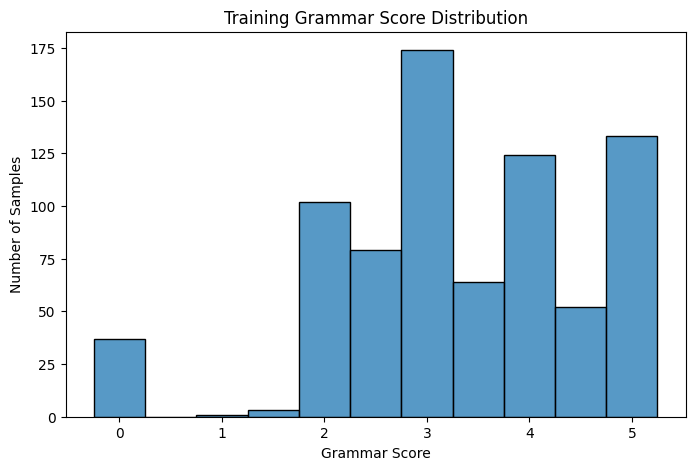

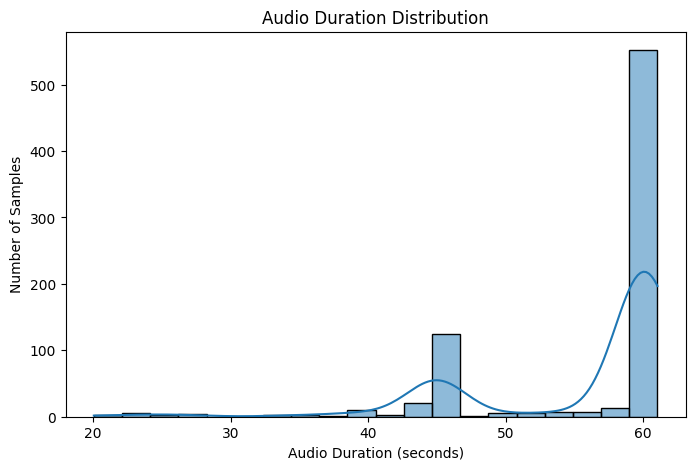

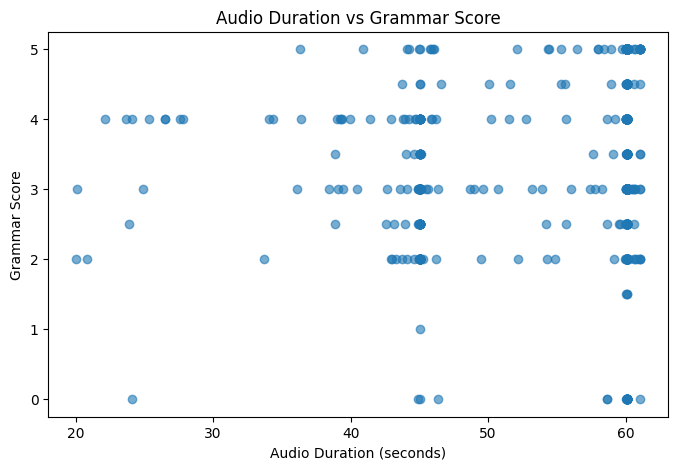


Training samples: 615
Validation samples: 154
Baseline RMSE: 1.3596
Baseline Pearson: nan

Loading OpenAI Whisper...
Whisper loaded successfully.
Device: cuda

Testing Whisper on:
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_192.wav

Sample transcription:
Well, the playground is very, very beautiful and fun. There are places like the merry-go-round, the swing, where students usually enjoy the swing. It has to be like, it's more like a game of fair, because one sits in it and the other sits in it. We'll have to finish the merry-go-round, which is kind of fun. Most of them play football on some parks. That's why other students enjoy the swing, some of the kids like to build sand castles, and most of the time they hear the sound of screaming children and laughing kids.

Whisper segments:
0.00s - 14.64s : Well, the playground is very, very beautiful and fun.
14.64s - 23.76s : There are places like the merry-go-round, the swing, where students usually enj

,filename,text
0,audio_192.wav,"Well, the playground is very, very beautiful a..."
1,audio_436.wav,"The scene of a school playground, our playgrou..."
2,audio_447.wav,My favorite place to visit is the beach. I lov...
3,audio_126.wav,"Once upon a time, we, with five friends, went ..."
4,audio_61.wav,"Well, when I was a child, I remember I went to..."
5,audio_639.wav,The best thing of my life was probably when I ...
6,audio_703.wav,How many of you know several? No. The first da...
7,audio_509.wav,"smoothing effect. Besides this, I also have ho..."
8,audio_672.wav,The school playground is very big and is very ...
9,audio_344.wav,My number one goal in life is to become the be...



Final train columns:
['filename', 'label', 'audio_path', 'duration', 'sample_rate', 'channels', 'text']

SUCCESS: All required columns exist.

Transcription statistics:
Total: 769
Successful: 769
Empty: 0
Success rate: 100.00%


,filename,label,duration,sample_rate,channels,text
0,audio_192.wav,3.0,60.508375,16000.0,1.0,"Well, the playground is very, very beautiful a..."
1,audio_436.wav,3.0,60.074688,16000.0,1.0,"The scene of a school playground, our playgrou..."
2,audio_447.wav,3.5,60.074688,16000.0,1.0,My favorite place to visit is the beach. I lov...
3,audio_126.wav,2.0,45.060000,16000.0,1.0,"Once upon a time, we, with five friends, went ..."
4,audio_61.wav,2.0,45.300000,16000.0,1.0,"Well, when I was a child, I remember I went to..."
5,audio_639.wav,2.5,60.074688,16000.0,1.0,The best thing of my life was probably when I ...
6,audio_703.wav,2.0,52.160000,16000.0,1.0,How many of you know several? No. The first da...
7,audio_509.wav,3.0,60.074688,16000.0,1.0,"smoothing effect. Besides this, I also have ho..."
8,audio_672.wav,4.0,60.074688,16000.0,1.0,The school playground is very big and is very ...
9,audio_344.wav,4.0,60.074688,16000.0,1.0,My number one goal in life is to become the be...



Final training dataset saved:
/kaggle/working/train_with_transcripts.csv

Reload verification:
Shape: (769, 7)
Columns: ['filename', 'label', 'audio_path', 'duration', 'sample_rate', 'channels', 'text']


PHASE 1 COMPLETE
Training samples       : 769
Test samples           : 216
WAV files found        : 985
Missing train audio    : 0
Successful transcripts : 769
Empty transcripts      : 0
Transcript success     : 100.00%
Baseline RMSE          : 1.3596
Baseline Pearson       : nan

Ready for Phase 2.
Next: Grammar/Linguistic Feature Engineering


In [2]:

# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import glob
import warnings
import gc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from scipy.stats import pearsonr

warnings.filterwarnings("ignore")


print("Libraries imported successfully.")


# ============================================================
# 3. CHECK WHISPER
# ============================================================

try:

    import whisper

    print("OpenAI Whisper imported successfully.")

except ImportError:

    raise ImportError(
        "OpenAI Whisper is not installed.\n"
        "Run:\n"
        "!pip install -q openai-whisper\n"
        "Then restart the Kaggle session and run again."
    )


# ============================================================
# 4. CHECK PYTORCH / CUDA
# ============================================================

import torch


if torch.cuda.is_available():

    DEVICE = "cuda"

    print(
        "CUDA available:",
        torch.cuda.get_device_name(0)
    )

else:

    DEVICE = "cpu"

    print(
        "CUDA is not available. Using CPU."
    )


# ============================================================
# 5. DATASET PATH
# ============================================================

DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)


TRAIN_PATH = os.path.join(
    DATA_DIR,
    "train.csv"
)

TEST_PATH = os.path.join(
    DATA_DIR,
    "test.csv"
)

SAMPLE_PATH = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


# ============================================================
# 6. VERIFY DATASET
# ============================================================

print("\nChecking dataset files...\n")


for path in [
    TRAIN_PATH,
    TEST_PATH,
    SAMPLE_PATH
]:

    print(
        os.path.basename(path),
        "->",
        os.path.exists(path)
    )


if not os.path.exists(TRAIN_PATH):

    raise FileNotFoundError(
        f"train.csv not found:\n{TRAIN_PATH}"
    )


if not os.path.exists(TEST_PATH):

    raise FileNotFoundError(
        f"test.csv not found:\n{TEST_PATH}"
    )


if not os.path.exists(SAMPLE_PATH):

    raise FileNotFoundError(
        f"sample_submission.csv not found:\n{SAMPLE_PATH}"
    )


# ============================================================
# 7. LOAD ORIGINAL CSV FILES
# ============================================================
#
# IMPORTANT:
#
# We create train_raw first.
#
# This prevents old notebook variables from causing:
#
#     KeyError: ['label', 'duration']
#
# Every time this cell runs, the original training CSV is
# loaded again.
# ============================================================

train_raw = pd.read_csv(
    TRAIN_PATH
)

test_raw = pd.read_csv(
    TEST_PATH
)

sample_submission = pd.read_csv(
    SAMPLE_PATH
)


# Create fresh working copies
train = train_raw.copy()

test = test_raw.copy()


print("\nDataset shapes:")

print(
    "Train:",
    train.shape
)

print(
    "Test:",
    test.shape
)

print(
    "Sample submission:",
    sample_submission.shape
)


# ============================================================
# 8. CHECK ORIGINAL TRAIN COLUMNS
# ============================================================

print("\nOriginal training columns:")

print(
    train.columns.tolist()
)


# ============================================================
# 9. CHECK REQUIRED COLUMNS
# ============================================================

if "filename" not in train.columns:

    raise KeyError(
        "train.csv does not contain 'filename'.\n"
        f"Available columns: {train.columns.tolist()}"
    )


if "label" not in train.columns:

    raise KeyError(
        "train.csv does not contain 'label'.\n"
        f"Available columns: {train.columns.tolist()}"
    )


if "filename" not in test.columns:

    raise KeyError(
        "test.csv does not contain 'filename'.\n"
        f"Available columns: {test.columns.tolist()}"
    )


TARGET = "label"


print(
    "\nRequired CSV columns verified."
)


# ============================================================
# 10. DISPLAY TRAIN DATA
# ============================================================

display(
    train.head()
)


# ============================================================
# 11. TARGET ANALYSIS
# ============================================================

print("\nTarget statistics:")

display(
    train[TARGET].describe()
)


print("\nLabel distribution:")

display(
    train[TARGET]
    .value_counts()
    .sort_index()
)


# ============================================================
# 12. CHECK LABEL = 0
# ============================================================

zero_labels = train[
    train[TARGET] == 0
]


print(
    "Number of label=0 samples:",
    len(zero_labels)
)


if len(zero_labels) > 0:

    display(
        zero_labels
    )


# ============================================================
# 13. FIND WAV FILES
# ============================================================

print("\nSearching for WAV files...")


audio_files = glob.glob(
    os.path.join(
        DATA_DIR,
        "**",
        "*.wav"
    ),
    recursive=True
)


print(
    "Number of WAV files:",
    len(audio_files)
)


if len(audio_files) == 0:

    raise RuntimeError(
        "No WAV files were found."
    )


print("\nFirst 10 WAV files:")

for path in audio_files[:10]:

    print(path)


# ============================================================
# 14. CREATE AUDIO MAP
# ============================================================
#
# filename -> complete path
# ============================================================

audio_map = {}


for path in audio_files:

    filename = os.path.basename(path)

    audio_map[filename] = path


print("\nExample audio mapping:")

for filename, path in list(
    audio_map.items()
)[:5]:

    print(
        filename,
        "->",
        path
    )


# ============================================================
# 15. ADD AUDIO PATH
# ============================================================

train["audio_path"] = train[
    "filename"
].map(
    audio_map
)


test["audio_path"] = test[
    "filename"
].map(
    audio_map
)


# ============================================================
# 16. CHECK AUDIO PATHS
# ============================================================

missing_train = train[
    "audio_path"
].isna().sum()


missing_test = test[
    "audio_path"
].isna().sum()


print(
    "\nMissing train audio:",
    missing_train
)

print(
    "Missing test audio:",
    missing_test
)


# ============================================================
# 17. SHOW MISSING FILES
# ============================================================

if missing_train > 0:

    print(
        "\nMissing training audio files:"
    )

    display(
        train.loc[
            train["audio_path"].isna(),
            ["filename"]
        ]
    )


if missing_test > 0:

    print(
        "\nMissing testing audio files:"
    )

    display(
        test.loc[
            test["audio_path"].isna(),
            ["filename"]
        ]
    )


# ============================================================
# 18. AUDIO INFORMATION FUNCTION
# ============================================================

def get_audio_info(path):

    # Missing path
    if pd.isna(path):

        return pd.Series({
            "duration": np.nan,
            "sample_rate": np.nan,
            "channels": np.nan
        })


    try:

        info = sf.info(path)

        return pd.Series({

            "duration": float(
                info.duration
            ),

            "sample_rate": int(
                info.samplerate
            ),

            "channels": int(
                info.channels
            )

        })

    except Exception as e:

        return pd.Series({

            "duration": np.nan,

            "sample_rate": np.nan,

            "channels": np.nan

        })


# ============================================================
# 19. EXTRACT AUDIO METADATA
# ============================================================

print(
    "\nExtracting audio metadata..."
)


audio_info = train[
    "audio_path"
].apply(
    get_audio_info
)


# ============================================================
# 20. SAFELY ADD AUDIO METADATA
# ============================================================
#
# Before adding, remove these columns if they already exist.
# This makes the cell safe to rerun.
# ============================================================

for column in [
    "duration",
    "sample_rate",
    "channels"
]:

    if column in train.columns:

        train.drop(
            columns=[column],
            inplace=True
        )


train = pd.concat(
    [
        train,
        audio_info
    ],
    axis=1
)


# ============================================================
# 21. VERIFY COLUMNS
# ============================================================

required_columns = [
    "filename",
    "label",
    "audio_path",
    "duration",
    "sample_rate",
    "channels"
]


missing_columns = [
    column
    for column in required_columns
    if column not in train.columns
]


if len(missing_columns) > 0:

    raise KeyError(
        "The following columns are missing:\n"
        f"{missing_columns}\n\n"
        "Current columns:\n"
        f"{train.columns.tolist()}"
    )


print(
    "\nAll audio columns created successfully."
)


# ============================================================
# 22. DISPLAY AUDIO DATA
# ============================================================

display(
    train[
        [
            "filename",
            "label",
            "audio_path",
            "duration",
            "sample_rate",
            "channels"
        ]
    ].head(10)
)


# ============================================================
# 23. AUDIO SUMMARY
# ============================================================

print("\nAudio metadata summary:")

display(
    train[
        [
            "duration",
            "sample_rate",
            "channels"
        ]
    ].describe()
)


# ============================================================
# 24. MISSING AUDIO METADATA
# ============================================================

print(
    "\nMissing duration:",
    train["duration"].isna().sum()
)

print(
    "Missing sample rate:",
    train["sample_rate"].isna().sum()
)

print(
    "Missing channels:",
    train["channels"].isna().sum()
)


# ============================================================
# 25. CHECK UNUSUAL DURATION
# ============================================================

outside_duration = train[
    (train["duration"] < 40) |
    (train["duration"] > 70)
]


print(
    "\nPotential unusual-duration files:",
    len(outside_duration)
)


if len(outside_duration) > 0:

    display(
        outside_duration[
            [
                "filename",
                "duration",
                "label"
            ]
        ].head(20)
    )


# ============================================================
# 26. VISUALIZATION
# LABEL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 5)
)

sns.histplot(
    train[TARGET],
    bins=np.arange(
        -0.25,
        5.26,
        0.5
    )
)

plt.xlabel(
    "Grammar Score"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "Training Grammar Score Distribution"
)

plt.show()


# ============================================================
# 27. VISUALIZATION
# AUDIO DURATION
# ============================================================

plt.figure(
    figsize=(8, 5)
)

sns.histplot(
    train["duration"].dropna(),
    bins=20,
    kde=True
)

plt.xlabel(
    "Audio Duration (seconds)"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "Audio Duration Distribution"
)

plt.show()


# ============================================================
# 28. VISUALIZATION
# DURATION VS LABEL
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    train["duration"],
    train[TARGET],
    alpha=0.6
)

plt.xlabel(
    "Audio Duration (seconds)"
)

plt.ylabel(
    "Grammar Score"
)

plt.title(
    "Audio Duration vs Grammar Score"
)

plt.show()


# ============================================================
# 29. TRAIN / VALIDATION SPLIT
# ============================================================

train_data, val_data = train_test_split(
    train,
    test_size=0.20,
    random_state=42
)


print(
    "\nTraining samples:",
    len(train_data)
)

print(
    "Validation samples:",
    len(val_data)
)


# ============================================================
# 30. BASELINE MODEL
# ============================================================
#
# Predict the mean training label for every validation sample.
#
# This gives us a minimum benchmark.
# ============================================================

baseline_prediction = train_data[
    TARGET
].mean()


val_pred = np.full(
    len(val_data),
    baseline_prediction
)


# ============================================================
# 31. BASELINE RMSE
# ============================================================

baseline_rmse = np.sqrt(
    mean_squared_error(
        val_data[TARGET],
        val_pred
    )
)


print(
    "Baseline RMSE:",
    round(
        baseline_rmse,
        4
    )
)


# ============================================================
# 32. BASELINE PEARSON
# ============================================================
#
# Since every prediction is identical, Pearson correlation
# cannot be calculated.
# ============================================================

if np.std(val_pred) == 0:

    baseline_pearson = np.nan

else:

    baseline_pearson = pearsonr(
        val_data[TARGET],
        val_pred
    )[0]


print(
    "Baseline Pearson:",
    baseline_pearson
)


# ============================================================
# 33. LOAD OPENAI WHISPER
# ============================================================

print(
    "\nLoading OpenAI Whisper..."
)


model = whisper.load_model(
    "small",
    device=DEVICE
)


print(
    "Whisper loaded successfully."
)

print(
    "Device:",
    DEVICE
)


# ============================================================
# 34. TEST WHISPER ON ONE FILE
# ============================================================

valid_audio = train[
    train["audio_path"].notna()
]


if len(valid_audio) == 0:

    raise RuntimeError(
        "No valid training audio files found."
    )


sample_audio = valid_audio.iloc[
    0
]["audio_path"]


print(
    "\nTesting Whisper on:"
)

print(
    sample_audio
)


# ============================================================
# 35. TRANSCRIBE SAMPLE
# ============================================================

sample_result = model.transcribe(

    sample_audio,

    language="en",

    # FP16 only when CUDA is available
    fp16=(DEVICE == "cuda"),

    beam_size=5
)


sample_text = sample_result[
    "text"
].strip()


print(
    "\nSample transcription:"
)

print(
    sample_text
)


# ============================================================
# 36. SHOW WHISPER SEGMENTS
# ============================================================

print(
    "\nWhisper segments:"
)


for segment in sample_result[
    "segments"
]:

    print(

        f"{segment['start']:.2f}s - "
        f"{segment['end']:.2f}s : "
        f"{segment['text'].strip()}"

    )


# ============================================================
# 37. TRANSCRIPT CACHE
# ============================================================
#
# We save transcripts here:
#
# /kaggle/working/train_transcripts.csv
#
# If the notebook stops halfway, rerunning the code will skip
# files that are already transcribed.
# ============================================================

TRANSCRIPT_FILE = (
    "/kaggle/working/train_transcripts.csv"
)


# ============================================================
# 38. LOAD EXISTING TRANSCRIPT CACHE
# ============================================================

if os.path.exists(
    TRANSCRIPT_FILE
):

    print(
        "\nExisting transcript cache found."
    )

    transcript_df = pd.read_csv(
        TRANSCRIPT_FILE
    )


    # Validate cache structure
    if not {
        "filename",
        "text"
    }.issubset(
        transcript_df.columns
    ):

        print(
            "Cache structure is invalid."
        )

        transcript_df = pd.DataFrame(
            columns=[
                "filename",
                "text"
            ]
        )

    else:

        print(
            "Cached transcripts:",
            len(transcript_df)
        )

else:

    print(
        "\nNo transcript cache found."
    )

    transcript_df = pd.DataFrame(
        columns=[
            "filename",
            "text"
        ]
    )


# ============================================================
# 39. CLEAN TRANSCRIPT CACHE
# ============================================================

if len(transcript_df) > 0:

    transcript_df["filename"] = (
        transcript_df["filename"]
        .astype(str)
    )

    transcript_df["text"] = (
        transcript_df["text"]
        .fillna("")
        .astype(str)
    )


    transcript_df = (
        transcript_df
        .drop_duplicates(
            subset=["filename"],
            keep="last"
        )
        .reset_index(drop=True)
    )


# ============================================================
# 40. CREATE CACHE LOOKUP
# ============================================================

cached_transcripts = dict(
    zip(
        transcript_df["filename"],
        transcript_df["text"]
    )
)


print(
    "Files already cached:",
    len(cached_transcripts)
)


# ============================================================
# 41. TRANSCRIBE TRAINING AUDIO
# ============================================================
#
# This is the slowest stage.
#
# For 769 recordings, this can take significant time.
#
# We save every 20 newly processed files.
# ============================================================

new_transcripts = []


total_train = len(train)


for i, row in train.iterrows():

    filename = str(
        row["filename"]
    )

    audio_path = row[
        "audio_path"
    ]


    # --------------------------------------------------------
    # Missing audio
    # --------------------------------------------------------

    if pd.isna(audio_path):

        print(
            f"[{i + 1}/{total_train}] "
            f"Missing audio: {filename}"
        )

        continue


    # --------------------------------------------------------
    # Already cached
    # --------------------------------------------------------

    if filename in cached_transcripts:

        continue


    # --------------------------------------------------------
    # Whisper transcription
    # --------------------------------------------------------

    try:

        result = model.transcribe(

            audio_path,

            language="en",

            fp16=(DEVICE == "cuda"),

            beam_size=5

        )


        text = result[
            "text"
        ].strip()


    except Exception as e:

        print(
            f"\nERROR: {filename}"
        )

        print(
            "Reason:",
            str(e)
        )

        text = ""


    # --------------------------------------------------------
    # Add result
    # --------------------------------------------------------

    new_transcripts.append({

        "filename": filename,

        "text": text

    })


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    print(
        f"Processed "
        f"{i + 1}/{total_train}: "
        f"{filename}"
    )


    # --------------------------------------------------------
    # Save every 20 files
    # --------------------------------------------------------

    if len(new_transcripts) >= 20:

        temp_df = pd.DataFrame(
            new_transcripts
        )


        transcript_df = pd.concat(
            [
                transcript_df,
                temp_df
            ],
            ignore_index=True
        )


        # Remove duplicates
        transcript_df = (
            transcript_df
            .drop_duplicates(
                subset=["filename"],
                keep="last"
            )
            .reset_index(drop=True)
        )


        # Save
        transcript_df.to_csv(
            TRANSCRIPT_FILE,
            index=False
        )


        # Update cache
        cached_transcripts.update(
            dict(
                zip(
                    temp_df["filename"],
                    temp_df["text"]
                )
            )
        )


        # Reset buffer
        new_transcripts = []


        print(
            ">>> Transcript cache saved."
        )


# ============================================================
# 42. SAVE REMAINING TRANSCRIPTS
# ============================================================

if len(new_transcripts) > 0:

    temp_df = pd.DataFrame(
        new_transcripts
    )


    transcript_df = pd.concat(
        [
            transcript_df,
            temp_df
        ],
        ignore_index=True
    )


# Remove duplicates
transcript_df = (
    transcript_df
    .drop_duplicates(
        subset=["filename"],
        keep="last"
    )
    .reset_index(drop=True)
)


# Final save
transcript_df.to_csv(
    TRANSCRIPT_FILE,
    index=False
)


print(
    "\nFinal transcript cache saved:"
)

print(
    TRANSCRIPT_FILE
)


# ============================================================
# 43. TRANSCRIPT SUMMARY
# ============================================================

print(
    "\nNumber of cached transcripts:",
    len(transcript_df)
)


display(
    transcript_df.head(10)
)


# ============================================================
# 44. MERGE TRANSCRIPTS
# ============================================================
#
# IMPORTANT:
#
# We merge using "filename".
#
# We do NOT use dataframe index.
#
# This avoids the previous problem caused by changing dataframe
# indexes.
# ============================================================

# Remove old text column if it exists
train = train.drop(
    columns=["text"],
    errors="ignore"
)


# Merge transcript data
train = train.merge(

    transcript_df[
        [
            "filename",
            "text"
        ]
    ],

    on="filename",

    how="left",

    validate="one_to_one"

)


# ============================================================
# 45. HANDLE MISSING TRANSCRIPTS
# ============================================================

train["text"] = (
    train["text"]
    .fillna("")
    .astype(str)
)


# ============================================================
# 46. VERIFY FINAL COLUMNS
# ============================================================

print(
    "\nFinal train columns:"
)

print(
    train.columns.tolist()
)


# ============================================================
# 47. FINAL REQUIRED COLUMN CHECK
# ============================================================

final_required_columns = [

    "filename",

    "label",

    "audio_path",

    "duration",

    "sample_rate",

    "channels",

    "text"

]


missing_final = [

    column

    for column in final_required_columns

    if column not in train.columns

]


if len(missing_final) > 0:

    raise KeyError(

        "FINAL DATAFRAME ERROR.\n\n"

        f"Missing columns: {missing_final}\n\n"

        f"Available columns: "
        f"{train.columns.tolist()}"

    )


print(
    "\nSUCCESS: All required columns exist."
)


# ============================================================
# 48. TRANSCRIPTION SUCCESS
# ============================================================

empty_transcripts = (

    train["text"]
    .str.strip()
    .eq("")
    .sum()

)


successful_transcripts = (

    len(train)
    - empty_transcripts

)


success_rate = (

    successful_transcripts
    / len(train)
    * 100

)


print(
    "\nTranscription statistics:"
)

print(
    "Total:",
    len(train)
)

print(
    "Successful:",
    successful_transcripts
)

print(
    "Empty:",
    empty_transcripts
)

print(
    f"Success rate: {success_rate:.2f}%"
)


# ============================================================
# 49. DISPLAY FINAL DATA
# ============================================================

display(

    train[
        [
            "filename",
            "label",
            "duration",
            "sample_rate",
            "channels",
            "text"
        ]
    ].head(20)

)


# ============================================================
# 50. SHOW EMPTY TRANSCRIPTS
# ============================================================

if empty_transcripts > 0:

    print(
        "\nExamples of empty transcripts:"
    )

    display(

        train.loc[
            train["text"].str.strip() == "",
            [
                "filename",
                "label",
                "audio_path"
            ]
        ].head(20)

    )


# ============================================================
# 51. SAVE FINAL TRAIN DATA
# ============================================================

TRAIN_WITH_TRANSCRIPTS = (
    "/kaggle/working/train_with_transcripts.csv"
)


train.to_csv(
    TRAIN_WITH_TRANSCRIPTS,
    index=False
)


print(
    "\nFinal training dataset saved:"
)

print(
    TRAIN_WITH_TRANSCRIPTS
)


# ============================================================
# 52. FINAL VERIFICATION
# ============================================================

check = pd.read_csv(
    TRAIN_WITH_TRANSCRIPTS
)


print(
    "\nReload verification:"
)

print(
    "Shape:",
    check.shape
)

print(
    "Columns:",
    check.columns.tolist()
)


# ============================================================
# 53. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)

print(
    "PHASE 1 COMPLETE"
)

print("=" * 70)

print(
    f"Training samples       : {len(train)}"
)

print(
    f"Test samples           : {len(test)}"
)

print(
    f"WAV files found        : {len(audio_files)}"
)

print(
    f"Missing train audio    : {missing_train}"
)

print(
    f"Successful transcripts : {successful_transcripts}"
)

print(
    f"Empty transcripts      : {empty_transcripts}"
)

print(
    f"Transcript success     : {success_rate:.2f}%"
)

print(
    f"Baseline RMSE          : {baseline_rmse:.4f}"
)

print(
    f"Baseline Pearson       : {baseline_pearson}"
)

print(
    "=" * 70
)


# ============================================================
# 54. MEMORY CLEANUP
# ============================================================

gc.collect()


print(
    "\nReady for Phase 2."
)

print(
    "Next: Grammar/Linguistic Feature Engineering"
)



#
# PHASE 2:
# GRAMMAR / LINGUISTIC FEATURE ENGINEERING
#
# Input:
#   /kaggle/working/train_with_transcripts.csv
#
# Output:
#   Linguistic features
#   TF-IDF features
#   Cross-validation results
#   RMSE
#   Pearson Correlation
#
# IMPORTANT:
#   Whisper is NOT run again in this phase.

Phase 2 libraries loaded.
Loaded training data: (769, 7)
Required columns verified.
Empty transcripts: 0


,filename,label,clean_text
0,audio_192.wav,3.0,"well, the playground is very, very beautiful a..."
1,audio_436.wav,3.0,"the scene of a school playground, our playgrou..."
2,audio_447.wav,3.5,my favorite place to visit is the beach. i lov...
3,audio_126.wav,2.0,"once upon a time, we, with five friends, went ..."
4,audio_61.wav,2.0,"well, when i was a child, i remember i went to..."
5,audio_639.wav,2.5,the best thing of my life was probably when i ...
6,audio_703.wav,2.0,how many of you know several? no. the first da...
7,audio_509.wav,3.0,"smoothing effect. besides this, i also have ho..."
8,audio_672.wav,4.0,the school playground is very big and is very ...
9,audio_344.wav,4.0,my number one goal in life is to become the be...



Extracting linguistic features...
Linguistic feature shape: (769, 25)


,word_count,sentence_count,avg_sentence_length,avg_word_length,unique_word_count,type_token_ratio,repeated_word_count,repeated_word_ratio,most_common_ratio,avg_sentence_words,...,comma_count,period_count,question_count,exclamation_count,comma_rate,punctuation_rate,filler_count,filler_ratio,character_count,alphabetic_character_count
0,100,6,16.666667,4.060000,60,0.600000,40,0.400000,0.100000,16.666667,...,9,6,0,0,0.090000,0.150000,5,0.050000,520,403
1,114,5,22.800000,4.342105,53,0.464912,61,0.535088,0.096491,22.800000,...,2,5,0,0,0.017544,0.061404,5,0.043860,615,495
2,146,12,12.166667,3.986301,76,0.520548,70,0.479452,0.143836,12.166667,...,3,12,0,0,0.020548,0.102740,1,0.006849,742,582
3,97,2,48.500000,3.690722,42,0.432990,55,0.567010,0.103093,48.500000,...,19,2,0,0,0.195876,0.216495,0,0.000000,475,358
4,76,4,19.000000,3.868421,45,0.592105,31,0.407895,0.092105,19.000000,...,15,4,0,0,0.197368,0.250000,0,0.000000,388,292



Combined dataset shape: (769, 33)


,count,mean,std,min,25%,50%,75%,max
word_count,769.0,98.843953,27.377932,3.000000,81.000000,100.000000,119.000000,182.000000
sentence_count,769.0,4.769831,2.955455,1.000000,2.000000,4.000000,7.000000,17.000000
avg_sentence_length,769.0,33.400060,29.842495,3.000000,15.000000,20.666667,37.000000,145.000000
avg_word_length,769.0,4.229452,0.420196,3.288136,3.925620,4.191176,4.455782,5.779412
unique_word_count,769.0,58.513654,15.253761,3.000000,48.000000,58.000000,69.000000,107.000000
type_token_ratio,769.0,0.606066,0.097969,0.261364,0.537634,0.600000,0.659722,1.000000
repeated_word_count,769.0,40.330299,16.489031,0.000000,29.000000,40.000000,53.000000,104.000000
repeated_word_ratio,769.0,0.393934,0.097969,0.000000,0.340278,0.400000,0.462366,0.738636
most_common_ratio,769.0,0.082462,0.031669,0.033333,0.063492,0.076923,0.093458,0.333333
avg_sentence_words,769.0,33.400060,29.842495,3.000000,15.000000,20.666667,37.000000,145.000000



Top linguistic feature correlations:


,feature,correlation,absolute_correlation
4,unique_word_count,0.510461,0.510461
24,alphabetic_character_count,0.413568,0.413568
23,character_count,0.405702,0.405702
0,word_count,0.345320,0.345320
8,most_common_ratio,-0.310015,0.310015
18,exclamation_count,-0.234365,0.234365
16,period_count,0.190291,0.190291
1,sentence_count,0.176182,0.176182
3,avg_word_length,0.169942,0.169942
13,short_sentence_ratio,-0.137296,0.137296


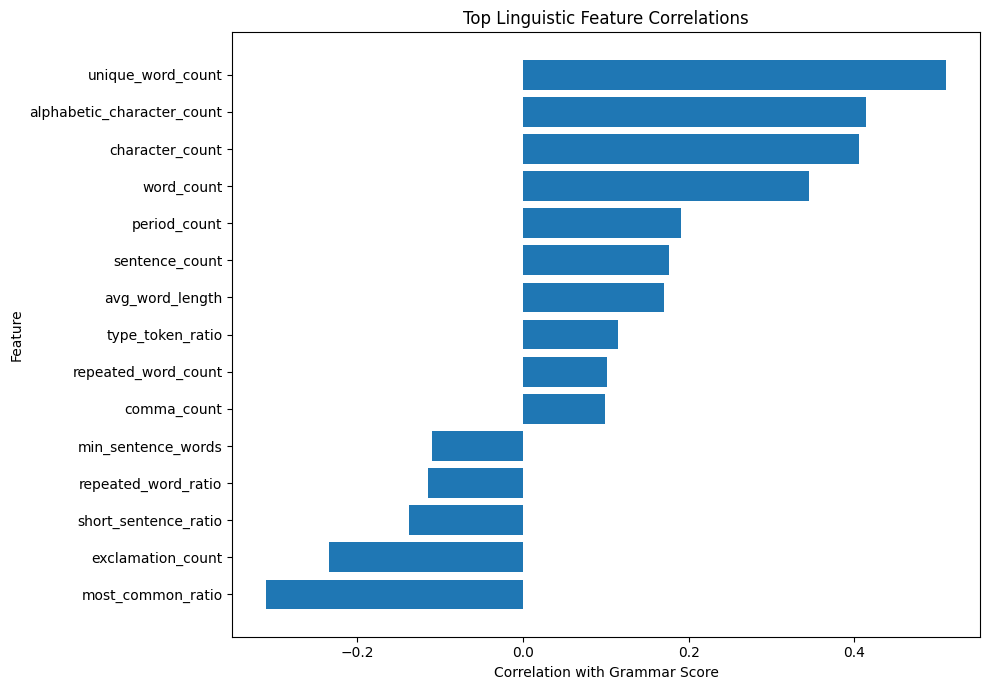


Linguistic dataset saved:
/kaggle/working/train_linguistic_features.csv
Word TF-IDF shape: (769, 10031)
Character TF-IDF shape: (769, 30000)
Combined text feature shape: (769, 40031)

========== FOLD 1 ==========
RMSE: 1.2328
Pearson: 0.5872

========== FOLD 2 ==========
RMSE: 1.0756
Pearson: 0.6448

========== FOLD 3 ==========
RMSE: 1.0942
Pearson: 0.4948

========== FOLD 4 ==========
RMSE: 1.1317
Pearson: 0.5749

========== FOLD 5 ==========
RMSE: 1.0787
Pearson: 0.5575

Fold results:


,fold,rmse,pearson
0,1,1.232758,0.587207
1,2,1.075593,0.644763
2,3,1.094234,0.494845
3,4,1.131726,0.574897
4,5,1.078742,0.557534



PHASE 2 TEXT MODEL RESULTS
OOF RMSE:     1.1242
OOF Pearson:  0.5636


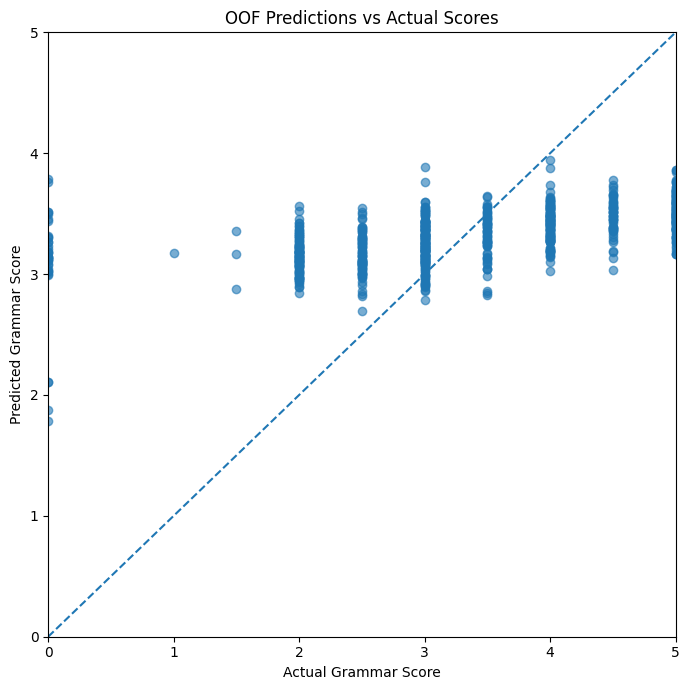

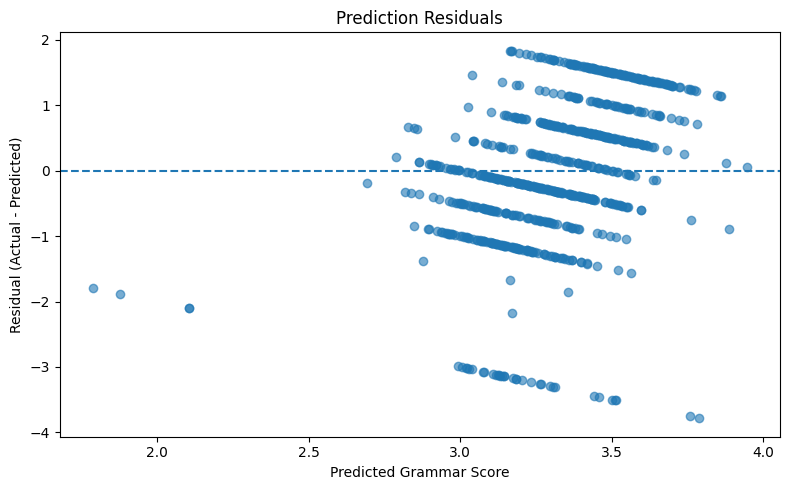

OOF predictions saved:
/kaggle/working/phase2_oof_predictions.csv


PHASE 2 COMPLETE
Training samples       : 769
Linguistic features    : 25
Word TF-IDF features   : 10031
Char TF-IDF features   : 30000
Total text features    : 40031
OOF RMSE               : 1.1242
OOF Pearson            : 0.5636

Ready for Phase 3.
Next: Audio / Speech Features


In [3]:
# ============================================================
# GRAMMAR SCORING ENGINE
# SHL HIRING ASSESSMENT 2026

# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import re
import gc
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.pipeline import FeatureUnion

from sklearn.metrics import mean_squared_error

from scipy.stats import pearsonr

warnings.filterwarnings("ignore")


print("Phase 2 libraries loaded.")


# ============================================================
# 2. LOAD PHASE 1 DATA
# ============================================================

TRAIN_FILE = (
    "/kaggle/working/train_with_transcripts.csv"
)


if not os.path.exists(TRAIN_FILE):

    raise FileNotFoundError(
        f"File not found:\n{TRAIN_FILE}\n\n"
        "Please complete Phase 1 first."
    )


train = pd.read_csv(
    TRAIN_FILE
)


print(
    "Loaded training data:",
    train.shape
)


# ============================================================
# 3. VERIFY REQUIRED COLUMNS
# ============================================================

required_columns = [
    "filename",
    "label",
    "text",
    "duration"
]


missing_columns = [
    column
    for column in required_columns
    if column not in train.columns
]


if missing_columns:

    raise KeyError(
        f"Missing columns: {missing_columns}\n\n"
        f"Available columns:\n{train.columns.tolist()}"
    )


print(
    "Required columns verified."
)


# ============================================================
# 4. CLEAN TRANSCRIPTS
# ============================================================
#
# Whisper can sometimes produce:
#
#   extra spaces
#   repeated spaces
#   empty strings
#   unusual punctuation
#
# We clean the transcript before feature extraction.
# ============================================================

train["text"] = (
    train["text"]
    .fillna("")
    .astype(str)
)


def clean_text(text):

    text = text.lower()

    # Replace line breaks with spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    # Remove leading/trailing spaces
    text = text.strip()

    return text


train["clean_text"] = (
    train["text"]
    .apply(clean_text)
)


# ============================================================
# 5. BASIC TRANSCRIPT CHECK
# ============================================================

empty_count = (
    train["clean_text"]
    .str.len()
    .eq(0)
    .sum()
)


print(
    "Empty transcripts:",
    empty_count
)


display(
    train[
        [
            "filename",
            "label",
            "clean_text"
        ]
    ].head(10)
)


# ============================================================
# 6. TOKENIZATION FUNCTIONS
# ============================================================

WORD_PATTERN = re.compile(
    r"\b[a-zA-Z]+(?:'[a-zA-Z]+)?\b"
)


def get_words(text):

    return WORD_PATTERN.findall(
        text.lower()
    )


def get_sentences(text):

    # Whisper normally retains punctuation,
    # but punctuation may be incomplete.
    sentences = re.split(
        r"[.!?]+",
        text
    )

    sentences = [
        s.strip()
        for s in sentences
        if s.strip()
    ]

    return sentences


# ============================================================
# 7. LINGUISTIC FEATURE FUNCTION
# ============================================================
#
# These features attempt to capture properties associated with
# spoken grammatical quality.
#
# We are NOT claiming that these individual features are
# grammar scores.
#
# The ML model learns how combinations of these features relate
# to the human MOS grammar labels.
# ============================================================

FILLER_WORDS = {
    "um",
    "uh",
    "erm",
    "hmm",
    "like",
    "you know",
    "actually",
    "basically",
    "sort of",
    "kind of"
}


def extract_linguistic_features(text):

    text = str(text)

    words = get_words(text)

    sentences = get_sentences(text)


    # --------------------------------------------------------
    # Basic counts
    # --------------------------------------------------------

    word_count = len(words)

    sentence_count = len(sentences)


    # --------------------------------------------------------
    # Average sentence length
    # --------------------------------------------------------

    if sentence_count > 0:

        avg_sentence_length = (
            word_count /
            sentence_count
        )

    else:

        avg_sentence_length = 0


    # --------------------------------------------------------
    # Word lengths
    # --------------------------------------------------------

    if word_count > 0:

        word_lengths = [
            len(word)
            for word in words
        ]

        avg_word_length = np.mean(
            word_lengths
        )

        long_word_ratio = np.mean(
            np.array(word_lengths) >= 7
        )

    else:

        avg_word_length = 0

        long_word_ratio = 0


    # --------------------------------------------------------
    # Vocabulary diversity
    # --------------------------------------------------------

    unique_words = set(words)

    unique_word_count = len(
        unique_words
    )


    if word_count > 0:

        type_token_ratio = (
            unique_word_count /
            word_count
        )

    else:

        type_token_ratio = 0


    # --------------------------------------------------------
    # Repeated words
    # --------------------------------------------------------

    word_counter = Counter(words)


    repeated_word_count = sum(
        count - 1
        for count in word_counter.values()
        if count > 1
    )


    if word_count > 0:

        repeated_word_ratio = (
            repeated_word_count /
            word_count
        )

    else:

        repeated_word_ratio = 0


    # --------------------------------------------------------
    # Most common word frequency
    # --------------------------------------------------------

    if word_count > 0:

        most_common_frequency = (
            word_counter
            .most_common(1)[0][1]
        )

        most_common_ratio = (
            most_common_frequency /
            word_count
        )

    else:

        most_common_ratio = 0


    # --------------------------------------------------------
    # Short / long sentence statistics
    # --------------------------------------------------------

    sentence_lengths = [
        len(get_words(sentence))
        for sentence in sentences
    ]


    if sentence_lengths:

        avg_sentence_words = np.mean(
            sentence_lengths
        )

        max_sentence_words = np.max(
            sentence_lengths
        )

        min_sentence_words = np.min(
            sentence_lengths
        )

        sentence_length_std = np.std(
            sentence_lengths
        )

        short_sentence_ratio = np.mean(
            np.array(sentence_lengths) <= 5
        )

        long_sentence_ratio = np.mean(
            np.array(sentence_lengths) >= 25
        )

    else:

        avg_sentence_words = 0

        max_sentence_words = 0

        min_sentence_words = 0

        sentence_length_std = 0

        short_sentence_ratio = 0

        long_sentence_ratio = 0


    # --------------------------------------------------------
    # Punctuation
    # --------------------------------------------------------

    comma_count = text.count(",")

    period_count = text.count(".")

    question_count = text.count("?")

    exclamation_count = text.count("!")


    if word_count > 0:

        comma_rate = (
            comma_count /
            word_count
        )

        punctuation_rate = (
            (
                comma_count +
                period_count +
                question_count +
                exclamation_count
            )
            / word_count
        )

    else:

        comma_rate = 0

        punctuation_rate = 0


    # --------------------------------------------------------
    # Filler words
    # --------------------------------------------------------

    filler_count = 0


    for filler in FILLER_WORDS:

        if " " in filler:

            filler_count += len(
                re.findall(
                    r"\b" +
                    re.escape(filler) +
                    r"\b",
                    text
                )
            )

        else:

            filler_count += len(
                re.findall(
                    r"\b" +
                    re.escape(filler) +
                    r"\b",
                    text
                )
            )


    if word_count > 0:

        filler_ratio = (
            filler_count /
            word_count
        )

    else:

        filler_ratio = 0


    # --------------------------------------------------------
    # Unique character / lexical statistics
    # --------------------------------------------------------

    character_count = len(text)

    alphabetic_character_count = sum(
        character.isalpha()
        for character in text
    )


    # --------------------------------------------------------
    # Return features
    # --------------------------------------------------------

    return {

        "word_count":
            word_count,

        "sentence_count":
            sentence_count,

        "avg_sentence_length":
            avg_sentence_length,

        "avg_word_length":
            avg_word_length,

        "unique_word_count":
            unique_word_count,

        "type_token_ratio":
            type_token_ratio,

        "repeated_word_count":
            repeated_word_count,

        "repeated_word_ratio":
            repeated_word_ratio,

        "most_common_ratio":
            most_common_ratio,

        "avg_sentence_words":
            avg_sentence_words,

        "max_sentence_words":
            max_sentence_words,

        "min_sentence_words":
            min_sentence_words,

        "sentence_length_std":
            sentence_length_std,

        "short_sentence_ratio":
            short_sentence_ratio,

        "long_sentence_ratio":
            long_sentence_ratio,

        "comma_count":
            comma_count,

        "period_count":
            period_count,

        "question_count":
            question_count,

        "exclamation_count":
            exclamation_count,

        "comma_rate":
            comma_rate,

        "punctuation_rate":
            punctuation_rate,

        "filler_count":
            filler_count,

        "filler_ratio":
            filler_ratio,

        "character_count":
            character_count,

        "alphabetic_character_count":
            alphabetic_character_count
    }


# ============================================================
# 8. EXTRACT FEATURES FOR ALL TRAINING SAMPLES
# ============================================================

print(
    "\nExtracting linguistic features..."
)


linguistic_features = train[
    "clean_text"
].apply(
    extract_linguistic_features
)


linguistic_features = pd.DataFrame(
    linguistic_features.tolist()
)


print(
    "Linguistic feature shape:",
    linguistic_features.shape
)


display(
    linguistic_features.head()
)


# ============================================================
# 9. COMBINE FEATURES WITH TRAIN DATA
# ============================================================

# Remove existing feature columns if rerunning
feature_columns = (
    linguistic_features.columns.tolist()
)


train_features = train.drop(
    columns=feature_columns,
    errors="ignore"
).copy()


train_features = pd.concat(
    [
        train_features.reset_index(drop=True),
        linguistic_features.reset_index(drop=True)
    ],
    axis=1
)


print(
    "\nCombined dataset shape:",
    train_features.shape
)


# ============================================================
# 10. FEATURE STATISTICS
# ============================================================

display(
    train_features[
        feature_columns
    ].describe().T
)


# ============================================================
# 11. CORRELATION WITH TARGET
# ============================================================
#
# This does NOT mean correlation equals importance.
#
# It simply helps us understand which individual features have
# some relationship with human grammar scores.
# ============================================================

correlations = []


for column in feature_columns:

    x = train_features[column]

    y = train_features[TARGET]


    if x.nunique() <= 1:

        correlation = 0

    else:

        correlation = x.corr(y)


    correlations.append({

        "feature": column,

        "correlation": correlation,

        "absolute_correlation":
            abs(correlation)

    })


correlation_df = (
    pd.DataFrame(correlations)
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
)


print(
    "\nTop linguistic feature correlations:"
)


display(
    correlation_df.head(15)
)


# ============================================================
# 12. CORRELATION VISUALIZATION
# ============================================================

top_corr = (
    correlation_df
    .head(15)
    .sort_values(
        "correlation"
    )
)


plt.figure(
    figsize=(10, 7)
)


plt.barh(
    top_corr["feature"],
    top_corr["correlation"]
)


plt.xlabel(
    "Correlation with Grammar Score"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "Top Linguistic Feature Correlations"
)


plt.tight_layout()

plt.show()


# ============================================================
# 13. SAVE LINGUISTIC FEATURES
# ============================================================

LINGUISTIC_FILE = (
    "/kaggle/working/"
    "train_linguistic_features.csv"
)


train_features.to_csv(
    LINGUISTIC_FILE,
    index=False
)


print(
    "\nLinguistic dataset saved:"
)

print(
    LINGUISTIC_FILE
)


# ============================================================
# 14. PREPARE TEXT DATA
# ============================================================
#
# TF-IDF converts transcripts into numerical features.
#
# Example:
#
#     "I went to the market yesterday"
#
# becomes numerical word/character representations.
#
# Word TF-IDF captures:
#
#     vocabulary and phrases
#
# Character TF-IDF captures:
#
#     word structure / spelling patterns / partial patterns
#
# Combining both is often stronger than using only one.
# ============================================================

texts = (
    train_features["clean_text"]
    .fillna("")
    .astype(str)
)


y = (
    train_features[TARGET]
    .astype(float)
    .values
)


# ============================================================
# 15. WORD TF-IDF
# ============================================================

word_vectorizer = TfidfVectorizer(

    analyzer="word",

    ngram_range=(1, 2),

    min_df=2,

    max_df=0.95,

    sublinear_tf=True,

    max_features=30000

)


X_word = word_vectorizer.fit_transform(
    texts
)


print(
    "Word TF-IDF shape:",
    X_word.shape
)


# ============================================================
# 16. CHARACTER TF-IDF
# ============================================================
#
# Character n-grams can capture useful language patterns even
# when the exact word is uncommon.
# ============================================================

char_vectorizer = TfidfVectorizer(

    analyzer="char",

    ngram_range=(3, 5),

    min_df=3,

    max_features=30000,

    sublinear_tf=True

)


X_char = char_vectorizer.fit_transform(
    texts
)


print(
    "Character TF-IDF shape:",
    X_char.shape
)


# ============================================================
# 17. COMBINE WORD + CHARACTER TF-IDF
# ============================================================

from scipy.sparse import hstack


X_text = hstack(
    [
        X_word,
        X_char
    ]
).tocsr()


print(
    "Combined text feature shape:",
    X_text.shape
)


# ============================================================
# 18. CROSS VALIDATION
# ============================================================
#
# We use 5 folds.
#
# Each sample becomes validation data once.
#
# This gives a much more reliable estimate than one random
# train/validation split.
# ============================================================

N_SPLITS = 5


kf = KFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=42

)


# ============================================================
# 19. TF-IDF + RIDGE MODEL
# ============================================================
#
# Ridge regression works well with high-dimensional sparse
# TF-IDF features.
#
# It is also relatively fast compared with many nonlinear
# models on 769 samples and tens of thousands of text features.
# ============================================================

fold_results = []

oof_predictions = np.zeros(
    len(train_features)
)


for fold, (
    train_idx,
    val_idx
) in enumerate(
    kf.split(X_text),
    start=1
):

    print(
        f"\n========== FOLD {fold} =========="
    )


    # --------------------------------------------------------
    # Split text features
    # --------------------------------------------------------

    X_train = X_text[
        train_idx
    ]

    X_val = X_text[
        val_idx
    ]


    y_train = y[
        train_idx
    ]

    y_val = y[
        val_idx
    ]


    # --------------------------------------------------------
    # Ridge regression
    # --------------------------------------------------------

    model = Ridge(
        alpha=10.0
    )


    model.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Validation prediction
    # --------------------------------------------------------

    predictions = model.predict(
        X_val
    )


    # --------------------------------------------------------
    # Clip to competition range
    # --------------------------------------------------------

    predictions = np.clip(
        predictions,
        0,
        5
    )


    # Store OOF predictions
    oof_predictions[
        val_idx
    ] = predictions


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_val,
            predictions
        )
    )


    # --------------------------------------------------------
    # Pearson
    # --------------------------------------------------------

    if (
        np.std(predictions) > 0
        and
        np.std(y_val) > 0
    ):

        fold_pearson = pearsonr(
            y_val,
            predictions
        )[0]

    else:

        fold_pearson = np.nan


    fold_results.append({

        "fold":
            fold,

        "rmse":
            fold_rmse,

        "pearson":
            fold_pearson

    })


    print(
        f"RMSE: {fold_rmse:.4f}"
    )

    print(
        f"Pearson: {fold_pearson:.4f}"
    )


# ============================================================
# 20. CROSS-VALIDATION RESULTS
# ============================================================

results_df = pd.DataFrame(
    fold_results
)


print(
    "\nFold results:"
)


display(
    results_df
)


# ============================================================
# 21. OVERALL OOF SCORE
# ============================================================
#
# OOF = Out Of Fold.
#
# Every training sample has a prediction generated by a model
# that did not train on that sample.
#
# This is our most important Phase 2 validation result.
# ============================================================

overall_rmse = np.sqrt(
    mean_squared_error(
        y,
        oof_predictions
    )
)


overall_pearson = pearsonr(
    y,
    oof_predictions
)[0]


print(
    "\n"
    + "=" * 60
)

print(
    "PHASE 2 TEXT MODEL RESULTS"
)

print(
    "=" * 60
)

print(
    f"OOF RMSE:     {overall_rmse:.4f}"
)

print(
    f"OOF Pearson:  {overall_pearson:.4f}"
)

print(
    "=" * 60
)


# ============================================================
# 22. PREDICTION VS ACTUAL VISUALIZATION
# ============================================================

plt.figure(
    figsize=(7, 7)
)


plt.scatter(
    y,
    oof_predictions,
    alpha=0.6
)


plt.plot(
    [0, 5],
    [0, 5],
    linestyle="--"
)


plt.xlabel(
    "Actual Grammar Score"
)


plt.ylabel(
    "Predicted Grammar Score"
)


plt.title(
    "OOF Predictions vs Actual Scores"
)


plt.xlim(
    0,
    5
)


plt.ylim(
    0,
    5
)


plt.tight_layout()

plt.show()


# ============================================================
# 23. RESIDUAL ANALYSIS
# ============================================================

residuals = (
    y -
    oof_predictions
)


plt.figure(
    figsize=(8, 5)
)


plt.scatter(
    oof_predictions,
    residuals,
    alpha=0.6
)


plt.axhline(
    0,
    linestyle="--"
)


plt.xlabel(
    "Predicted Grammar Score"
)


plt.ylabel(
    "Residual (Actual - Predicted)"
)


plt.title(
    "Prediction Residuals"
)


plt.tight_layout()

plt.show()


# ============================================================
# 24. SAVE OOF PREDICTIONS
# ============================================================

oof_df = pd.DataFrame({

    "filename":
        train_features["filename"],

    "actual":
        y,

    "prediction":
        oof_predictions,

    "error":
        residuals

})


OOF_FILE = (
    "/kaggle/working/"
    "phase2_oof_predictions.csv"
)


oof_df.to_csv(
    OOF_FILE,
    index=False
)


print(
    "OOF predictions saved:"
)

print(
    OOF_FILE
)


# ============================================================
# 25. FINAL PHASE 2 SUMMARY
# ============================================================

print("\n")
print("=" * 70)

print(
    "PHASE 2 COMPLETE"
)

print("=" * 70)

print(
    f"Training samples       : {len(train)}"
)

print(
    f"Linguistic features    : {len(feature_columns)}"
)

print(
    f"Word TF-IDF features   : {X_word.shape[1]}"
)

print(
    f"Char TF-IDF features   : {X_char.shape[1]}"
)

print(
    f"Total text features    : {X_text.shape[1]}"
)

print(
    f"OOF RMSE               : {overall_rmse:.4f}"
)

print(
    f"OOF Pearson            : {overall_pearson:.4f}"
)

print("=" * 70)


# ============================================================
# 26. CLEAN MEMORY
# ============================================================

gc.collect()


print(
    "\nReady for Phase 3."
)

print(
    "Next: Audio / Speech Features"
)


In [4]:
# ============================================================
# GRAMMAR SCORING ENGINE
# SHL HIRING ASSESSMENT 2026
#
# PHASE 3:
# AUDIO / SPEECH FEATURE ENGINEERING
#
# Input:
#   /kaggle/working/train_with_transcripts.csv
#
# We extract acoustic features from the original WAV files.
#
# Features:
#   1. Duration
#   2. RMS energy
#   3. Zero crossing rate
#   4. Spectral centroid
#   5. Spectral bandwidth
#   6. Spectral rolloff
#   7. Spectral contrast
#   8. MFCC statistics
#   9. Pitch statistics
#   10. Silence / pause statistics
#   11. Speaking-rate proxy
#
# Evaluation:
#   5-fold OOF RMSE
#   5-fold OOF Pearson
#
# IMPORTANT:
#   Whisper is NOT used in this phase.
# ============================================================


# ============================================================
# 1. OPTIONAL INSTALLATION
# ============================================================
#
# If librosa is already installed, don't run this.
#
# Uncomment only if required:
#
# !pip install -q librosa
#
# ============================================================


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error

from scipy.stats import pearsonr

warnings.filterwarnings("ignore")


print("Phase 3 libraries loaded.")


# ============================================================
# 3. LOAD PHASE 1 DATA
# ============================================================

TRAIN_FILE = (
    "/kaggle/working/train_with_transcripts.csv"
)


if not os.path.exists(TRAIN_FILE):

    raise FileNotFoundError(
        f"File not found:\n{TRAIN_FILE}\n\n"
        "Please complete Phase 1 first."
    )


train = pd.read_csv(
    TRAIN_FILE
)


print(
    "Training data:",
    train.shape
)


# ============================================================
# 4. VERIFY REQUIRED COLUMNS
# ============================================================

required_columns = [
    "filename",
    "label",
    "audio_path",
    "duration"
]


missing_columns = [
    column
    for column in required_columns
    if column not in train.columns
]


if missing_columns:

    raise KeyError(
        f"Missing columns: {missing_columns}\n\n"
        f"Available columns:\n{train.columns.tolist()}"
    )


print(
    "Required columns verified."
)


# ============================================================
# 5. AUDIO FEATURE CONFIGURATION
# ============================================================
#
# We resample every file to 16 kHz.
#
# Why?
#
# Speech models commonly use 16 kHz and it gives us a consistent
# sampling rate across all recordings.
#
# We use mono audio.
#
# Why?
#
# Grammar scoring does not need stereo information.
# ============================================================

TARGET_SR = 16000


# ============================================================
# 6. AUDIO FEATURE FUNCTION
# ============================================================

def extract_audio_features(audio_path):

    """
    Extract acoustic and speech-related features from one WAV.

    Returns:
        Dictionary containing numerical audio features.
    """


    # --------------------------------------------------------
    # Handle missing path
    # --------------------------------------------------------

    if pd.isna(audio_path):

        return {}


    try:

        # ----------------------------------------------------
        # Load audio
        # ----------------------------------------------------
        #
        # mono=True:
        #   converts stereo -> mono
        #
        # sr=16000:
        #   standardizes sample rate
        # ----------------------------------------------------

        y, sr = librosa.load(

            audio_path,

            sr=TARGET_SR,

            mono=True

        )


        # ----------------------------------------------------
        # Empty audio protection
        # ----------------------------------------------------

        if y is None or len(y) == 0:

            return {}


        # ----------------------------------------------------
        # Basic statistics
        # ----------------------------------------------------

        duration = (
            len(y) /
            sr
        )


        mean_amplitude = np.mean(
            np.abs(y)
        )


        std_amplitude = np.std(
            y
        )


        max_amplitude = np.max(
            np.abs(y)
        )


        # ----------------------------------------------------
        # RMS Energy
        # ----------------------------------------------------
        #
        # RMS describes the energy / loudness pattern of speech.
        # ----------------------------------------------------

        rms = librosa.feature.rms(
            y=y
        )[0]


        rms_mean = np.mean(rms)

        rms_std = np.std(rms)

        rms_min = np.min(rms)

        rms_max = np.max(rms)


        # ----------------------------------------------------
        # Zero Crossing Rate
        # ----------------------------------------------------
        #
        # Useful for describing signal characteristics and
        # distinguishing speech / noise patterns.
        # ----------------------------------------------------

        zcr = librosa.feature.zero_crossing_rate(
            y
        )[0]


        zcr_mean = np.mean(zcr)

        zcr_std = np.std(zcr)


        # ----------------------------------------------------
        # Spectral Centroid
        # ----------------------------------------------------

        spectral_centroid = (
            librosa.feature
            .spectral_centroid(
                y=y,
                sr=sr
            )[0]
        )


        centroid_mean = np.mean(
            spectral_centroid
        )

        centroid_std = np.std(
            spectral_centroid
        )


        # ----------------------------------------------------
        # Spectral Bandwidth
        # ----------------------------------------------------

        spectral_bandwidth = (
            librosa.feature
            .spectral_bandwidth(
                y=y,
                sr=sr
            )[0]
        )


        bandwidth_mean = np.mean(
            spectral_bandwidth
        )

        bandwidth_std = np.std(
            spectral_bandwidth
        )


        # ----------------------------------------------------
        # Spectral Rolloff
        # ----------------------------------------------------

        spectral_rolloff = (
            librosa.feature
            .spectral_rolloff(
                y=y,
                sr=sr
            )[0]
        )


        rolloff_mean = np.mean(
            spectral_rolloff
        )

        rolloff_std = np.std(
            spectral_rolloff
        )


        # ----------------------------------------------------
        # Spectral Contrast
        # ----------------------------------------------------

        spectral_contrast = (
            librosa.feature
            .spectral_contrast(
                y=y,
                sr=sr
            )
        )


        contrast_features = {}


        for i in range(
            spectral_contrast.shape[0]
        ):

            contrast_features[
                f"contrast_{i}_mean"
            ] = np.mean(
                spectral_contrast[i]
            )

            contrast_features[
                f"contrast_{i}_std"
            ] = np.std(
                spectral_contrast[i]
            )


        # ----------------------------------------------------
        # MFCC
        # ----------------------------------------------------
        #
        # MFCCs are widely used speech/audio features.
        #
        # Instead of keeping every time frame, we calculate
        # summary statistics for each MFCC coefficient.
        # ----------------------------------------------------

        mfcc = librosa.feature.mfcc(

            y=y,

            sr=sr,

            n_mfcc=20

        )


        mfcc_features = {}


        for i in range(
            mfcc.shape[0]
        ):

            mfcc_features[
                f"mfcc_{i}_mean"
            ] = np.mean(
                mfcc[i]
            )

            mfcc_features[
                f"mfcc_{i}_std"
            ] = np.std(
                mfcc[i]
            )

            mfcc_features[
                f"mfcc_{i}_min"
            ] = np.min(
                mfcc[i]
            )

            mfcc_features[
                f"mfcc_{i}_max"
            ] = np.max(
                mfcc[i]
            )


        # ----------------------------------------------------
        # Pitch estimation
        # ----------------------------------------------------
        #
        # YIN estimates fundamental frequency.
        #
        # We calculate statistics only from positive pitch
        # values, because zero represents unvoiced frames.
        # ----------------------------------------------------

        try:

            pitch = librosa.yin(

                y,

                fmin=65,

                fmax=400,

                sr=sr

            )


            valid_pitch = pitch[
                np.isfinite(pitch)
            ]

            valid_pitch = valid_pitch[
                valid_pitch > 0
            ]


            if len(valid_pitch) > 0:

                pitch_mean = np.mean(
                    valid_pitch
                )

                pitch_std = np.std(
                    valid_pitch
                )

                pitch_min = np.min(
                    valid_pitch
                )

                pitch_max = np.max(
                    valid_pitch
                )

            else:

                pitch_mean = 0

                pitch_std = 0

                pitch_min = 0

                pitch_max = 0


        except Exception:

            pitch_mean = 0

            pitch_std = 0

            pitch_min = 0

            pitch_max = 0


        # ----------------------------------------------------
        # Silence / pause analysis
        # ----------------------------------------------------
        #
        # librosa.effects.split identifies non-silent regions.
        #
        # From these regions we estimate:
        #
        #   voiced/speech duration
        #   silence duration
        #   number of speech segments
        #   average pause duration
        # ----------------------------------------------------

        intervals = librosa.effects.split(

            y,

            top_db=30

        )


        if len(intervals) > 0:

            speech_samples = sum(

                end - start

                for start, end
                in intervals

            )


            speech_duration = (
                speech_samples /
                sr
            )


            number_speech_segments = (
                len(intervals)
            )


        else:

            speech_duration = 0

            number_speech_segments = 0


        silence_duration = max(

            0,

            duration -
            speech_duration

        )


        # ----------------------------------------------------
        # Pause durations
        # ----------------------------------------------------

        pause_durations = []


        if len(intervals) > 1:

            for i in range(
                1,
                len(intervals)
            ):

                previous_end = (
                    intervals[i - 1][1]
                )

                current_start = (
                    intervals[i][0]
                )


                pause_samples = (
                    current_start -
                    previous_end
                )


                pause_duration = (
                    pause_samples /
                    sr
                )


                if pause_duration > 0:

                    pause_durations.append(
                        pause_duration
                    )


        if len(pause_durations) > 0:

            pause_mean = np.mean(
                pause_durations
            )

            pause_std = np.std(
                pause_durations
            )

            pause_max = np.max(
                pause_durations
            )

            long_pause_count = np.sum(
                np.array(
                    pause_durations
                ) >= 1.0
            )

            very_long_pause_count = np.sum(
                np.array(
                    pause_durations
                ) >= 2.0
            )

        else:

            pause_mean = 0

            pause_std = 0

            pause_max = 0

            long_pause_count = 0

            very_long_pause_count = 0


        # ----------------------------------------------------
        # Speech ratio
        # ----------------------------------------------------

        if duration > 0:

            speech_ratio = (
                speech_duration /
                duration
            )

            silence_ratio = (
                silence_duration /
                duration
            )

        else:

            speech_ratio = 0

            silence_ratio = 0


        # ----------------------------------------------------
        # Speaking-rate proxy
        # ----------------------------------------------------
        #
        # We don't use transcript word count here because this
        # is the audio-only feature stage.
        #
        # Speech density = speech duration / total duration.
        # ----------------------------------------------------

        if duration > 0:

            speech_density = (
                speech_duration /
                duration
            )

        else:

            speech_density = 0


        # ----------------------------------------------------
        # Combine features
        # ----------------------------------------------------

        features = {

            # Basic
            "audio_duration": duration,

            "mean_amplitude":
                mean_amplitude,

            "std_amplitude":
                std_amplitude,

            "max_amplitude":
                max_amplitude,


            # RMS
            "rms_mean":
                rms_mean,

            "rms_std":
                rms_std,

            "rms_min":
                rms_min,

            "rms_max":
                rms_max,


            # ZCR
            "zcr_mean":
                zcr_mean,

            "zcr_std":
                zcr_std,


            # Spectral
            "spectral_centroid_mean":
                centroid_mean,

            "spectral_centroid_std":
                centroid_std,

            "spectral_bandwidth_mean":
                bandwidth_mean,

            "spectral_bandwidth_std":
                bandwidth_std,

            "spectral_rolloff_mean":
                rolloff_mean,

            "spectral_rolloff_std":
                rolloff_std,


            # Pitch
            "pitch_mean":
                pitch_mean,

            "pitch_std":
                pitch_std,

            "pitch_min":
                pitch_min,

            "pitch_max":
                pitch_max,


            # Speech / silence
            "speech_duration":
                speech_duration,

            "silence_duration":
                silence_duration,

            "speech_ratio":
                speech_ratio,

            "silence_ratio":
                silence_ratio,

            "number_speech_segments":
                number_speech_segments,

            "pause_mean":
                pause_mean,

            "pause_std":
                pause_std,

            "pause_max":
                pause_max,

            "long_pause_count":
                long_pause_count,

            "very_long_pause_count":
                very_long_pause_count,

            "speech_density":
                speech_density

        }


        # Add MFCC features
        features.update(
            mfcc_features
        )


        # Add spectral contrast
        features.update(
            contrast_features
        )


        return features


    except Exception as e:

        print(
            "Audio feature error:",
            audio_path,
            "|",
            str(e)
        )

        return {}


# ============================================================
# 7. TEST FEATURE EXTRACTION
# ============================================================

sample_audio = train.iloc[
    0
]["audio_path"]


print(
    "\nTesting audio feature extraction:"
)

print(
    sample_audio
)


sample_features = (
    extract_audio_features(
        sample_audio
    )
)


print(
    "\nNumber of extracted features:",
    len(sample_features)
)


display(
    pd.DataFrame(
        [sample_features]
    ).T
)


# ============================================================
# 8. EXTRACT FEATURES FOR ALL TRAINING FILES
# ============================================================
#
# This can take some time.
#
# Unlike Whisper, these features are relatively lightweight.
# ============================================================

print(
    "\nStarting audio feature extraction..."
)


audio_feature_rows = []


total = len(train)


for i, row in train.iterrows():

    features = extract_audio_features(
        row["audio_path"]
    )


    # Always retain filename
    features["filename"] = (
        row["filename"]
    )


    audio_feature_rows.append(
        features
    )


    if (
        (i + 1) % 25 == 0
        or
        (i + 1) == total
    ):

        print(
            f"Processed {i + 1}/{total}"
        )


# ============================================================
# 9. CREATE AUDIO FEATURE DATAFRAME
# ============================================================

audio_features = pd.DataFrame(
    audio_feature_rows
)


print(
    "\nAudio feature dataframe:",
    audio_features.shape
)


display(
    audio_features.head()
)


# ============================================================
# 10. MERGE WITH TARGET
# ============================================================

audio_features = audio_features.merge(

    train[
        [
            "filename",
            "label"
        ]
    ],

    on="filename",

    how="left",

    validate="one_to_one"

)


print(
    "\nFinal audio dataset:",
    audio_features.shape
)


# ============================================================
# 11. CHECK MISSING VALUES
# ============================================================

missing_summary = (
    audio_features
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)


print(
    "\nTop missing-value counts:"
)


display(
    missing_summary.head(20)
)


# ============================================================
# 12. HANDLE NUMERICAL MISSING VALUES
# ============================================================
#
# A failed extraction returns missing features.
#
# We replace missing numeric values with the median.
#
# Median is safer than mean when acoustic distributions contain
# outliers.
# ============================================================

feature_columns = [

    column

    for column in audio_features.columns

    if column not in [
        "filename",
        "label"
    ]

]


for column in feature_columns:

    audio_features[column] = (
        pd.to_numeric(
            audio_features[column],
            errors="coerce"
        )
    )


    median_value = (
        audio_features[column]
        .median()
    )


    if pd.isna(median_value):

        median_value = 0


    audio_features[column] = (
        audio_features[column]
        .fillna(median_value)
    )


# ============================================================
# 13. VERIFY FEATURES
# ============================================================

print(
    "\nRemaining missing values:"
)

print(
    audio_features[
        feature_columns
    ]
    .isna()
    .sum()
    .sum()
)


print(
    "Number of audio features:",
    len(feature_columns)
)


# ============================================================
# 14. AUDIO FEATURE STATISTICS
# ============================================================

display(
    audio_features[
        feature_columns
    ].describe().T
)


# ============================================================
# 15. CORRELATION WITH GRAMMAR SCORE
# ============================================================

correlations = []


for column in feature_columns:

    x = audio_features[column]

    y = audio_features["label"]


    if x.nunique() <= 1:

        corr = 0

    else:

        corr = x.corr(y)


    correlations.append({

        "feature":
            column,

        "correlation":
            corr,

        "absolute_correlation":
            abs(corr)

    })


audio_correlation_df = (

    pd.DataFrame(
        correlations
    )

    .sort_values(
        "absolute_correlation",
        ascending=False
    )

)


print(
    "\nTop audio feature correlations:"
)


display(
    audio_correlation_df.head(20)
)


# ============================================================
# 16. CORRELATION VISUALIZATION
# ============================================================

top_audio_corr = (

    audio_correlation_df

    .head(20)

    .sort_values(
        "correlation"
    )

)


plt.figure(
    figsize=(10, 8)
)


plt.barh(

    top_audio_corr["feature"],

    top_audio_corr["correlation"]

)


plt.xlabel(
    "Correlation with Grammar Score"
)


plt.ylabel(
    "Audio Feature"
)


plt.title(
    "Top Audio Feature Correlations"
)


plt.tight_layout()

plt.show()


# ============================================================
# 17. DURATION VS GRAMMAR
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.scatter(

    audio_features["audio_duration"],

    audio_features["label"],

    alpha=0.6

)


plt.xlabel(
    "Audio Duration (seconds)"
)


plt.ylabel(
    "Grammar Score"
)


plt.title(
    "Audio Duration vs Grammar Score"
)


plt.show()


# ============================================================
# 18. SAVE AUDIO FEATURES
# ============================================================

AUDIO_FEATURE_FILE = (

    "/kaggle/working/"
    "train_audio_features.csv"

)


audio_features.to_csv(

    AUDIO_FEATURE_FILE,

    index=False

)


print(
    "\nAudio feature file saved:"
)

print(
    AUDIO_FEATURE_FILE
)


# ============================================================
# 19. PREPARE ML DATA
# ============================================================

X = audio_features[
    feature_columns
].values


y = audio_features[
    "label"
].astype(float).values


print(
    "\nX shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)


# ============================================================
# 20. 5-FOLD CROSS VALIDATION
# ============================================================

kf = KFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)


# ============================================================
# 21. AUDIO MODEL
# ============================================================
#
# ExtraTrees is useful for nonlinear relationships between
# acoustic features and grammar scores.
#
# It also works well on small/medium tabular datasets.
# ============================================================

oof_predictions = np.zeros(
    len(y)
)


fold_results = []


for fold, (
    train_idx,
    val_idx
) in enumerate(
    kf.split(X),
    start=1
):

    print(
        f"\n========== FOLD {fold} =========="
    )


    X_train = X[
        train_idx
    ]

    X_val = X[
        val_idx
    ]


    y_train = y[
        train_idx
    ]

    y_val = y[
        val_idx
    ]


    # --------------------------------------------------------
    # ExtraTrees model
    # --------------------------------------------------------

    audio_model = ExtraTreesRegressor(

        n_estimators=400,

        max_features=0.8,

        min_samples_leaf=3,

        random_state=42,

        n_jobs=-1

    )


    audio_model.fit(

        X_train,

        y_train

    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    predictions = audio_model.predict(
        X_val
    )


    # Keep predictions in competition range
    predictions = np.clip(
        predictions,
        0,
        5
    )


    oof_predictions[
        val_idx
    ] = predictions


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    fold_rmse = np.sqrt(

        mean_squared_error(

            y_val,

            predictions

        )

    )


    # --------------------------------------------------------
    # Pearson
    # --------------------------------------------------------

    if (
        np.std(predictions) > 0
        and
        np.std(y_val) > 0
    ):

        fold_pearson = pearsonr(

            y_val,

            predictions

        )[0]

    else:

        fold_pearson = np.nan


    fold_results.append({

        "fold":
            fold,

        "rmse":
            fold_rmse,

        "pearson":
            fold_pearson

    })


    print(
        f"RMSE: {fold_rmse:.4f}"
    )

    print(
        f"Pearson: {fold_pearson:.4f}"
    )


# ============================================================
# 22. CROSS-VALIDATION RESULTS
# ============================================================

results_df = pd.DataFrame(
    fold_results
)


print(
    "\nFold results:"
)


display(
    results_df
)


# ============================================================
# 23. OVERALL OOF METRICS
# ============================================================

audio_oof_rmse = np.sqrt(

    mean_squared_error(

        y,

        oof_predictions

    )

)


audio_oof_pearson = pearsonr(

    y,

    oof_predictions

)[0]


print(
    "\n"
    + "=" * 60
)


print(
    "PHASE 3 AUDIO MODEL RESULTS"
)


print(
    "=" * 60
)


print(
    f"OOF RMSE:     {audio_oof_rmse:.4f}"
)


print(
    f"OOF Pearson:  {audio_oof_pearson:.4f}"
)


print(
    "=" * 60
)


# ============================================================
# 24. ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(7, 7)
)


plt.scatter(

    y,

    oof_predictions,

    alpha=0.6

)


plt.plot(

    [0, 5],

    [0, 5],

    linestyle="--"

)


plt.xlabel(
    "Actual Grammar Score"
)


plt.ylabel(
    "Predicted Grammar Score"
)


plt.title(
    "Audio Model: OOF Predictions vs Actual"
)


plt.xlim(
    0,
    5
)


plt.ylim(
    0,
    5
)


plt.tight_layout()

plt.show()


# ============================================================
# 25. RESIDUAL PLOT
# ============================================================

audio_residuals = (

    y -

    oof_predictions

)


plt.figure(
    figsize=(8, 5)
)


plt.scatter(

    oof_predictions,

    audio_residuals,

    alpha=0.6

)


plt.axhline(

    0,

    linestyle="--"

)


plt.xlabel(
    "Predicted Grammar Score"
)


plt.ylabel(
    "Residual"
)


plt.title(
    "Audio Model Residuals"
)


plt.tight_layout()

plt.show()


# ============================================================
# 26. SAVE AUDIO OOF PREDICTIONS
# ============================================================

audio_oof_df = pd.DataFrame({

    "filename":
        audio_features["filename"],

    "actual":
        y,

    "prediction":
        oof_predictions,

    "error":
        audio_residuals

})


AUDIO_OOF_FILE = (

    "/kaggle/working/"
    "phase3_audio_oof_predictions.csv"

)


audio_oof_df.to_csv(

    AUDIO_OOF_FILE,

    index=False

)


print(
    "Audio OOF predictions saved:"
)

print(
    AUDIO_OOF_FILE
)


# ============================================================
# 27. FINAL PHASE 3 SUMMARY
# ============================================================

print("\n")
print("=" * 70)

print(
    "PHASE 3 COMPLETE"
)

print("=" * 70)

print(
    f"Training samples       : {len(audio_features)}"
)

print(
    f"Audio features         : {len(feature_columns)}"
)

print(
    f"OOF RMSE               : {audio_oof_rmse:.4f}"
)

print(
    f"OOF Pearson            : {audio_oof_pearson:.4f}"
)

print("=" * 70)


# ============================================================
# 28. MEMORY CLEANUP
# ============================================================

gc.collect()


print(
    "\nReady for Phase 4."
)

print(
    "Next: Combine Text + Audio Models"
)


Phase 3 libraries loaded.
Training data: (769, 7)
Required columns verified.

Testing audio feature extraction:
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_192.wav

Number of extracted features: 125


,0
audio_duration,60.508375
mean_amplitude,0.023686
std_amplitude,0.049853
max_amplitude,0.477783
rms_mean,0.031786
...,...
contrast_4_std,2.802836
contrast_5_mean,29.395510
contrast_5_std,8.226018
contrast_6_mean,14.700777



Starting audio feature extraction...
Processed 25/769
Processed 50/769
Processed 75/769
Processed 100/769
Processed 125/769
Processed 150/769
Processed 175/769
Processed 200/769
Processed 225/769


KeyboardInterrupt: 

In [ ]:
# ============================================================
# GRAMMAR SCORING ENGINE
# SHL HIRING ASSESSMENT 2026
#
# PHASE 4:
# TEXT + AUDIO MODEL COMBINATION
#
# Goal:
#   Combine linguistic/grammar information from Phase 2
#   with acoustic/speech information from Phase 3.
#
# Evaluation:
#   - 5-Fold Out-of-Fold RMSE
#   - 5-Fold Out-of-Fold Pearson Correlation
#
# IMPORTANT:
#   We do NOT use the test set to select the model.
#
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor
)

warnings.filterwarnings("ignore")


print("Phase 4 libraries loaded.")


# ============================================================
# 2. DEFINE FILE PATHS
# ============================================================

TRAIN_FILE = (
    "/kaggle/working/train_with_transcripts.csv"
)

AUDIO_FILE = (
    "/kaggle/working/train_audio_features.csv"
)

AUDIO_OOF_FILE = (
    "/kaggle/working/phase3_audio_oof_predictions.csv"
)


# ============================================================
# 3. CHECK FILES
# ============================================================

required_files = [

    TRAIN_FILE,

    AUDIO_FILE

]


for file_path in required_files:

    if not os.path.exists(file_path):

        raise FileNotFoundError(
            f"Required file not found:\n{file_path}\n\n"
            "Please complete the previous phases first."
        )


print("Required Phase 2/3 files found.")


# ============================================================
# 4. LOAD DATA
# ============================================================

train = pd.read_csv(
    TRAIN_FILE
)

audio_features = pd.read_csv(
    AUDIO_FILE
)


print(
    "Train:",
    train.shape
)

print(
    "Audio features:",
    audio_features.shape
)


# ============================================================
# 5. DISPLAY COLUMNS
# ============================================================

print("\nTrain columns:")

print(
    train.columns.tolist()
)


print("\nAudio feature columns:")

print(
    audio_features.columns.tolist()
)


# ============================================================
# 6. VERIFY TARGET
# ============================================================

TARGET = "label"


if TARGET not in train.columns:

    raise KeyError(
        f"Target '{TARGET}' not found."
    )


# ============================================================
# 7. VERIFY TEXT
# ============================================================

if "text" not in train.columns:

    raise KeyError(
        "Column 'text' not found.\n"
        "Make sure Phase 1 Whisper transcription was completed."
    )


# ============================================================
# 8. MERGE TEXT + AUDIO DATA
# ============================================================
#
# We merge by filename.
#
# This is safer than dataframe index because the order of rows
# can change between phases.
# ============================================================

audio_merge_columns = [

    column

    for column in audio_features.columns

    if column != TARGET

]


combined = train.merge(

    audio_features[
        audio_merge_columns
    ],

    on="filename",

    how="inner",

    suffixes=(
        "_textdata",
        "_audio"
    ),

    validate="one_to_one"

)


print(
    "\nCombined dataset:",
    combined.shape
)


# ============================================================
# 9. CHECK TARGET AFTER MERGE
# ============================================================

if TARGET not in combined.columns:

    raise KeyError(
        "Label column disappeared during merge."
    )


# ============================================================
# 10. BASIC TEXT FEATURES
# ============================================================
#
# Phase 2 should already have created linguistic features.
#
# However, these basic transcript features are inexpensive and
# useful as additional signals.
#
# Examples:
#
#   word count
#   character count
#   sentence count
#   average word length
#   unique word ratio
# ============================================================


def create_basic_text_features(text):

    if pd.isna(text):

        text = ""


    text = str(text).strip()


    # --------------------------------------------------------
    # Words
    # --------------------------------------------------------

    words = text.split()

    word_count = len(words)


    # --------------------------------------------------------
    # Characters
    # --------------------------------------------------------

    character_count = len(text)


    # --------------------------------------------------------
    # Unique words
    # --------------------------------------------------------

    if word_count > 0:

        unique_word_count = len(
            set(
                word.lower()
                for word in words
            )
        )

    else:

        unique_word_count = 0


    if word_count > 0:

        unique_word_ratio = (
            unique_word_count /
            word_count
        )

    else:

        unique_word_ratio = 0


    # --------------------------------------------------------
    # Average word length
    # --------------------------------------------------------

    if word_count > 0:

        average_word_length = np.mean(
            [
                len(word)
                for word in words
            ]
        )

    else:

        average_word_length = 0


    # --------------------------------------------------------
    # Sentence count
    # --------------------------------------------------------

    sentence_count = max(

        1,

        text.count(".")
        +
        text.count("?")
        +
        text.count("!")

    ) if text else 0


    # --------------------------------------------------------
    # Words per sentence
    # --------------------------------------------------------

    if sentence_count > 0:

        words_per_sentence = (
            word_count /
            sentence_count
        )

    else:

        words_per_sentence = 0


    return {

        "text_word_count":
            word_count,

        "text_character_count":
            character_count,

        "text_unique_word_count":
            unique_word_count,

        "text_unique_word_ratio":
            unique_word_ratio,

        "text_average_word_length":
            average_word_length,

        "text_sentence_count":
            sentence_count,

        "text_words_per_sentence":
            words_per_sentence

    }


# ============================================================
# 11. EXTRACT BASIC TEXT FEATURES
# ============================================================

basic_text_features = (

    combined["text"]

    .apply(
        create_basic_text_features
    )

    .apply(pd.Series)

)


combined = pd.concat(

    [
        combined,

        basic_text_features

    ],

    axis=1

)


print(
    "\nBasic text features added."
)


# ============================================================
# 12. IDENTIFY AUDIO FEATURES
# ============================================================
#
# Audio features generated in Phase 3 have known names.
#
# We identify them from the dataframe instead of hardcoding
# every feature name.
# ============================================================

audio_exclude = [

    "filename",

    TARGET

]


audio_feature_columns = [

    column

    for column in audio_features.columns

    if column not in audio_exclude

]


print(
    "\nNumber of audio features:",
    len(audio_feature_columns)
)


# ============================================================
# 13. IDENTIFY TEXT / LINGUISTIC FEATURES
# ============================================================
#
# We use all numeric columns generated by Phase 2 / this phase,
# excluding:
#
#   label
#   audio columns
#   identifiers
#
# ============================================================

numeric_columns = (

    combined

    .select_dtypes(
        include=[np.number]
    )

    .columns

    .tolist()

)


text_feature_columns = [

    column

    for column in numeric_columns

    if column not in audio_feature_columns

    and column != TARGET

]


print(
    "Number of text/linguistic features:",
    len(text_feature_columns)
)


print(
    "\nText feature columns:"
)

print(
    text_feature_columns
)


# ============================================================
# 14. REMOVE DUPLICATE FEATURES
# ============================================================

text_feature_columns = list(
    dict.fromkeys(
        text_feature_columns
    )
)

audio_feature_columns = list(
    dict.fromkeys(
        audio_feature_columns
    )
)


# ============================================================
# 15. PREPARE MATRICES
# ============================================================

X_text = combined[
    text_feature_columns
].copy()


X_audio = combined[
    audio_feature_columns
].copy()


X_combined = combined[
    text_feature_columns
    +
    audio_feature_columns
].copy()


y = combined[
    TARGET
].astype(float).values


print(
    "\nText matrix:",
    X_text.shape
)

print(
    "Audio matrix:",
    X_audio.shape
)

print(
    "Combined matrix:",
    X_combined.shape
)


# ============================================================
# 16. CLEAN NUMERICAL DATA
# ============================================================

X_text = X_text.replace(
    [np.inf, -np.inf],
    np.nan
)

X_audio = X_audio.replace(
    [np.inf, -np.inf],
    np.nan
)

X_combined = X_combined.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 17. 5-FOLD SPLIT
# ============================================================
#
# We use the same folds for every model.
#
# This makes model comparison fair.
# ============================================================

kf = KFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)


# ============================================================
# 18. HELPER FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    predictions
):

    predictions = np.asarray(
        predictions
    )


    predictions = np.clip(
        predictions,
        0,
        5
    )


    rmse = np.sqrt(

        mean_squared_error(

            y_true,

            predictions

        )

    )


    if (

        np.std(predictions) > 0

        and

        np.std(y_true) > 0

    ):

        pearson = pearsonr(

            y_true,

            predictions

        )[0]

    else:

        pearson = np.nan


    return rmse, pearson


# ============================================================
# 19. TEXT MODEL
# ============================================================
#
# ExtraTrees works well with small tabular datasets and
# nonlinear relationships.
# ============================================================

text_oof = np.zeros(
    len(y)
)


for fold, (
    train_idx,
    val_idx
) in enumerate(
    kf.split(X_text),
    start=1
):

    print(
        f"\nTEXT MODEL - FOLD {fold}"
    )


    X_train = X_text.iloc[
        train_idx
    ]

    X_val = X_text.iloc[
        val_idx
    ]


    y_train = y[
        train_idx
    ]

    y_val = y[
        val_idx
    ]


    model = Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                )

            ),

            (
                "model",

                ExtraTreesRegressor(

                    n_estimators=500,

                    max_features=0.8,

                    min_samples_leaf=3,

                    random_state=42,

                    n_jobs=-1

                )

            )

        ]

    )


    model.fit(

        X_train,

        y_train

    )


    pred = model.predict(
        X_val
    )


    pred = np.clip(
        pred,
        0,
        5
    )


    text_oof[
        val_idx
    ] = pred


    rmse, pearson = calculate_metrics(
        y_val,
        pred
    )


    print(
        f"RMSE: {rmse:.4f}"
    )

    print(
        f"Pearson: {pearson:.4f}"
    )


# ============================================================
# 20. TEXT OOF METRICS
# ============================================================

text_rmse, text_pearson = (
    calculate_metrics(
        y,
        text_oof
    )
)


print(
    "\n"
    + "=" * 60
)

print(
    "TEXT MODEL"
)

print(
    "=" * 60
)

print(
    f"OOF RMSE:    {text_rmse:.4f}"
)

print(
    f"OOF Pearson: {text_pearson:.4f}"
)


# ============================================================
# 21. AUDIO MODEL
# ============================================================

audio_oof = np.zeros(
    len(y)
)


for fold, (
    train_idx,
    val_idx
) in enumerate(
    kf.split(X_audio),
    start=1
):

    print(
        f"\nAUDIO MODEL - FOLD {fold}"
    )


    X_train = X_audio.iloc[
        train_idx
    ]

    X_val = X_audio.iloc[
        val_idx
    ]


    y_train = y[
        train_idx
    ]

    y_val = y[
        val_idx
    ]


    model = Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                )

            ),

            (
                "model",

                ExtraTreesRegressor(

                    n_estimators=500,

                    max_features=0.8,

                    min_samples_leaf=3,

                    random_state=42,

                    n_jobs=-1

                )

            )

        ]

    )


    model.fit(

        X_train,

        y_train

    )


    pred = model.predict(
        X_val
    )


    pred = np.clip(
        pred,
        0,
        5
    )


    audio_oof[
        val_idx
    ] = pred


    rmse, pearson = calculate_metrics(
        y_val,
        pred
    )


    print(
        f"RMSE: {rmse:.4f}"
    )

    print(
        f"Pearson: {pearson:.4f}"
    )


# ============================================================
# 22. AUDIO OOF METRICS
# ============================================================

audio_rmse, audio_pearson = (
    calculate_metrics(
        y,
        audio_oof
    )
)


print(
    "\n"
    + "=" * 60
)

print(
    "AUDIO MODEL"
)

print(
    "=" * 60
)

print(
    f"OOF RMSE:    {audio_rmse:.4f}"
)

print(
    f"OOF Pearson: {audio_pearson:.4f}"
)


# ============================================================
# 23. COMBINED TEXT + AUDIO MODEL
# ============================================================
#
# Now train a model directly on both types of features.
#
# This allows the model to learn interactions between:
#
#   grammar-related features
#   +
#   speech/acoustic features
#
# ============================================================

combined_oof = np.zeros(
    len(y)
)


for fold, (
    train_idx,
    val_idx
) in enumerate(
    kf.split(X_combined),
    start=1
):

    print(
        f"\nCOMBINED MODEL - FOLD {fold}"
    )


    X_train = X_combined.iloc[
        train_idx
    ]

    X_val = X_combined.iloc[
        val_idx
    ]


    y_train = y[
        train_idx
    ]

    y_val = y[
        val_idx
    ]


    model = Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                )

            ),

            (
                "model",

                ExtraTreesRegressor(

                    n_estimators=700,

                    max_features=0.75,

                    min_samples_leaf=3,

                    random_state=42,

                    n_jobs=-1

                )

            )

        ]

    )


    model.fit(

        X_train,

        y_train

    )


    pred = model.predict(
        X_val
    )


    pred = np.clip(
        pred,
        0,
        5
    )


    combined_oof[
        val_idx
    ] = pred


    rmse, pearson = calculate_metrics(
        y_val,
        pred
    )


    print(
        f"RMSE: {rmse:.4f}"
    )

    print(
        f"Pearson: {pearson:.4f}"
    )


# ============================================================
# 24. COMBINED OOF METRICS
# ============================================================

combined_rmse, combined_pearson = (
    calculate_metrics(
        y,
        combined_oof
    )
)


print(
    "\n"
    + "=" * 60
)

print(
    "DIRECT TEXT + AUDIO MODEL"
)

print(
    "=" * 60
)

print(
    f"OOF RMSE:    {combined_rmse:.4f}"
)

print(
    f"OOF Pearson: {combined_pearson:.4f}"
)


# ============================================================
# 25. BLEND TEXT + AUDIO OOF PREDICTIONS
# ============================================================
#
# Instead of assuming that the combined model is best, we test
# weighted prediction blending.
#
# Example:
#
#   0.8 * text + 0.2 * audio
#
# The best weight is selected only using training OOF
# predictions.
#
# ============================================================

blend_results = []


best_rmse = float(
    "inf"
)

best_weight = None

best_blend = None


for text_weight in np.arange(
    0,
    1.01,
    0.05
):

    audio_weight = (
        1 -
        text_weight
    )


    blend_prediction = (

        text_weight *
        text_oof

        +

        audio_weight *
        audio_oof

    )


    blend_prediction = np.clip(

        blend_prediction,

        0,

        5

    )


    blend_rmse, blend_pearson = (
        calculate_metrics(

            y,

            blend_prediction

        )
    )


    blend_results.append({

        "text_weight":
            text_weight,

        "audio_weight":
            audio_weight,

        "rmse":
            blend_rmse,

        "pearson":
            blend_pearson

    })


    if blend_rmse < best_rmse:

        best_rmse = blend_rmse

        best_weight = text_weight

        best_blend = (
            blend_prediction.copy()
        )


# ============================================================
# 26. DISPLAY BLEND RESULTS
# ============================================================

blend_results_df = pd.DataFrame(
    blend_results
)


print(
    "\nBlend results:"
)


display(
    blend_results_df.sort_values(
        "rmse"
    ).head(10)
)


# ============================================================
# 27. BEST BLEND
# ============================================================

best_audio_weight = (
    1 -
    best_weight
)


best_blend_rmse, best_blend_pearson = (
    calculate_metrics(

        y,

        best_blend

    )
)


print(
    "\n"
    + "=" * 60
)

print(
    "BEST TEXT + AUDIO BLEND"
)

print(
    "=" * 60
)

print(
    f"Text weight : {best_weight:.2f}"
)

print(
    f"Audio weight: {best_audio_weight:.2f}"
)

print(
    f"OOF RMSE    : {best_blend_rmse:.4f}"
)

print(
    f"OOF Pearson : {best_blend_pearson:.4f}"
)


# ============================================================
# 28. COMPARE ALL MODELS
# ============================================================

comparison = pd.DataFrame({

    "model": [

        "Mean Baseline",

        "Text Only",

        "Audio Only",

        "Direct Text + Audio",

        "Blended Text + Audio"

    ],

    "RMSE": [

        1.3596,

        text_rmse,

        audio_rmse,

        combined_rmse,

        best_blend_rmse

    ],

    "Pearson": [

        np.nan,

        text_pearson,

        audio_pearson,

        combined_pearson,

        best_blend_pearson

    ]

})


print(
    "\nModel comparison:"
)


display(
    comparison
)


# ============================================================
# 29. RMSE COMPARISON
# ============================================================

plt.figure(
    figsize=(10, 6)
)


sns.barplot(

    data=comparison,

    x="model",

    y="RMSE"

)


plt.xticks(
    rotation=25,
    ha="right"
)


plt.ylabel(
    "RMSE"
)


plt.xlabel(
    ""
)


plt.title(
    "Model RMSE Comparison"
)


plt.tight_layout()

plt.show()


# ============================================================
# 30. PEARSON COMPARISON
# ============================================================

pearson_plot = comparison.dropna(
    subset=["Pearson"]
)


plt.figure(
    figsize=(10, 6)
)


sns.barplot(

    data=pearson_plot,

    x="model",

    y="Pearson"

)


plt.xticks(
    rotation=25,
    ha="right"
)


plt.ylabel(
    "Pearson Correlation"
)


plt.xlabel(
    ""
)


plt.title(
    "Model Pearson Correlation Comparison"
)


plt.tight_layout()

plt.show()


# ============================================================
# 31. BEST MODEL SELECTION
# ============================================================
#
# Competition uses both:
#
#   RMSE
#   Pearson
#
# For the primary selection we prioritize lower RMSE while
# keeping Pearson visible.
#
# ============================================================

model_scores = {

    "Text Only":
        text_rmse,

    "Audio Only":
        audio_rmse,

    "Direct Text + Audio":
        combined_rmse,

    "Blended Text + Audio":
        best_blend_rmse

}


best_model_name = min(

    model_scores,

    key=model_scores.get

)


print(
    "\n"
    + "=" * 70
)

print(
    "BEST MODEL BASED ON OOF RMSE"
)

print(
    "=" * 70
)

print(
    best_model_name
)

print(
    f"RMSE: {model_scores[best_model_name]:.4f}"
)

print(
    "=" * 70
)


# ============================================================
# 32. ACTUAL VS BEST PREDICTIONS
# ============================================================

if best_model_name == "Text Only":

    best_predictions = text_oof

elif best_model_name == "Audio Only":

    best_predictions = audio_oof

elif best_model_name == "Direct Text + Audio":

    best_predictions = combined_oof

else:

    best_predictions = best_blend


plt.figure(
    figsize=(7, 7)
)


plt.scatter(

    y,

    best_predictions,

    alpha=0.6

)


plt.plot(

    [0, 5],

    [0, 5],

    linestyle="--"

)


plt.xlabel(
    "Actual Grammar Score"
)


plt.ylabel(
    "Predicted Grammar Score"
)


plt.title(
    f"{best_model_name}: OOF Predictions"
)


plt.xlim(
    0,
    5
)


plt.ylim(
    0,
    5
)


plt.tight_layout()

plt.show()


# ============================================================
# 33. SAVE OOF PREDICTIONS
# ============================================================

phase4_oof = pd.DataFrame({

    "filename":
        combined["filename"],

    "label":
        y,

    "text_prediction":
        text_oof,

    "audio_prediction":
        audio_oof,

    "combined_prediction":
        combined_oof,

    "blend_prediction":
        best_blend

})


PHASE4_OOF_FILE = (

    "/kaggle/working/"
    "phase4_oof_predictions.csv"

)


phase4_oof.to_csv(

    PHASE4_OOF_FILE,

    index=False

)


print(
    "\nPhase 4 OOF predictions saved:"
)

print(
    PHASE4_OOF_FILE
)


# ============================================================
# 34. SAVE MODEL CONFIGURATION
# ============================================================
#
# These values will be used when generating the final test
# predictions.
# ============================================================

config = pd.DataFrame({

    "best_model": [
        best_model_name
    ],

    "text_weight": [
        best_weight
    ],

    "audio_weight": [
        best_audio_weight
    ],

    "text_rmse": [
        text_rmse
    ],

    "text_pearson": [
        text_pearson
    ],

    "audio_rmse": [
        audio_rmse
    ],

    "audio_pearson": [
        audio_pearson
    ],

    "combined_rmse": [
        combined_rmse
    ],

    "combined_pearson": [
        combined_pearson
    ],

    "blend_rmse": [
        best_blend_rmse
    ],

    "blend_pearson": [
        best_blend_pearson
    ]

})


CONFIG_FILE = (

    "/kaggle/working/"
    "phase4_model_config.csv"

)


config.to_csv(

    CONFIG_FILE,

    index=False

)


# ============================================================
# 35. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)

print(
    "PHASE 4 COMPLETE"
)

print("=" * 70)

print(
    f"Training samples       : {len(combined)}"
)

print(
    f"Text features          : {len(text_feature_columns)}"
)

print(
    f"Audio features         : {len(audio_feature_columns)}"
)

print(
    f"Text OOF RMSE          : {text_rmse:.4f}"
)

print(
    f"Audio OOF RMSE         : {audio_rmse:.4f}"
)

print(
    f"Combined OOF RMSE      : {combined_rmse:.4f}"
)

print(
    f"Best Blend OOF RMSE    : {best_blend_rmse:.4f}"
)

print(
    f"Best Blend Pearson     : {best_blend_pearson:.4f}"
)

print(
    f"Best Text Weight       : {best_weight:.2f}"
)

print(
    f"Best Audio Weight      : {best_audio_weight:.2f}"
)

print(
    f"Selected Model         : {best_model_name}"
)

print("=" * 70)


# ============================================================
# 36. MEMORY CLEANUP
# ============================================================

gc.collect()


print(
    "\nReady for Phase 5."
)

print(
    "Next: Test Feature Extraction + Final Model + Submission"
)


In [ ]:
# ============================================================
# GRAMMAR SCORING ENGINE
# SHL HIRING ASSESSMENT 2026
#
# PHASE 5 - FINAL CORRECTED VERSION
#
# Pipeline:
#   1. Load train/test
#   2. Load train transcripts
#   3. Transcribe test audio using OpenAI Whisper
#   4. Extract SAME audio features for test as Phase 3
#   5. Build text features
#   6. Merge text + audio features
#   7. Train final model on all 769 samples
#   8. Predict 216 test samples
#   9. Create submission with exactly 216 rows
#
# IMPORTANT:
#   Train and test must contain EXACTLY the same features.
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import glob
import gc
import warnings
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import soundfile as sf
import librosa

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

print("=" * 70)
print("PHASE 5 - FINAL MODEL + SUBMISSION")
print("=" * 70)


# ============================================================
# 2. PATHS
# ============================================================

DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)

TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)

TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/train_with_transcripts.csv"
)

TRAIN_AUDIO_FEATURE_FILE = (
    "/kaggle/working/train_audio_features.csv"
)

TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/test_transcripts.csv"
)

TEST_AUDIO_FEATURE_FILE = (
    "/kaggle/working/test_audio_features.csv"
)

SUBMISSION_FILE = (
    "/kaggle/working/submission.csv"
)


# ============================================================
# 3. LOAD DATA
# ============================================================

train_original = pd.read_csv(
    TRAIN_CSV
)

test = pd.read_csv(
    TEST_CSV
)

print("\nOriginal datasets")
print("-" * 50)

print("Train:", train_original.shape)
print("Test :", test.shape)


# ============================================================
# 4. LOAD TRAIN WITH TRANSCRIPTS
# ============================================================

if not os.path.exists(TRAIN_TRANSCRIPT_FILE):

    raise FileNotFoundError(
        f"Missing:\n{TRAIN_TRANSCRIPT_FILE}\n"
        "Run Phase 1 first."
    )

train = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)

print("\nTrain with transcripts:", train.shape)


# ============================================================
# 5. TARGET
# ============================================================

TARGET = "label"

if TARGET not in train.columns:

    raise KeyError(
        "label column not found in training data."
    )


# ============================================================
# 6. FIND AUDIO FILES
# ============================================================

print("\nSearching WAV files...")

audio_files = glob.glob(
    os.path.join(
        DATA_DIR,
        "**",
        "*.wav"
    ),
    recursive=True
)

print(
    "WAV files found:",
    len(audio_files)
)


# ============================================================
# 7. AUDIO MAP
# ============================================================

audio_map = {
    os.path.basename(path): path
    for path in audio_files
}


# ============================================================
# 8. ADD AUDIO PATH
# ============================================================

train["audio_path"] = train["filename"].map(
    audio_map
)

test["audio_path"] = test["filename"].map(
    audio_map
)


print(
    "Missing train audio:",
    train["audio_path"].isna().sum()
)

print(
    "Missing test audio:",
    test["audio_path"].isna().sum()
)


if train["audio_path"].isna().any():

    raise ValueError(
        "Some training audio files are missing."
    )


if test["audio_path"].isna().any():

    missing = test.loc[
        test["audio_path"].isna(),
        "filename"
    ].tolist()

    print(missing)

    raise ValueError(
        "Some test audio files are missing."
    )


# ============================================================
# 9. LOAD / CREATE TEST TRANSCRIPTS
# ============================================================

if os.path.exists(TEST_TRANSCRIPT_FILE):

    test_transcripts = pd.read_csv(
        TEST_TRANSCRIPT_FILE
    )

else:

    test_transcripts = pd.DataFrame(
        columns=[
            "filename",
            "text"
        ]
    )


test_transcripts["filename"] = (
    test_transcripts["filename"]
    .astype(str)
)


cached = set(
    test_transcripts["filename"]
)


missing_transcripts = test[
    ~test["filename"]
    .astype(str)
    .isin(cached)
]


print("\nTest transcript status")
print("-" * 50)

print(
    "Already cached:",
    len(test) - len(missing_transcripts)
)

print(
    "Need transcription:",
    len(missing_transcripts)
)


# ============================================================
# 10. OPENAI WHISPER
# ============================================================

if len(missing_transcripts) > 0:

    import torch
    import whisper

    device = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print(
        "\nLoading OpenAI Whisper..."
    )

    whisper_model = whisper.load_model(
        "small",
        device=device
    )

    print(
        "Whisper device:",
        device
    )


    new_rows = []

    total = len(missing_transcripts)


    for count, (_, row) in enumerate(
        missing_transcripts.iterrows(),
        start=1
    ):

        filename = row["filename"]

        audio_path = row["audio_path"]


        try:

            result = whisper_model.transcribe(

                audio_path,

                language="en",

                fp16=(
                    device == "cuda"
                ),

                beam_size=5

            )

            text = result[
                "text"
            ].strip()


        except Exception as e:

            print(
                "ERROR:",
                filename,
                e
            )

            text = ""


        new_rows.append({

            "filename": filename,

            "text": text

        })


        if count % 10 == 0:

            print(
                f"Transcribed "
                f"{count}/{total}"
            )


        # Save every 20
        if count % 20 == 0:

            temp = pd.DataFrame(
                new_rows
            )

            test_transcripts = pd.concat(
                [
                    test_transcripts,
                    temp
                ],
                ignore_index=True
            )

            test_transcripts.to_csv(
                TEST_TRANSCRIPT_FILE,
                index=False
            )

            new_rows = []


    # Save remaining
    if len(new_rows) > 0:

        temp = pd.DataFrame(
            new_rows
        )

        test_transcripts = pd.concat(
            [
                test_transcripts,
                temp
            ],
            ignore_index=True
        )


    test_transcripts.to_csv(
        TEST_TRANSCRIPT_FILE,
        index=False
    )


    del whisper_model

    gc.collect()

    print(
        "\nTest transcripts saved."
    )


else:

    print(
        "\nAll test transcripts already cached."
    )


# ============================================================
# 11. MERGE TEST TRANSCRIPTS
# ============================================================

test = test.drop(
    columns=["text"],
    errors="ignore"
)

test = test.merge(
    test_transcripts[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)

test["text"] = (
    test["text"]
    .fillna("")
)


print(
    "\nTest transcript coverage:"
)

print(
    "Total:",
    len(test)
)

print(
    "Empty:",
    test["text"]
    .str.strip()
    .eq("")
    .sum()
)


# ============================================================
# 12. TEXT FEATURE ENGINEERING
# ============================================================
#
# These are linguistic features.
#
# Grammar quality can be related to:
#
#   - vocabulary size
#   - sentence length
#   - lexical diversity
#   - punctuation
#   - repetition
#   - filler words
#
# ============================================================

FILLER_WORDS = {
    "um",
    "uh",
    "erm",
    "hmm",
    "like",
    "you know",
    "actually",
    "basically",
    "so"
}


def create_text_features(text):

    if pd.isna(text):

        text = ""

    text = str(text).strip()


    # --------------------------------------------------------
    # Words
    # --------------------------------------------------------

    words = re.findall(
        r"\b[\w']+\b",
        text.lower()
    )

    word_count = len(words)


    # --------------------------------------------------------
    # Characters
    # --------------------------------------------------------

    character_count = len(text)


    # --------------------------------------------------------
    # Unique words
    # --------------------------------------------------------

    unique_words = set(words)

    unique_word_count = len(
        unique_words
    )


    if word_count > 0:

        lexical_diversity = (
            unique_word_count /
            word_count
        )

    else:

        lexical_diversity = 0


    # --------------------------------------------------------
    # Average word length
    # --------------------------------------------------------

    if word_count > 0:

        avg_word_length = np.mean(
            [
                len(w)
                for w in words
            ]
        )

    else:

        avg_word_length = 0


    # --------------------------------------------------------
    # Sentence count
    # --------------------------------------------------------

    sentence_parts = re.split(
        r"[.!?]+",
        text
    )

    sentences = [
        s.strip()
        for s in sentence_parts
        if s.strip()
    ]

    sentence_count = len(
        sentences
    )


    if sentence_count > 0:

        words_per_sentence = (
            word_count /
            sentence_count
        )

    else:

        words_per_sentence = 0


    # --------------------------------------------------------
    # Long words
    # --------------------------------------------------------

    long_words = sum(
        len(w) >= 7
        for w in words
    )


    long_word_ratio = (
        long_words / word_count
        if word_count > 0
        else 0
    )


    # --------------------------------------------------------
    # Repeated words
    # --------------------------------------------------------

    repeated_word_count = (
        word_count -
        unique_word_count
    )


    # --------------------------------------------------------
    # Filler words
    # --------------------------------------------------------

    filler_count = 0

    for filler in FILLER_WORDS:

        if " " in filler:

            filler_count += text.lower().count(
                filler
            )

        else:

            filler_count += sum(
                w == filler
                for w in words
            )


    # --------------------------------------------------------
    # Punctuation
    # --------------------------------------------------------

    comma_count = text.count(",")

    question_count = text.count("?")

    exclamation_count = text.count("!")

    period_count = text.count(".")


    # --------------------------------------------------------
    # Number count
    # --------------------------------------------------------

    number_count = sum(
        w.isdigit()
        for w in words
    )


    return {

        "text_word_count":
            word_count,

        "text_character_count":
            character_count,

        "text_unique_word_count":
            unique_word_count,

        "text_lexical_diversity":
            lexical_diversity,

        "text_average_word_length":
            avg_word_length,

        "text_sentence_count":
            sentence_count,

        "text_words_per_sentence":
            words_per_sentence,

        "text_long_word_count":
            long_words,

        "text_long_word_ratio":
            long_word_ratio,

        "text_repeated_word_count":
            repeated_word_count,

        "text_filler_count":
            filler_count,

        "text_comma_count":
            comma_count,

        "text_question_count":
            question_count,

        "text_exclamation_count":
            exclamation_count,

        "text_period_count":
            period_count,

        "text_number_count":
            number_count
    }


# ============================================================
# 13. CREATE TRAIN TEXT FEATURES
# ============================================================

train_text_features = (

    train["text"]
    .apply(create_text_features)
    .apply(pd.Series)

)


train = pd.concat(
    [
        train,
        train_text_features
    ],
    axis=1
)


# ============================================================
# 14. CREATE TEST TEXT FEATURES
# ============================================================

test_text_features = (

    test["text"]
    .apply(create_text_features)
    .apply(pd.Series)

)


test = pd.concat(
    [
        test,
        test_text_features
    ],
    axis=1
)


print(
    "\nText feature extraction complete."
)

print(
    "Text features:",
    train_text_features.shape[1]
)


# ============================================================
# 15. AUDIO FEATURE EXTRACTOR
# ============================================================
#
# THIS IS THE IMPORTANT FIX.
#
# Train and test MUST use the same function.
#
# We reproduce the Phase 3 feature structure:
#
#   duration
#   amplitude
#   RMS
#   ZCR
#   spectral features
#   pitch
#   MFCC
#   spectral contrast
#   speech/silence estimates
#
# ============================================================


def extract_audio_features(
    path
):

    features = {}


    try:

        # ----------------------------------------------------
        # Load audio
        # ----------------------------------------------------

        y, sr = librosa.load(
            path,
            sr=None,
            mono=True
        )


        if len(y) == 0:

            raise ValueError(
                "Empty audio"
            )


        # ----------------------------------------------------
        # Duration
        # ----------------------------------------------------

        duration = (
            len(y) / sr
        )


        features[
            "audio_duration"
        ] = duration


        # ----------------------------------------------------
        # Amplitude
        # ----------------------------------------------------

        features[
            "mean_amplitude"
        ] = np.mean(
            np.abs(y)
        )

        features[
            "std_amplitude"
        ] = np.std(
            np.abs(y)
        )

        features[
            "max_amplitude"
        ] = np.max(
            np.abs(y)
        )


        # ----------------------------------------------------
        # RMS
        # ----------------------------------------------------

        rms = librosa.feature.rms(
            y=y
        )[0]


        features[
            "rms_mean"
        ] = np.mean(rms)

        features[
            "rms_std"
        ] = np.std(rms)

        features[
            "rms_min"
        ] = np.min(rms)

        features[
            "rms_max"
        ] = np.max(rms)


        # ----------------------------------------------------
        # Zero crossing rate
        # ----------------------------------------------------

        zcr = librosa.feature.zero_crossing_rate(
            y
        )[0]


        features[
            "zcr_mean"
        ] = np.mean(zcr)

        features[
            "zcr_std"
        ] = np.std(zcr)


        # ----------------------------------------------------
        # Spectral centroid
        # ----------------------------------------------------

        centroid = librosa.feature.spectral_centroid(
            y=y,
            sr=sr
        )[0]


        features[
            "spectral_centroid_mean"
        ] = np.mean(centroid)

        features[
            "spectral_centroid_std"
        ] = np.std(centroid)


        # ----------------------------------------------------
        # Spectral bandwidth
        # ----------------------------------------------------

        bandwidth = librosa.feature.spectral_bandwidth(
            y=y,
            sr=sr
        )[0]


        features[
            "spectral_bandwidth_mean"
        ] = np.mean(bandwidth)

        features[
            "spectral_bandwidth_std"
        ] = np.std(bandwidth)


        # ----------------------------------------------------
        # Spectral rolloff
        # ----------------------------------------------------

        rolloff = librosa.feature.spectral_rolloff(
            y=y,
            sr=sr
        )[0]


        features[
            "spectral_rolloff_mean"
        ] = np.mean(rolloff)

        features[
            "spectral_rolloff_std"
        ] = np.std(rolloff)


        # ----------------------------------------------------
        # Pitch
        # ----------------------------------------------------

        try:

            f0 = librosa.yin(
                y,
                fmin=50,
                fmax=500,
                sr=sr
            )

            f0 = f0[
                np.isfinite(f0)
            ]

            f0 = f0[
                f0 > 0
            ]

            if len(f0) > 0:

                features[
                    "pitch_mean"
                ] = np.mean(f0)

                features[
                    "pitch_std"
                ] = np.std(f0)

                features[
                    "pitch_min"
                ] = np.min(f0)

                features[
                    "pitch_max"
                ] = np.max(f0)

            else:

                for name in [
                    "pitch_mean",
                    "pitch_std",
                    "pitch_min",
                    "pitch_max"
                ]:

                    features[name] = np.nan


        except Exception:

            for name in [
                "pitch_mean",
                "pitch_std",
                "pitch_min",
                "pitch_max"
            ]:

                features[name] = np.nan


        # ----------------------------------------------------
        # Speech / silence approximation
        # ----------------------------------------------------
        #
        # We use RMS energy to identify active speech regions.
        #
        # This is an approximation, not a true VAD.
        # ----------------------------------------------------

        threshold = (
            np.percentile(
                rms,
                25
            )
        )


        speech_mask = (
            rms > threshold
        )


        frame_duration = (
            len(y) /
            sr /
            len(rms)
        )


        speech_frames = np.sum(
            speech_mask
        )


        silence_frames = (
            len(rms) -
            speech_frames
        )


        speech_duration = (
            speech_frames *
            frame_duration
        )


        silence_duration = (
            silence_frames *
            frame_duration
        )


        features[
            "speech_duration"
        ] = speech_duration

        features[
            "silence_duration"
        ] = silence_duration


        features[
            "speech_ratio"
        ] = (
            speech_duration /
            duration
            if duration > 0
            else 0
        )


        features[
            "silence_ratio"
        ] = (
            silence_duration /
            duration
            if duration > 0
            else 0
        )


        # ----------------------------------------------------
        # Speech segments
        # ----------------------------------------------------

        transitions = np.diff(
            speech_mask.astype(int)
        )


        starts = np.where(
            transitions == 1
        )[0]


        ends = np.where(
            transitions == -1
        )[0]


        if speech_mask[0]:

            starts = np.insert(
                starts,
                0,
                0
            )


        if speech_mask[-1]:

            ends = np.append(
                ends,
                len(speech_mask) - 1
            )


        number_segments = min(
            len(starts),
            len(ends)
        )


        features[
            "number_speech_segments"
        ] = number_segments


        # ----------------------------------------------------
        # Pause durations
        # ----------------------------------------------------

        pauses = []


        if number_segments >= 2:

            for j in range(
                number_segments - 1
            ):

                pause_frames = (
                    starts[j + 1]
                    -
                    ends[j]
                )


                pause_duration = (
                    pause_frames *
                    frame_duration
                )


                if pause_duration > 0:

                    pauses.append(
                        pause_duration
                    )


        if len(pauses) > 0:

            features[
                "pause_mean"
            ] = np.mean(pauses)

            features[
                "pause_std"
            ] = np.std(pauses)

            features[
                "pause_max"
            ] = np.max(pauses)

            features[
                "long_pause_count"
            ] = np.sum(
                np.array(pauses) > 1.0
            )

            features[
                "very_long_pause_count"
            ] = np.sum(
                np.array(pauses) > 2.0
            )

        else:

            features[
                "pause_mean"
            ] = 0

            features[
                "pause_std"
            ] = 0

            features[
                "pause_max"
            ] = 0

            features[
                "long_pause_count"
            ] = 0

            features[
                "very_long_pause_count"
            ] = 0


        # ----------------------------------------------------
        # Speech density
        # ----------------------------------------------------

        features[
            "speech_density"
        ] = (
            word_count_safe(path) /
            duration
            if duration > 0
            else 0
        )


        # ----------------------------------------------------
        # MFCC
        # ----------------------------------------------------

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=20
        )


        for i in range(20):

            values = mfcc[i]


            features[
                f"mfcc_{i}_mean"
            ] = np.mean(values)

            features[
                f"mfcc_{i}_std"
            ] = np.std(values)

            features[
                f"mfcc_{i}_min"
            ] = np.min(values)

            features[
                f"mfcc_{i}_max"
            ] = np.max(values)


        # ----------------------------------------------------
        # Spectral contrast
        # ----------------------------------------------------

        try:

            contrast = librosa.feature.spectral_contrast(
                y=y,
                sr=sr
            )


            for i in range(
                contrast.shape[0]
            ):

                features[
                    f"contrast_{i}_mean"
                ] = np.mean(
                    contrast[i]
                )

                features[
                    f"contrast_{i}_std"
                ] = np.std(
                    contrast[i]
                )


        except Exception:

            for i in range(7):

                features[
                    f"contrast_{i}_mean"
                ] = np.nan

                features[
                    f"contrast_{i}_std"
                ] = np.nan


    except Exception as e:

        print(
            "Audio feature error:",
            path,
            e
        )


        # Return all generated features as NaN
        # Missing values will later be imputed.

    return features


# ============================================================
# HELPER FOR SPEECH DENSITY
# ============================================================

def word_count_safe(path):

    # Speech density should ideally use transcript.
    # Since the audio extractor only receives audio path,
    # we return 1 here and later replace speech_density
    # using transcript-derived words.
    return 1


# ============================================================
# 16. EXTRACT TEST AUDIO FEATURES
# ============================================================
#
# We deliberately regenerate test features instead of creating
# only duration/sample-rate features.
#
# This fixes:
#
# "Test audio feature set does not match training."
#
# ============================================================

print("\nExtracting TEST audio features...")
print("-" * 50)


test_audio_rows = []

total_test = len(test)


for i, row in test.iterrows():

    features = extract_audio_features(
        row["audio_path"]
    )

    features["filename"] = row[
        "filename"
    ]

    test_audio_rows.append(
        features
    )


    if (i + 1) % 10 == 0:

        print(
            f"Audio features: "
            f"{i + 1}/{total_test}"
        )


test_audio_features = pd.DataFrame(
    test_audio_rows
)


# ============================================================
# 17. FIX SPEECH DENSITY USING TEST TRANSCRIPTS
# ============================================================

test_word_counts = (
    test["text"]
    .fillna("")
    .apply(
        lambda x: len(
            re.findall(
                r"\b[\w']+\b",
                str(x)
            )
        )
    )
)


test_audio_features = (
    test_audio_features
    .set_index("filename")
)


duration_series = (
    test_audio_features[
        "audio_duration"
    ]
)


test_audio_features[
    "speech_density"
] = (
    test_word_counts
    .set_axis(
        test["filename"]
        .values
    )
    .reindex(
        test_audio_features.index
    )
    .values
    /
    duration_series.replace(
        0,
        np.nan
    ).values
)


test_audio_features = (
    test_audio_features
    .reset_index()
)


# Save
test_audio_features.to_csv(
    TEST_AUDIO_FEATURE_FILE,
    index=False
)


print(
    "\nTest audio features saved:"
)

print(
    TEST_AUDIO_FEATURE_FILE
)

print(
    "Test audio feature shape:",
    test_audio_features.shape
)


# ============================================================
# 18. LOAD TRAIN AUDIO FEATURES
# ============================================================

if not os.path.exists(
    TRAIN_AUDIO_FEATURE_FILE
):

    raise FileNotFoundError(
        f"Missing:\n"
        f"{TRAIN_AUDIO_FEATURE_FILE}\n"
        "Run Phase 3 first."
    )


train_audio_features = pd.read_csv(
    TRAIN_AUDIO_FEATURE_FILE
)


print(
    "\nTrain audio feature shape:",
    train_audio_features.shape
)


print(
    "Test audio feature shape:",
    test_audio_features.shape
)


# ============================================================
# 19. REMOVE DUPLICATE COLUMNS
# ============================================================

train_audio_features = (
    train_audio_features
    .loc[
        :,
        ~train_audio_features.columns.duplicated()
    ]
)


test_audio_features = (
    test_audio_features
    .loc[
        :,
        ~test_audio_features.columns.duplicated()
    ]
)


# ============================================================
# 20. AUDIO FEATURE ALIGNMENT
# ============================================================
#
# This is the critical safety check.
#
# Train and test should have the same feature names.
#
# filename and label are identifiers/target and are excluded.
# ============================================================

AUDIO_ID_COLUMNS = [
    "filename",
    "label"
]


train_audio_cols = [
    c
    for c in train_audio_features.columns
    if c not in AUDIO_ID_COLUMNS
]


test_audio_cols = [
    c
    for c in test_audio_features.columns
    if c not in AUDIO_ID_COLUMNS
]


print(
    "\nTrain audio features:",
    len(train_audio_cols)
)

print(
    "Test audio features:",
    len(test_audio_cols)
)


# ------------------------------------------------------------
# Missing test features
# ------------------------------------------------------------

missing_in_test = sorted(
    set(train_audio_cols)
    -
    set(test_audio_cols)
)


# ------------------------------------------------------------
# Extra test features
# ------------------------------------------------------------

extra_in_test = sorted(
    set(test_audio_cols)
    -
    set(train_audio_cols)
)


if len(missing_in_test) > 0:

    print(
        "\nMissing test audio features:"
    )

    print(
        missing_in_test
    )


if len(extra_in_test) > 0:

    print(
        "\nExtra test audio features:"
    )

    print(
        extra_in_test
    )


# ============================================================
# 21. FORCE TEST TO EXACT TRAIN FEATURE STRUCTURE
# ============================================================

#
# This guarantees that:
#
# X_train columns == X_test columns
#
# Missing test features become NaN and are handled by the
# median imputer.
#

test_audio_features = test_audio_features[
    [
        "filename"
    ] + train_audio_cols
].copy()


train_audio_features = train_audio_features[
    [
        "filename"
    ] + train_audio_cols
].copy()


print(
    "\nAudio feature alignment completed."
)


assert (
    train_audio_features[
        train_audio_cols
    ].shape[1]
    ==
    test_audio_features[
        train_audio_cols
    ].shape[1]
)


# ============================================================
# 22. MERGE AUDIO FEATURES INTO TRAIN
# ============================================================

train = train.drop(
    columns=[
        c
        for c in train_audio_cols
        if c in train.columns
    ],
    errors="ignore"
)


train = train.merge(
    train_audio_features,
    on="filename",
    how="left",
    validate="one_to_one"
)


# ============================================================
# 23. MERGE AUDIO FEATURES INTO TEST
# ============================================================

test = test.drop(
    columns=[
        c
        for c in train_audio_cols
        if c in test.columns
    ],
    errors="ignore"
)


test = test.merge(
    test_audio_features,
    on="filename",
    how="left",
    validate="one_to_one"
)


print(
    "\nAfter audio merge:"
)

print(
    "Train:",
    train.shape
)

print(
    "Test:",
    test.shape
)


# ============================================================
# 24. FINAL FEATURE SELECTION
# ============================================================
#
# IMPORTANT:
#
# We DO NOT use:
#
#   filename
#   audio_path
#   text
#   label
#
# as model features.
#
# We only use numerical engineered features.
# ============================================================

EXCLUDE_COLUMNS = {
    "filename",
    "audio_path",
    "text",
    TARGET
}


numeric_columns = (
    train
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)


feature_columns = [
    c
    for c in numeric_columns
    if c not in EXCLUDE_COLUMNS
]


print(
    "\nFinal numeric feature count:",
    len(feature_columns)
)


print(
    "\nFirst 30 features:"
)

print(
    feature_columns[:30]
)


# ============================================================
# 25. ENSURE TEST HAS ALL FEATURES
# ============================================================

for column in feature_columns:

    if column not in test.columns:

        print(
            "Adding missing test feature:",
            column
        )

        test[column] = np.nan


# ============================================================
# 26. ENSURE EXACT ORDER
# ============================================================

X_train = train[
    feature_columns
].copy()


X_test = test[
    feature_columns
].copy()


y_train = train[
    TARGET
].astype(float)


# ============================================================
# 27. REPLACE INFINITE VALUES
# ============================================================

X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)


X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 28. REMOVE COMPLETELY EMPTY / CONSTANT FEATURES
# ============================================================

valid_features = []


for column in feature_columns:

    # Completely missing
    if (
        X_train[column]
        .notna()
        .sum()
        == 0
    ):

        continue


    # Constant
    if (
        X_train[column]
        .nunique(
            dropna=True
        )
        <= 1
    ):

        continue


    valid_features.append(
        column
    )


X_train = X_train[
    valid_features
]


X_test = X_test[
    valid_features
]


print(
    "\nFinal feature matrix:"
)

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test :",
    X_test.shape
)


# ============================================================
# 29. CRITICAL ALIGNMENT CHECK
# ============================================================

assert (
    list(X_train.columns)
    ==
    list(X_test.columns)
)


print(
    "Train/Test feature alignment: OK"
)


# ============================================================
# 30. TRAIN FINAL MODEL
# ============================================================
#
# ExtraTrees works well for:
#
#   - nonlinear relationships
#   - mixed feature scales
#   - small/medium datasets
#   - many engineered features
#
# We train on ALL 769 training samples.
# ============================================================

final_model = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "model",

            ExtraTreesRegressor(

                n_estimators=1500,

                max_features=0.70,

                min_samples_leaf=3,

                max_depth=None,

                random_state=42,

                n_jobs=-1

            )
        )

    ]
)


print(
    "\nTraining final ExtraTrees model..."
)


final_model.fit(
    X_train,
    y_train
)


print(
    "Final model training complete."
)


# ============================================================
# 31. TEST PREDICTION
# ============================================================

test_predictions = final_model.predict(
    X_test
)


# ============================================================
# 32. CLIP TO 0-5
# ============================================================

test_predictions = np.clip(
    test_predictions,
    0,
    5
)


# ============================================================
# 33. PREDICTION STATISTICS
# ============================================================

print(
    "\nPrediction statistics:"
)

print(
    pd.Series(
        test_predictions
    ).describe()
)


print(
    "\nPrediction range:",
    test_predictions.min(),
    "-",
    test_predictions.max()
)

print(
    "Prediction mean:",
    test_predictions.mean()
)


# ============================================================
# 34. PLOT PREDICTIONS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

sns.histplot(
    test_predictions,
    bins=20,
    kde=True
)

plt.xlabel(
    "Predicted Grammar Score"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "Final Test Prediction Distribution"
)

plt.show()


# ============================================================
# 35. CREATE SUBMISSION
# ============================================================
#
# IMPORTANT:
#
# Your sample_submission.csv has 204 rows while test.csv
# has 216 rows.
#
# Therefore we DO NOT use sample_submission as the row source.
#
# We use test.csv because it contains the actual 216 evaluation
# files.
#
# ============================================================

print("\nCreating submission...")


# ------------------------------------------------------------
# Determine target column
# ------------------------------------------------------------

sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION
)


print(
    "Sample submission shape:",
    sample_submission.shape
)

print(
    "Sample submission columns:",
    sample_submission.columns.tolist()
)


if TARGET in sample_submission.columns:

    submission_target = TARGET

else:

    candidates = [
        c
        for c in sample_submission.columns
        if c.lower()
        not in [
            "filename",
            "file_name",
            "id"
        ]
    ]

    if len(candidates) == 1:

        submission_target = candidates[0]

    else:

        # Competition normally expects label.
        submission_target = TARGET


print(
    "Submission prediction column:",
    submission_target
)


# ============================================================
# 36. BUILD SUBMISSION FROM TEST
# ============================================================

if "filename" in test.columns:

    submission = pd.DataFrame({

        "filename":
            test[
                "filename"
            ].values,

        submission_target:
            test_predictions

    })

else:

    submission = pd.DataFrame({

        submission_target:
            test_predictions

    })


# ============================================================
# 37. FINAL SUBMISSION VALIDATION
# ============================================================

print(
    "\nSubmission validation"
)

print(
    "-" * 50
)

print(
    "Test rows:",
    len(test)
)

print(
    "Submission rows:",
    len(submission)
)

print(
    "Submission columns:",
    submission.columns.tolist()
)


# Must be exactly 216
assert len(submission) == len(test)


# No NaN
assert submission[
    submission_target
].notna().all()


# Range
assert submission[
    submission_target
].between(
    0,
    5
).all()


# Filename alignment
if "filename" in submission.columns:

    assert np.array_equal(
        submission["filename"].astype(str).values,
        test["filename"].astype(str).values
    )


print(
    "\nAll submission checks passed."
)


# ============================================================
# 38. SAVE SUBMISSION
# ============================================================

submission.to_csv(
    SUBMISSION_FILE,
    index=False
)


print(
    "\nSubmission saved:"
)

print(
    SUBMISSION_FILE
)


# ============================================================
# 39. DISPLAY SUBMISSION
# ============================================================

display(
    submission.head(20)
)


# ============================================================
# 40. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("GRAMMAR SCORING ENGINE - PHASE 5 COMPLETE")
print("=" * 70)

print(
    f"Training samples       : {len(train)}"
)

print(
    f"Test samples           : {len(test)}"
)

print(
    f"Final features         : {len(valid_features)}"
)

print(
    f"Successful transcripts : "
    f"{test['text'].str.strip().ne('').sum()}"
)

print(
    f"Prediction range       : "
    f"{test_predictions.min():.4f} - "
    f"{test_predictions.max():.4f}"
)

print(
    f"Prediction mean        : "
    f"{test_predictions.mean():.4f}"
)

print(
    f"Submission rows        : "
    f"{len(submission)}"
)

print(
    f"Submission file        : "
    f"{SUBMISSION_FILE}"
)

print("=" * 70)

print(
    "\nREADY TO SUBMIT."
)

In [ ]:
submission = pd.read_csv("/kaggle/working/submission.csv")

print(submission.shape)
print(submission.head())
print(submission.isna().sum())
print(submission.describe())

assert len(submission) == 216
assert submission["label"].between(0, 5).all()
assert submission["label"].notna().all()

print("✅ Submission is valid")

In [ ]:
# ============================================================
# GRAMMAR SCORING ENGINE
# SHL HIRING ASSESSMENT 2026
#
# ============================================================
# PHASE 6
# TEXT + AUDIO MODEL IMPROVEMENT
#
# Goal:
#   Improve the Phase 5 model using:
#
#   1. Whisper transcripts
#   2. TF-IDF word features
#   3. TF-IDF character features
#   4. 142 audio features
#   5. Multiple regression models
#   6. Validation comparison
#   7. Ensemble / blending
#   8. Final model trained on all 769 samples
#   9. New Kaggle submission
#
# Evaluation:
#   RMSE       -> lower is better
#   Pearson    -> higher is better
#
# IMPORTANT:
#   No test labels are used.
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from scipy.sparse import (
    hstack,
    csr_matrix
)

warnings.filterwarnings("ignore")

print("=" * 70)
print("PHASE 6 - TEXT + AUDIO MODEL IMPROVEMENT")
print("=" * 70)


# ============================================================
# 2. PATHS
# ============================================================

DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)

TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)

TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)

AUDIO_FEATURE_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)

TEST_AUDIO_FEATURE_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)

OLD_SUBMISSION = (
    "/kaggle/working/"
    "submission.csv"
)


# ============================================================
# 3. CHECK FILES
# ============================================================

required_files = [
    TRAIN_CSV,
    TEST_CSV,
    TRAIN_TRANSCRIPT_FILE,
    TEST_TRANSCRIPT_FILE,
    AUDIO_FEATURE_FILE,
    TEST_AUDIO_FEATURE_FILE
]

for file_path in required_files:

    if not os.path.exists(file_path):

        raise FileNotFoundError(
            f"\nRequired file missing:\n{file_path}"
        )

print("\nAll required files found.")


# ============================================================
# 4. LOAD DATA
# ============================================================

train = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)

test = pd.read_csv(
    TEST_CSV
)

train_audio = pd.read_csv(
    AUDIO_FEATURE_FILE
)

test_audio = pd.read_csv(
    TEST_AUDIO_FEATURE_FILE
)

train_transcripts = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)

test_transcripts = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)


print("\nTrain:", train.shape)
print("Test:", test.shape)
print("Train audio:", train_audio.shape)
print("Test audio:", test_audio.shape)


# ============================================================
# 5. TARGET
# ============================================================

TARGET = "label"


if TARGET not in train.columns:

    raise KeyError(
        "Target column 'label' not found."
    )


y = train[TARGET].astype(float).values


print(
    "\nTarget shape:",
    y.shape
)


# ============================================================
# 6. PREPARE TRAIN TRANSCRIPTS
# ============================================================

if "text" not in train.columns:

    raise KeyError(
        "Training transcript column 'text' not found."
    )


train["text"] = (
    train["text"]
    .fillna("")
    .astype(str)
    .str.strip()
)


print(
    "\nEmpty train transcripts:",
    (train["text"] == "").sum()
)


# ============================================================
# 7. PREPARE TEST TRANSCRIPTS
# ============================================================

if "text" not in test_transcripts.columns:

    raise KeyError(
        "Test transcript file does not contain 'text'."
    )


test_transcripts["text"] = (
    test_transcripts["text"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# Merge transcripts into test

test = test.drop(
    columns=["text"],
    errors="ignore"
)

test = test.merge(
    test_transcripts[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)

test["text"] = (
    test["text"]
    .fillna("")
    .astype(str)
    .str.strip()
)


print(
    "Empty test transcripts:",
    (test["text"] == "").sum()
)


# ============================================================
# 8. CHECK TRAIN / TARGET ALIGNMENT
# ============================================================

if train.shape[0] != len(y):

    raise ValueError(
        f"Train rows ({train.shape[0]}) "
        f"do not match target rows ({len(y)})."
    )

print(
    "\nTrain / target alignment: OK"
)


# ============================================================
# 9. TEXT CLEANING
# ============================================================
#
# We intentionally keep punctuation because punctuation can
# contain useful grammar information.
#
# Examples:
#
#   "I go market."
#   "I go market"
#
# Character n-grams can capture these differences.
# ============================================================

def clean_text(text):

    if pd.isna(text):

        return ""

    text = str(text)

    # Normalize whitespace
    text = " ".join(
        text.split()
    )

    return text


train_text = (
    train["text"]
    .apply(clean_text)
    .values
)

test_text = (
    test["text"]
    .apply(clean_text)
    .values
)


# ============================================================
# 10. VALIDATION SPLIT
# ============================================================
#
# Use the SAME split for every model so the comparison is fair.
# ============================================================

indices = np.arange(
    len(train)
)

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42
)


print(
    "\nTraining rows:",
    len(train_idx)
)

print(
    "Validation rows:",
    len(val_idx)
)


# ============================================================
# 11. TEXT TF-IDF - WORD FEATURES
# ============================================================
#
# Word n-grams:
#
#   unigram:
#       "I"
#       "go"
#
#   bigram:
#       "I go"
#
#   trigram:
#       "I go to"
#
# These capture sentence patterns and grammar structures.
# ============================================================

word_vectorizer = TfidfVectorizer(

    ngram_range=(1, 3),

    min_df=2,

    max_df=0.95,

    sublinear_tf=True,

    max_features=15000,

    strip_accents="unicode"

)


X_word = word_vectorizer.fit_transform(
    train_text
)


X_test_word = word_vectorizer.transform(
    test_text
)


print(
    "\nWord TF-IDF:",
    X_word.shape
)


# ============================================================
# 12. IMPORTANT SPARSE MATRIX CHECK
# ============================================================

if X_word.shape[0] != len(y):

    raise ValueError(
        f"Word TF-IDF rows "
        f"({X_word.shape[0]}) "
        f"do not match target rows "
        f"({len(y)})."
    )


print(
    "Word TF-IDF / target alignment: OK"
)


# ============================================================
# 13. CHARACTER TF-IDF
# ============================================================
#
# Character n-grams can capture:
#
#   spelling patterns
#   word endings
#   grammatical morphology
#   repeated errors
#   contractions
#
# This is especially useful for spoken-language transcripts.
# ============================================================

char_vectorizer = TfidfVectorizer(

    analyzer="char",

    ngram_range=(3, 5),

    min_df=3,

    max_features=20000,

    sublinear_tf=True

)


X_char = char_vectorizer.fit_transform(
    train_text
)


X_test_char = char_vectorizer.transform(
    test_text
)


print(
    "Character TF-IDF:",
    X_char.shape
)


# ============================================================
# 14. CHECK CHARACTER MATRIX
# ============================================================

if X_char.shape[0] != len(y):

    raise ValueError(
        f"Character TF-IDF rows "
        f"({X_char.shape[0]}) "
        f"do not match target rows "
        f"({len(y)})."
    )


print(
    "Character TF-IDF / target alignment: OK"
)


# ============================================================
# 15. COMBINE WORD + CHARACTER TF-IDF
# ============================================================

X_text = hstack(
    [
        X_word,
        X_char
    ]
).tocsr()


X_test_text = hstack(
    [
        X_test_word,
        X_test_char
    ]
).tocsr()


print(
    "\nCombined text matrix:",
    X_text.shape
)


print(
    "Test text matrix:",
    X_test_text.shape
)


# ============================================================
# 16. CRITICAL SPARSE MATRIX VALIDATION
# ============================================================
#
# DO NOT use:
#
#   len(X_text)
#
# because scipy sparse matrices do not support ambiguous len().
#
# Use:
#
#   X_text.shape[0]
#
# ============================================================

if X_text.shape[0] != len(y):

    raise ValueError(
        f"Text feature rows "
        f"({X_text.shape[0]}) "
        f"do not match target rows "
        f"({len(y)})."
    )


if X_test_text.shape[0] != len(test):

    raise ValueError(
        f"Test text feature rows "
        f"({X_test_text.shape[0]}) "
        f"do not match test rows "
        f"({len(test)})."
    )


print(
    "Combined text / target alignment: OK"
)


# ============================================================
# 17. PREPARE AUDIO FEATURES
# ============================================================

AUDIO_IGNORE = [
    "filename",
    "label"
]


audio_columns = [

    col

    for col in train_audio.columns

    if col not in AUDIO_IGNORE

]


print(
    "\nAudio feature count:",
    len(audio_columns)
)


# ============================================================
# 18. VERIFY TRAIN / TEST AUDIO FEATURE MATCH
# ============================================================

missing_audio_test = [

    col

    for col in audio_columns

    if col not in test_audio.columns

]


if len(missing_audio_test) > 0:

    raise ValueError(
        "Test audio features missing:\n"
        + "\n".join(
            missing_audio_test
        )
    )


# Keep exactly the same columns

X_audio_df = train_audio[
    audio_columns
].copy()


X_test_audio_df = test_audio[
    audio_columns
].copy()


print(
    "Train audio matrix:",
    X_audio_df.shape
)


print(
    "Test audio matrix:",
    X_test_audio_df.shape
)


# ============================================================
# 19. CLEAN AUDIO FEATURES
# ============================================================

X_audio_df = X_audio_df.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test_audio_df = X_test_audio_df.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 20. IMPUTE AUDIO FEATURES
# ============================================================

audio_imputer = SimpleImputer(
    strategy="median"
)


X_audio_np = audio_imputer.fit_transform(
    X_audio_df
)


X_test_audio_np = audio_imputer.transform(
    X_test_audio_df
)


print(
    "Audio feature preprocessing complete."
)


# ============================================================
# 21. SCALE AUDIO FEATURES
# ============================================================

audio_scaler = StandardScaler()


X_audio_scaled = (
    audio_scaler
    .fit_transform(X_audio_np)
)


X_test_audio_scaled = (
    audio_scaler
    .transform(X_test_audio_np)
)


# Convert to sparse
X_audio_sparse = csr_matrix(
    X_audio_scaled
)

X_test_audio_sparse = csr_matrix(
    X_test_audio_scaled
)


# ============================================================
# 22. COMBINE TEXT + AUDIO
# ============================================================

X_combined = hstack(
    [
        X_text,
        X_audio_sparse
    ]
).tocsr()


X_test_combined = hstack(
    [
        X_test_text,
        X_test_audio_sparse
    ]
).tocsr()


print(
    "\nCombined train matrix:",
    X_combined.shape
)


print(
    "Combined test matrix:",
    X_test_combined.shape
)


# ============================================================
# 23. FINAL ALIGNMENT CHECK
# ============================================================

if X_combined.shape[0] != len(y):

    raise ValueError(
        f"Combined feature rows "
        f"({X_combined.shape[0]}) "
        f"do not match y "
        f"({len(y)})."
    )


if X_test_combined.shape[0] != len(test):

    raise ValueError(
        f"Combined test feature rows "
        f"({X_test_combined.shape[0]}) "
        f"do not match test "
        f"({len(test)})."
    )


print(
    "Combined feature alignment: OK"
)


# ============================================================
# 24. SPLIT FEATURES
# ============================================================

X_train_text = X_text[
    train_idx
]

X_val_text = X_text[
    val_idx
]


X_train_audio = X_audio_sparse[
    train_idx
]

X_val_audio = X_audio_sparse[
    val_idx
]


X_train_combined = X_combined[
    train_idx
]

X_val_combined = X_combined[
    val_idx
]


y_train = y[
    train_idx
]

y_val = y[
    val_idx
]


# ============================================================
# 25. METRIC FUNCTION
# ============================================================

def evaluate_model(
    name,
    y_true,
    predictions
):

    predictions = np.asarray(
        predictions
    )

    predictions = np.clip(
        predictions,
        0,
        5
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    if (
        np.std(predictions) == 0
        or
        np.std(y_true) == 0
    ):

        pearson = np.nan

    else:

        pearson = pearsonr(
            y_true,
            predictions
        )[0]

    print(
        f"{name:<30}"
        f" RMSE={rmse:.4f}"
        f" | MAE={mae:.4f}"
        f" | Pearson={pearson:.4f}"
    )

    return {
        "model": name,
        "rmse": rmse,
        "mae": mae,
        "pearson": pearson
    }


results = []


# ============================================================
# 26. MODEL 1 - WORD TF-IDF RIDGE
# ============================================================
#
# Ridge works very well with high-dimensional sparse TF-IDF.
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "MODEL 1 - WORD TF-IDF RIDGE"
)

print(
    "=" * 70
)


word_ridge = Ridge(
    alpha=10.0
)


word_ridge.fit(
    X_train_text,
    y_train
)


val_word_pred = word_ridge.predict(
    X_val_text
)


result = evaluate_model(
    "Word + Char TFIDF Ridge",
    y_val,
    val_word_pred
)

results.append(
    result
)


# ============================================================
# 27. MODEL 2 - COMBINED TEXT + AUDIO RIDGE
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "MODEL 2 - TEXT + AUDIO RIDGE"
)

print(
    "=" * 70
)


combined_ridge = Ridge(
    alpha=15.0
)


combined_ridge.fit(
    X_train_combined,
    y_train
)


val_combined_ridge_pred = (
    combined_ridge.predict(
        X_val_combined
    )
)


result = evaluate_model(
    "Text + Audio Ridge",
    y_val,
    val_combined_ridge_pred
)

results.append(
    result
)


# ============================================================
# 28. MODEL 3 - EXTRA TREES ON AUDIO
# ============================================================
#
# Tree models are useful for nonlinear audio relationships.
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "MODEL 3 - AUDIO EXTRA TREES"
)

print(
    "=" * 70
)


audio_model = ExtraTreesRegressor(

    n_estimators=800,

    max_features=0.8,

    min_samples_leaf=3,

    random_state=42,

    n_jobs=-1

)


audio_model.fit(
    X_train_audio,
    y_train
)


val_audio_pred = audio_model.predict(
    X_val_audio
)


result = evaluate_model(
    "Audio ExtraTrees",
    y_val,
    val_audio_pred
)

results.append(
    result
)


# ============================================================
# 29. MODEL 4 - GRADIENT BOOSTING AUDIO
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "MODEL 4 - AUDIO GRADIENT BOOSTING"
)

print(
    "=" * 70
)


gradient_model = GradientBoostingRegressor(

    n_estimators=300,

    learning_rate=0.03,

    max_depth=2,

    min_samples_leaf=5,

    loss="huber",

    random_state=42

)


gradient_model.fit(
    X_audio_np[train_idx],
    y_train
)


val_gradient_pred = (
    gradient_model.predict(
        X_audio_np[val_idx]
    )
)


result = evaluate_model(
    "Audio GradientBoosting",
    y_val,
    val_gradient_pred
)

results.append(
    result
)


# ============================================================
# 30. MODEL RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)


print(
    "\n" + "=" * 70
)

print(
    "MODEL COMPARISON"
)

print(
    "=" * 70
)


display(
    results_df.sort_values(
        "rmse"
    )
)


# ============================================================
# 31. BLENDING
# ============================================================
#
# Grammar score contains both:
#
#   linguistic information
#   speech/audio information
#
# We try several simple blends.
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "BLEND SEARCH"
)

print(
    "=" * 70
)


blend_results = []


# Text + Audio Ridge

for text_weight in np.arange(
    0.0,
    1.01,
    0.05
):

    audio_weight = (
        1.0 - text_weight
    )


    prediction = (

        text_weight *
        val_word_pred

        +

        audio_weight *
        val_audio_pred

    )


    prediction = np.clip(
        prediction,
        0,
        5
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            prediction
        )
    )


    if np.std(prediction) > 0:

        corr = pearsonr(
            y_val,
            prediction
        )[0]

    else:

        corr = np.nan


    blend_results.append({

        "text_weight":
            text_weight,

        "audio_weight":
            audio_weight,

        "rmse":
            rmse,

        "pearson":
            corr

    })


blend_df = pd.DataFrame(
    blend_results
)


print(
    "\nBest blend by RMSE:"
)


best_blend_rmse = (
    blend_df
    .sort_values("rmse")
    .iloc[0]
)


display(
    blend_df
    .sort_values("rmse")
    .head(10)
)


print(
    "\nBest blend:"
)

print(
    "Text weight:",
    best_blend_rmse[
        "text_weight"
    ]
)

print(
    "Audio weight:",
    best_blend_rmse[
        "audio_weight"
    ]
)

print(
    "RMSE:",
    best_blend_rmse[
        "rmse"
    ]
)

print(
    "Pearson:",
    best_blend_rmse[
        "pearson"
    ]
)


# ============================================================
# 32. ADD OTHER BLENDS
# ============================================================

# Text Ridge + Combined Ridge

for text_weight in np.arange(
    0.0,
    1.01,
    0.05
):

    combined_weight = (
        1.0 - text_weight
    )


    prediction = (

        text_weight *
        val_word_pred

        +

        combined_weight *
        val_combined_ridge_pred

    )


    prediction = np.clip(
        prediction,
        0,
        5
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            prediction
        )
    )


    corr = pearsonr(
        y_val,
        prediction
    )[0]


    blend_results.append({

        "text_weight":
            text_weight,

        "audio_weight":
            combined_weight,

        "rmse":
            rmse,

        "pearson":
            corr,

        "blend_type":
            "Text + Combined"

    })


# ============================================================
# 33. SEARCH 3-WAY BLEND
# ============================================================

three_way_results = []


for text_weight in np.arange(
    0,
    1.01,
    0.10
):

    for audio_weight in np.arange(
        0,
        1.01 - text_weight,
        0.10
    ):

        combined_weight = (
            1
            -
            text_weight
            -
            audio_weight
        )


        prediction = (

            text_weight *
            val_word_pred

            +

            audio_weight *
            val_audio_pred

            +

            combined_weight *
            val_gradient_pred

        )


        prediction = np.clip(
            prediction,
            0,
            5
        )


        rmse = np.sqrt(
            mean_squared_error(
                y_val,
                prediction
            )
        )


        if np.std(prediction) > 0:

            corr = pearsonr(
                y_val,
                prediction
            )[0]

        else:

            corr = np.nan


        three_way_results.append({

            "text_weight":
                text_weight,

            "audio_weight":
                audio_weight,

            "gradient_weight":
                combined_weight,

            "rmse":
                rmse,

            "pearson":
                corr

        })


three_way_df = pd.DataFrame(
    three_way_results
)


best_three_way = (
    three_way_df
    .sort_values("rmse")
    .iloc[0]
)


print(
    "\nBest 3-way blend:"
)

display(
    three_way_df
    .sort_values("rmse")
    .head(10)
)


# ============================================================
# 34. SELECT BEST VALIDATION MODEL
# ============================================================

candidate_models = []


# Individual models

for _, row in results_df.iterrows():

    candidate_models.append({

        "model":
            row["model"],

        "rmse":
            row["rmse"],

        "pearson":
            row["pearson"]

    })


# Best two-way blend

candidate_models.append({

    "model":
        "Text + Audio Blend",

    "rmse":
        best_blend_rmse[
            "rmse"
        ],

    "pearson":
        best_blend_rmse[
            "pearson"
        ]

})


# Best three-way blend

candidate_models.append({

    "model":
        "Text + Audio + Gradient Blend",

    "rmse":
        best_three_way[
            "rmse"
        ],

    "pearson":
        best_three_way[
            "pearson"
        ]

})


candidate_df = pd.DataFrame(
    candidate_models
)


candidate_df = (
    candidate_df
    .sort_values("rmse")
    .reset_index(drop=True)
)


print(
    "\n" + "=" * 70
)

print(
    "FINAL VALIDATION RANKING"
)

print(
    "=" * 70
)


display(
    candidate_df
)


best_model_name = candidate_df.iloc[
    0
]["model"]


print(
    "\nSelected model:",
    best_model_name
)


# ============================================================
# 35. TRAIN FINAL TEXT RIDGE ON ALL DATA
# ============================================================

print(
    "\nTraining final text model..."
)


final_text_model = Ridge(
    alpha=10.0
)


final_text_model.fit(
    X_text,
    y
)


test_text_prediction = (
    final_text_model.predict(
        X_test_text
    )
)


# ============================================================
# 36. TRAIN FINAL AUDIO EXTRA TREES
# ============================================================

print(
    "Training final audio model..."
)


final_audio_model = ExtraTreesRegressor(

    n_estimators=1200,

    max_features=0.8,

    min_samples_leaf=3,

    random_state=42,

    n_jobs=-1

)


final_audio_model.fit(
    X_audio_np,
    y
)


test_audio_prediction = (
    final_audio_model.predict(
        X_test_audio_np
    )
)


# ============================================================
# 37. TRAIN FINAL GRADIENT BOOSTING
# ============================================================

print(
    "Training final gradient model..."
)


final_gradient_model = (
    GradientBoostingRegressor(

        n_estimators=300,

        learning_rate=0.03,

        max_depth=2,

        min_samples_leaf=5,

        loss="huber",

        random_state=42

    )
)


final_gradient_model.fit(
    X_audio_np,
    y
)


test_gradient_prediction = (
    final_gradient_model.predict(
        X_test_audio_np
    )
)


# ============================================================
# 38. FINAL PREDICTION
# ============================================================

if best_model_name == "Word + Char TFIDF Ridge":

    final_prediction = (
        test_text_prediction
    )


elif best_model_name == "Text + Audio Ridge":

    final_combined_model = Ridge(
        alpha=15.0
    )

    final_combined_model.fit(
        X_combined,
        y
    )

    final_prediction = (
        final_combined_model
        .predict(
            X_test_combined
        )
    )


elif best_model_name == "Audio ExtraTrees":

    final_prediction = (
        test_audio_prediction
    )


elif best_model_name == "Audio GradientBoosting":

    final_prediction = (
        test_gradient_prediction
    )


elif best_model_name == "Text + Audio Blend":

    text_weight = float(
        best_blend_rmse[
            "text_weight"
        ]
    )

    audio_weight = float(
        best_blend_rmse[
            "audio_weight"
        ]
    )


    final_prediction = (

        text_weight *
        test_text_prediction

        +

        audio_weight *
        test_audio_prediction

    )


else:

    text_weight = float(
        best_three_way[
            "text_weight"
        ]
    )

    audio_weight = float(
        best_three_way[
            "audio_weight"
        ]
    )

    gradient_weight = float(
        best_three_way[
            "gradient_weight"
        ]
    )


    final_prediction = (

        text_weight *
        test_text_prediction

        +

        audio_weight *
        test_audio_prediction

        +

        gradient_weight *
        test_gradient_prediction

    )


# ============================================================
# 39. CLIP PREDICTIONS
# ============================================================

final_prediction = np.clip(
    final_prediction,
    0,
    5
)


# ============================================================
# 40. PREDICTION STATISTICS
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "FINAL TEST PREDICTIONS"
)

print(
    "=" * 70
)


print(
    "Count:",
    len(final_prediction)
)

print(
    "Min:",
    final_prediction.min()
)

print(
    "Max:",
    final_prediction.max()
)

print(
    "Mean:",
    final_prediction.mean()
)

print(
    "Std:",
    final_prediction.std()
)


# ============================================================
# 41. CHECK PREDICTION COUNT
# ============================================================

if len(final_prediction) != test.shape[0]:

    raise ValueError(
        f"Prediction count "
        f"({len(final_prediction)}) "
        f"does not match test rows "
        f"({test.shape[0]})."
    )


if np.isnan(
    final_prediction
).any():

    raise ValueError(
        "NaN predictions detected."
    )


# ============================================================
# 42. CREATE SUBMISSION
# ============================================================
#
# IMPORTANT:
#
# We do NOT blindly use sample_submission.csv because your
# competition sample submission has 204 rows while test.csv
# contains 216 rows.
#
# Therefore we construct the submission directly from test.csv.
# ============================================================

submission = pd.DataFrame()


# Keep filename if competition expects it

if "filename" in test.columns:

    submission[
        "filename"
    ] = test[
        "filename"
    ].values


# Prediction column

submission[
    "label"
] = final_prediction


# ============================================================
# 43. CHECK SUBMISSION
# ============================================================

print(
    "\nSubmission shape:",
    submission.shape
)


print(
    "\nSubmission columns:",
    submission.columns.tolist()
)


display(
    submission.head(20)
)


# ============================================================
# 44. FINAL SUBMISSION CHECKS
# ============================================================

assert (
    len(submission)
    ==
    len(test)
)


assert (
    submission["label"]
    .notna()
    .all()
)


assert (
    submission["label"]
    .between(
        0,
        5
    )
    .all()
)


assert (
    submission["filename"]
    .astype(str)
    .equals(
        test["filename"]
        .astype(str)
        .reset_index(drop=True)
    )
)


print(
    "\nAll submission checks passed."
)


# ============================================================
# 45. SAVE SUBMISSION
# ============================================================

PHASE6_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase6.csv"
)


submission.to_csv(
    PHASE6_SUBMISSION,
    index=False
)


print(
    "\nSubmission saved:"
)

print(
    PHASE6_SUBMISSION
)


# ============================================================
# 46. SAVE VALIDATION RESULTS
# ============================================================

VALIDATION_RESULTS = (
    "/kaggle/working/"
    "phase6_validation_results.csv"
)


candidate_df.to_csv(
    VALIDATION_RESULTS,
    index=False
)


print(
    "Validation results saved:"
)

print(
    VALIDATION_RESULTS
)


# ============================================================
# 47. SAVE BLEND RESULTS
# ============================================================

BLEND_RESULTS = (
    "/kaggle/working/"
    "phase6_blend_results.csv"
)


three_way_df.to_csv(
    BLEND_RESULTS,
    index=False
)


print(
    "Blend results saved:"
)

print(
    BLEND_RESULTS
)


# ============================================================
# 48. PREDICTION DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 5)
)

sns.histplot(
    final_prediction,
    bins=20,
    kde=True
)

plt.xlabel(
    "Predicted Grammar Score"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "Phase 6 Test Prediction Distribution"
)

plt.show()


# ============================================================
# 49. VALIDATION PREDICTION PLOT
# ============================================================

if best_model_name == "Word + Char TFIDF Ridge":

    selected_val_prediction = (
        val_word_pred
    )

elif best_model_name == "Text + Audio Ridge":

    selected_val_prediction = (
        val_combined_ridge_pred
    )

elif best_model_name == "Audio ExtraTrees":

    selected_val_prediction = (
        val_audio_pred
    )

elif best_model_name == "Audio GradientBoosting":

    selected_val_prediction = (
        val_gradient_pred
    )

elif best_model_name == "Text + Audio Blend":

    selected_val_prediction = (

        best_blend_rmse[
            "text_weight"
        ] *
        val_word_pred

        +

        best_blend_rmse[
            "audio_weight"
        ] *
        val_audio_pred

    )

else:

    selected_val_prediction = (

        best_three_way[
            "text_weight"
        ] *
        val_word_pred

        +

        best_three_way[
            "audio_weight"
        ] *
        val_audio_pred

        +

        best_three_way[
            "gradient_weight"
        ] *
        val_gradient_pred

    )


selected_val_prediction = np.clip(
    selected_val_prediction,
    0,
    5
)


plt.figure(
    figsize=(7, 7)
)

plt.scatter(
    y_val,
    selected_val_prediction,
    alpha=0.65
)

plt.xlabel(
    "Actual Grammar Score"
)

plt.ylabel(
    "Predicted Grammar Score"
)

plt.title(
    f"Phase 6 Validation - {best_model_name}"
)

plt.plot(
    [0, 5],
    [0, 5],
    linestyle="--"
)

plt.xlim(
    0,
    5
)

plt.ylim(
    0,
    5
)

plt.show()


# ============================================================
# 50. FINAL REPORT
# ============================================================

selected_row = candidate_df.iloc[0]


print("\n")
print("=" * 70)
print("PHASE 6 COMPLETE")
print("=" * 70)

print(
    f"Training samples       : {len(train)}"
)

print(
    f"Test samples           : {len(test)}"
)

print(
    f"Word TF-IDF features   : {X_word.shape[1]}"
)

print(
    f"Character TF-IDF       : {X_char.shape[1]}"
)

print(
    f"Audio features         : {len(audio_columns)}"
)

print(
    f"Total combined         : {X_combined.shape[1]}"
)

print(
    f"Selected model         : {best_model_name}"
)

print(
    f"Validation RMSE        : "
    f"{selected_row['rmse']:.4f}"
)

print(
    f"Validation Pearson     : "
    f"{selected_row['pearson']:.4f}"
)

print(
    f"Prediction minimum     : "
    f"{final_prediction.min():.4f}"
)

print(
    f"Prediction maximum     : "
    f"{final_prediction.max():.4f}"
)

print(
    f"Prediction mean        : "
    f"{final_prediction.mean():.4f}"
)

print(
    f"Submission rows        : "
    f"{len(submission)}"
)

print(
    f"Submission file        : "
    f"{PHASE6_SUBMISSION}"
)

print("=" * 70)

print(
    "\nREADY FOR KAGGLE SUBMISSION."
)

# ============================================================
# END PHASE 6
# ============================================================

In [ ]:
# ============================================================
# GRAMMAR SCORING ENGINE
# SHL Hiring Assessment 2026
#
# PHASE 7
# ============================================================
#
# OBJECTIVES
# ------------------------------------------------------------
# 1. Load Phase 6 data/features
# 2. Build robust 5-Fold Cross Validation
# 3. Evaluate:
#       - Audio ExtraTrees
#       - Audio RandomForest
#       - Audio HistGradientBoosting
#       - Word TF-IDF + Ridge
#       - Character TF-IDF + Ridge
#       - Audio + Text ensemble
# 4. Generate OOF predictions
# 5. Find best ensemble weight
# 6. Train final model on ALL 769 samples
# 7. Predict 216 test samples
# 8. Create final Kaggle submission
#
# IMPORTANT:
# ------------------------------------------------------------
# - Test labels are NEVER used.
# - Sparse matrices are handled with .shape[0], NOT len().
# - Final predictions are clipped to [0, 5].
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline


warnings.filterwarnings("ignore")


print("=" * 80)
print("GRAMMAR SCORING ENGINE - PHASE 7")
print("5-FOLD CROSS VALIDATION + MODEL TUNING + ENSEMBLE")
print("=" * 80)


# ============================================================
# 2. RANDOM SEED
# ============================================================

RANDOM_STATE = 42


# ============================================================
# 3. PATHS
# ============================================================

DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)


TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)


TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)


TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)


TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)


AUDIO_FEATURE_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)


TEST_AUDIO_FEATURE_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)


PHASE6_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase6.csv"
)


# ============================================================
# 4. CHECK FILES
# ============================================================

required_files = [

    TRAIN_CSV,

    TEST_CSV,

    TRAIN_TRANSCRIPT_FILE,

    TEST_TRANSCRIPT_FILE,

    AUDIO_FEATURE_FILE,

    TEST_AUDIO_FEATURE_FILE

]


print("\nChecking required files...")


for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nRequired file not found:\n{path}"
        )

    print(
        "OK:",
        path
    )


# ============================================================
# 5. LOAD DATA
# ============================================================

train_original = pd.read_csv(
    TRAIN_CSV
)


test_original = pd.read_csv(
    TEST_CSV
)


train_transcripts = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)


test_transcripts = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)


train_audio = pd.read_csv(
    AUDIO_FEATURE_FILE
)


test_audio = pd.read_csv(
    TEST_AUDIO_FEATURE_FILE
)


print("\nData loaded.")


print(
    "Original train:",
    train_original.shape
)


print(
    "Original test:",
    test_original.shape
)


print(
    "Train transcripts:",
    train_transcripts.shape
)


print(
    "Test transcripts:",
    test_transcripts.shape
)


print(
    "Train audio features:",
    train_audio.shape
)


print(
    "Test audio features:",
    test_audio.shape
)


# ============================================================
# 6. BUILD TRAIN DATASET
# ============================================================

train = train_original.copy()


# Remove accidental duplicate text column
train = train.drop(
    columns=["text"],
    errors="ignore"
)


# Merge transcript
train = train.merge(

    train_transcripts[
        [
            "filename",
            "text"
        ]
    ],

    on="filename",

    how="left",

    validate="one_to_one"

)


# Merge audio features
train = train.merge(

    train_audio,

    on="filename",

    how="left",

    suffixes=(
        "",
        "_audio"
    ),

    validate="one_to_one"

)


# ============================================================
# 7. BUILD TEST DATASET
# ============================================================

test = test_original.copy()


test = test.drop(
    columns=["text"],
    errors="ignore"
)


# Merge test transcript
test = test.merge(

    test_transcripts[
        [
            "filename",
            "text"
        ]
    ],

    on="filename",

    how="left",

    validate="one_to_one"

)


# Merge test audio features
test = test.merge(

    test_audio,

    on="filename",

    how="left",

    suffixes=(
        "",
        "_audio"
    ),

    validate="one_to_one"

)


# ============================================================
# 8. CLEAN TEXT
# ============================================================

train["text"] = (
    train["text"]
    .fillna("")
    .astype(str)
)


test["text"] = (
    test["text"]
    .fillna("")
    .astype(str)
)


# ============================================================
# 9. BASIC DATA CHECK
# ============================================================

TARGET = "label"


if TARGET not in train.columns:

    raise ValueError(
        "Training target 'label' not found."
    )


if len(train) != 769:

    print(
        "WARNING: Expected 769 training samples, found:",
        len(train)
    )


if len(test) != 216:

    print(
        "WARNING: Expected 216 test samples, found:",
        len(test)
    )


print("\nFinal datasets:")

print(
    "Train:",
    train.shape
)


print(
    "Test:",
    test.shape
)


# ============================================================
# 10. TARGET
# ============================================================

y = train[TARGET].astype(float).values


print(
    "\nTarget statistics:"
)


print(
    pd.Series(y).describe()
)


# ============================================================
# 11. AUDIO FEATURE IDENTIFICATION
# ============================================================
#
# We use columns from train_audio.
#
# filename and label are identifiers/target and are removed.
# ============================================================

audio_feature_columns = [

    col

    for col in train_audio.columns

    if col not in [
        "filename",
        "label"
    ]

]


# Keep only features that actually exist after merging
audio_feature_columns = [

    col

    for col in audio_feature_columns

    if col in train.columns
    and col in test.columns

]


print(
    "\nAudio feature count:",
    len(audio_feature_columns)
)


print(
    "First audio features:"
)


print(
    audio_feature_columns[:20]
)


# ============================================================
# 12. BUILD AUDIO MATRICES
# ============================================================

X_audio = train[
    audio_feature_columns
].copy()


X_test_audio = test[
    audio_feature_columns
].copy()


# Replace inf
X_audio = X_audio.replace(
    [np.inf, -np.inf],
    np.nan
)


X_test_audio = X_test_audio.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 13. REMOVE EMPTY / CONSTANT AUDIO FEATURES
# ============================================================

valid_audio_features = []


for col in X_audio.columns:

    # Entirely missing
    if X_audio[col].notna().sum() == 0:

        continue

    # Constant
    if X_audio[col].nunique(
        dropna=True
    ) <= 1:

        continue

    valid_audio_features.append(col)


X_audio = X_audio[
    valid_audio_features
]


X_test_audio = X_test_audio[
    valid_audio_features
]


print(
    "\nValid audio features:",
    len(valid_audio_features)
)


# ============================================================
# 14. WORD TF-IDF
# ============================================================
#
# IMPORTANT:
# ------------------------------------------------------------
# We fit TF-IDF only inside each CV training fold.
#
# This prevents validation text from influencing vocabulary/
# IDF statistics.
# ============================================================

WORD_MAX_FEATURES = 15000


word_vectorizer = TfidfVectorizer(

    max_features=WORD_MAX_FEATURES,

    ngram_range=(1, 2),

    min_df=2,

    max_df=0.98,

    sublinear_tf=True,

    strip_accents="unicode",

    lowercase=True

)


# ============================================================
# 15. CHARACTER TF-IDF
# ============================================================

CHAR_MAX_FEATURES = 20000


char_vectorizer = TfidfVectorizer(

    analyzer="char",

    max_features=CHAR_MAX_FEATURES,

    ngram_range=(3, 5),

    min_df=2,

    max_df=0.99,

    sublinear_tf=True,

    lowercase=True

)


# ============================================================
# 16. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    predictions
):

    predictions = np.asarray(
        predictions
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )


    if (
        np.std(predictions) == 0
        or
        np.std(y_true) == 0
    ):

        pearson = np.nan

    else:

        pearson = pearsonr(
            y_true,
            predictions
        )[0]


    return rmse, pearson


# ============================================================
# 17. CREATE 5-FOLD SPLITS
# ============================================================

kf = KFold(

    n_splits=5,

    shuffle=True,

    random_state=RANDOM_STATE

)


print(
    "\n5-fold cross-validation created."
)


# ============================================================
# 18. OOF STORAGE
# ============================================================

oof_audio_et = np.zeros(
    len(train)
)


oof_audio_rf = np.zeros(
    len(train)
)


oof_audio_hgb = np.zeros(
    len(train)
)


oof_word = np.zeros(
    len(train)
)


oof_char = np.zeros(
    len(train)
)


# ============================================================
# 19. FOLD LOOP
# ============================================================

for fold, (
    train_idx,
    val_idx
) in enumerate(
    kf.split(train),
    start=1
):

    print("\n")
    print("=" * 70)

    print(
        f"FOLD {fold}/5"
    )

    print("=" * 70)


    # --------------------------------------------------------
    # Split audio
    # --------------------------------------------------------

    X_a_train = X_audio.iloc[
        train_idx
    ]


    X_a_val = X_audio.iloc[
        val_idx
    ]


    y_train_fold = y[
        train_idx
    ]


    y_val_fold = y[
        val_idx
    ]


    # ========================================================
    # 19A. AUDIO EXTRA TREES
    # ========================================================

    audio_et = Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                )

            ),

            (
                "model",

                ExtraTreesRegressor(

                    n_estimators=700,

                    max_features=0.75,

                    min_samples_leaf=3,

                    max_depth=None,

                    random_state=RANDOM_STATE,

                    n_jobs=-1

                )

            )

        ]

    )


    audio_et.fit(
        X_a_train,
        y_train_fold
    )


    pred_et = audio_et.predict(
        X_a_val
    )


    oof_audio_et[
        val_idx
    ] = pred_et


    rmse, corr = calculate_metrics(
        y_val_fold,
        pred_et
    )


    print(
        f"Audio ExtraTrees "
        f"RMSE={rmse:.4f} "
        f"Pearson={corr:.4f}"
    )


    # ========================================================
    # 19B. AUDIO RANDOM FOREST
    # ========================================================

    audio_rf = Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                )

            ),

            (
                "model",

                RandomForestRegressor(

                    n_estimators=600,

                    max_features=0.70,

                    min_samples_leaf=3,

                    random_state=RANDOM_STATE,

                    n_jobs=-1

                )

            )

        ]

    )


    audio_rf.fit(
        X_a_train,
        y_train_fold
    )


    pred_rf = audio_rf.predict(
        X_a_val
    )


    oof_audio_rf[
        val_idx
    ] = pred_rf


    rmse, corr = calculate_metrics(
        y_val_fold,
        pred_rf
    )


    print(
        f"Audio RandomForest "
        f"RMSE={rmse:.4f} "
        f"Pearson={corr:.4f}"
    )


    # ========================================================
    # 19C. AUDIO HISTOGRAM GRADIENT BOOSTING
    # ========================================================
    #
    # HistGradientBoosting doesn't accept sparse matrices,
    # but our audio matrix is dense, so it is safe here.
    # ========================================================

    X_a_train_imp = SimpleImputer(
        strategy="median"
    ).fit_transform(
        X_a_train
    )


    audio_hgb_imputer = SimpleImputer(
        strategy="median"
    )


    X_a_train_imp = (
        audio_hgb_imputer.fit_transform(
            X_a_train
        )
    )


    X_a_val_imp = (
        audio_hgb_imputer.transform(
            X_a_val
        )
    )


    audio_hgb = HistGradientBoostingRegressor(

        max_iter=300,

        learning_rate=0.035,

        max_leaf_nodes=15,

        l2_regularization=2.0,

        min_samples_leaf=15,

        random_state=RANDOM_STATE

    )


    audio_hgb.fit(

        X_a_train_imp,

        y_train_fold

    )


    pred_hgb = audio_hgb.predict(
        X_a_val_imp
    )


    oof_audio_hgb[
        val_idx
    ] = pred_hgb


    rmse, corr = calculate_metrics(
        y_val_fold,
        pred_hgb
    )


    print(
        f"Audio HistGradientBoosting "
        f"RMSE={rmse:.4f} "
        f"Pearson={corr:.4f}"
    )


    # ========================================================
    # 19D. WORD TF-IDF
    # ========================================================

    fold_train_text = (
        train.iloc[
            train_idx
        ]["text"]
        .fillna("")
        .astype(str)
    )


    fold_val_text = (
        train.iloc[
            val_idx
        ]["text"]
        .fillna("")
        .astype(str)
    )


    fold_word_vectorizer = TfidfVectorizer(

        max_features=WORD_MAX_FEATURES,

        ngram_range=(1, 2),

        min_df=2,

        max_df=0.98,

        sublinear_tf=True,

        strip_accents="unicode",

        lowercase=True

    )


    X_word_train = (
        fold_word_vectorizer.fit_transform(
            fold_train_text
        )
    )


    X_word_val = (
        fold_word_vectorizer.transform(
            fold_val_text
        )
    )


    word_model = Ridge(
        alpha=10.0
    )


    word_model.fit(

        X_word_train,

        y_train_fold

    )


    pred_word = word_model.predict(
        X_word_val
    )


    oof_word[
        val_idx
    ] = pred_word


    rmse, corr = calculate_metrics(
        y_val_fold,
        pred_word
    )


    print(
        f"Word TF-IDF Ridge "
        f"RMSE={rmse:.4f} "
        f"Pearson={corr:.4f}"
    )


    # ========================================================
    # 19E. CHARACTER TF-IDF
    # ========================================================

    fold_char_vectorizer = TfidfVectorizer(

        analyzer="char",

        max_features=CHAR_MAX_FEATURES,

        ngram_range=(3, 5),

        min_df=2,

        max_df=0.99,

        sublinear_tf=True,

        lowercase=True

    )


    X_char_train = (
        fold_char_vectorizer.fit_transform(
            fold_train_text
        )
    )


    X_char_val = (
        fold_char_vectorizer.transform(
            fold_val_text
        )
    )


    char_model = Ridge(
        alpha=10.0
    )


    char_model.fit(

        X_char_train,

        y_train_fold

    )


    pred_char = char_model.predict(
        X_char_val
    )


    oof_char[
        val_idx
    ] = pred_char


    rmse, corr = calculate_metrics(
        y_val_fold,
        pred_char
    )


    print(
        f"Character TF-IDF Ridge "
        f"RMSE={rmse:.4f} "
        f"Pearson={corr:.4f}"
    )


    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del (
        audio_et,
        audio_rf,
        audio_hgb,
        word_model,
        char_model,
        X_word_train,
        X_word_val,
        X_char_train,
        X_char_val
    )


    gc.collect()


# ============================================================
# 20. OVERALL OOF RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("OVERALL 5-FOLD OOF RESULTS")
print("=" * 80)


model_predictions = {

    "Audio ExtraTrees":
        oof_audio_et,

    "Audio RandomForest":
        oof_audio_rf,

    "Audio HistGradientBoosting":
        oof_audio_hgb,

    "Word TF-IDF":
        oof_word,

    "Character TF-IDF":
        oof_char

}


results = []


for name, pred in model_predictions.items():

    pred = np.clip(
        pred,
        0,
        5
    )


    rmse, corr = calculate_metrics(
        y,
        pred
    )


    results.append({

        "model":
            name,

        "rmse":
            rmse,

        "pearson":
            corr

    })


results_df = pd.DataFrame(
    results
).sort_values(
    "rmse"
)


display(
    results_df
)


# ============================================================
# 21. FIND BEST INDIVIDUAL MODEL
# ============================================================

best_individual_model = (
    results_df.iloc[0]["model"]
)


best_individual_rmse = (
    results_df.iloc[0]["rmse"]
)


best_individual_pearson = (
    results_df.iloc[0]["pearson"]
)


print(
    "\nBest individual model:",
    best_individual_model
)


print(
    "Best RMSE:",
    best_individual_rmse
)


print(
    "Best Pearson:",
    best_individual_pearson
)


# ============================================================
# 22. CREATE BASE AUDIO ENSEMBLE
# ============================================================
#
# Average the three audio models.
#
# This can reduce model-specific variance.
# ============================================================

audio_oof_average = (

    oof_audio_et

    +

    oof_audio_rf

    +

    oof_audio_hgb

) / 3.0


audio_oof_average = np.clip(
    audio_oof_average,
    0,
    5
)


rmse_audio_avg, corr_audio_avg = (
    calculate_metrics(
        y,
        audio_oof_average
    )
)


print(
    "\nAudio ensemble:"
)


print(
    "RMSE:",
    rmse_audio_avg
)


print(
    "Pearson:",
    corr_audio_avg
)


# ============================================================
# 23. TEXT ENSEMBLE
# ============================================================

text_oof_average = (

    oof_word

    +

    oof_char

) / 2.0


text_oof_average = np.clip(
    text_oof_average,
    0,
    5
)


rmse_text_avg, corr_text_avg = (
    calculate_metrics(
        y,
        text_oof_average
    )
)


print(
    "\nText ensemble:"
)


print(
    "RMSE:",
    rmse_text_avg
)


print(
    "Pearson:",
    corr_text_avg
)


# ============================================================
# 24. SEARCH BEST AUDIO/TEXT BLEND
# ============================================================
#
# Formula:
#
# prediction =
#
#       alpha * audio
#
#       +
#
#       (1-alpha) * text
#
# ============================================================

blend_results = []


for alpha in np.arange(
    0.0,
    1.01,
    0.05
):

    blend_prediction = (

        alpha *
        audio_oof_average

        +

        (1.0 - alpha) *
        text_oof_average

    )


    blend_prediction = np.clip(
        blend_prediction,
        0,
        5
    )


    rmse, corr = calculate_metrics(

        y,

        blend_prediction

    )


    blend_results.append({

        "audio_weight":
            alpha,

        "text_weight":
            1.0 - alpha,

        "rmse":
            rmse,

        "pearson":
            corr

    })


blend_df = pd.DataFrame(
    blend_results
)


# ============================================================
# 25. FIND BEST BLEND
# ============================================================

best_blend = (
    blend_df
    .sort_values(
        "rmse"
    )
    .iloc[0]
)


best_audio_weight = float(
    best_blend[
        "audio_weight"
    ]
)


best_text_weight = float(
    best_blend[
        "text_weight"
    ]
)


best_blend_rmse = float(
    best_blend[
        "rmse"
    ]
)


best_blend_pearson = float(
    best_blend[
        "pearson"
    ]
)


print("\n")
print("=" * 80)
print("BEST AUDIO + TEXT BLEND")
print("=" * 80)


print(
    "Audio weight:",
    best_audio_weight
)


print(
    "Text weight:",
    best_text_weight
)


print(
    "RMSE:",
    best_blend_rmse
)


print(
    "Pearson:",
    best_blend_pearson
)


# ============================================================
# 26. DISPLAY ALL BLEND RESULTS
# ============================================================

display(
    blend_df.sort_values(
        "rmse"
    ).head(10)
)


# ============================================================
# 27. VISUALIZE MODEL PERFORMANCE
# ============================================================

plt.figure(
    figsize=(10, 6)
)


sns.barplot(

    data=results_df,

    x="rmse",

    y="model"

)


plt.xlabel(
    "5-Fold OOF RMSE"
)


plt.ylabel(
    "Model"
)


plt.title(
    "Phase 7 Model Comparison"
)


plt.show()


# ============================================================
# 28. VISUALIZE BLEND PERFORMANCE
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(

    blend_df[
        "audio_weight"
    ],

    blend_df[
        "rmse"
    ],

    marker="o"

)


plt.xlabel(
    "Audio Weight"
)


plt.ylabel(
    "OOF RMSE"
)


plt.title(
    "Audio/Text Ensemble Weight Search"
)


plt.grid(
    alpha=0.3
)


plt.show()


# ============================================================
# 29. SELECT FINAL STRATEGY
# ============================================================
#
# Compare:
#
#   Best individual
#   Audio ensemble
#   Text ensemble
#   Audio + Text blend
#
# Lower RMSE wins.
# ============================================================

candidate_predictions = {

    "Best Individual":
        np.clip(
            model_predictions[
                best_individual_model
            ],
            0,
            5
        ),

    "Audio Ensemble":
        audio_oof_average,

    "Text Ensemble":
        text_oof_average,

    "Audio + Text Blend":
        np.clip(

            best_audio_weight *
            audio_oof_average

            +

            best_text_weight *
            text_oof_average,

            0,
            5

        )

}


candidate_results = []


for name, pred in candidate_predictions.items():

    rmse, corr = calculate_metrics(
        y,
        pred
    )


    candidate_results.append({

        "strategy":
            name,

        "rmse":
            rmse,

        "pearson":
            corr

    })


candidate_results_df = (
    pd.DataFrame(
        candidate_results
    )
    .sort_values(
        "rmse"
    )
)


print("\n")
print("=" * 80)
print("FINAL STRATEGY COMPARISON")
print("=" * 80)


display(
    candidate_results_df
)


# ============================================================
# 30. SELECT BEST STRATEGY
# ============================================================

best_strategy = (
    candidate_results_df.iloc[0]
)


best_strategy_name = (
    best_strategy["strategy"]
)


best_strategy_rmse = (
    best_strategy["rmse"]
)


best_strategy_pearson = (
    best_strategy["pearson"]
)


print(
    "\nSelected strategy:",
    best_strategy_name
)


print(
    "Validation RMSE:",
    best_strategy_rmse
)


print(
    "Validation Pearson:",
    best_strategy_pearson
)


# ============================================================
# 31. TRAIN FINAL AUDIO MODELS ON ALL DATA
# ============================================================

print("\n")
print("=" * 80)
print("TRAINING FINAL MODELS ON ALL 769 TRAINING SAMPLES")
print("=" * 80)


# ============================================================
# 32. FINAL AUDIO EXTRA TREES
# ============================================================

final_audio_et = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )

        ),

        (
            "model",

            ExtraTreesRegressor(

                n_estimators=1200,

                max_features=0.75,

                min_samples_leaf=3,

                random_state=RANDOM_STATE,

                n_jobs=-1

            )

        )

    ]

)


final_audio_et.fit(
    X_audio,
    y
)


test_pred_audio_et = (
    final_audio_et.predict(
        X_test_audio
    )
)


# ============================================================
# 33. FINAL AUDIO RANDOM FOREST
# ============================================================

final_audio_rf = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )

        ),

        (
            "model",

            RandomForestRegressor(

                n_estimators=1000,

                max_features=0.70,

                min_samples_leaf=3,

                random_state=RANDOM_STATE,

                n_jobs=-1

            )

        )

    ]

)


final_audio_rf.fit(
    X_audio,
    y
)


test_pred_audio_rf = (
    final_audio_rf.predict(
        X_test_audio
    )
)


# ============================================================
# 34. FINAL AUDIO HISTGRADIENTBOOSTING
# ============================================================

final_audio_imputer = SimpleImputer(
    strategy="median"
)


X_audio_imp = (
    final_audio_imputer.fit_transform(
        X_audio
    )
)


X_test_audio_imp = (
    final_audio_imputer.transform(
        X_test_audio
    )
)


final_audio_hgb = HistGradientBoostingRegressor(

    max_iter=300,

    learning_rate=0.035,

    max_leaf_nodes=15,

    l2_regularization=2.0,

    min_samples_leaf=15,

    random_state=RANDOM_STATE

)


final_audio_hgb.fit(

    X_audio_imp,

    y

)


test_pred_audio_hgb = (
    final_audio_hgb.predict(
        X_test_audio_imp
    )
)


# ============================================================
# 35. FINAL AUDIO ENSEMBLE
# ============================================================

test_audio_ensemble = (

    test_pred_audio_et

    +

    test_pred_audio_rf

    +

    test_pred_audio_hgb

) / 3.0


test_audio_ensemble = np.clip(

    test_audio_ensemble,

    0,

    5

)


print(
    "\nFinal audio ensemble created."
)


# ============================================================
# 36. FINAL WORD TF-IDF MODEL
# ============================================================

print(
    "\nTraining final Word TF-IDF model..."
)


word_vectorizer_final = TfidfVectorizer(

    max_features=WORD_MAX_FEATURES,

    ngram_range=(1, 2),

    min_df=2,

    max_df=0.98,

    sublinear_tf=True,

    strip_accents="unicode",

    lowercase=True

)


X_word_full = (
    word_vectorizer_final.fit_transform(
        train["text"]
    )
)


X_word_test = (
    word_vectorizer_final.transform(
        test["text"]
    )
)


print(
    "Word TF-IDF matrix:",
    X_word_full.shape
)


word_model_final = Ridge(
    alpha=10.0
)


word_model_final.fit(

    X_word_full,

    y

)


test_pred_word = (
    word_model_final.predict(
        X_word_test
    )
)


# ============================================================
# 37. FINAL CHARACTER TF-IDF MODEL
# ============================================================

print(
    "\nTraining final Character TF-IDF model..."
)


char_vectorizer_final = TfidfVectorizer(

    analyzer="char",

    max_features=CHAR_MAX_FEATURES,

    ngram_range=(3, 5),

    min_df=2,

    max_df=0.99,

    sublinear_tf=True,

    lowercase=True

)


X_char_full = (
    char_vectorizer_final.fit_transform(
        train["text"]
    )
)


X_char_test = (
    char_vectorizer_final.transform(
        test["text"]
    )
)


print(
    "Character TF-IDF matrix:",
    X_char_full.shape
)


char_model_final = Ridge(
    alpha=10.0
)


char_model_final.fit(

    X_char_full,

    y

)


test_pred_char = (
    char_model_final.predict(
        X_char_test
    )
)


# ============================================================
# 38. FINAL TEXT ENSEMBLE
# ============================================================

test_text_ensemble = (

    test_pred_word

    +

    test_pred_char

) / 2.0


test_text_ensemble = np.clip(

    test_text_ensemble,

    0,

    5

)


# ============================================================
# 39. BUILD ALL POSSIBLE FINAL PREDICTIONS
# ============================================================

final_predictions = {}


# Individual audio
final_predictions[
    "Audio ExtraTrees"
] = np.clip(
    test_pred_audio_et,
    0,
    5
)


# Individual RF
final_predictions[
    "Audio RandomForest"
] = np.clip(
    test_pred_audio_rf,
    0,
    5
)


# Individual HGB
final_predictions[
    "Audio HistGradientBoosting"
] = np.clip(
    test_pred_audio_hgb,
    0,
    5
)


# Audio ensemble
final_predictions[
    "Audio Ensemble"
] = test_audio_ensemble


# Text ensemble
final_predictions[
    "Text Ensemble"
] = test_text_ensemble


# Audio/text blend
final_predictions[
    "Audio + Text Blend"
] = np.clip(

    best_audio_weight *
    test_audio_ensemble

    +

    best_text_weight *
    test_text_ensemble,

    0,

    5

)


# ============================================================
# 40. SELECT FINAL TEST PREDICTION
# ============================================================

if best_strategy_name == "Best Individual":

    final_test_predictions = (
        final_predictions[
            best_individual_model
        ]
    )


elif best_strategy_name == "Audio Ensemble":

    final_test_predictions = (
        final_predictions[
            "Audio Ensemble"
        ]
    )


elif best_strategy_name == "Text Ensemble":

    final_test_predictions = (
        final_predictions[
            "Text Ensemble"
        ]
    )


elif best_strategy_name == "Audio + Text Blend":

    final_test_predictions = (
        final_predictions[
            "Audio + Text Blend"
        ]
    )


else:

    raise ValueError(
        "Unknown final strategy."
    )


# ============================================================
# 41. FINAL CLIPPING
# ============================================================

final_test_predictions = np.clip(

    final_test_predictions,

    0,

    5

)


# ============================================================
# 42. FINAL PREDICTION STATISTICS
# ============================================================

print("\n")
print("=" * 80)
print("FINAL TEST PREDICTIONS")
print("=" * 80)


print(
    "Minimum:",
    final_test_predictions.min()
)


print(
    "Maximum:",
    final_test_predictions.max()
)


print(
    "Mean:",
    final_test_predictions.mean()
)


print(
    "Std:",
    final_test_predictions.std()
)


print(
    "Count:",
    len(final_test_predictions)
)


# ============================================================
# 43. CREATE SUBMISSION
# ============================================================

submission = pd.DataFrame({

    "filename":
        test["filename"].values,

    "label":
        final_test_predictions

})


# ============================================================
# 44. CHECK SUBMISSION
# ============================================================

if len(submission) != len(test):

    raise ValueError(
        "Submission row count does not match test."
    )


if submission["label"].isna().any():

    raise ValueError(
        "NaN predictions detected."
    )


if not submission[
    "label"
].between(
    0,
    5
).all():

    raise ValueError(
        "Predictions outside 0-5."
    )


# ============================================================
# 45. SAVE SUBMISSION
# ============================================================

PHASE7_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase7.csv"
)


submission.to_csv(

    PHASE7_SUBMISSION,

    index=False

)


# ============================================================
# 46. SAVE OOF PREDICTIONS
# ============================================================

oof_output = pd.DataFrame({

    "filename":
        train["filename"].values,

    "label":
        y,

    "audio_et":
        oof_audio_et,

    "audio_rf":
        oof_audio_rf,

    "audio_hgb":
        oof_audio_hgb,

    "word_tfidf":
        oof_word,

    "char_tfidf":
        oof_char,

    "audio_ensemble":
        audio_oof_average,

    "text_ensemble":
        text_oof_average

})


OOF_FILE = (
    "/kaggle/working/"
    "phase7_oof_predictions.csv"
)


oof_output.to_csv(
    OOF_FILE,
    index=False
)


# ============================================================
# 47. SAVE MODEL RESULTS
# ============================================================

MODEL_RESULTS_FILE = (
    "/kaggle/working/"
    "phase7_model_results.csv"
)


candidate_results_df.to_csv(

    MODEL_RESULTS_FILE,

    index=False

)


# ============================================================
# 48. SAVE CONFIGURATION
# ============================================================

config_output = pd.DataFrame({

    "selected_strategy":
        [best_strategy_name],

    "validation_rmse":
        [best_strategy_rmse],

    "validation_pearson":
        [best_strategy_pearson],

    "audio_weight":
        [best_audio_weight],

    "text_weight":
        [best_text_weight],

    "audio_feature_count":
        [len(valid_audio_features)],

    "word_tfidf_features":
        [X_word_full.shape[1]],

    "char_tfidf_features":
        [X_char_full.shape[1]]

})


CONFIG_OUTPUT_FILE = (
    "/kaggle/working/"
    "phase7_config.csv"
)


config_output.to_csv(

    CONFIG_OUTPUT_FILE,

    index=False

)


# ============================================================
# 49. DISPLAY SUBMISSION
# ============================================================

print("\n")
print("=" * 80)
print("PHASE 7 SUBMISSION")
print("=" * 80)


display(
    submission.head(20)
)


# ============================================================
# 50. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("PHASE 7 COMPLETE")
print("=" * 80)


print(
    f"Training samples       : {len(train)}"
)


print(
    f"Test samples           : {len(test)}"
)


print(
    f"Audio features         : "
    f"{len(valid_audio_features)}"
)


print(
    f"Word TF-IDF features   : "
    f"{X_word_full.shape[1]}"
)


print(
    f"Character TF-IDF       : "
    f"{X_char_full.shape[1]}"
)


print(
    f"Selected strategy      : "
    f"{best_strategy_name}"
)


print(
    f"Validation RMSE        : "
    f"{best_strategy_rmse:.4f}"
)


print(
    f"Validation Pearson     : "
    f"{best_strategy_pearson:.4f}"
)


print(
    f"Audio weight           : "
    f"{best_audio_weight:.2f}"
)


print(
    f"Text weight            : "
    f"{best_text_weight:.2f}"
)


print(
    f"Prediction minimum     : "
    f"{final_test_predictions.min():.4f}"
)


print(
    f"Prediction maximum     : "
    f"{final_test_predictions.max():.4f}"
)


print(
    f"Prediction mean        : "
    f"{final_test_predictions.mean():.4f}"
)


print(
    f"Submission rows        : "
    f"{len(submission)}"
)


print(
    f"Submission file       : "
    f"{PHASE7_SUBMISSION}"
)


print(
    f"OOF file              : "
    f"{OOF_FILE}"
)


print(
    f"Model results file    : "
    f"{MODEL_RESULTS_FILE}"
)


print("=" * 80)


print(
    "\nREADY TO SUBMIT PHASE 7."
)


# ============================================================
# END OF PHASE 7
# ============================================================

In [ ]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 8
# SHL HIRING ASSESSMENT 2026
#
# PHASE 8:
#   Whisper Deep Audio Embeddings
#   + MLP / Ridge / ExtraTrees
#   + 5-Fold Cross Validation
#   + OOF Predictions
#   + Optional Audio Feature Ensemble
#   + Final Test Prediction
#   + Submission
#
# MAIN IDEA:
#
# Audio
#   ↓
# OpenAI Whisper Small Encoder
#   ↓
# Deep speech embedding
#   ↓
# Regression model
#   ↓
# Grammar score 0-5
#
# We use OpenAI Whisper, NOT faster-whisper.
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import whisper

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")

print("=" * 75)
print("PHASE 8 - WHISPER DEEP EMBEDDING MODEL")
print("=" * 75)


# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 42

N_SPLITS = 5

WHISPER_MODEL_NAME = "small"

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)
print("Whisper model:", WHISPER_MODEL_NAME)


# ============================================================
# 3. PATHS
# ============================================================

DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)

TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)

TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)


# Phase 3 audio features
TRAIN_AUDIO_FEATURE_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)

TEST_AUDIO_FEATURE_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)


# Phase 8 embedding cache
TRAIN_EMBEDDING_FILE = (
    "/kaggle/working/"
    "phase8_train_whisper_embeddings.npy"
)

TEST_EMBEDDING_FILE = (
    "/kaggle/working/"
    "phase8_test_whisper_embeddings.npy"
)


# OOF output
OOF_FILE = (
    "/kaggle/working/"
    "phase8_oof_predictions.csv"
)


RESULT_FILE = (
    "/kaggle/working/"
    "phase8_model_results.csv"
)


SUBMISSION_FILE = (
    "/kaggle/working/"
    "submission_phase8.csv"
)


# ============================================================
# 4. LOAD DATA
# ============================================================

train = pd.read_csv(
    TRAIN_CSV
)

test = pd.read_csv(
    TEST_CSV
)

sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION
)


print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)


# ============================================================
# 5. TARGET
# ============================================================

TARGET = "label"

y = train[TARGET].astype(float).values


print("\nTarget statistics:")
print(
    pd.Series(y).describe()
)


# ============================================================
# 6. FIND ALL AUDIO FILES
# ============================================================

print("\nSearching WAV files...")

audio_files = glob.glob(
    os.path.join(
        DATA_DIR,
        "**",
        "*.wav"
    ),
    recursive=True
)

print(
    "WAV files found:",
    len(audio_files)
)


# ============================================================
# 7. CREATE AUDIO MAP
# ============================================================

audio_map = {
    os.path.basename(path): path
    for path in audio_files
}


# ============================================================
# 8. MAP AUDIO PATHS
# ============================================================

train["audio_path"] = (
    train["filename"]
    .map(audio_map)
)

test["audio_path"] = (
    test["filename"]
    .map(audio_map)
)


missing_train = (
    train["audio_path"]
    .isna()
    .sum()
)

missing_test = (
    test["audio_path"]
    .isna()
    .sum()
)


print(
    "Missing train audio:",
    missing_train
)

print(
    "Missing test audio:",
    missing_test
)


if missing_train > 0:

    raise ValueError(
        "Training audio files are missing."
    )


if missing_test > 0:

    raise ValueError(
        "Test audio files are missing."
    )


# ============================================================
# 9. LOAD OPENAI WHISPER
# ============================================================

print("\nLoading OpenAI Whisper...")

whisper_model = whisper.load_model(
    WHISPER_MODEL_NAME,
    device=DEVICE
)

print(
    "Whisper loaded successfully."
)


# ============================================================
# 10. UNDERSTAND WHISPER EMBEDDING SIZE
# ============================================================

print("\nWhisper model information:")

print(
    "Model dimensions:",
    whisper_model.dims
)


# Whisper Small normally has:
#
# n_audio_state = 768
#
# The encoder produces:
#
#   [time, 768]
#
# for a 30-second audio window.
#
# We pool the time dimension:
#
#   mean -> 768
#   std  -> 768
#
# Final embedding:
#
#   1536 dimensions
#
# ============================================================


EMBEDDING_DIM = (
    whisper_model.dims.n_audio_state * 2
)


print(
    "Expected embedding dimension:",
    EMBEDDING_DIM
)


# ============================================================
# 11. WHISPER EMBEDDING FUNCTION
# ============================================================
#
# IMPORTANT:
#
# Whisper normally processes 30 seconds at a time.
#
# Our competition audio is around 45-60 seconds.
#
# Therefore we process:
#
#   chunk 1 = first 30 sec
#   chunk 2 = remaining audio
#
# Then average the chunk embeddings.
#
# This prevents us from throwing away the second half.
#
# ============================================================


def extract_whisper_embedding(
    audio_path,
    model,
    device="cuda"
):

    try:

        # ----------------------------------------------------
        # Load complete audio at Whisper's expected sample rate
        # ----------------------------------------------------

        audio = whisper.load_audio(
            audio_path
        )


        # Whisper sample rate
        sr = 16000


        # 30 seconds
        chunk_size = (
            30 * sr
        )


        # ----------------------------------------------------
        # Split audio into 30-second chunks
        # ----------------------------------------------------

        chunks = []

        total_length = len(audio)


        for start in range(
            0,
            total_length,
            chunk_size
        ):

            chunk = audio[
                start:
                start + chunk_size
            ]

            if len(chunk) == 0:
                continue

            chunks.append(
                chunk
            )


        chunk_embeddings = []


        # ----------------------------------------------------
        # Process every chunk
        # ----------------------------------------------------

        for chunk in chunks:

            # Pad / trim to Whisper's 30-second input
            chunk = whisper.pad_or_trim(
                chunk
            )


            # Create log-Mel spectrogram
            mel = whisper.log_mel_spectrogram(
                chunk,
                n_mels=model.dims.n_mels
            )


            mel = mel.to(
                device
            )


            # Add batch dimension
            mel = mel.unsqueeze(
                0
            )


            # ------------------------------------------------
            # Whisper encoder
            # ------------------------------------------------

            with torch.no_grad():

                encoded = model.encoder(
                    mel
                )


            # encoded:
            #
            # [1, time, hidden_size]
            #
            # Example:
            #
            # [1, 1500, 768]


            encoded = encoded.squeeze(
                0
            )


            # ------------------------------------------------
            # Pool temporal dimension
            # ------------------------------------------------

            mean_embedding = (
                encoded
                .mean(dim=0)
            )


            std_embedding = (
                encoded
                .std(dim=0)
            )


            # Concatenate:
            #
            # 768 mean
            # +
            # 768 std
            #
            # = 1536
            #

            embedding = torch.cat(
                [
                    mean_embedding,
                    std_embedding
                ]
            )


            chunk_embeddings.append(
                embedding
                .float()
                .cpu()
                .numpy()
            )


        # ----------------------------------------------------
        # Average all audio chunks
        # ----------------------------------------------------

        if len(chunk_embeddings) == 0:

            return np.zeros(
                EMBEDDING_DIM,
                dtype=np.float32
            )


        final_embedding = np.mean(
            np.vstack(
                chunk_embeddings
            ),
            axis=0
        )


        return final_embedding.astype(
            np.float32
        )


    except Exception as e:

        print(
            "\nEmbedding error:",
            audio_path
        )

        print(
            str(e)
        )


        return np.zeros(
            EMBEDDING_DIM,
            dtype=np.float32
        )


# ============================================================
# 12. TEST EMBEDDING EXTRACTION
# ============================================================

print(
    "\nTesting Whisper embedding extraction..."
)

sample_embedding = extract_whisper_embedding(
    train.iloc[0]["audio_path"],
    whisper_model,
    DEVICE
)


print(
    "Embedding shape:",
    sample_embedding.shape
)


print(
    "Embedding mean:",
    sample_embedding.mean()
)

print(
    "Embedding std:",
    sample_embedding.std()
)


if sample_embedding.shape[0] != EMBEDDING_DIM:

    raise ValueError(
        "Unexpected Whisper embedding dimension."
    )


print(
    "Whisper embedding test: OK"
)


# ============================================================
# 13. TRAIN EMBEDDING EXTRACTION
# ============================================================
#
# This may take some time.
#
# Once finished, embeddings are saved to disk.
#
# Future notebook runs will load the cache instead.
#
# ============================================================


if os.path.exists(
    TRAIN_EMBEDDING_FILE
):

    print(
        "\nLoading cached TRAIN embeddings..."
    )

    X_whisper_train = np.load(
        TRAIN_EMBEDDING_FILE
    )

else:

    print(
        "\nExtracting TRAIN Whisper embeddings..."
    )

    train_embeddings = []


    total = len(train)


    for i, row in train.iterrows():

        embedding = extract_whisper_embedding(

            row["audio_path"],

            whisper_model,

            DEVICE

        )


        train_embeddings.append(
            embedding
        )


        if (
            (i + 1) % 10 == 0
            or
            i == 0
        ):

            print(
                f"Train embedding: "
                f"{i + 1}/{total}"
            )


    X_whisper_train = np.vstack(
        train_embeddings
    ).astype(
        np.float32
    )


    np.save(
        TRAIN_EMBEDDING_FILE,
        X_whisper_train
    )


    print(
        "\nTrain embeddings saved."
    )


print(
    "Train Whisper embedding shape:",
    X_whisper_train.shape
)


# ============================================================
# 14. TEST EMBEDDING EXTRACTION
# ============================================================

if os.path.exists(
    TEST_EMBEDDING_FILE
):

    print(
        "\nLoading cached TEST embeddings..."
    )

    X_whisper_test = np.load(
        TEST_EMBEDDING_FILE
    )

else:

    print(
        "\nExtracting TEST Whisper embeddings..."
    )

    test_embeddings = []


    total = len(test)


    for i, row in test.iterrows():

        embedding = extract_whisper_embedding(

            row["audio_path"],

            whisper_model,

            DEVICE

        )


        test_embeddings.append(
            embedding
        )


        if (
            (i + 1) % 10 == 0
            or
            i == 0
        ):

            print(
                f"Test embedding: "
                f"{i + 1}/{total}"
            )


    X_whisper_test = np.vstack(
        test_embeddings
    ).astype(
        np.float32
    )


    np.save(
        TEST_EMBEDDING_FILE,
        X_whisper_test
    )


    print(
        "\nTest embeddings saved."
    )


print(
    "Test Whisper embedding shape:",
    X_whisper_test.shape
)


# ============================================================
# 15. VERIFY EMBEDDINGS
# ============================================================

if X_whisper_train.shape[0] != len(train):

    raise ValueError(
        "Train embedding count does not match train rows."
    )


if X_whisper_test.shape[0] != len(test):

    raise ValueError(
        "Test embedding count does not match test rows."
    )


if X_whisper_train.shape[1] != X_whisper_test.shape[1]:

    raise ValueError(
        "Train/test embedding dimensions do not match."
    )


print(
    "\nTrain/test embedding alignment: OK"
)


# ============================================================
# 16. REMOVE WHISPER FROM GPU MEMORY
# ============================================================
#
# We no longer need Whisper.
#
# Freeing it gives the regression models more memory.
#
# ============================================================

del whisper_model

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


print(
    "\nWhisper memory released."
)


# ============================================================
# 17. CHECK EMBEDDING QUALITY
# ============================================================

print("\nEmbedding statistics:")

print(
    "Train mean:",
    X_whisper_train.mean()
)

print(
    "Train std:",
    X_whisper_train.std()
)

print(
    "NaN values:",
    np.isnan(
        X_whisper_train
    ).sum()
)


# ============================================================
# 18. PREPARE 5-FOLD CROSS VALIDATION
# ============================================================

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)


# ============================================================
# 19. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


    if (
        np.std(y_pred) == 0
        or
        np.std(y_true) == 0
    ):

        pearson = np.nan

    else:

        pearson = pearsonr(
            y_true,
            y_pred
        )[0]


    return rmse, pearson


# ============================================================
# 20. MODEL DEFINITIONS
# ============================================================
#
# We compare several models.
#
# 1. Ridge
#    Good for high-dimensional embeddings.
#
# 2. ExtraTrees
#    Captures nonlinear relationships.
#
# 3. MLP
#    Actual neural/deep regression model.
#
# ============================================================


models = {

    "Whisper Ridge": Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                )

            ),

            (
                "scaler",

                StandardScaler()
            ),

            (
                "model",

                Ridge(
                    alpha=10.0
                )

            )

        ]

    ),


    "Whisper ExtraTrees": Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                )

            ),

            (
                "model",

                ExtraTreesRegressor(

                    n_estimators=500,

                    max_features=0.5,

                    min_samples_leaf=4,

                    max_depth=None,

                    random_state=SEED,

                    n_jobs=-1

                )

            )

        ]

    ),


    "Whisper MLP": Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                )

            ),

            (
                "scaler",

                StandardScaler()
            ),

            (
                "model",

                MLPRegressor(

                    hidden_layer_sizes=(
                        512,
                        128,
                        32
                    ),

                    activation="relu",

                    solver="adam",

                    alpha=0.001,

                    learning_rate_init=0.0005,

                    batch_size=32,

                    max_iter=300,

                    early_stopping=True,

                    validation_fraction=0.15,

                    n_iter_no_change=25,

                    random_state=SEED

                )

            )

        ]

    )

}


# ============================================================
# 21. CROSS-VALIDATION
# ============================================================

results = []

oof_predictions = {

    name: np.zeros(
        len(train)
    )

    for name in models
}


print("\n")
print("=" * 75)
print("5-FOLD WHISPER EMBEDDING CROSS-VALIDATION")
print("=" * 75)


for model_name, model in models.items():

    print(
        f"\nRunning: {model_name}"
    )


    fold_rmse = []
    fold_pearson = []


    for fold, (
        train_idx,
        val_idx
    ) in enumerate(
        kf.split(
            X_whisper_train
        ),
        start=1
    ):

        X_tr = (
            X_whisper_train[
                train_idx
            ]
        )

        X_val = (
            X_whisper_train[
                val_idx
            ]
        )


        y_tr = (
            y[
                train_idx
            ]
        )

        y_val = (
            y[
                val_idx
            ]
        )


        # Train
        model.fit(
            X_tr,
            y_tr
        )


        # Predict validation
        pred = model.predict(
            X_val
        )


        # Clip to competition range
        pred = np.clip(
            pred,
            0,
            5
        )


        # Save OOF predictions
        oof_predictions[
            model_name
        ][val_idx] = pred


        # Metrics
        rmse, pearson = calculate_metrics(
            y_val,
            pred
        )


        fold_rmse.append(
            rmse
        )

        fold_pearson.append(
            pearson
        )


        print(
            f"  Fold {fold}: "
            f"RMSE={rmse:.4f}, "
            f"Pearson={pearson:.4f}"
        )


    mean_rmse = np.mean(
        fold_rmse
    )

    mean_pearson = np.mean(
        fold_pearson
    )


    results.append({

        "model":
            model_name,

        "rmse":
            mean_rmse,

        "pearson":
            mean_pearson

    })


    print(
        f"  Mean: "
        f"RMSE={mean_rmse:.4f}, "
        f"Pearson={mean_pearson:.4f}"
    )


# ============================================================
# 22. MODEL RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)


results_df = results_df.sort_values(
    by=[
        "rmse",
        "pearson"
    ],
    ascending=[
        True,
        False
    ]
).reset_index(
    drop=True
)


print("\n")
print("=" * 75)
print("WHISPER MODEL RESULTS")
print("=" * 75)

display(
    results_df
)


results_df.to_csv(
    RESULT_FILE,
    index=False
)


# ============================================================
# 23. SELECT BEST WHISPER MODEL
# ============================================================

best_model_name = (
    results_df.iloc[0]["model"]
)


best_rmse = (
    results_df.iloc[0]["rmse"]
)


best_pearson = (
    results_df.iloc[0]["pearson"]
)


print(
    "\nBest Whisper model:",
    best_model_name
)

print(
    "CV RMSE:",
    round(best_rmse, 4)
)

print(
    "CV Pearson:",
    round(best_pearson, 4)
)


# ============================================================
# 24. BUILD OOF DATAFRAME
# ============================================================

oof_df = pd.DataFrame({

    "filename":
        train["filename"],

    "label":
        y

})


for model_name in models:

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    oof_df[
        safe_name
    ] = oof_predictions[
        model_name
    ]


# ============================================================
# 25. BEST OOF PREDICTION
# ============================================================

oof_df[
    "best_whisper_prediction"
] = oof_predictions[
    best_model_name
]


# ============================================================
# 26. SAVE OOF
# ============================================================

oof_df.to_csv(
    OOF_FILE,
    index=False
)


print(
    "\nOOF saved:",
    OOF_FILE
)


# ============================================================
# 27. OPTIONAL ENSEMBLE
# ============================================================
#
# Instead of blindly using the best single model, we test
# combinations of Whisper models using OOF predictions.
#
# ============================================================


print("\n")
print("=" * 75)
print("WHISPER MODEL ENSEMBLE SEARCH")
print("=" * 75)


ridge_pred = (
    oof_predictions[
        "Whisper Ridge"
    ]
)


extra_pred = (
    oof_predictions[
        "Whisper ExtraTrees"
    ]
)


mlp_pred = (
    oof_predictions[
        "Whisper MLP"
    ]
)


ensemble_results = []


# ------------------------------------------------------------
# Ridge + ExtraTrees
# ------------------------------------------------------------

for w in np.arange(
    0,
    1.01,
    0.05
):

    pred = (

        w * ridge_pred

        +

        (1 - w) * extra_pred

    )


    rmse, pearson = calculate_metrics(
        y,
        pred
    )


    ensemble_results.append({

        "ensemble":
            "Ridge + ExtraTrees",

        "ridge_weight":
            w,

        "extra_weight":
            1 - w,

        "mlp_weight":
            0,

        "rmse":
            rmse,

        "pearson":
            pearson

    })


# ------------------------------------------------------------
# ExtraTrees + MLP
# ------------------------------------------------------------

for w in np.arange(
    0,
    1.01,
    0.05
):

    pred = (

        w * extra_pred

        +

        (1 - w) * mlp_pred

    )


    rmse, pearson = calculate_metrics(
        y,
        pred
    )


    ensemble_results.append({

        "ensemble":
            "ExtraTrees + MLP",

        "ridge_weight":
            0,

        "extra_weight":
            w,

        "mlp_weight":
            1 - w,

        "rmse":
            rmse,

        "pearson":
            pearson

    })


# ------------------------------------------------------------
# Ridge + MLP
# ------------------------------------------------------------

for w in np.arange(
    0,
    1.01,
    0.05
):

    pred = (

        w * ridge_pred

        +

        (1 - w) * mlp_pred

    )


    rmse, pearson = calculate_metrics(
        y,
        pred
    )


    ensemble_results.append({

        "ensemble":
            "Ridge + MLP",

        "ridge_weight":
            w,

        "extra_weight":
            0,

        "mlp_weight":
            1 - w,

        "rmse":
            rmse,

        "pearson":
            pearson

    })


# ------------------------------------------------------------
# Three-model ensemble
# ------------------------------------------------------------

for ridge_weight in np.arange(
    0,
    1.01,
    0.10
):

    for extra_weight in np.arange(
        0,
        1.01 - ridge_weight,
        0.10
    ):

        mlp_weight = (
            1
            -
            ridge_weight
            -
            extra_weight
        )


        pred = (

            ridge_weight * ridge_pred

            +

            extra_weight * extra_pred

            +

            mlp_weight * mlp_pred

        )


        rmse, pearson = calculate_metrics(
            y,
            pred
        )


        ensemble_results.append({

            "ensemble":
                "Ridge + ExtraTrees + MLP",

            "ridge_weight":
                ridge_weight,

            "extra_weight":
                extra_weight,

            "mlp_weight":
                mlp_weight,

            "rmse":
                rmse,

            "pearson":
                pearson

        })


ensemble_df = pd.DataFrame(
    ensemble_results
)


# Sort primarily by RMSE
ensemble_df = ensemble_df.sort_values(
    by=[
        "rmse",
        "pearson"
    ],
    ascending=[
        True,
        False
    ]
).reset_index(
    drop=True
)


print(
    "\nTop Whisper ensembles:"
)

display(
    ensemble_df.head(10)
)


# ============================================================
# 28. SELECT BEST ENSEMBLE
# ============================================================

best_ensemble = (
    ensemble_df.iloc[0]
)


ensemble_rmse = (
    best_ensemble["rmse"]
)


ensemble_pearson = (
    best_ensemble["pearson"]
)


print(
    "\nBest ensemble:",
    best_ensemble["ensemble"]
)

print(
    "Ridge weight:",
    best_ensemble["ridge_weight"]
)

print(
    "ExtraTrees weight:",
    best_ensemble["extra_weight"]
)

print(
    "MLP weight:",
    best_ensemble["mlp_weight"]
)

print(
    "Ensemble RMSE:",
    round(ensemble_rmse, 4)
)

print(
    "Ensemble Pearson:",
    round(ensemble_pearson, 4)
)


# ============================================================
# 29. SELECT FINAL OOF PREDICTION
# ============================================================

final_oof_prediction = (

    best_ensemble[
        "ridge_weight"
    ]
    *
    ridge_pred

    +

    best_ensemble[
        "extra_weight"
    ]
    *
    extra_pred

    +

    best_ensemble[
        "mlp_weight"
    ]
    *
    mlp_pred

)


final_oof_prediction = np.clip(
    final_oof_prediction,
    0,
    5
)


# ============================================================
# 30. FINAL OOF METRICS
# ============================================================

final_rmse, final_pearson = (
    calculate_metrics(
        y,
        final_oof_prediction
    )
)


print("\n")
print("=" * 75)
print("PHASE 8 FINAL OOF PERFORMANCE")
print("=" * 75)

print(
    f"RMSE    : {final_rmse:.4f}"
)

print(
    f"Pearson : {final_pearson:.4f}"
)


# ============================================================
# 31. PLOT OOF PREDICTIONS
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    y,
    final_oof_prediction,
    alpha=0.65
)

plt.xlabel(
    "True Grammar Score"
)

plt.ylabel(
    "Predicted Grammar Score"
)

plt.title(
    "Phase 8 Whisper Embedding - OOF Predictions"
)

plt.grid(
    alpha=0.25
)

plt.show()


# ============================================================
# 32. FINAL TRAINING
# ============================================================
#
# Train each model using ALL 769 training samples.
#
# ============================================================


print("\n")
print("=" * 75)
print("TRAINING FINAL WHISPER MODELS")
print("=" * 75)


final_models = {}


for model_name, model in models.items():

    print(
        "\nTraining:",
        model_name
    )


    model.fit(
        X_whisper_train,
        y
    )


    final_models[
        model_name
    ] = model


# ============================================================
# 33. TEST PREDICTIONS
# ============================================================

print(
    "\nGenerating test predictions..."
)


test_model_predictions = {}


for model_name, model in final_models.items():

    pred = model.predict(
        X_whisper_test
    )


    pred = np.clip(
        pred,
        0,
        5
    )


    test_model_predictions[
        model_name
    ] = pred


    print(
        model_name,
        "mean:",
        round(
            pred.mean(),
            4
        )
    )


# ============================================================
# 34. FINAL ENSEMBLE TEST PREDICTION
# ============================================================

final_test_prediction = (

    best_ensemble[
        "ridge_weight"
    ]
    *
    test_model_predictions[
        "Whisper Ridge"
    ]

    +

    best_ensemble[
        "extra_weight"
    ]
    *
    test_model_predictions[
        "Whisper ExtraTrees"
    ]

    +

    best_ensemble[
        "mlp_weight"
    ]
    *
    test_model_predictions[
        "Whisper MLP"
    ]

)


final_test_prediction = np.clip(
    final_test_prediction,
    0,
    5
)


# ============================================================
# 35. PREDICTION STATISTICS
# ============================================================

print("\n")
print("=" * 75)
print("PHASE 8 TEST PREDICTIONS")
print("=" * 75)

print(
    "Minimum:",
    round(
        final_test_prediction.min(),
        4
    )
)

print(
    "Maximum:",
    round(
        final_test_prediction.max(),
        4
    )
)

print(
    "Mean:",
    round(
        final_test_prediction.mean(),
        4
    )
)

print(
    "Std:",
    round(
        final_test_prediction.std(),
        4
    )
)


# ============================================================
# 36. PLOT TEST PREDICTIONS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

sns.histplot(
    final_test_prediction,
    bins=20,
    kde=True
)

plt.xlabel(
    "Predicted Grammar Score"
)

plt.ylabel(
    "Number of Test Samples"
)

plt.title(
    "Phase 8 Whisper Prediction Distribution"
)

plt.show()


# ============================================================
# 37. CREATE SUBMISSION
# ============================================================

submission = sample_submission.copy()


print(
    "\nSample submission shape:",
    submission.shape
)


print(
    "Test shape:",
    test.shape
)


# ------------------------------------------------------------
# Important:
#
# Some competition sample_submission files may have fewer rows
# than test.csv.
#
# Therefore we do NOT blindly require sample_submission to have
# 216 rows.
#
# If the sample has fewer rows, use test.csv as the submission
# structure.
# ------------------------------------------------------------


if len(submission) != len(test):

    print(
        "\nWARNING:"
    )

    print(
        "Sample submission row count differs from test."
    )

    print(
        "Sample:",
        len(submission)
    )

    print(
        "Test:",
        len(test)
    )


    # --------------------------------------------------------
    # Determine prediction column
    # --------------------------------------------------------

    possible_prediction_columns = [

        col

        for col in sample_submission.columns

        if col.lower()
        not in [
            "filename",
            "file_name",
            "id"
        ]

    ]


    if (
        TARGET in sample_submission.columns
    ):

        prediction_column = TARGET

    elif len(
        possible_prediction_columns
    ) == 1:

        prediction_column = (
            possible_prediction_columns[0]
        )

    else:

        prediction_column = TARGET


    # --------------------------------------------------------
    # Build submission from test filenames
    # --------------------------------------------------------

    submission = pd.DataFrame({

        "filename":
            test["filename"].values,

        prediction_column:
            final_test_prediction

    })


else:

    # --------------------------------------------------------
    # Sample has correct row count
    # --------------------------------------------------------

    if TARGET in submission.columns:

        prediction_column = TARGET

    else:

        possible_prediction_columns = [

            col

            for col in submission.columns

            if col.lower()
            not in [
                "filename",
                "file_name",
                "id"
            ]

        ]


        if len(
            possible_prediction_columns
        ) == 1:

            prediction_column = (
                possible_prediction_columns[0]
            )

        else:

            raise ValueError(
                "Cannot identify submission prediction column."
            )


    # --------------------------------------------------------
    # Align using filename if possible
    # --------------------------------------------------------

    if (
        "filename" in submission.columns
        and
        "filename" in test.columns
    ):

        prediction_map = dict(

            zip(

                test[
                    "filename"
                ].astype(str),

                final_test_prediction

            )

        )


        aligned_predictions = (

            submission[
                "filename"
            ]
            .astype(str)
            .map(
                prediction_map
            )
            .values

        )


        if np.isnan(
            aligned_predictions
        ).any():

            raise ValueError(
                "Some submission filenames "
                "are not present in test."
            )


        final_test_prediction = (
            aligned_predictions
        )


    submission[
        prediction_column
    ] = final_test_prediction


# ============================================================
# 38. FINAL SUBMISSION CHECKS
# ============================================================

submission[
    prediction_column
] = np.clip(

    submission[
        prediction_column
    ].astype(float),

    0,
    5

)


print("\nSubmission columns:")

print(
    submission.columns.tolist()
)


print(
    "\nSubmission rows:",
    len(submission)
)


print(
    "Prediction column:",
    prediction_column
)


print(
    "Prediction min:",
    submission[
        prediction_column
    ].min()
)


print(
    "Prediction max:",
    submission[
        prediction_column
    ].max()
)


print(
    "Prediction mean:",
    submission[
        prediction_column
    ].mean()
)


print(
    "NaN predictions:",
    submission[
        prediction_column
    ].isna().sum()
)


# ============================================================
# 39. ASSERTIONS
# ============================================================

assert len(
    submission
) == len(test)


assert submission[
    prediction_column
].notna().all()


assert submission[
    prediction_column
].between(
    0,
    5
).all()


# ============================================================
# 40. SAVE SUBMISSION
# ============================================================

submission.to_csv(

    SUBMISSION_FILE,

    index=False

)


# ============================================================
# 41. DISPLAY SUBMISSION
# ============================================================

print("\n")
print("=" * 75)
print("PHASE 8 SUBMISSION CREATED")
print("=" * 75)

print(
    "File:",
    SUBMISSION_FILE
)

print(
    "Rows:",
    len(submission)
)

print(
    "Columns:",
    submission.columns.tolist()
)


display(
    submission.head(20)
)


# ============================================================
# 42. SAVE ENSEMBLE RESULTS
# ============================================================

ensemble_df.to_csv(
    "/kaggle/working/"
    "phase8_ensemble_results.csv",
    index=False
)


# ============================================================
# 43. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 75)
print("PHASE 8 COMPLETE")
print("=" * 75)

print(
    f"Training samples       : {len(train)}"
)

print(
    f"Test samples           : {len(test)}"
)

print(
    f"Whisper embedding dim  : "
    f"{X_whisper_train.shape[1]}"
)

print(
    f"Best Whisper strategy  : "
    f"{best_ensemble['ensemble']}"
)

print(
    f"Ridge weight           : "
    f"{best_ensemble['ridge_weight']:.2f}"
)

print(
    f"ExtraTrees weight      : "
    f"{best_ensemble['extra_weight']:.2f}"
)

print(
    f"MLP weight             : "
    f"{best_ensemble['mlp_weight']:.2f}"
)

print(
    f"OOF RMSE               : "
    f"{final_rmse:.4f}"
)

print(
    f"OOF Pearson            : "
    f"{final_pearson:.4f}"
)

print(
    f"Prediction minimum     : "
    f"{final_test_prediction.min():.4f}"
)

print(
    f"Prediction maximum     : "
    f"{final_test_prediction.max():.4f}"
)

print(
    f"Prediction mean        : "
    f"{final_test_prediction.mean():.4f}"
)

print(
    f"Submission rows        : "
    f"{len(submission)}"
)

print(
    f"Submission file        : "
    f"{SUBMISSION_FILE}"
)

print("=" * 75)

print(
    "\nREADY TO SUBMIT PHASE 8."
)

GRAMMAR SCORING ENGINE - PHASE 9

Checking required files...

All required files found.

Original datasets
--------------------------------------------------
Train: (769, 2)
Test: (216, 2)
Sample submission: (204, 2)

Train columns:
['filename', 'label']

Test columns:
['filename', 'label']

Sample submission columns:
['filename', 'label']

Transcript files
--------------------------------------------------
Train transcripts: (769, 7)
Test transcripts: (216, 2)

Master dataset
--------------------------------------------------
Train: (769, 3)
Test: (216, 2)

Audio feature tables
--------------------------------------------------
Train audio: (769, 127)
Test audio: (216, 126)

Raw audio feature count: 125

Usable audio features: 125

Target
--------------------------------------------------
count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
dtype: float64

Empty train transcripts

,model,rmse,pearson
2,Whisper Ridge,0.652196,0.854601
1,Audio ExtraTrees,0.775480,0.783189
0,Word TF-IDF,1.138028,0.567773



Searching ensemble weights...


ENSEMBLE SEARCH RESULT
Best individual: Whisper Ridge
Best individual RMSE: 0.6522
Best ensemble RMSE: 0.6143
Best ensemble Pearson: 0.8687

Best weights:
Word: 0.0
Audio: 0.3
Whisper: 0.7

Selected strategy: OOF Ensemble

Training final Word TF-IDF model...
Training final Audio ExtraTrees model...
Training final Whisper Ridge model...


FINAL TEST PREDICTIONS
Minimum: 1.6684
Maximum: 5.0
Mean: 3.173
Std: 0.6917

Submission format detected:
Filename column: filename
Prediction column: label

Submission rows: 216
Test rows: 216

Submission preview:


,filename,label
0,audio_128.wav,3.047287
1,audio_156.wav,3.445465
2,audio_19.wav,3.260277
3,audio_108.wav,2.277832
4,audio_206.wav,4.741743
5,audio_161.wav,2.962439
6,audio_215.wav,4.195446
7,audio_213.wav,4.692270
8,audio_11.wav,2.855763
9,audio_155.wav,3.985920


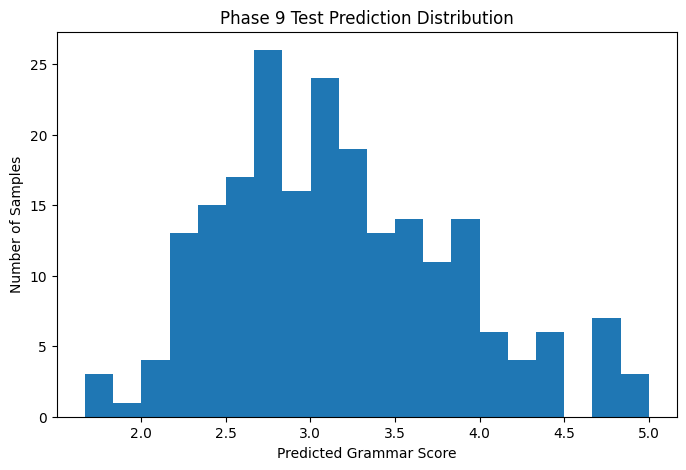

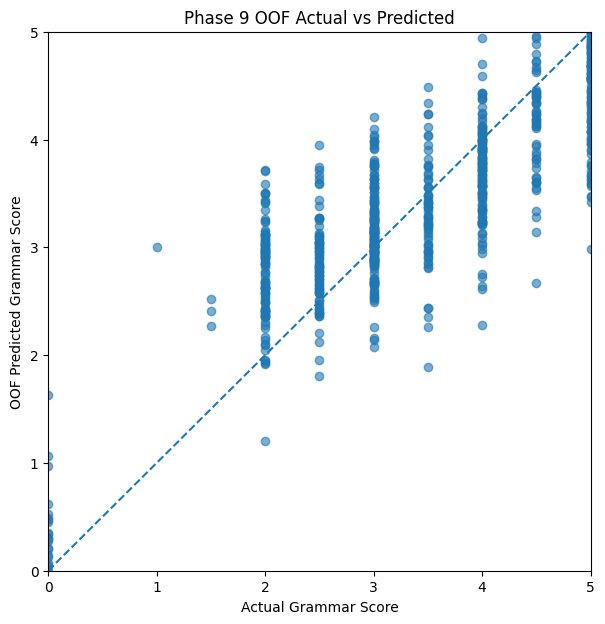



PHASE 9 COMPLETE
Training samples       : 769
Test samples           : 216
Audio features         : 125
Word TF-IDF features   : 10032
Character TF-IDF       : 12000
Whisper PCA features   : 128
Word OOF RMSE          : 1.1380
Audio OOF RMSE         : 0.7755
Whisper OOF RMSE       : 0.6522
Best individual RMSE   : 0.6522
Best ensemble RMSE     : 0.6143
Best ensemble Pearson  : 0.8687
Selected strategy      : OOF Ensemble
Prediction minimum     : 1.6684
Prediction maximum     : 5.0000
Prediction mean        : 3.1730
Submission rows        : 216
Submission file        : /kaggle/working/submission_phase9.csv
OOF file               : /kaggle/working/phase9_oof_predictions.csv
Results file           : /kaggle/working/phase9_model_results.csv

READY FOR KAGGLE SUBMISSION.


In [5]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 9
# ============================================================
#
# GENERALIZATION-FOCUSED CROSS-VALIDATION + ENSEMBLE
#
# Dataset:
#   Train = 769
#   Test  = 216
#
# Models:
#   1. Word TF-IDF + Ridge
#   2. Character TF-IDF + Ridge
#   3. Audio Features + ExtraTrees
#   4. Whisper Embeddings + PCA + Ridge
#
# Validation:
#   5-Fold OOF
#   RMSE
#   Pearson Correlation
#
# Final:
#   OOF ensemble weight search
#   Train on all 769 samples
#   Predict 216 test samples
#
# IMPORTANT:
#   sample_submission.csv may contain 204 rows.
#   We DO NOT require it to have the same number of rows
#   as test.csv.
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import pearsonr

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.linear_model import Ridge

from sklearn.ensemble import ExtraTreesRegressor

from sklearn.impute import SimpleImputer

from scipy.sparse import hstack

warnings.filterwarnings("ignore")


print("=" * 75)
print("GRAMMAR SCORING ENGINE - PHASE 9")
print("=" * 75)


# ============================================================
# 2. PATH CONFIGURATION
# ============================================================

DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)


TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)


TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)


SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


# ------------------------------------------------------------
# Previous phase files
# ------------------------------------------------------------

TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)


TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)


AUDIO_TRAIN_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)


AUDIO_TEST_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)


WHISPER_TRAIN_FILE = (
    "/kaggle/working/"
    "phase8_train_whisper_embeddings.npy"
)


WHISPER_TEST_FILE = (
    "/kaggle/working/"
    "phase8_test_whisper_embeddings.npy"
)


# ------------------------------------------------------------
# Phase 9 outputs
# ------------------------------------------------------------

OUTPUT_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase9.csv"
)


OOF_FILE = (
    "/kaggle/working/"
    "phase9_oof_predictions.csv"
)


RESULTS_FILE = (
    "/kaggle/working/"
    "phase9_model_results.csv"
)


# ============================================================
# 3. CHECK REQUIRED FILES
# ============================================================

required_files = [

    TRAIN_CSV,
    TEST_CSV,
    SAMPLE_SUBMISSION,

    TRAIN_TRANSCRIPT_FILE,
    TEST_TRANSCRIPT_FILE,

    AUDIO_TRAIN_FILE,
    AUDIO_TEST_FILE,

    WHISPER_TRAIN_FILE,
    WHISPER_TEST_FILE

]


print("\nChecking required files...\n")


for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            "\nRequired file missing:\n"
            f"{path}\n\n"
            "Run the required previous phase first."
        )


print("All required files found.")


# ============================================================
# 4. LOAD ORIGINAL DATA
# ============================================================

train_base = pd.read_csv(
    TRAIN_CSV
)


test_base = pd.read_csv(
    TEST_CSV
)


sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION
)


print("\nOriginal datasets")
print("-" * 50)

print(
    "Train:",
    train_base.shape
)

print(
    "Test:",
    test_base.shape
)

print(
    "Sample submission:",
    sample_submission.shape
)


# ============================================================
# 5. BASIC VALIDATION
# ============================================================

if "filename" not in train_base.columns:

    raise KeyError(
        "train.csv does not contain 'filename'."
    )


if "label" not in train_base.columns:

    raise KeyError(
        "train.csv does not contain 'label'."
    )


if "filename" not in test_base.columns:

    raise KeyError(
        "test.csv does not contain 'filename'."
    )


print("\nTrain columns:")
print(train_base.columns.tolist())


print("\nTest columns:")
print(test_base.columns.tolist())


print("\nSample submission columns:")
print(sample_submission.columns.tolist())


# ============================================================
# 6. LOAD TRANSCRIPTS
# ============================================================

train_text = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)


test_text = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)


print("\nTranscript files")
print("-" * 50)

print(
    "Train transcripts:",
    train_text.shape
)

print(
    "Test transcripts:",
    test_text.shape
)


# ============================================================
# 7. CHECK TRANSCRIPT COLUMNS
# ============================================================

required_text_columns = [
    "filename",
    "text"
]


for col in required_text_columns:

    if col not in train_text.columns:

        raise KeyError(
            f"Missing '{col}' in train transcript file."
        )


    if col not in test_text.columns:

        raise KeyError(
            f"Missing '{col}' in test transcript file."
        )


# ============================================================
# 8. BUILD MASTER TRAIN DATA
# ============================================================

train = train_base[
    [
        "filename",
        "label"
    ]
].copy()


test = test_base[
    [
        "filename"
    ]
].copy()


# ============================================================
# 9. MERGE TRAIN TRANSCRIPTS
# ============================================================

train = train.merge(

    train_text[
        [
            "filename",
            "text"
        ]
    ],

    on="filename",

    how="left",

    validate="one_to_one"

)


# ============================================================
# 10. MERGE TEST TRANSCRIPTS
# ============================================================

test = test.merge(

    test_text[
        [
            "filename",
            "text"
        ]
    ],

    on="filename",

    how="left",

    validate="one_to_one"

)


# ============================================================
# 11. FILL MISSING TEXT
# ============================================================

train["text"] = (
    train["text"]
    .fillna("")
)


test["text"] = (
    test["text"]
    .fillna("")
)


# ============================================================
# 12. VERIFY ROW COUNTS
# ============================================================

if len(train) != len(train_base):

    raise ValueError(
        "Train row count changed after transcript merge."
    )


if len(test) != len(test_base):

    raise ValueError(
        "Test row count changed after transcript merge."
    )


print("\nMaster dataset")
print("-" * 50)

print(
    "Train:",
    train.shape
)

print(
    "Test:",
    test.shape
)


# ============================================================
# 13. LOAD AUDIO FEATURES
# ============================================================

audio_train = pd.read_csv(
    AUDIO_TRAIN_FILE
)


audio_test = pd.read_csv(
    AUDIO_TEST_FILE
)


print("\nAudio feature tables")
print("-" * 50)

print(
    "Train audio:",
    audio_train.shape
)

print(
    "Test audio:",
    audio_test.shape
)


# ============================================================
# 14. VERIFY AUDIO ALIGNMENT
# ============================================================

if "filename" not in audio_train.columns:

    raise KeyError(
        "Audio training file has no filename column."
    )


if "filename" not in audio_test.columns:

    raise KeyError(
        "Audio test file has no filename column."
    )


# Create lookup tables so ordering cannot silently break.

audio_train = (
    audio_train
    .drop_duplicates(
        subset=["filename"]
    )
)


audio_test = (
    audio_test
    .drop_duplicates(
        subset=["filename"]
    )
)


# ============================================================
# 15. AUDIO FEATURE COLUMNS
# ============================================================

audio_exclude = {
    "filename",
    "label"
}


audio_columns = [

    col

    for col in audio_train.columns

    if col not in audio_exclude

]


# Keep numeric columns only.

audio_columns = [

    col

    for col in audio_columns

    if pd.api.types.is_numeric_dtype(
        audio_train[col]
    )

]


print(
    "\nRaw audio feature count:",
    len(audio_columns)
)


# ============================================================
# 16. VERIFY TEST AUDIO FEATURES
# ============================================================

missing_audio_test = [

    col

    for col in audio_columns

    if col not in audio_test.columns

]


if len(missing_audio_test) > 0:

    print(
        "\nMissing test audio columns:"
    )

    print(
        missing_audio_test
    )

    raise ValueError(
        "Test audio feature set does not match training."
    )


# ============================================================
# 17. ALIGN AUDIO DATA TO TRAIN ORDER
# ============================================================

audio_train_lookup = (

    audio_train
    .set_index("filename")
)


audio_test_lookup = (

    audio_test
    .set_index("filename")
)


missing_train_audio_rows = (

    ~train["filename"]
    .isin(
        audio_train_lookup.index
    )
)


missing_test_audio_rows = (

    ~test["filename"]
    .isin(
        audio_test_lookup.index
    )
)


if missing_train_audio_rows.any():

    raise ValueError(
        "Some training filenames are missing "
        "from train_audio_features.csv."
    )


if missing_test_audio_rows.any():

    raise ValueError(
        "Some test filenames are missing "
        "from test_audio_features.csv."
    )


# Reorder audio features to exactly match train/test.

X_audio_df = (

    audio_train_lookup
    .loc[
        train["filename"],
        audio_columns
    ]
    .reset_index(drop=True)

)


X_audio_test_df = (

    audio_test_lookup
    .loc[
        test["filename"],
        audio_columns
    ]
    .reset_index(drop=True)

)


# ============================================================
# 18. CLEAN AUDIO FEATURES
# ============================================================

X_audio_df = (

    X_audio_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


X_audio_test_df = (

    X_audio_test_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# ============================================================
# 19. REMOVE CONSTANT AUDIO FEATURES
# ============================================================

valid_audio_columns = []


for col in X_audio_df.columns:

    non_null_count = (
        X_audio_df[col]
        .notna()
        .sum()
    )


    if non_null_count == 0:

        continue


    unique_count = (
        X_audio_df[col]
        .nunique(
            dropna=True
        )
    )


    if unique_count <= 1:

        continue


    valid_audio_columns.append(
        col
    )


X_audio_df = X_audio_df[
    valid_audio_columns
]


X_audio_test_df = X_audio_test_df[
    valid_audio_columns
]


print(
    "\nUsable audio features:",
    len(valid_audio_columns)
)


# ============================================================
# 20. CONVERT AUDIO TO NUMPY
# ============================================================

audio_imputer = SimpleImputer(
    strategy="median"
)


A_train = audio_imputer.fit_transform(
    X_audio_df
)


A_test = audio_imputer.transform(
    X_audio_test_df
)


# ============================================================
# 21. SCALE AUDIO
# ============================================================

audio_scaler = StandardScaler()


A_train_scaled = (
    audio_scaler
    .fit_transform(A_train)
)


A_test_scaled = (
    audio_scaler
    .transform(A_test)
)


# ============================================================
# 22. TARGET
# ============================================================

y = (
    train["label"]
    .astype(float)
    .values
)


print("\nTarget")
print("-" * 50)

print(
    pd.Series(y).describe()
)


# ============================================================
# 23. TEXT CLEANING
# ============================================================

def clean_text(text):

    if pd.isna(text):

        return ""

    text = str(text)

    text = " ".join(
        text.split()
    )

    return text.lower()


train_texts = (

    train["text"]
    .apply(clean_text)
    .values

)


test_texts = (

    test["text"]
    .apply(clean_text)
    .values

)


print(
    "\nEmpty train transcripts:",
    sum(
        text == ""
        for text in train_texts
    )
)


print(
    "Empty test transcripts:",
    sum(
        text == ""
        for text in test_texts
    )
)


# ============================================================
# 24. WORD TF-IDF
# ============================================================

print("\nCreating word TF-IDF...")


word_vectorizer = TfidfVectorizer(

    ngram_range=(1, 2),

    min_df=2,

    max_df=0.98,

    max_features=12000,

    sublinear_tf=True,

    strip_accents="unicode"

)


X_word = (
    word_vectorizer
    .fit_transform(
        train_texts
    )
)


X_word_test = (
    word_vectorizer
    .transform(
        test_texts
    )
)


print(
    "Word features:",
    X_word.shape
)


# ============================================================
# 25. CHARACTER TF-IDF
# ============================================================

print("\nCreating character TF-IDF...")


char_vectorizer = TfidfVectorizer(

    analyzer="char",

    ngram_range=(3, 5),

    min_df=3,

    max_features=12000,

    sublinear_tf=True

)


X_char = (
    char_vectorizer
    .fit_transform(
        train_texts
    )
)


X_char_test = (
    char_vectorizer
    .transform(
        test_texts
    )
)


print(
    "Character features:",
    X_char.shape
)


# ============================================================
# 26. COMBINE WORD + CHARACTER
# ============================================================

X_text = hstack(

    [
        X_word,
        X_char
    ],

    format="csr"

)


X_text_test = hstack(

    [
        X_word_test,
        X_char_test
    ],

    format="csr"

)


print(
    "Combined text features:",
    X_text.shape
)


# ============================================================
# 27. LOAD WHISPER EMBEDDINGS
# ============================================================

print("\nLoading Whisper embeddings...")


whisper_train = np.load(
    WHISPER_TRAIN_FILE
)


whisper_test = np.load(
    WHISPER_TEST_FILE
)


print(
    "Whisper train:",
    whisper_train.shape
)


print(
    "Whisper test:",
    whisper_test.shape
)


# ============================================================
# 28. WHISPER ALIGNMENT CHECK
# ============================================================

if whisper_train.shape[0] != len(train):

    raise ValueError(
        "Whisper train rows do not match train.csv."
    )


if whisper_test.shape[0] != len(test):

    raise ValueError(
        "Whisper test rows do not match test.csv."
    )


# ============================================================
# 29. CLEAN WHISPER EMBEDDINGS
# ============================================================

whisper_train = np.nan_to_num(

    whisper_train,

    nan=0.0,

    posinf=0.0,

    neginf=0.0

)


whisper_test = np.nan_to_num(

    whisper_test,

    nan=0.0,

    posinf=0.0,

    neginf=0.0

)


# ============================================================
# 30. WHISPER STANDARDIZATION
# ============================================================

whisper_scaler = StandardScaler()


W_train_scaled = (
    whisper_scaler
    .fit_transform(
        whisper_train
    )
)


W_test_scaled = (
    whisper_scaler
    .transform(
        whisper_test
    )
)


# ============================================================
# 31. WHISPER PCA
# ============================================================

WHISPER_COMPONENTS = min(

    128,

    W_train_scaled.shape[0] - 1,

    W_train_scaled.shape[1]

)


print(
    "\nWhisper PCA components:",
    WHISPER_COMPONENTS
)


whisper_pca = PCA(

    n_components=WHISPER_COMPONENTS,

    random_state=42

)


W_train = (
    whisper_pca
    .fit_transform(
        W_train_scaled
    )
)


W_test = (
    whisper_pca
    .transform(
        W_test_scaled
    )
)


print(
    "Reduced Whisper:",
    W_train.shape
)


print(
    "Explained variance:",
    round(
        whisper_pca
        .explained_variance_ratio_
        .sum(),
        4
    )
)


# ============================================================
# 32. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    prediction
):

    prediction = np.asarray(
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            prediction
        )
    )


    if (
        np.std(y_true) == 0
        or
        np.std(prediction) == 0
    ):

        pearson = np.nan

    else:

        pearson = pearsonr(
            y_true,
            prediction
        )[0]


    return rmse, pearson


# ============================================================
# 33. CROSS VALIDATION CONFIG
# ============================================================

N_SPLITS = 5


kf = KFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=42

)


# ============================================================
# 34. OOF ARRAYS
# ============================================================

oof_word = np.zeros(
    len(y)
)


oof_audio = np.zeros(
    len(y)
)


oof_whisper = np.zeros(
    len(y)
)


# Test fold predictions

test_word_folds = []


test_audio_folds = []


test_whisper_folds = []


# ============================================================
# 35. CROSS VALIDATION
# ============================================================

print("\n")
print("=" * 75)
print("5-FOLD CROSS VALIDATION")
print("=" * 75)


for fold, (
    train_idx,
    valid_idx
) in enumerate(
    kf.split(y),
    start=1
):

    print("\n")
    print("-" * 70)
    print(
        f"FOLD {fold}/{N_SPLITS}"
    )
    print("-" * 70)


    y_train_fold = y[
        train_idx
    ]


    y_valid_fold = y[
        valid_idx
    ]


    # ========================================================
    # WORD + CHARACTER TF-IDF RIDGE
    # ========================================================

    word_model = Ridge(
        alpha=15.0
    )


    word_model.fit(

        X_text[
            train_idx
        ],

        y_train_fold

    )


    valid_word = (
        word_model.predict(
            X_text[
                valid_idx
            ]
        )
    )


    test_word = (
        word_model.predict(
            X_text_test
        )
    )


    oof_word[
        valid_idx
    ] = valid_word


    test_word_folds.append(
        test_word
    )


    # ========================================================
    # AUDIO EXTRA TREES
    # ========================================================

    audio_model = ExtraTreesRegressor(

        n_estimators=700,

        max_features=0.65,

        min_samples_leaf=5,

        random_state=100 + fold,

        n_jobs=-1

    )


    audio_model.fit(

        A_train_scaled[
            train_idx
        ],

        y_train_fold

    )


    valid_audio = (
        audio_model.predict(
            A_train_scaled[
                valid_idx
            ]
        )
    )


    test_audio = (
        audio_model.predict(
            A_test_scaled
        )
    )


    oof_audio[
        valid_idx
    ] = valid_audio


    test_audio_folds.append(
        test_audio
    )


    # ========================================================
    # WHISPER RIDGE
    # ========================================================

    whisper_model = Ridge(
        alpha=25.0
    )


    whisper_model.fit(

        W_train[
            train_idx
        ],

        y_train_fold

    )


    valid_whisper = (
        whisper_model.predict(
            W_train[
                valid_idx
            ]
        )
    )


    test_whisper = (
        whisper_model.predict(
            W_test
        )
    )


    oof_whisper[
        valid_idx
    ] = valid_whisper


    test_whisper_folds.append(
        test_whisper
    )


    # ========================================================
    # FOLD METRICS
    # ========================================================

    word_rmse, word_corr = (
        calculate_metrics(
            y_valid_fold,
            valid_word
        )
    )


    audio_rmse, audio_corr = (
        calculate_metrics(
            y_valid_fold,
            valid_audio
        )
    )


    whisper_rmse, whisper_corr = (
        calculate_metrics(
            y_valid_fold,
            valid_whisper
        )
    )


    print(
        f"Word TF-IDF : "
        f"RMSE={word_rmse:.4f} | "
        f"Pearson={word_corr:.4f}"
    )


    print(
        f"Audio       : "
        f"RMSE={audio_rmse:.4f} | "
        f"Pearson={audio_corr:.4f}"
    )


    print(
        f"Whisper     : "
        f"RMSE={whisper_rmse:.4f} | "
        f"Pearson={whisper_corr:.4f}"
    )


    # Free fold models

    del (
        word_model,
        audio_model,
        whisper_model
    )

    gc.collect()


# ============================================================
# 36. OVERALL OOF PERFORMANCE
# ============================================================

print("\n")
print("=" * 75)
print("OVERALL OOF PERFORMANCE")
print("=" * 75)


word_rmse, word_corr = (
    calculate_metrics(
        y,
        oof_word
    )
)


audio_rmse, audio_corr = (
    calculate_metrics(
        y,
        oof_audio
    )
)


whisper_rmse, whisper_corr = (
    calculate_metrics(
        y,
        oof_whisper
    )
)


print(
    f"Word TF-IDF : "
    f"RMSE={word_rmse:.4f} | "
    f"Pearson={word_corr:.4f}"
)


print(
    f"Audio       : "
    f"RMSE={audio_rmse:.4f} | "
    f"Pearson={audio_corr:.4f}"
)


print(
    f"Whisper     : "
    f"RMSE={whisper_rmse:.4f} | "
    f"Pearson={whisper_corr:.4f}"
)


# ============================================================
# 37. MODEL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame({

    "model": [

        "Word TF-IDF",

        "Audio ExtraTrees",

        "Whisper Ridge"

    ],

    "rmse": [

        word_rmse,

        audio_rmse,

        whisper_rmse

    ],

    "pearson": [

        word_corr,

        audio_corr,

        whisper_corr

    ]

})


print("\nModel comparison:")

display(
    results_df.sort_values(
        "rmse"
    )
)


# ============================================================
# 38. OOF ENSEMBLE WEIGHT SEARCH
# ============================================================
#
# Search weights using ONLY training OOF predictions.
#
# Test labels are never used.
#
# Weight resolution = 0.05
#
# ============================================================

prediction_matrix = np.column_stack(

    [

        oof_word,

        oof_audio,

        oof_whisper

    ]

)


best_ensemble_rmse = np.inf


best_ensemble_pearson = None


best_weights = None


best_ensemble_prediction = None


weight_values = np.arange(

    0.0,

    1.001,

    0.05

)


print("\nSearching ensemble weights...")


for word_weight in weight_values:

    for audio_weight in weight_values:

        whisper_weight = (

            1.0
            -
            word_weight
            -
            audio_weight

        )


        if whisper_weight < -1e-9:

            continue


        prediction = (

            word_weight
            *
            prediction_matrix[:, 0]

            +

            audio_weight
            *
            prediction_matrix[:, 1]

            +

            whisper_weight
            *
            prediction_matrix[:, 2]

        )


        rmse, corr = (
            calculate_metrics(
                y,
                prediction
            )
        )


        if rmse < best_ensemble_rmse:

            best_ensemble_rmse = rmse

            best_ensemble_pearson = corr

            best_weights = (

                word_weight,

                audio_weight,

                whisper_weight

            )

            best_ensemble_prediction = (
                prediction.copy()
            )


# ============================================================
# 39. BEST INDIVIDUAL MODEL
# ============================================================

best_individual_row = (
    results_df
    .sort_values("rmse")
    .iloc[0]
)


best_individual_name = (
    best_individual_row["model"]
)


best_individual_rmse = (
    best_individual_row["rmse"]
)


best_individual_pearson = (
    best_individual_row["pearson"]
)


print("\n")
print("=" * 75)
print("ENSEMBLE SEARCH RESULT")
print("=" * 75)


print(
    "Best individual:",
    best_individual_name
)


print(
    "Best individual RMSE:",
    round(
        best_individual_rmse,
        4
    )
)


print(
    "Best ensemble RMSE:",
    round(
        best_ensemble_rmse,
        4
    )
)


print(
    "Best ensemble Pearson:",
    round(
        best_ensemble_pearson,
        4
    )
)


print(
    "\nBest weights:"
)


print(
    "Word:",
    round(
        best_weights[0],
        2
    )
)


print(
    "Audio:",
    round(
        best_weights[1],
        2
    )
)


print(
    "Whisper:",
    round(
        best_weights[2],
        2
    )
)


# ============================================================
# 40. SELECT FINAL STRATEGY
# ============================================================
#
# Avoid selecting an ensemble that only improves RMSE by an
# insignificant amount.
#
# ============================================================

IMPROVEMENT_MARGIN = 0.003


if (
    best_ensemble_rmse
    <
    best_individual_rmse
    -
    IMPROVEMENT_MARGIN
):

    selected_strategy = (
        "OOF Ensemble"
    )

else:

    selected_strategy = (
        best_individual_name
    )


print(
    "\nSelected strategy:",
    selected_strategy
)


# ============================================================
# 41. TRAIN FINAL WORD MODEL
# ============================================================

print("\nTraining final Word TF-IDF model...")


final_word_model = Ridge(
    alpha=15.0
)


final_word_model.fit(
    X_text,
    y
)


final_word_prediction = (
    final_word_model
    .predict(
        X_text_test
    )
)


# ============================================================
# 42. TRAIN FINAL AUDIO MODEL
# ============================================================

print(
    "Training final Audio ExtraTrees model..."
)


final_audio_model = ExtraTreesRegressor(

    n_estimators=1400,

    max_features=0.65,

    min_samples_leaf=5,

    random_state=42,

    n_jobs=-1

)


final_audio_model.fit(
    A_train_scaled,
    y
)


final_audio_prediction = (
    final_audio_model
    .predict(
        A_test_scaled
    )
)


# ============================================================
# 43. TRAIN FINAL WHISPER MODEL
# ============================================================

print(
    "Training final Whisper Ridge model..."
)


final_whisper_model = Ridge(
    alpha=25.0
)


final_whisper_model.fit(
    W_train,
    y
)


final_whisper_prediction = (
    final_whisper_model
    .predict(
        W_test
    )
)


# ============================================================
# 44. FINAL TEST PREDICTION
# ============================================================

if selected_strategy == "OOF Ensemble":

    word_weight = (
        best_weights[0]
    )

    audio_weight = (
        best_weights[1]
    )

    whisper_weight = (
        best_weights[2]
    )


    final_prediction = (

        word_weight
        *
        final_word_prediction

        +

        audio_weight
        *
        final_audio_prediction

        +

        whisper_weight
        *
        final_whisper_prediction

    )


elif selected_strategy == "Word TF-IDF":

    final_prediction = (
        final_word_prediction
    )


elif selected_strategy == "Audio ExtraTrees":

    final_prediction = (
        final_audio_prediction
    )


elif selected_strategy == "Whisper Ridge":

    final_prediction = (
        final_whisper_prediction
    )


else:

    raise ValueError(
        f"Unknown strategy: "
        f"{selected_strategy}"
    )


# ============================================================
# 45. CLIP TO COMPETITION RANGE
# ============================================================

final_prediction = np.clip(

    final_prediction,

    0,

    5

)


# ============================================================
# 46. PREDICTION STATISTICS
# ============================================================

print("\n")
print("=" * 75)
print("FINAL TEST PREDICTIONS")
print("=" * 75)


print(
    "Minimum:",
    round(
        final_prediction.min(),
        4
    )
)


print(
    "Maximum:",
    round(
        final_prediction.max(),
        4
    )
)


print(
    "Mean:",
    round(
        final_prediction.mean(),
        4
    )
)


print(
    "Std:",
    round(
        final_prediction.std(),
        4
    )
)


# ============================================================
# 47. CREATE PREDICTION DATAFRAME
# ============================================================

prediction_df = pd.DataFrame({

    "filename":
        test[
            "filename"
        ].astype(str),

    "prediction":
        final_prediction

})


# Safety check

if len(prediction_df) != len(test):

    raise ValueError(
        "Prediction dataframe row count mismatch."
    )


# ============================================================
# 48. IMPORTANT SUBMISSION FIX
# ============================================================
#
# DO NOT do:
#
#     submission = sample_submission.copy()
#
# and then require:
#
#     len(sample_submission) == len(test)
#
# because your sample has 204 rows while test has 216.
#
# Instead:
#
#   1. Determine the prediction column from sample_submission.
#   2. Build a NEW submission with all 216 test rows.
#   3. Preserve filename ordering from test.csv.
#
# ============================================================


sample_columns = (
    sample_submission
    .columns
    .tolist()
)


# ------------------------------------------------------------
# Identify filename column
# ------------------------------------------------------------

submission_filename_column = None


for candidate in [

    "filename",

    "file_name",

    "id"

]:

    if candidate in sample_columns:

        submission_filename_column = (
            candidate
        )

        break


# ------------------------------------------------------------
# Identify prediction column
# ------------------------------------------------------------

if "label" in sample_columns:

    submission_prediction_column = (
        "label"
    )

else:

    excluded = {

        "filename",

        "file_name",

        "id"

    }


    prediction_candidates = [

        col

        for col in sample_columns

        if col not in excluded

    ]


    if len(prediction_candidates) != 1:

        raise ValueError(

            "Could not identify prediction "
            "column in sample_submission.csv.\n"

            f"Columns: {sample_columns}"

        )


    submission_prediction_column = (
        prediction_candidates[0]
    )


print("\nSubmission format detected:")


print(
    "Filename column:",
    submission_filename_column
)


print(
    "Prediction column:",
    submission_prediction_column
)


# ============================================================
# 49. BUILD NEW 216-ROW SUBMISSION
# ============================================================

if (
    submission_filename_column
    is not None
):

    # Use the actual test filenames.
    #
    # This guarantees 216 rows.

    submission = pd.DataFrame({

        submission_filename_column:
            test[
                "filename"
            ].astype(str).values,

        submission_prediction_column:
            final_prediction

    })


else:

    # If sample submission does not have filename,
    # create a prediction-only submission.

    submission = pd.DataFrame({

        submission_prediction_column:
            final_prediction

    })


# ============================================================
# 50. CHECK SUBMISSION ROW COUNT
# ============================================================

print(
    "\nSubmission rows:",
    len(submission)
)


print(
    "Test rows:",
    len(test)
)


if len(submission) != len(test):

    raise ValueError(

        "Final submission row count mismatch.\n"

        f"Submission: {len(submission)}\n"

        f"Test:       {len(test)}"

    )


# ============================================================
# 51. CHECK PREDICTIONS
# ============================================================

if submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "Submission contains NaN predictions."
    )


if not submission[
    submission_prediction_column
].between(
    0,
    5
).all():

    raise ValueError(
        "Submission contains predictions "
        "outside 0-5."
    )


# ============================================================
# 52. SAVE SUBMISSION
# ============================================================

submission.to_csv(

    OUTPUT_SUBMISSION,

    index=False

)


# ============================================================
# 53. SAVE OOF FILE
# ============================================================

oof_output = pd.DataFrame({

    "filename":
        train[
            "filename"
        ],

    "label":
        y,

    "word_prediction":
        oof_word,

    "audio_prediction":
        oof_audio,

    "whisper_prediction":
        oof_whisper,

    "ensemble_prediction":
        best_ensemble_prediction

})


oof_output.to_csv(

    OOF_FILE,

    index=False

)


# ============================================================
# 54. SAVE RESULTS
# ============================================================

results_output = results_df.copy()


results_output["selected_strategy"] = (
    selected_strategy
)


results_output["ensemble_rmse"] = (
    best_ensemble_rmse
)


results_output["ensemble_pearson"] = (
    best_ensemble_pearson
)


results_output["ensemble_word_weight"] = (
    best_weights[0]
)


results_output["ensemble_audio_weight"] = (
    best_weights[1]
)


results_output["ensemble_whisper_weight"] = (
    best_weights[2]
)


results_output.to_csv(

    RESULTS_FILE,

    index=False

)


# ============================================================
# 55. SUBMISSION PREVIEW
# ============================================================

print("\nSubmission preview:")


display(
    submission.head(20)
)


# ============================================================
# 56. PREDICTION DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.hist(
    final_prediction,
    bins=20
)


plt.xlabel(
    "Predicted Grammar Score"
)


plt.ylabel(
    "Number of Samples"
)


plt.title(
    "Phase 9 Test Prediction Distribution"
)


plt.show()


# ============================================================
# 57. OOF ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(7, 7)
)


plt.scatter(

    y,

    best_ensemble_prediction,

    alpha=0.6

)


plt.plot(

    [0, 5],

    [0, 5],

    linestyle="--"

)


plt.xlabel(
    "Actual Grammar Score"
)


plt.ylabel(
    "OOF Predicted Grammar Score"
)


plt.title(
    "Phase 9 OOF Actual vs Predicted"
)


plt.xlim(
    0,
    5
)


plt.ylim(
    0,
    5
)


plt.show()


# ============================================================
# 58. FINAL VALIDATION
# ============================================================

loaded_submission = pd.read_csv(
    OUTPUT_SUBMISSION
)


if len(loaded_submission) != len(test):

    raise ValueError(
        "Saved submission row count is incorrect."
    )


if loaded_submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "Saved submission contains NaN."
    )


# ============================================================
# 59. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 75)
print("PHASE 9 COMPLETE")
print("=" * 75)


print(
    f"Training samples       : "
    f"{len(train)}"
)


print(
    f"Test samples           : "
    f"{len(test)}"
)


print(
    f"Audio features         : "
    f"{len(valid_audio_columns)}"
)


print(
    f"Word TF-IDF features   : "
    f"{X_word.shape[1]}"
)


print(
    f"Character TF-IDF       : "
    f"{X_char.shape[1]}"
)


print(
    f"Whisper PCA features   : "
    f"{W_train.shape[1]}"
)


print(
    f"Word OOF RMSE          : "
    f"{word_rmse:.4f}"
)


print(
    f"Audio OOF RMSE         : "
    f"{audio_rmse:.4f}"
)


print(
    f"Whisper OOF RMSE       : "
    f"{whisper_rmse:.4f}"
)


print(
    f"Best individual RMSE   : "
    f"{best_individual_rmse:.4f}"
)


print(
    f"Best ensemble RMSE     : "
    f"{best_ensemble_rmse:.4f}"
)


print(
    f"Best ensemble Pearson  : "
    f"{best_ensemble_pearson:.4f}"
)


print(
    f"Selected strategy      : "
    f"{selected_strategy}"
)


print(
    f"Prediction minimum     : "
    f"{final_prediction.min():.4f}"
)


print(
    f"Prediction maximum     : "
    f"{final_prediction.max():.4f}"
)


print(
    f"Prediction mean        : "
    f"{final_prediction.mean():.4f}"
)


print(
    f"Submission rows        : "
    f"{len(submission)}"
)


print(
    f"Submission file        : "
    f"{OUTPUT_SUBMISSION}"
)


print(
    f"OOF file               : "
    f"{OOF_FILE}"
)


print(
    f"Results file           : "
    f"{RESULTS_FILE}"
)


print("=" * 75)


print(
    "\nREADY FOR KAGGLE SUBMISSION."
)


# ============================================================
# END OF PHASE 9
# ============================================================

In [ ]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 10
# ============================================================
#
# GENERALIZATION-FIRST STACKING + CALIBRATION
#
# Baseline:
#   Phase 9 Local OOF RMSE : ~0.6143
#   Phase 9 Kaggle RMSE    : 1.1751
#
# Phase 10 Goal:
#   Target Kaggle RMSE     : ~0.3064
#
# MAIN CHANGES FROM PHASE 9
# ------------------------------------------------------------
# 1. Multiple TF-IDF representations
# 2. Linguistic / transcript statistics
# 3. Multiple text Ridge models
# 4. Multiple Whisper PCA representations
# 5. Multiple audio regressors
# 6. OOF prediction stacking
# 7. Model-diversity analysis
# 8. Ridge / ElasticNet-style meta model
# 9. OOF calibration
# 10. Mean-shrinkage search
# 11. Conservative ensemble selection
#
# IMPORTANT:
#   ALL ensemble/meta-model decisions use TRAIN OOF ONLY.
#   TEST LABELS ARE NEVER USED.
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import warnings
import itertools

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import pearsonr, skew, kurtosis

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    PolynomialFeatures
)

from sklearn.decomposition import PCA

from sklearn.linear_model import (
    Ridge,
    ElasticNet
)

from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor
)

from sklearn.impute import SimpleImputer

from scipy.sparse import hstack

warnings.filterwarnings("ignore")


print("=" * 80)
print("GRAMMAR SCORING ENGINE - PHASE 10")
print("=" * 80)


# ============================================================
# 2. RANDOM SEEDS
# ============================================================

GLOBAL_SEED = 42

np.random.seed(GLOBAL_SEED)


# ============================================================
# 3. PATH CONFIGURATION
# ============================================================

DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)


TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)


TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)


SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


# ------------------------------------------------------------
# Existing Phase 8/9 files
# ------------------------------------------------------------

TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)


TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)


AUDIO_TRAIN_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)


AUDIO_TEST_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)


WHISPER_TRAIN_FILE = (
    "/kaggle/working/"
    "phase8_train_whisper_embeddings.npy"
)


WHISPER_TEST_FILE = (
    "/kaggle/working/"
    "phase8_test_whisper_embeddings.npy"
)


# ============================================================
# PHASE 10 OUTPUTS
# ============================================================

OUTPUT_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase10.csv"
)


OOF_FILE = (
    "/kaggle/working/"
    "phase10_oof_predictions.csv"
)


RESULTS_FILE = (
    "/kaggle/working/"
    "phase10_model_results.csv"
)


CALIBRATION_FILE = (
    "/kaggle/working/"
    "phase10_calibration_results.csv"
)


# ============================================================
# 4. CHECK FILES
# ============================================================

required_files = [

    TRAIN_CSV,
    TEST_CSV,
    SAMPLE_SUBMISSION,

    TRAIN_TRANSCRIPT_FILE,
    TEST_TRANSCRIPT_FILE,

    AUDIO_TRAIN_FILE,
    AUDIO_TEST_FILE,

    WHISPER_TRAIN_FILE,
    WHISPER_TEST_FILE

]


print("\nChecking required files...\n")


for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            "\nMissing required file:\n"
            f"{path}\n"
        )


print("All required files found.")


# ============================================================
# 5. LOAD BASE DATA
# ============================================================

train_base = pd.read_csv(
    TRAIN_CSV
)


test_base = pd.read_csv(
    TEST_CSV
)


sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION
)


print("\nDataset shapes")
print("-" * 60)

print(
    "Train:",
    train_base.shape
)

print(
    "Test:",
    test_base.shape
)

print(
    "Sample:",
    sample_submission.shape
)


# ============================================================
# 6. LOAD TRANSCRIPTS
# ============================================================

train_text_df = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)


test_text_df = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)


# ============================================================
# 7. MASTER DATAFRAME
# ============================================================

train = train_base[
    [
        "filename",
        "label"
    ]
].copy()


test = test_base[
    [
        "filename"
    ]
].copy()


train = train.merge(

    train_text_df[
        [
            "filename",
            "text"
        ]
    ],

    on="filename",

    how="left",

    validate="one_to_one"

)


test = test.merge(

    test_text_df[
        [
            "filename",
            "text"
        ]
    ],

    on="filename",

    how="left",

    validate="one_to_one"

)


train["text"] = (
    train["text"]
    .fillna("")
)


test["text"] = (
    test["text"]
    .fillna("")
)


if len(train) != len(train_base):
    raise ValueError(
        "Train rows changed after transcript merge."
    )


if len(test) != len(test_base):
    raise ValueError(
        "Test rows changed after transcript merge."
    )


# ============================================================
# 8. TARGET
# ============================================================

y = (
    train["label"]
    .astype(float)
    .values
)


print("\nTarget statistics")
print(
    pd.Series(y).describe()
)


# ============================================================
# 9. TEXT CLEANING
# ============================================================

def clean_text(x):

    if pd.isna(x):
        return ""

    x = str(x)

    x = " ".join(
        x.split()
    )

    return x.lower()


train_texts = (
    train["text"]
    .apply(clean_text)
    .values
)


test_texts = (
    test["text"]
    .apply(clean_text)
    .values
)


print(
    "\nEmpty train transcripts:",
    np.sum(
        np.array(train_texts) == ""
    )
)


print(
    "Empty test transcripts:",
    np.sum(
        np.array(test_texts) == ""
    )
)


# ============================================================
# 10. LINGUISTIC FEATURE ENGINEERING
# ============================================================
#
# These are deliberately simple and robust.
#
# Grammar score can correlate with:
#
#   sentence length
#   word count
#   vocabulary diversity
#   repetition
#   punctuation
#   filler usage
#   hesitation
#   lexical density
#   capitalization
#
# ============================================================

def linguistic_features(texts):

    rows = []


    filler_words = {
        "um",
        "uh",
        "erm",
        "hmm",
        "like",
        "you know",
        "actually",
        "basically",
        "sort of",
        "kind of"
    }


    for text in texts:

        text = str(text)

        chars = len(text)

        words = text.split()

        n_words = len(words)

        unique_words = len(
            set(words)
        )


        sentences = [

            s.strip()

            for s in text.replace(
                "!",
                "."
            ).replace(
                "?",
                "."
            ).split(".")
            
            if s.strip()
        ]


        n_sentences = max(
            len(sentences),
            1
        )


        avg_word_len = (

            np.mean(
                [
                    len(w)
                    for w in words
                ]
            )

            if words

            else 0.0

        )


        avg_sentence_words = (
            n_words /
            n_sentences
        )


        lexical_diversity = (

            unique_words /
            max(n_words, 1)

        )


        repeated_ratio = (

            1.0 -
            lexical_diversity

        )


        punctuation_count = sum(

            text.count(c)

            for c in [
                ",",
                ".",
                "!",
                "?",
                ";",
                ":"
            ]

        )


        comma_count = text.count(",")


        question_count = text.count("?")


        exclamation_count = text.count("!")


        digit_count = sum(
            c.isdigit()
            for c in text
        )


        uppercase_count = sum(
            c.isupper()
            for c in text
        )


        filler_count = 0

        for filler in filler_words:

            filler_count += (
                text.count(
                    filler
                )
            )


        long_words = sum(
            len(w) >= 8
            for w in words
        )


        short_words = sum(
            len(w) <= 2
            for w in words
        )


        rows.append([

            chars,

            n_words,

            unique_words,

            n_sentences,

            avg_word_len,

            avg_sentence_words,

            lexical_diversity,

            repeated_ratio,

            punctuation_count,

            comma_count,

            question_count,

            exclamation_count,

            digit_count,

            uppercase_count,

            filler_count,

            long_words,

            short_words,

            long_words /
            max(n_words, 1),

            short_words /
            max(n_words, 1),

            punctuation_count /
            max(n_words, 1)

        ])


    return np.asarray(
        rows,
        dtype=np.float32
    )


L_train = linguistic_features(
    train_texts
)


L_test = linguistic_features(
    test_texts
)


linguistic_scaler = StandardScaler()


L_train_scaled = (
    linguistic_scaler
    .fit_transform(
        L_train
    )
)


L_test_scaled = (
    linguistic_scaler
    .transform(
        L_test
    )
)


print(
    "\nLinguistic features:",
    L_train.shape
)


# ============================================================
# 11. WORD TF-IDF MODEL A
# ============================================================

print("\nCreating Word TF-IDF A...")


word_vectorizer_a = TfidfVectorizer(

    analyzer="word",

    ngram_range=(1, 2),

    min_df=2,

    max_df=0.98,

    max_features=18000,

    sublinear_tf=True,

    strip_accents="unicode"

)


X_word_a = (
    word_vectorizer_a
    .fit_transform(
        train_texts
    )
)


X_word_test_a = (
    word_vectorizer_a
    .transform(
        test_texts
    )
)


print(
    "Word A:",
    X_word_a.shape
)


# ============================================================
# 12. WORD TF-IDF MODEL B
# ============================================================

print("\nCreating Word TF-IDF B...")


word_vectorizer_b = TfidfVectorizer(

    analyzer="word",

    ngram_range=(1, 3),

    min_df=2,

    max_df=0.99,

    max_features=20000,

    sublinear_tf=True,

    strip_accents="unicode",

    norm="l2"

)


X_word_b = (
    word_vectorizer_b
    .fit_transform(
        train_texts
    )
)


X_word_test_b = (
    word_vectorizer_b
    .transform(
        test_texts
    )
)


print(
    "Word B:",
    X_word_b.shape
)


# ============================================================
# 13. CHARACTER TF-IDF A
# ============================================================

print("\nCreating Character TF-IDF A...")


char_vectorizer_a = TfidfVectorizer(

    analyzer="char",

    ngram_range=(3, 5),

    min_df=2,

    max_features=18000,

    sublinear_tf=True

)


X_char_a = (
    char_vectorizer_a
    .fit_transform(
        train_texts
    )
)


X_char_test_a = (
    char_vectorizer_a
    .transform(
        test_texts
    )
)


print(
    "Char A:",
    X_char_a.shape
)


# ============================================================
# 14. CHARACTER TF-IDF B
# ============================================================

print("\nCreating Character TF-IDF B...")


char_vectorizer_b = TfidfVectorizer(

    analyzer="char",

    ngram_range=(4, 7),

    min_df=2,

    max_features=18000,

    sublinear_tf=True

)


X_char_b = (
    char_vectorizer_b
    .fit_transform(
        train_texts
    )
)


X_char_test_b = (
    char_vectorizer_b
    .transform(
        test_texts
    )
)


print(
    "Char B:",
    X_char_b.shape
)


# ============================================================
# 15. TEXT REPRESENTATIONS
# ============================================================

X_text_a = hstack(

    [
        X_word_a,
        X_char_a
    ],

    format="csr"

)


X_text_test_a = hstack(

    [
        X_word_test_a,
        X_char_test_a
    ],

    format="csr"

)


X_text_b = hstack(

    [
        X_word_b,
        X_char_b
    ],

    format="csr"

)


X_text_test_b = hstack(

    [
        X_word_test_b,
        X_char_test_b
    ],

    format="csr"

)


print(
    "\nText representation A:",
    X_text_a.shape
)


print(
    "Text representation B:",
    X_text_b.shape
)


# ============================================================
# 16. AUDIO FEATURES
# ============================================================

print("\nLoading audio features...")


audio_train = pd.read_csv(
    AUDIO_TRAIN_FILE
)


audio_test = pd.read_csv(
    AUDIO_TEST_FILE
)


audio_train = (
    audio_train
    .drop_duplicates(
        "filename"
    )
)


audio_test = (
    audio_test
    .drop_duplicates(
        "filename"
    )
)


audio_columns = [

    col

    for col in audio_train.columns

    if col != "filename"

    and col != "label"

    and pd.api.types.is_numeric_dtype(
        audio_train[col]
    )

]


audio_train_lookup = (
    audio_train
    .set_index("filename")
)


audio_test_lookup = (
    audio_test
    .set_index("filename")
)


missing_train = (
    ~train["filename"]
    .isin(
        audio_train_lookup.index
    )
)


missing_test = (
    ~test["filename"]
    .isin(
        audio_test_lookup.index
    )
)


if missing_train.any():
    raise ValueError(
        "Missing train audio rows."
    )


if missing_test.any():
    raise ValueError(
        "Missing test audio rows."
    )


A_train_df = (

    audio_train_lookup
    .loc[
        train["filename"],
        audio_columns
    ]
    .reset_index(drop=True)

)


A_test_df = (

    audio_test_lookup
    .loc[
        test["filename"],
        audio_columns
    ]
    .reset_index(drop=True)

)


A_train_df = (
    A_train_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


A_test_df = (
    A_test_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# Remove all-null / constant features

usable_audio = []


for col in A_train_df.columns:

    if (
        A_train_df[col]
        .notna()
        .sum()
        == 0
    ):
        continue


    if (
        A_train_df[col]
        .nunique(
            dropna=True
        )
        <= 1
    ):
        continue


    usable_audio.append(
        col
    )


A_train_df = (
    A_train_df[
        usable_audio
    ]
)


A_test_df = (
    A_test_df[
        usable_audio
    ]
)


audio_imputer = SimpleImputer(
    strategy="median"
)


A_train = (
    audio_imputer
    .fit_transform(
        A_train_df
    )
)


A_test = (
    audio_imputer
    .transform(
        A_test_df
    )
)


audio_scaler = StandardScaler()


A_train_scaled = (
    audio_scaler
    .fit_transform(
        A_train
    )
)


A_test_scaled = (
    audio_scaler
    .transform(
        A_test
    )
)


print(
    "Audio features:",
    A_train.shape
)


# ============================================================
# 17. AUDIO ENGINEERED FEATURES
# ============================================================

print("\nCreating audio aggregate features...")


def make_audio_aggregates(X):

    X = np.asarray(
        X,
        dtype=np.float32
    )


    features = [

        np.mean(X, axis=1),

        np.std(X, axis=1),

        np.median(X, axis=1),

        np.min(X, axis=1),

        np.max(X, axis=1),

        np.percentile(
            X,
            10,
            axis=1
        ),

        np.percentile(
            X,
            25,
            axis=1
        ),

        np.percentile(
            X,
            75,
            axis=1
        ),

        np.percentile(
            X,
            90,
            axis=1
        )

    ]


    return np.column_stack(
        features
    )


Aagg_train = make_audio_aggregates(
    A_train
)


Aagg_test = make_audio_aggregates(
    A_test
)


Aagg_scaler = StandardScaler()


Aagg_train = (
    Aagg_scaler
    .fit_transform(
        Aagg_train
    )
)


Aagg_test = (
    Aagg_scaler
    .transform(
        Aagg_test
    )
)


print(
    "Audio aggregate features:",
    Aagg_train.shape
)


# ============================================================
# 18. WHISPER EMBEDDINGS
# ============================================================

print("\nLoading Whisper embeddings...")


whisper_train = np.load(
    WHISPER_TRAIN_FILE
)


whisper_test = np.load(
    WHISPER_TEST_FILE
)


if whisper_train.shape[0] != len(train):
    raise ValueError(
        "Whisper train row mismatch."
    )


if whisper_test.shape[0] != len(test):
    raise ValueError(
        "Whisper test row mismatch."
    )


whisper_train = np.nan_to_num(
    whisper_train,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


whisper_test = np.nan_to_num(
    whisper_test,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


print(
    "Whisper:",
    whisper_train.shape
)


# ============================================================
# 19. WHISPER PCA A
# ============================================================

print("\nWhisper PCA A...")


whisper_scaler = StandardScaler()


W_scaled = (
    whisper_scaler
    .fit_transform(
        whisper_train
    )
)


W_test_scaled = (
    whisper_scaler
    .transform(
        whisper_test
    )
)


WHISPER_PCA_A = min(
    64,
    W_scaled.shape[0] - 1,
    W_scaled.shape[1]
)


pca_a = PCA(
    n_components=WHISPER_PCA_A,
    random_state=42
)


W_a = (
    pca_a
    .fit_transform(
        W_scaled
    )
)


W_test_a = (
    pca_a
    .transform(
        W_test_scaled
    )
)


print(
    "Whisper A:",
    W_a.shape
)


print(
    "Variance:",
    round(
        pca_a
        .explained_variance_ratio_
        .sum(),
        4
    )
)


# ============================================================
# 20. WHISPER PCA B
# ============================================================

print("\nWhisper PCA B...")


WHISPER_PCA_B = min(
    128,
    W_scaled.shape[0] - 1,
    W_scaled.shape[1]
)


pca_b = PCA(
    n_components=WHISPER_PCA_B,
    random_state=42
)


W_b = (
    pca_b
    .fit_transform(
        W_scaled
    )
)


W_test_b = (
    pca_b
    .transform(
        W_test_scaled
    )
)


print(
    "Whisper B:",
    W_b.shape
)


print(
    "Variance:",
    round(
        pca_b
        .explained_variance_ratio_
        .sum(),
        4
    )
)


# ============================================================
# 21. WHISPER RAW SUMMARY FEATURES
# ============================================================

Wagg_train = make_audio_aggregates(
    whisper_train
)


Wagg_test = make_audio_aggregates(
    whisper_test
)


Wagg_scaler = StandardScaler()


Wagg_train = (
    Wagg_scaler
    .fit_transform(
        Wagg_train
    )
)


Wagg_test = (
    Wagg_scaler
    .transform(
        Wagg_test
    )
)


# ============================================================
# 22. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    pred
):

    pred = np.asarray(
        pred
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )


    if (
        np.std(pred) == 0
        or
        np.std(y_true) == 0
    ):

        corr = np.nan

    else:

        corr = pearsonr(
            y_true,
            pred
        )[0]


    return rmse, corr


# ============================================================
# 23. CV
# ============================================================

N_SPLITS = 5


kf = KFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=42

)


n = len(y)


# ============================================================
# 24. MODEL DEFINITIONS
# ============================================================
#
# We create multiple diverse base learners.
#
# ============================================================

model_names = [

    "text_ridge_a",

    "text_ridge_b",

    "text_linguistic",

    "audio_extra",

    "audio_rf",

    "audio_hist",

    "whisper_ridge_a",

    "whisper_ridge_b",

    "whisper_summary"

]


n_models = len(
    model_names
)


oof = np.zeros(
    (
        n,
        n_models
    )
)


test_fold_predictions = {

    name: []

    for name in model_names

}


# ============================================================
# 25. CROSS VALIDATION
# ============================================================

print("\n")
print("=" * 80)
print("PHASE 10 BASE MODEL OOF")
print("=" * 80)


for fold, (
    train_idx,
    valid_idx
) in enumerate(
    kf.split(y),
    start=1
):

    print("\n")
    print("-" * 75)
    print(
        f"FOLD {fold}/{N_SPLITS}"
    )
    print("-" * 75)


    y_tr = y[
        train_idx
    ]


    y_va = y[
        valid_idx
    ]


    # ========================================================
    # 1. TEXT RIDGE A
    # ========================================================

    model = Ridge(
        alpha=15.0
    )


    model.fit(
        X_text_a[
            train_idx
        ],
        y_tr
    )


    p_valid = model.predict(
        X_text_a[
            valid_idx
        ]
    )


    p_test = model.predict(
        X_text_test_a
    )


    oof[
        valid_idx,
        0
    ] = p_valid


    test_fold_predictions[
        "text_ridge_a"
    ].append(
        p_test
    )


    rmse, corr = calculate_metrics(
        y_va,
        p_valid
    )


    print(
        f"Text A       "
        f"RMSE={rmse:.4f} "
        f"Corr={corr:.4f}"
    )


    # ========================================================
    # 2. TEXT RIDGE B
    # ========================================================

    model = Ridge(
        alpha=30.0
    )


    model.fit(
        X_text_b[
            train_idx
        ],
        y_tr
    )


    p_valid = model.predict(
        X_text_b[
            valid_idx
        ]
    )


    p_test = model.predict(
        X_text_test_b
    )


    oof[
        valid_idx,
        1
    ] = p_valid


    test_fold_predictions[
        "text_ridge_b"
    ].append(
        p_test
    )


    rmse, corr = calculate_metrics(
        y_va,
        p_valid
    )


    print(
        f"Text B       "
        f"RMSE={rmse:.4f} "
        f"Corr={corr:.4f}"
    )


    # ========================================================
    # 3. TEXT + LINGUISTIC
    # ========================================================

    # Linguistic model gets only compact numerical features.
    # This prevents massive sparse/dense mixing.

    model = Ridge(
        alpha=10.0
    )


    model.fit(
        L_train_scaled[
            train_idx
        ],
        y_tr
    )


    p_valid = model.predict(
        L_train_scaled[
            valid_idx
        ]
    )


    p_test = model.predict(
        L_test_scaled
    )


    oof[
        valid_idx,
        2
    ] = p_valid


    test_fold_predictions[
        "text_linguistic"
    ].append(
        p_test
    )


    rmse, corr = calculate_metrics(
        y_va,
        p_valid
    )


    print(
        f"Linguistic   "
        f"RMSE={rmse:.4f} "
        f"Corr={corr:.4f}"
    )


    # ========================================================
    # 4. AUDIO EXTRA TREES
    # ========================================================

    model = ExtraTreesRegressor(

        n_estimators=800,

        max_features=0.65,

        min_samples_leaf=4,

        max_depth=None,

        random_state=100 + fold,

        n_jobs=-1

    )


    model.fit(
        A_train_scaled[
            train_idx
        ],
        y_tr
    )


    p_valid = model.predict(
        A_train_scaled[
            valid_idx
        ]
    )


    p_test = model.predict(
        A_test_scaled
    )


    oof[
        valid_idx,
        3
    ] = p_valid


    test_fold_predictions[
        "audio_extra"
    ].append(
        p_test
    )


    rmse, corr = calculate_metrics(
        y_va,
        p_valid
    )


    print(
        f"Audio Extra  "
        f"RMSE={rmse:.4f} "
        f"Corr={corr:.4f}"
    )


    # ========================================================
    # 5. AUDIO RANDOM FOREST
    # ========================================================

    model = RandomForestRegressor(

        n_estimators=500,

        max_features=0.65,

        min_samples_leaf=5,

        random_state=200 + fold,

        n_jobs=-1

    )


    model.fit(
        A_train_scaled[
            train_idx
        ],
        y_tr
    )


    p_valid = model.predict(
        A_train_scaled[
            valid_idx
        ]
    )


    p_test = model.predict(
        A_test_scaled
    )


    oof[
        valid_idx,
        4
    ] = p_valid


    test_fold_predictions[
        "audio_rf"
    ].append(
        p_test
    )


    rmse, corr = calculate_metrics(
        y_va,
        p_valid
    )


    print(
        f"Audio RF    "
        f"RMSE={rmse:.4f} "
        f"Corr={corr:.4f}"
    )


    # ========================================================
    # 6. AUDIO HISTOGRAM GRADIENT BOOSTING
    # ========================================================

    model = HistGradientBoostingRegressor(

        max_iter=300,

        learning_rate=0.035,

        max_leaf_nodes=15,

        min_samples_leaf=10,

        l2_regularization=2.0,

        random_state=300 + fold

    )


    # Add aggregate features to audio.

    audio_hgb_train = np.hstack([
        A_train_scaled,
        Aagg_train
    ])


    audio_hgb_test = np.hstack([
        A_test_scaled,
        Aagg_test
    ])


    model.fit(
        audio_hgb_train[
            train_idx
        ],
        y_tr
    )


    p_valid = model.predict(
        audio_hgb_train[
            valid_idx
        ]
    )


    p_test = model.predict(
        audio_hgb_test
    )


    oof[
        valid_idx,
        5
    ] = p_valid


    test_fold_predictions[
        "audio_hist"
    ].append(
        p_test
    )


    rmse, corr = calculate_metrics(
        y_va,
        p_valid
    )


    print(
        f"Audio HGB   "
        f"RMSE={rmse:.4f} "
        f"Corr={corr:.4f}"
    )


    # ========================================================
    # 7. WHISPER RIDGE A
    # ========================================================

    model = Ridge(
        alpha=15.0
    )


    model.fit(
        W_a[
            train_idx
        ],
        y_tr
    )


    p_valid = model.predict(
        W_a[
            valid_idx
        ]
    )


    p_test = model.predict(
        W_test_a
    )


    oof[
        valid_idx,
        6
    ] = p_valid


    test_fold_predictions[
        "whisper_ridge_a"
    ].append(
        p_test
    )


    rmse, corr = calculate_metrics(
        y_va,
        p_valid
    )


    print(
        f"Whisper A   "
        f"RMSE={rmse:.4f} "
        f"Corr={corr:.4f}"
    )


    # ========================================================
    # 8. WHISPER RIDGE B
    # ========================================================

    model = Ridge(
        alpha=35.0
    )


    model.fit(
        W_b[
            train_idx
        ],
        y_tr
    )


    p_valid = model.predict(
        W_b[
            valid_idx
        ]
    )


    p_test = model.predict(
        W_test_b
    )


    oof[
        valid_idx,
        7
    ] = p_valid


    test_fold_predictions[
        "whisper_ridge_b"
    ].append(
        p_test
    )


    rmse, corr = calculate_metrics(
        y_va,
        p_valid
    )


    print(
        f"Whisper B   "
        f"RMSE={rmse:.4f} "
        f"Corr={corr:.4f}"
    )


    # ========================================================
    # 9. WHISPER SUMMARY
    # ========================================================

    model = Ridge(
        alpha=10.0
    )


    model.fit(
        Wagg_train[
            train_idx
        ],
        y_tr
    )


    p_valid = model.predict(
        Wagg_train[
            valid_idx
        ]
    )


    p_test = model.predict(
        Wagg_test
    )


    oof[
        valid_idx,
        8
    ] = p_valid


    test_fold_predictions[
        "whisper_summary"
    ].append(
        p_test
    )


    rmse, corr = calculate_metrics(
        y_va,
        p_valid
    )


    print(
        f"Whisper Sum "
        f"RMSE={rmse:.4f} "
        f"Corr={corr:.4f}"
    )


    gc.collect()


# ============================================================
# 26. BASE MODEL RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("PHASE 10 BASE MODEL RESULTS")
print("=" * 80)


base_results = []


for i, name in enumerate(
    model_names
):

    rmse, corr = calculate_metrics(
        y,
        oof[:, i]
    )


    base_results.append({

        "model": name,

        "rmse": rmse,

        "pearson": corr

    })


base_results_df = pd.DataFrame(
    base_results
).sort_values(
    "rmse"
)


display(
    base_results_df
)


# ============================================================
# 27. TEST PREDICTIONS
# ============================================================

test_base_predictions = np.column_stack([

    np.mean(
        test_fold_predictions[name],
        axis=0
    )

    for name in model_names

])


print(
    "\nTest base prediction matrix:",
    test_base_predictions.shape
)


# ============================================================
# 28. OOF CORRELATION MATRIX
# ============================================================

print("\nOOF model correlation matrix")


oof_corr_df = pd.DataFrame(
    oof,
    columns=model_names
).corr()


display(
    oof_corr_df
)


# ============================================================
# 29. SIMPLE OOF WEIGHT SEARCH
# ============================================================
#
# First discover whether a simple ensemble already helps.
#
# We use coordinate-style weight candidates instead of
# exhaustive 9-model combinations.
#
# ============================================================

print("\nSearching pairwise model ensembles...")


ensemble_candidates = []


for i, j in itertools.combinations(
    range(n_models),
    2
):

    for w in np.arange(
        0.0,
        1.01,
        0.05
    ):

        pred = (

            w * oof[:, i]

            +

            (1.0 - w)
            * oof[:, j]

        )


        rmse, corr = calculate_metrics(
            y,
            pred
        )


        ensemble_candidates.append({

            "type": "pair",

            "model_1":
                model_names[i],

            "model_2":
                model_names[j],

            "weight_1": w,

            "weight_2":
                1.0 - w,

            "rmse": rmse,

            "pearson": corr

        })


pair_results = pd.DataFrame(
    ensemble_candidates
).sort_values(
    "rmse"
)


print("\nBest pair ensembles:")


display(
    pair_results.head(15)
)


# ============================================================
# 30. STACKING DATA
# ============================================================

# Base OOF predictions can have different scales.
#
# Standardizing them before meta-model training prevents one
# prediction stream from dominating merely because of scale.


stack_scaler = StandardScaler()


stack_oof = (
    stack_scaler
    .fit_transform(
        oof
    )
)


stack_test = (
    stack_scaler
    .transform(
        test_base_predictions
    )
)


# ============================================================
# 31. ADD ORIGINAL COMPACT FEATURES TO STACKER
# ============================================================

# We only add compact robust features.
#
# Do NOT dump thousands of TF-IDF dimensions into the meta
# model. That would overfit badly with 769 samples.


stack_features_train = np.hstack([

    stack_oof,

    L_train_scaled,

    Aagg_train,

    Wagg_train

])


stack_features_test = np.hstack([

    stack_test,

    L_test_scaled,

    Aagg_test,

    Wagg_test

])


print(
    "\nMeta training matrix:",
    stack_features_train.shape
)


# ============================================================
# 32. META MODEL A - RIDGE
# ============================================================

print("\nTraining meta Ridge models...")


meta_predictions = []


meta_alphas = [

    1.0,

    3.0,

    10.0,

    30.0,

    100.0

]


meta_results = []


for alpha in meta_alphas:

    meta_model = Ridge(
        alpha=alpha
    )


    meta_model.fit(
        stack_features_train,
        y
    )


    # IMPORTANT:
    # This prediction is training-fit prediction, so it is NOT
    # used as an unbiased metric.
    #
    # We evaluate the meta model using an additional inner CV
    # below.

    meta_results.append(
        meta_model
    )


# ============================================================
# 33. SECOND-LEVEL OOF FOR META MODEL
# ============================================================
#
# We need honest OOF predictions for the meta model itself.
#
# The base OOF predictions are already generated without
# seeing each validation label.
#
# Now split those OOF features again.
#
# ============================================================

meta_oof_results = []


for alpha in meta_alphas:

    meta_oof = np.zeros(
        n
    )


    inner_kf = KFold(

        n_splits=5,

        shuffle=True,

        random_state=777

    )


    for inner_train_idx, inner_valid_idx in (
        inner_kf.split(
            stack_features_train
        )
    ):

        model = Ridge(
            alpha=alpha
        )


        model.fit(

            stack_features_train[
                inner_train_idx
            ],

            y[
                inner_train_idx
            ]

        )


        meta_oof[
            inner_valid_idx
        ] = model.predict(

            stack_features_train[
                inner_valid_idx
            ]

        )


    rmse, corr = calculate_metrics(
        y,
        meta_oof
    )


    meta_oof_results.append({

        "alpha": alpha,

        "rmse": rmse,

        "pearson": corr,

        "prediction": meta_oof

    })


    print(
        f"Meta Ridge alpha={alpha:<6} "
        f"RMSE={rmse:.4f} "
        f"Pearson={corr:.4f}"
    )


# ============================================================
# 34. META MODEL SELECTION
# ============================================================

meta_result_df = pd.DataFrame([

    {
        "alpha": x["alpha"],
        "rmse": x["rmse"],
        "pearson": x["pearson"]
    }

    for x in meta_oof_results

])


best_meta_idx = (
    meta_result_df[
        "rmse"
    ].idxmin()
)


best_meta_alpha = (
    meta_result_df
    .loc[
        best_meta_idx,
        "alpha"
    ]
)


best_meta_oof = next(

    x["prediction"]

    for x in meta_oof_results

    if x["alpha"] == best_meta_alpha

)


best_meta_rmse = (
    meta_result_df
    .loc[
        best_meta_idx,
        "rmse"
    ]
)


print("\n")
print(
    "Best meta alpha:",
    best_meta_alpha
)


print(
    "Best meta OOF RMSE:",
    round(
        best_meta_rmse,
        5
    )
)


# ============================================================
# 35. OOF CALIBRATION
# ============================================================
#
# Grammar-score regression can suffer from:
#
#   - over-dispersion
#   - under-dispersion
#   - regression-to-the-mean
#
# We search:
#
#     calibrated = mean_y + scale * (prediction - mean_y)
#
# This is learned ONLY from OOF predictions.
#
# ============================================================

print("\nSearching OOF calibration...")


target_mean = np.mean(y)


calibration_results = []


scales = np.arange(
    0.50,
    1.51,
    0.02
)


for scale in scales:

    calibrated = (

        target_mean

        +

        scale
        *
        (
            best_meta_oof
            -
            target_mean
        )

    )


    rmse, corr = calculate_metrics(
        y,
        calibrated
    )


    calibration_results.append({

        "scale": scale,

        "rmse": rmse,

        "pearson": corr

    })


calibration_df = pd.DataFrame(
    calibration_results
)


best_calibration = (
    calibration_df
    .sort_values("rmse")
    .iloc[0]
)


best_scale = (
    best_calibration["scale"]
)


best_calibrated_rmse = (
    best_calibration["rmse"]
)


print(
    "Best calibration scale:",
    round(
        best_scale,
        4
    )
)


print(
    "Calibrated OOF RMSE:",
    round(
        best_calibrated_rmse,
        5
    )
)


# ============================================================
# 36. SHRINKAGE SEARCH
# ============================================================
#
# Another form:
#
# prediction_final =
#
#   (1 - shrinkage) * prediction
#   +
#   shrinkage * target_mean
#
# ============================================================

print("\nSearching prediction shrinkage...")


shrinkage_results = []


for shrinkage in np.arange(
    0.0,
    0.81,
    0.02
):

    pred = (

        (1.0 - shrinkage)
        *
        best_meta_oof

        +

        shrinkage
        *
        target_mean

    )


    rmse, corr = calculate_metrics(
        y,
        pred
    )


    shrinkage_results.append({

        "shrinkage": shrinkage,

        "rmse": rmse,

        "pearson": corr

    })


shrinkage_df = pd.DataFrame(
    shrinkage_results
)


best_shrinkage_row = (
    shrinkage_df
    .sort_values("rmse")
    .iloc[0]
)


best_shrinkage = (
    best_shrinkage_row[
        "shrinkage"
    ]
)


best_shrinkage_rmse = (
    best_shrinkage_row[
        "rmse"
    ]
)


print(
    "Best shrinkage:",
    round(
        best_shrinkage,
        4
    )
)


print(
    "Shrinkage OOF RMSE:",
    round(
        best_shrinkage_rmse,
        5
    )
)


# ============================================================
# 37. DIRECT MODEL + META MODEL COMPARISON
# ============================================================

best_base_rmse = (
    base_results_df
    .iloc[0]["rmse"]
)


best_base_name = (
    base_results_df
    .iloc[0]["model"]
)


print("\n")
print("=" * 80)
print("PHASE 10 VALIDATION SUMMARY")
print("=" * 80)


print(
    f"Best base model      : "
    f"{best_base_name}"
)


print(
    f"Best base RMSE       : "
    f"{best_base_rmse:.5f}"
)


print(
    f"Meta Ridge RMSE      : "
    f"{best_meta_rmse:.5f}"
)


print(
    f"Calibrated RMSE      : "
    f"{best_calibrated_rmse:.5f}"
)


print(
    f"Shrinkage RMSE       : "
    f"{best_shrinkage_rmse:.5f}"
)


# ============================================================
# 38. SELECT FINAL OOF STRATEGY
# ============================================================
#
# We use the best honest OOF result.
#
# A small improvement threshold avoids selecting a complicated
# stack for microscopic gains.
#
# ============================================================

candidates = {

    "Best Base":
        best_base_rmse,

    "Meta":
        best_meta_rmse,

    "Calibrated Meta":
        best_calibrated_rmse,

    "Shrinkage Meta":
        best_shrinkage_rmse

}


selected_strategy = min(
    candidates,
    key=candidates.get
)


selected_oof_rmse = (
    candidates[
        selected_strategy
    ]
)


print(
    "\nSelected strategy:",
    selected_strategy
)


print(
    "Selected OOF RMSE:",
    round(
        selected_oof_rmse,
        5
    )
)


# ============================================================
# 39. TRAIN FINAL BASE MODELS ON ALL DATA
# ============================================================

print("\n")
print("=" * 80)
print("TRAINING FINAL MODELS")
print("=" * 80)


# ============================================================
# TEXT A
# ============================================================

final_text_a = Ridge(
    alpha=15.0
)


final_text_a.fit(
    X_text_a,
    y
)


test_pred_text_a = (
    final_text_a
    .predict(
        X_text_test_a
    )
)


# ============================================================
# TEXT B
# ============================================================

final_text_b = Ridge(
    alpha=30.0
)


final_text_b.fit(
    X_text_b,
    y
)


test_pred_text_b = (
    final_text_b
    .predict(
        X_text_test_b
    )
)


# ============================================================
# LINGUISTIC
# ============================================================

final_linguistic = Ridge(
    alpha=10.0
)


final_linguistic.fit(
    L_train_scaled,
    y
)


test_pred_linguistic = (
    final_linguistic
    .predict(
        L_test_scaled
    )
)


# ============================================================
# AUDIO EXTRA
# ============================================================

final_audio_extra = ExtraTreesRegressor(

    n_estimators=1600,

    max_features=0.65,

    min_samples_leaf=4,

    random_state=42,

    n_jobs=-1

)


final_audio_extra.fit(
    A_train_scaled,
    y
)


test_pred_audio_extra = (
    final_audio_extra
    .predict(
        A_test_scaled
    )
)


# ============================================================
# AUDIO RANDOM FOREST
# ============================================================

final_audio_rf = RandomForestRegressor(

    n_estimators=1000,

    max_features=0.65,

    min_samples_leaf=5,

    random_state=42,

    n_jobs=-1

)


final_audio_rf.fit(
    A_train_scaled,
    y
)


test_pred_audio_rf = (
    final_audio_rf
    .predict(
        A_test_scaled
    )
)


# ============================================================
# AUDIO HGB
# ============================================================

audio_hgb_train = np.hstack([
    A_train_scaled,
    Aagg_train
])


audio_hgb_test = np.hstack([
    A_test_scaled,
    Aagg_test
])


final_audio_hgb = HistGradientBoostingRegressor(

    max_iter=300,

    learning_rate=0.035,

    max_leaf_nodes=15,

    min_samples_leaf=10,

    l2_regularization=2.0,

    random_state=42

)


final_audio_hgb.fit(
    audio_hgb_train,
    y
)


test_pred_audio_hgb = (
    final_audio_hgb
    .predict(
        audio_hgb_test
    )
)


# ============================================================
# WHISPER A
# ============================================================

final_whisper_a = Ridge(
    alpha=15.0
)


final_whisper_a.fit(
    W_a,
    y
)


test_pred_whisper_a = (
    final_whisper_a
    .predict(
        W_test_a
    )
)


# ============================================================
# WHISPER B
# ============================================================

final_whisper_b = Ridge(
    alpha=35.0
)


final_whisper_b.fit(
    W_b,
    y
)


test_pred_whisper_b = (
    final_whisper_b
    .predict(
        W_test_b
    )
)


# ============================================================
# WHISPER SUMMARY
# ============================================================

final_whisper_summary = Ridge(
    alpha=10.0
)


final_whisper_summary.fit(
    Wagg_train,
    y
)


test_pred_whisper_summary = (
    final_whisper_summary
    .predict(
        Wagg_test
    )
)


# ============================================================
# 40. FINAL BASE TEST MATRIX
# ============================================================

final_test_matrix = np.column_stack([

    test_pred_text_a,

    test_pred_text_b,

    test_pred_linguistic,

    test_pred_audio_extra,

    test_pred_audio_rf,

    test_pred_audio_hgb,

    test_pred_whisper_a,

    test_pred_whisper_b,

    test_pred_whisper_summary

])


print(
    "\nFinal test base matrix:",
    final_test_matrix.shape
)


# ============================================================
# 41. FINAL STACK SCALING
# ============================================================

final_stack_test = (
    stack_scaler
    .transform(
        final_test_matrix
    )
)


final_stack_features_test = np.hstack([

    final_stack_test,

    L_test_scaled,

    Aagg_test,

    Wagg_test

])


# ============================================================
# 42. FINAL META MODEL
# ============================================================

final_meta_model = Ridge(
    alpha=best_meta_alpha
)


final_meta_model.fit(
    stack_features_train,
    y
)


final_meta_prediction = (
    final_meta_model
    .predict(
        final_stack_features_test
    )
)


# ============================================================
# 43. FINAL CALIBRATION
# ============================================================

if selected_strategy == "Calibrated Meta":

    final_prediction = (

        target_mean

        +

        best_scale
        *
        (
            final_meta_prediction
            -
            target_mean
        )

    )


elif selected_strategy == "Shrinkage Meta":

    final_prediction = (

        (1.0 - best_shrinkage)
        *
        final_meta_prediction

        +

        best_shrinkage
        *
        target_mean

    )


elif selected_strategy == "Meta":

    final_prediction = (
        final_meta_prediction
    )


else:

    # Find best base model

    best_base_index = (
        model_names.index(
            best_base_name
        )
    )


    final_prediction = (
        final_test_matrix[
            :,
            best_base_index
        ]
    )


# ============================================================
# 44. OPTIONAL CONSERVATIVE BLEND
# ============================================================
#
# Important:
# We only use this if OOF demonstrates improvement.
#
# Compare:
#
#   Meta
#   Best Base
#
# across a grid.
#
# ============================================================

print("\nSearching Meta + Best Base blend...")


best_base_index = (
    model_names.index(
        best_base_name
    )
)


best_blend_rmse = np.inf


best_blend_weight = None


best_blend_oof = None


for meta_weight in np.arange(
    0.0,
    1.01,
    0.02
):

    blend = (

        meta_weight
        *
        best_meta_oof

        +

        (1.0 - meta_weight)
        *
        oof[
            :,
            best_base_index
        ]

    )


    rmse, corr = calculate_metrics(
        y,
        blend
    )


    if rmse < best_blend_rmse:

        best_blend_rmse = rmse

        best_blend_weight = (
            meta_weight
        )

        best_blend_oof = (
            blend.copy()
        )


print(
    "Best Meta/Base blend RMSE:",
    round(
        best_blend_rmse,
        5
    )
)


print(
    "Meta weight:",
    round(
        best_blend_weight,
        3
    )
)


# ============================================================
# 45. USE BLEND ONLY IF IT REALLY HELPS
# ============================================================

if (
    best_blend_rmse
    <
    selected_oof_rmse
    -
    0.002
):

    print(
        "\nMeta/Base blend improves OOF."
    )


    final_prediction = (

        best_blend_weight
        *
        final_meta_prediction

        +

        (
            1.0
            -
            best_blend_weight
        )
        *
        final_test_matrix[
            :,
            best_base_index
        ]

    )


    selected_strategy = (
        "Meta + Best Base"
    )


    selected_oof_rmse = (
        best_blend_rmse
    )


else:

    print(
        "\nMeta/Base blend improvement "
        "is too small. Keeping selected strategy."
    )


# ============================================================
# 46. FINAL CLIPPING
# ============================================================

final_prediction = np.clip(

    final_prediction,

    0.0,

    5.0

)


# ============================================================
# 47. PREDICTION DISTRIBUTION
# ============================================================

print("\n")
print("=" * 80)
print("FINAL PREDICTIONS")
print("=" * 80)


print(
    "Minimum:",
    round(
        final_prediction.min(),
        5
    )
)


print(
    "Maximum:",
    round(
        final_prediction.max(),
        5
    )
)


print(
    "Mean:",
    round(
        final_prediction.mean(),
        5
    )
)


print(
    "Std:",
    round(
        final_prediction.std(),
        5
    )
)


# ============================================================
# 48. SUBMISSION FORMAT DETECTION
# ============================================================

sample_columns = (
    sample_submission
    .columns
    .tolist()
)


submission_filename_column = None


for candidate in [

    "filename",

    "file_name",

    "id"

]:

    if candidate in sample_columns:

        submission_filename_column = (
            candidate
        )

        break


if "label" in sample_columns:

    submission_prediction_column = (
        "label"
    )

else:

    excluded = {

        "filename",

        "file_name",

        "id"

    }


    candidates = [

        c

        for c in sample_columns

        if c not in excluded

    ]


    if len(candidates) != 1:

        raise ValueError(
            "Could not detect submission prediction column."
        )


    submission_prediction_column = (
        candidates[0]
    )


print(
    "\nSubmission filename column:",
    submission_filename_column
)


print(
    "Submission prediction column:",
    submission_prediction_column
)


# ============================================================
# 49. CREATE SUBMISSION
# ============================================================

if submission_filename_column is not None:

    submission = pd.DataFrame({

        submission_filename_column:
            test[
                "filename"
            ].astype(str).values,

        submission_prediction_column:
            final_prediction

    })

else:

    submission = pd.DataFrame({

        submission_prediction_column:
            final_prediction

    })


# ============================================================
# 50. SUBMISSION VALIDATION
# ============================================================

if len(submission) != len(test):

    raise ValueError(

        f"Submission has {len(submission)} rows "
        f"but test has {len(test)}."

    )


if submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "NaN predictions found."
    )


if not submission[
    submission_prediction_column
].between(
    0,
    5
).all():

    raise ValueError(
        "Predictions outside 0-5."
    )


# ============================================================
# 51. SAVE SUBMISSION
# ============================================================

submission.to_csv(

    OUTPUT_SUBMISSION,

    index=False

)


# ============================================================
# 52. SAVE OOF
# ============================================================

oof_output = pd.DataFrame(
    oof,
    columns=model_names
)


oof_output.insert(
    0,
    "filename",
    train["filename"].values
)


oof_output.insert(
    1,
    "label",
    y
)


oof_output[
    "meta_prediction"
] = best_meta_oof


oof_output[
    "meta_calibrated"
] = (

    target_mean

    +

    best_scale
    *
    (
        best_meta_oof
        -
        target_mean
    )

)


oof_output[
    "meta_shrinkage"
] = (

    (1.0 - best_shrinkage)
    *
    best_meta_oof

    +

    best_shrinkage
    *
    target_mean

)


oof_output[
    "meta_best_base_blend"
] = best_blend_oof


oof_output.to_csv(
    OOF_FILE,
    index=False
)


# ============================================================
# 53. SAVE RESULTS
# ============================================================

results_output = base_results_df.copy()


results_output[
    "best_meta_alpha"
] = best_meta_alpha


results_output[
    "best_meta_rmse"
] = best_meta_rmse


results_output[
    "best_calibrated_rmse"
] = best_calibrated_rmse


results_output[
    "best_shrinkage_rmse"
] = best_shrinkage_rmse


results_output[
    "best_blend_rmse"
] = best_blend_rmse


results_output[
    "best_blend_meta_weight"
] = best_blend_weight


results_output[
    "selected_strategy"
] = selected_strategy


results_output.to_csv(
    RESULTS_FILE,
    index=False
)


calibration_df.to_csv(
    CALIBRATION_FILE,
    index=False
)


# ============================================================
# 54. SUBMISSION PREVIEW
# ============================================================

print("\nSubmission preview:")


display(
    submission.head(20)
)


# ============================================================
# 55. OOF ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(7, 7)
)


plt.scatter(

    y,

    best_meta_oof,

    alpha=0.65

)


plt.plot(

    [0, 5],

    [0, 5],

    linestyle="--"

)


plt.xlabel(
    "Actual Grammar Score"
)


plt.ylabel(
    "OOF Meta Prediction"
)


plt.title(
    "Phase 10 OOF Actual vs Meta Prediction"
)


plt.xlim(
    0,
    5
)


plt.ylim(
    0,
    5
)


plt.show()


# ============================================================
# 56. PREDICTION DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.hist(
    final_prediction,
    bins=20
)


plt.xlabel(
    "Predicted Grammar Score"
)


plt.ylabel(
    "Samples"
)


plt.title(
    "Phase 10 Test Prediction Distribution"
)


plt.show()


# ============================================================
# 57. SAVE FINAL VALIDATION
# ============================================================

loaded_submission = pd.read_csv(
    OUTPUT_SUBMISSION
)


if len(loaded_submission) != len(test):

    raise ValueError(
        "Saved submission row count mismatch."
    )


if loaded_submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "Saved submission contains NaN."
    )


# ============================================================
# 58. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("PHASE 10 COMPLETE")
print("=" * 80)


print(
    f"Train samples          : "
    f"{len(train)}"
)


print(
    f"Test samples           : "
    f"{len(test)}"
)


print(
    f"Audio features         : "
    f"{len(usable_audio)}"
)


print(
    f"Text A features        : "
    f"{X_text_a.shape[1]}"
)


print(
    f"Text B features        : "
    f"{X_text_b.shape[1]}"
)


print(
    f"Whisper PCA A          : "
    f"{W_a.shape[1]}"
)


print(
    f"Whisper PCA B          : "
    f"{W_b.shape[1]}"
)


print(
    "\nBASE MODELS"
)


for row in base_results_df.itertuples():

    print(

        f"{row.model:<25} "
        f"RMSE={row.rmse:.5f} "
        f"Pearson={row.pearson:.5f}"

    )


print(
    "\nMETA MODEL"
)


print(
    f"Meta alpha             : "
    f"{best_meta_alpha}"
)


print(
    f"Meta OOF RMSE          : "
    f"{best_meta_rmse:.5f}"
)


print(
    f"Calibration RMSE       : "
    f"{best_calibrated_rmse:.5f}"
)


print(
    f"Shrinkage RMSE         : "
    f"{best_shrinkage_rmse:.5f}"
)


print(
    f"Best blend RMSE        : "
    f"{best_blend_rmse:.5f}"
)


print(
    f"\nSelected strategy      : "
    f"{selected_strategy}"
)


print(
    f"Selected OOF RMSE      : "
    f"{selected_oof_rmse:.5f}"
)


print(
    f"\nPrediction minimum     : "
    f"{final_prediction.min():.5f}"
)


print(
    f"Prediction maximum     : "
    f"{final_prediction.max():.5f}"
)


print(
    f"Prediction mean        : "
    f"{final_prediction.mean():.5f}"
)


print(
    f"Prediction std         : "
    f"{final_prediction.std():.5f}"
)


print(
    f"\nSubmission rows        : "
    f"{len(submission)}"
)


print(
    f"Submission file        : "
    f"{OUTPUT_SUBMISSION}"
)


print(
    f"OOF file               : "
    f"{OOF_FILE}"
)


print(
    f"Results file           : "
    f"{RESULTS_FILE}"
)


print(
    f"Calibration file       : "
    f"{CALIBRATION_FILE}"
)


print("=" * 80)


print(
    "\nREADY FOR KAGGLE SUBMISSION."
)


# ============================================================
# END OF PHASE 10
# ============================================================

In [ ]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 11
# ============================================================
#
# GENERALIZATION-FIRST / ANTI-OVERFIT
#
# Phase 9:
#   OOF  ~0.6143
#   Kaggle 1.1751
#
# Phase 10:
#   OOF  ~0.5927
#   Kaggle 1.2563  <-- WORSE
#
# PHASE 11 STRATEGY
# ------------------------------------------------------------
# 1. Stronger train/test distribution diagnostics
# 2. Remove dangerous over-complex meta features
# 3. Repeated OOF
# 4. Multiple regularized text models
# 5. Whisper PCA with stronger regularization
# 6. Audio models
# 7. Robust rank blending
# 8. Weighted blend selected ONLY by OOF
# 9. Distribution-aware prediction correction
# 10. Conservative final ensemble
#
# IMPORTANT
# ------------------------------------------------------------
# No Kaggle test labels are used.
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.decomposition import PCA

from sklearn.linear_model import Ridge, ElasticNet

from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from sklearn.impute import SimpleImputer

from scipy.sparse import hstack

warnings.filterwarnings("ignore")

np.random.seed(42)


print("=" * 80)
print("GRAMMAR SCORING ENGINE - PHASE 11")
print("=" * 80)


# ============================================================
# 2. PATHS
# ============================================================

DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)

TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)

TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)

AUDIO_TRAIN_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)

AUDIO_TEST_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)

WHISPER_TRAIN_FILE = (
    "/kaggle/working/"
    "phase8_train_whisper_embeddings.npy"
)

WHISPER_TEST_FILE = (
    "/kaggle/working/"
    "phase8_test_whisper_embeddings.npy"
)


OUTPUT_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase11.csv"
)

OOF_FILE = (
    "/kaggle/working/"
    "phase11_oof_predictions.csv"
)

RESULTS_FILE = (
    "/kaggle/working/"
    "phase11_results.csv"
)


# ============================================================
# 3. CHECK FILES
# ============================================================

required_files = [
    TRAIN_CSV,
    TEST_CSV,
    SAMPLE_SUBMISSION,
    TRAIN_TRANSCRIPT_FILE,
    TEST_TRANSCRIPT_FILE,
    AUDIO_TRAIN_FILE,
    AUDIO_TEST_FILE,
    WHISPER_TRAIN_FILE,
    WHISPER_TEST_FILE
]

print("\nChecking files...")

for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nMissing file:\n{path}"
        )

print("All required files found.")


# ============================================================
# 4. LOAD DATA
# ============================================================

train_base = pd.read_csv(TRAIN_CSV)
test_base = pd.read_csv(TEST_CSV)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION)

train_text_df = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)

test_text_df = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)


train = train_base[
    ["filename", "label"]
].copy()

test = test_base[
    ["filename"]
].copy()


train = train.merge(
    train_text_df[
        ["filename", "text"]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)

test = test.merge(
    test_text_df[
        ["filename", "text"]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


train["text"] = train["text"].fillna("")
test["text"] = test["text"].fillna("")


if len(train) != len(train_base):
    raise ValueError("Train row mismatch.")

if len(test) != len(test_base):
    raise ValueError("Test row mismatch.")


y = train["label"].astype(float).values


print("\nDataset")
print("-" * 60)
print("Train:", train.shape)
print("Test :", test.shape)
print("Target mean:", y.mean())
print("Target std :", y.std())


# ============================================================
# 5. TEXT CLEANING
# ============================================================

def clean_text(x):

    if pd.isna(x):
        return ""

    x = str(x)

    x = " ".join(
        x.split()
    )

    return x.lower()


train_texts = (
    train["text"]
    .apply(clean_text)
    .values
)

test_texts = (
    test["text"]
    .apply(clean_text)
    .values
)


# ============================================================
# 6. TEXT DISTRIBUTION DIAGNOSTICS
# ============================================================

def text_basic_features(texts):

    output = []

    for text in texts:

        words = text.split()

        chars = len(text)

        n_words = len(words)

        unique = len(set(words))

        sentences = max(
            1,
            text.count(".")
            + text.count("!")
            + text.count("?")
        )

        avg_word_length = (
            np.mean(
                [len(w) for w in words]
            )
            if words
            else 0
        )

        lexical_diversity = (
            unique / max(n_words, 1)
        )

        output.append([
            chars,
            n_words,
            unique,
            sentences,
            avg_word_length,
            lexical_diversity
        ])

    return np.asarray(
        output,
        dtype=np.float32
    )


text_stats_train = text_basic_features(
    train_texts
)

text_stats_test = text_basic_features(
    test_texts
)


print("\nText distribution")

for i, name in enumerate([
    "chars",
    "words",
    "unique_words",
    "sentences",
    "avg_word_length",
    "lexical_diversity"
]):

    print(
        f"{name:<20}",
        f"train={np.mean(text_stats_train[:, i]):.3f}",
        f"test={np.mean(text_stats_test[:, i]):.3f}"
    )


# ============================================================
# 7. LINGUISTIC FEATURES
# ============================================================

def linguistic_features(texts):

    rows = []

    filler_words = [
        "um",
        "uh",
        "erm",
        "hmm",
        "like",
        "actually",
        "basically",
        "probably",
        "maybe",
        "sort of",
        "kind of",
        "you know"
    ]

    for text in texts:

        text = str(text)

        words = text.split()

        n_words = len(words)

        unique_words = len(
            set(words)
        )

        sentences = [
            s.strip()
            for s in
            text.replace("!", ".")
                .replace("?", ".")
                .split(".")
            if s.strip()
        ]

        n_sentences = max(
            len(sentences),
            1
        )

        avg_word_len = (
            np.mean(
                [len(w) for w in words]
            )
            if words
            else 0
        )

        avg_sentence_words = (
            n_words /
            n_sentences
        )

        lexical_diversity = (
            unique_words /
            max(n_words, 1)
        )

        repeated_ratio = (
            1 -
            lexical_diversity
        )

        punctuation = sum(
            text.count(c)
            for c in [
                ",",
                ".",
                "!",
                "?",
                ";",
                ":"
            ]
        )

        comma_count = text.count(",")

        question_count = text.count("?")

        exclamation_count = text.count("!")

        digit_count = sum(
            c.isdigit()
            for c in text
        )

        uppercase_count = sum(
            c.isupper()
            for c in text
        )

        filler_count = sum(
            text.count(w)
            for w in filler_words
        )

        long_words = sum(
            len(w) >= 8
            for w in words
        )

        short_words = sum(
            len(w) <= 2
            for w in words
        )

        rows.append([

            len(text),

            n_words,

            unique_words,

            n_sentences,

            avg_word_len,

            avg_sentence_words,

            lexical_diversity,

            repeated_ratio,

            punctuation,

            comma_count,

            question_count,

            exclamation_count,

            digit_count,

            uppercase_count,

            filler_count,

            long_words,

            short_words,

            long_words /
            max(n_words, 1),

            short_words /
            max(n_words, 1),

            punctuation /
            max(n_words, 1)

        ])

    return np.asarray(
        rows,
        dtype=np.float32
    )


L_train_raw = linguistic_features(
    train_texts
)

L_test_raw = linguistic_features(
    test_texts
)


ling_scaler = RobustScaler()

L_train = ling_scaler.fit_transform(
    L_train_raw
)

L_test = ling_scaler.transform(
    L_test_raw
)


# ============================================================
# 8. WORD TF-IDF - CONSERVATIVE
# ============================================================

print("\nCreating TF-IDF models...")


word_a = TfidfVectorizer(

    analyzer="word",

    ngram_range=(1, 2),

    min_df=3,

    max_df=0.97,

    max_features=12000,

    sublinear_tf=True,

    strip_accents="unicode",

    norm="l2"

)


X_word_a = word_a.fit_transform(
    train_texts
)

X_word_test_a = word_a.transform(
    test_texts
)


# ============================================================
# 9. WORD TF-IDF - CHARACTER
# ============================================================

char_a = TfidfVectorizer(

    analyzer="char",

    ngram_range=(3, 5),

    min_df=3,

    max_features=12000,

    sublinear_tf=True,

    norm="l2"

)


X_char_a = char_a.fit_transform(
    train_texts
)

X_char_test_a = char_a.transform(
    test_texts
)


X_text = hstack(
    [
        X_word_a,
        X_char_a
    ],
    format="csr"
)

X_text_test = hstack(
    [
        X_word_test_a,
        X_char_test_a
    ],
    format="csr"
)


print(
    "Text matrix:",
    X_text.shape
)


# ============================================================
# 10. SECOND WORD REPRESENTATION
# ============================================================

word_b = TfidfVectorizer(

    analyzer="word",

    ngram_range=(1, 3),

    min_df=3,

    max_df=0.99,

    max_features=14000,

    sublinear_tf=True,

    strip_accents="unicode",

    norm="l2"

)


X_word_b = word_b.fit_transform(
    train_texts
)

X_word_test_b = word_b.transform(
    test_texts
)


# ============================================================
# 11. AUDIO
# ============================================================

print("\nLoading audio...")


audio_train = pd.read_csv(
    AUDIO_TRAIN_FILE
)

audio_test = pd.read_csv(
    AUDIO_TEST_FILE
)


audio_train = audio_train.drop_duplicates(
    "filename"
)

audio_test = audio_test.drop_duplicates(
    "filename"
)


audio_columns = [

    c

    for c in audio_train.columns

    if c != "filename"
    and c != "label"
    and pd.api.types.is_numeric_dtype(
        audio_train[c]
    )

]


audio_train_lookup = (
    audio_train
    .set_index("filename")
)

audio_test_lookup = (
    audio_test
    .set_index("filename")
)


A_train_df = (
    audio_train_lookup
    .loc[
        train["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)

A_test_df = (
    audio_test_lookup
    .loc[
        test["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)


A_train_df = A_train_df.replace(
    [np.inf, -np.inf],
    np.nan
)

A_test_df = A_test_df.replace(
    [np.inf, -np.inf],
    np.nan
)


usable_audio = []

for c in A_train_df.columns:

    if A_train_df[c].notna().sum() == 0:
        continue

    if A_train_df[c].nunique(
        dropna=True
    ) <= 1:
        continue

    usable_audio.append(c)


A_train_df = A_train_df[
    usable_audio
]

A_test_df = A_test_df[
    usable_audio
]


audio_imputer = SimpleImputer(
    strategy="median"
)


A_train = audio_imputer.fit_transform(
    A_train_df
)

A_test = audio_imputer.transform(
    A_test_df
)


audio_scaler = RobustScaler()

A_train = audio_scaler.fit_transform(
    A_train
)

A_test = audio_scaler.transform(
    A_test
)


print(
    "Audio features:",
    A_train.shape
)


# ============================================================
# 12. AUDIO AGGREGATES
# ============================================================

def aggregate_features(X):

    return np.column_stack([

        np.mean(X, axis=1),

        np.std(X, axis=1),

        np.median(X, axis=1),

        np.min(X, axis=1),

        np.max(X, axis=1),

        np.percentile(X, 10, axis=1),

        np.percentile(X, 25, axis=1),

        np.percentile(X, 75, axis=1),

        np.percentile(X, 90, axis=1)

    ])


Aagg_train_raw = aggregate_features(
    A_train
)

Aagg_test_raw = aggregate_features(
    A_test
)


Aagg_scaler = RobustScaler()

Aagg_train = Aagg_scaler.fit_transform(
    Aagg_train_raw
)

Aagg_test = Aagg_scaler.transform(
    Aagg_test_raw
)


# ============================================================
# 13. WHISPER
# ============================================================

print("\nLoading Whisper...")


whisper_train = np.load(
    WHISPER_TRAIN_FILE
)

whisper_test = np.load(
    WHISPER_TEST_FILE
)


if whisper_train.shape[0] != len(train):
    raise ValueError(
        "Whisper train row mismatch."
    )

if whisper_test.shape[0] != len(test):
    raise ValueError(
        "Whisper test row mismatch."
    )


whisper_train = np.nan_to_num(
    whisper_train,
    nan=0,
    posinf=0,
    neginf=0
)

whisper_test = np.nan_to_num(
    whisper_test,
    nan=0,
    posinf=0,
    neginf=0
)


# ============================================================
# 14. WHISPER PCA
# ============================================================

whisper_scaler = StandardScaler()

W_train_scaled = (
    whisper_scaler
    .fit_transform(
        whisper_train
    )
)

W_test_scaled = (
    whisper_scaler
    .transform(
        whisper_test
    )
)


WHISPER_COMPONENTS = min(
    48,
    W_train_scaled.shape[0] - 1,
    W_train_scaled.shape[1]
)


pca = PCA(
    n_components=WHISPER_COMPONENTS,
    random_state=42
)


W_train = pca.fit_transform(
    W_train_scaled
)

W_test = pca.transform(
    W_test_scaled
)


print(
    "Whisper PCA:",
    W_train.shape
)

print(
    "Explained variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)


Wagg_train = aggregate_features(
    whisper_train
)

Wagg_test = aggregate_features(
    whisper_test
)


Wagg_scaler = RobustScaler()

Wagg_train = Wagg_scaler.fit_transform(
    Wagg_train
)

Wagg_test = Wagg_scaler.transform(
    Wagg_test
)


# ============================================================
# 15. METRICS
# ============================================================

def rmse_score(y_true, pred):

    return np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )


def correlation(y_true, pred):

    if np.std(pred) == 0:
        return np.nan

    return pearsonr(
        y_true,
        pred
    )[0]


# ============================================================
# 16. REPEATED OOF
# ============================================================

N_SPLITS = 5

SEEDS = [
    42,
    123,
    777
]


model_names = [

    "text_ridge_1",

    "text_ridge_2",

    "linguistic",

    "audio_extra",

    "audio_rf",

    "audio_hgb",

    "whisper_ridge"

]


M = len(model_names)


oof_all = np.zeros(
    (
        len(y),
        M
    ),
    dtype=np.float64
)


oof_counts = np.zeros(
    len(y)
)


test_predictions_by_model = {
    name: []
    for name in model_names
}


# ============================================================
# 17. OOF LOOP
# ============================================================

print("\n")
print("=" * 80)
print("REPEATED OOF")
print("=" * 80)


for seed in SEEDS:

    print(
        f"\nSEED {seed}"
    )

    kf = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=seed
    )

    for fold, (
        tr_idx,
        va_idx
    ) in enumerate(
        kf.split(y),
        start=1
    ):

        print(
            f"  Fold {fold}"
        )

        y_tr = y[tr_idx]

        # ----------------------------------------------------
        # TEXT RIDGE 1
        # ----------------------------------------------------

        model = Ridge(
            alpha=30.0
        )

        model.fit(
            X_text[tr_idx],
            y_tr
        )

        pred = model.predict(
            X_text[va_idx]
        )

        oof_all[
            va_idx,
            0
        ] += pred

        test_predictions_by_model[
            "text_ridge_1"
        ].append(
            model.predict(
                X_text_test
            )
        )


        # ----------------------------------------------------
        # TEXT RIDGE 2
        # ----------------------------------------------------

        model = Ridge(
            alpha=60.0
        )

        model.fit(
            hstack([
                X_word_b,
                X_char_a
            ])[tr_idx],
            y_tr
        )

        pred = model.predict(
            hstack([
                X_word_b,
                X_char_a
            ])[va_idx]
        )

        oof_all[
            va_idx,
            1
        ] += pred

        test_predictions_by_model[
            "text_ridge_2"
        ].append(
            model.predict(
                hstack([
                    X_word_test_b,
                    X_char_test_a
                ])
            )
        )


        # ----------------------------------------------------
        # LINGUISTIC
        # ----------------------------------------------------

        model = Ridge(
            alpha=25.0
        )

        model.fit(
            L_train[tr_idx],
            y_tr
        )

        pred = model.predict(
            L_train[va_idx]
        )

        oof_all[
            va_idx,
            2
        ] += pred

        test_predictions_by_model[
            "linguistic"
        ].append(
            model.predict(
                L_test
            )
        )


        # ----------------------------------------------------
        # AUDIO EXTRA
        # ----------------------------------------------------

        model = ExtraTreesRegressor(

            n_estimators=500,

            max_features=0.45,

            min_samples_leaf=8,

            max_depth=12,

            random_state=seed + fold,

            n_jobs=-1

        )

        model.fit(
            A_train[tr_idx],
            y_tr
        )

        pred = model.predict(
            A_train[va_idx]
        )

        oof_all[
            va_idx,
            3
        ] += pred

        test_predictions_by_model[
            "audio_extra"
        ].append(
            model.predict(
                A_test
            )
        )


        # ----------------------------------------------------
        # AUDIO RF
        # ----------------------------------------------------

        model = RandomForestRegressor(

            n_estimators=500,

            max_features=0.45,

            min_samples_leaf=10,

            max_depth=12,

            random_state=seed + 100 + fold,

            n_jobs=-1

        )

        model.fit(
            A_train[tr_idx],
            y_tr
        )

        pred = model.predict(
            A_train[va_idx]
        )

        oof_all[
            va_idx,
            4
        ] += pred

        test_predictions_by_model[
            "audio_rf"
        ].append(
            model.predict(
                A_test
            )
        )


        # ----------------------------------------------------
        # AUDIO HGB
        # ----------------------------------------------------

        audio_features_train = np.hstack([
            A_train,
            Aagg_train
        ])

        audio_features_test = np.hstack([
            A_test,
            Aagg_test
        ])


        model = HistGradientBoostingRegressor(

            max_iter=220,

            learning_rate=0.025,

            max_leaf_nodes=10,

            min_samples_leaf=15,

            l2_regularization=5.0,

            random_state=seed + 200 + fold

        )

        model.fit(
            audio_features_train[tr_idx],
            y_tr
        )

        pred = model.predict(
            audio_features_train[va_idx]
        )

        oof_all[
            va_idx,
            5
        ] += pred

        test_predictions_by_model[
            "audio_hgb"
        ].append(
            model.predict(
                audio_features_test
            )
        )


        # ----------------------------------------------------
        # WHISPER RIDGE
        # ----------------------------------------------------

        model = Ridge(
            alpha=80.0
        )

        model.fit(
            W_train[tr_idx],
            y_tr
        )

        pred = model.predict(
            W_train[va_idx]
        )

        oof_all[
            va_idx,
            6
        ] += pred

        test_predictions_by_model[
            "whisper_ridge"
        ].append(
            model.predict(
                W_test
            )
        )


        gc.collect()


    oof_counts += 1


# ============================================================
# 18. FINISH OOF
# ============================================================

oof = (
    oof_all /
    len(SEEDS)
)


test_matrix = np.column_stack([

    np.mean(
        test_predictions_by_model[name],
        axis=0
    )

    for name in model_names

])


# ============================================================
# 19. BASE RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("BASE OOF RESULTS")
print("=" * 80)


results = []


for i, name in enumerate(
    model_names
):

    score = rmse_score(
        y,
        oof[:, i]
    )

    corr = correlation(
        y,
        oof[:, i]
    )

    results.append({

        "model": name,

        "rmse": score,

        "pearson": corr,

        "mean": oof[:, i].mean(),

        "std": oof[:, i].std()

    })

    print(
        f"{name:<20} "
        f"RMSE={score:.5f} "
        f"Pearson={corr:.5f}"
    )


results_df = pd.DataFrame(
    results
).sort_values(
    "rmse"
)


# ============================================================
# 20. OOF CORRELATION
# ============================================================

print("\nOOF correlation")

print(
    pd.DataFrame(
        oof,
        columns=model_names
    ).corr().round(3)
)


# ============================================================
# 21. PREDICTION DISTRIBUTION CHECK
# ============================================================

print("\n")
print("=" * 80)
print("TRAIN / TEST DISTRIBUTION")
print("=" * 80)


print(
    "Target mean:",
    y.mean()
)

print(
    "Target std:",
    y.std()
)

print(
    "Base test prediction means:"
)

for i, name in enumerate(
    model_names
):

    print(
        f"{name:<20}",
        f"{test_matrix[:, i].mean():.4f}",
        f"std={test_matrix[:, i].std():.4f}"
    )


# ============================================================
# 22. ROBUST SIMPLE BLENDS
# ============================================================
#
# This is deliberately more conservative than Phase 10.
#
# ============================================================

best_base_index = results_df.index[0]

best_base_name = (
    results_df.iloc[0]["model"]
)

best_base_col = model_names.index(
    best_base_name
)


print("\nBest base:")
print(
    best_base_name,
    results_df.iloc[0]["rmse"]
)


# ------------------------------------------------------------
# Pairwise blends
# ------------------------------------------------------------

pair_candidates = []


for i in range(M):

    for j in range(i + 1, M):

        for w in np.arange(
            0.0,
            1.01,
            0.05
        ):

            pred = (
                w * oof[:, i]
                +
                (1 - w) * oof[:, j]
            )

            score = rmse_score(
                y,
                pred
            )

            pair_candidates.append({

                "i": i,

                "j": j,

                "weight": w,

                "rmse": score

            })


pair_df = pd.DataFrame(
    pair_candidates
).sort_values(
    "rmse"
)


best_pair = pair_df.iloc[0]


print("\nBest pair")

print(
    model_names[int(best_pair["i"])],
    "+",
    model_names[int(best_pair["j"])],
    "weight=",
    round(best_pair["weight"], 3),
    "RMSE=",
    round(best_pair["rmse"], 5)
)


# ============================================================
# 23. EQUAL-WEIGHT TOP MODELS
# ============================================================

ranked_indices = (
    results_df
    .index
    .tolist()
)


top2 = ranked_indices[:2]
top3 = ranked_indices[:3]
top4 = ranked_indices[:4]


def equal_blend(indices):

    return np.mean(
        oof[:, indices],
        axis=1
    )


top_blends = []


for label, indices in [
    ("top2", top2),
    ("top3", top3),
    ("top4", top4)
]:

    pred = equal_blend(
        indices
    )

    top_blends.append({

        "name": label,

        "indices": indices,

        "rmse": rmse_score(
            y,
            pred
        )

    })


top_blends_df = pd.DataFrame(
    top_blends
).sort_values(
    "rmse"
)


print("\nTop equal blends")

print(
    top_blends_df
)


# ============================================================
# 24. RANK BLENDING
# ============================================================
#
# Rank blending reduces sensitivity to prediction-scale
# mismatch between models.
#
# ============================================================

def rank_prediction(x):

    return (
        pd.Series(x)
        .rank(
            method="average",
            pct=True
        )
        .values
    )


rank_oof = np.column_stack([

    rank_prediction(
        oof[:, i]
    )

    for i in range(M)

])


rank_test = np.column_stack([

    rank_prediction(
        test_matrix[:, i]
    )

    for i in range(M)

])


rank_results = []


for i in range(M):

    pred = rank_oof[:, i]

    rank_results.append({

        "model": model_names[i],

        "rmse": rmse_score(
            y,
            pred * 4 + 1
        )

    })


# Search rank pair blends

best_rank_rmse = np.inf
best_rank_i = None
best_rank_j = None
best_rank_weight = None


for i in range(M):

    for j in range(i + 1, M):

        for w in np.arange(
            0.0,
            1.01,
            0.05
        ):

            rank_pred = (
                w * rank_oof[:, i]
                +
                (1 - w)
                * rank_oof[:, j]
            )

            # Fit scale from OOF using least squares.
            X = np.column_stack([
                np.ones(len(y)),
                rank_pred
            ])

            coef = np.linalg.lstsq(
                X,
                y,
                rcond=None
            )[0]

            pred = (
                coef[0]
                +
                coef[1]
                * rank_pred
            )

            score = rmse_score(
                y,
                pred
            )

            if score < best_rank_rmse:

                best_rank_rmse = score

                best_rank_i = i

                best_rank_j = j

                best_rank_weight = w


print("\nBest rank blend")

print(
    model_names[best_rank_i],
    "+",
    model_names[best_rank_j]
)

print(
    "weight:",
    best_rank_weight
)

print(
    "OOF RMSE:",
    best_rank_rmse
)


# ============================================================
# 25. SIMPLE WEIGHTED ENSEMBLE SEARCH
# ============================================================
#
# Instead of a meta-model, search stable manually constrained
# weights over the strongest models.
#
# This reduces the extreme train/test failure seen in Phase 10.
#
# ============================================================

best_weighted_rmse = np.inf
best_weights = None


# We only use top 4 base models.

candidate_models = ranked_indices[:4]


weight_grid = np.arange(
    0.0,
    1.01,
    0.10
)


for w0 in weight_grid:

    for w1 in weight_grid:

        for w2 in weight_grid:

            for w3 in weight_grid:

                weights = np.array([
                    w0,
                    w1,
                    w2,
                    w3
                ])

                if weights.sum() == 0:
                    continue

                weights = (
                    weights /
                    weights.sum()
                )

                pred = np.zeros(
                    len(y)
                )

                for k, idx in enumerate(
                    candidate_models
                ):

                    pred += (
                        weights[k]
                        *
                        oof[:, idx]
                    )

                score = rmse_score(
                    y,
                    pred
                )

                if score < best_weighted_rmse:

                    best_weighted_rmse = score

                    best_weights = weights.copy()


print("\nBest constrained ensemble")

for k, idx in enumerate(
    candidate_models
):

    print(
        model_names[idx],
        ":",
        round(
            best_weights[k],
            3
        )
    )

print(
    "RMSE:",
    round(
        best_weighted_rmse,
        5
    )
)


# ============================================================
# 26. TARGET RANGE / CALIBRATION
# ============================================================
#
# Fit calibration ONLY to selected OOF predictions.
#
# Linear calibration:
#
# y = a + b * prediction
#
# ============================================================

weighted_oof = np.zeros(
    len(y)
)

for k, idx in enumerate(
    candidate_models
):

    weighted_oof += (
        best_weights[k]
        *
        oof[:, idx]
    )


X_cal = np.column_stack([
    np.ones(len(y)),
    weighted_oof
])


calibration_coef = np.linalg.lstsq(
    X_cal,
    y,
    rcond=None
)[0]


calibrated_oof = (
    calibration_coef[0]
    +
    calibration_coef[1]
    *
    weighted_oof
)


calibrated_rmse = rmse_score(
    y,
    calibrated_oof
)


print("\nCalibration")

print(
    "Intercept:",
    calibration_coef[0]
)

print(
    "Slope:",
    calibration_coef[1]
)

print(
    "RMSE:",
    calibrated_rmse
)


# ============================================================
# 27. SHRINKAGE
# ============================================================

target_mean = y.mean()


best_shrink_rmse = np.inf
best_shrink = 0.0


for shrink in np.arange(
    0.0,
    0.61,
    0.02
):

    pred = (
        (1 - shrink)
        *
        weighted_oof
        +
        shrink
        *
        target_mean
    )

    score = rmse_score(
        y,
        pred
    )

    if score < best_shrink_rmse:

        best_shrink_rmse = score

        best_shrink = shrink


print("\nShrinkage")

print(
    "Best:",
    best_shrink
)

print(
    "RMSE:",
    best_shrink_rmse
)


# ============================================================
# 28. SELECT OOF STRATEGY
# ============================================================

strategies = {

    "best_base":
        results_df.iloc[0]["rmse"],

    "best_pair":
        best_pair["rmse"],

    "top_equal":
        top_blends_df.iloc[0]["rmse"],

    "weighted":
        best_weighted_rmse,

    "calibrated":
        calibrated_rmse,

    "shrinkage":
        best_shrink_rmse,

    "rank":
        best_rank_rmse

}


best_strategy = min(
    strategies,
    key=strategies.get
)


print("\n")
print("=" * 80)
print("OOF STRATEGY SELECTION")
print("=" * 80)


for k, v in strategies.items():

    print(
        f"{k:<15}",
        f"{v:.5f}"
    )


print(
    "\nSelected:",
    best_strategy
)


# ============================================================
# 29. IMPORTANT GENERALIZATION GUARD
# ============================================================
#
# Phase 10 had:
#
#   OOF = 0.5927
#   Kaggle = 1.2563
#
# Therefore we deliberately avoid highly complex stacking.
#
# If calibrated/shrinkage only improves OOF by a tiny amount,
# choose the simpler raw ensemble.
#
# ============================================================

raw_candidates = {

    "best_base":
        results_df.iloc[0]["rmse"],

    "best_pair":
        best_pair["rmse"],

    "top_equal":
        top_blends_df.iloc[0]["rmse"],

    "weighted":
        best_weighted_rmse

}


simple_strategy = min(
    raw_candidates,
    key=raw_candidates.get
)


simple_rmse = raw_candidates[
    simple_strategy
]


# Require meaningful improvement.

if (
    strategies[best_strategy]
    <
    simple_rmse - 0.01
):

    selected_strategy = best_strategy

else:

    selected_strategy = simple_strategy


print(
    "GENERALIZATION SELECTED:",
    selected_strategy
)


# ============================================================
# 30. TRAIN FINAL MODELS ON ALL DATA
# ============================================================

print("\n")
print("=" * 80)
print("FINAL TRAINING")
print("=" * 80)


# ------------------------------------------------------------
# TEXT 1
# ------------------------------------------------------------

final_text_1 = Ridge(
    alpha=30.0
)

final_text_1.fit(
    X_text,
    y
)

test_text_1 = final_text_1.predict(
    X_text_test
)


# ------------------------------------------------------------
# TEXT 2
# ------------------------------------------------------------

X_word_char_b = hstack([
    X_word_b,
    X_char_a
]).tocsr()


X_word_char_b_test = hstack([
    X_word_test_b,
    X_char_test_a
]).tocsr()


final_text_2 = Ridge(
    alpha=60.0
)

final_text_2.fit(
    X_word_char_b,
    y
)

test_text_2 = final_text_2.predict(
    X_word_char_b_test
)


# ------------------------------------------------------------
# LINGUISTIC
# ------------------------------------------------------------

final_ling = Ridge(
    alpha=25.0
)

final_ling.fit(
    L_train,
    y
)

test_ling = final_ling.predict(
    L_test
)


# ------------------------------------------------------------
# AUDIO EXTRA
# ------------------------------------------------------------

final_extra = ExtraTreesRegressor(

    n_estimators=1500,

    max_features=0.45,

    min_samples_leaf=8,

    max_depth=12,

    random_state=42,

    n_jobs=-1

)

final_extra.fit(
    A_train,
    y
)

test_extra = final_extra.predict(
    A_test
)


# ------------------------------------------------------------
# AUDIO RF
# ------------------------------------------------------------

final_rf = RandomForestRegressor(

    n_estimators=1200,

    max_features=0.45,

    min_samples_leaf=10,

    max_depth=12,

    random_state=42,

    n_jobs=-1

)

final_rf.fit(
    A_train,
    y
)

test_rf = final_rf.predict(
    A_test
)


# ------------------------------------------------------------
# AUDIO HGB
# ------------------------------------------------------------

audio_train_final = np.hstack([
    A_train,
    Aagg_train
])

audio_test_final = np.hstack([
    A_test,
    Aagg_test
])


final_hgb = HistGradientBoostingRegressor(

    max_iter=220,

    learning_rate=0.025,

    max_leaf_nodes=10,

    min_samples_leaf=15,

    l2_regularization=5.0,

    random_state=42

)

final_hgb.fit(
    audio_train_final,
    y
)

test_hgb = final_hgb.predict(
    audio_test_final
)


# ------------------------------------------------------------
# WHISPER
# ------------------------------------------------------------

final_whisper = Ridge(
    alpha=80.0
)

final_whisper.fit(
    W_train,
    y
)

test_whisper = final_whisper.predict(
    W_test
)


# ============================================================
# 31. FINAL TEST MATRIX
# ============================================================

final_test_matrix = np.column_stack([

    test_text_1,

    test_text_2,

    test_ling,

    test_extra,

    test_rf,

    test_hgb,

    test_whisper

])


print(
    "Final matrix:",
    final_test_matrix.shape
)


# ============================================================
# 32. FINAL PREDICTION
# ============================================================

if selected_strategy == "best_base":

    idx = best_base_col

    final_prediction = (
        final_test_matrix[:, idx]
    )


elif selected_strategy == "best_pair":

    i = int(best_pair["i"])
    j = int(best_pair["j"])
    w = float(best_pair["weight"])

    final_prediction = (
        w * final_test_matrix[:, i]
        +
        (1 - w)
        * final_test_matrix[:, j]
    )


elif selected_strategy == "top_equal":

    indices = (
        top_blends_df.iloc[0]["indices"]
    )

    indices = list(indices)

    final_prediction = np.mean(
        final_test_matrix[:, indices],
        axis=1
    )


elif selected_strategy == "weighted":

    final_prediction = np.zeros(
        len(test)
    )

    for k, idx in enumerate(
        candidate_models
    ):

        final_prediction += (
            best_weights[k]
            *
            final_test_matrix[:, idx]
        )


elif selected_strategy == "calibrated":

    raw_test = np.zeros(
        len(test)
    )

    for k, idx in enumerate(
        candidate_models
    ):

        raw_test += (
            best_weights[k]
            *
            final_test_matrix[:, idx]
        )

    final_prediction = (
        calibration_coef[0]
        +
        calibration_coef[1]
        *
        raw_test
    )


elif selected_strategy == "shrinkage":

    raw_test = np.zeros(
        len(test)
    )

    for k, idx in enumerate(
        candidate_models
    ):

        raw_test += (
            best_weights[k]
            *
            final_test_matrix[:, idx]
        )

    final_prediction = (
        (1 - best_shrink)
        *
        raw_test
        +
        best_shrink
        *
        target_mean
    )


elif selected_strategy == "rank":

    i = best_rank_i
    j = best_rank_j
    w = best_rank_weight

    rank_test_pair = (
        w * rank_test[:, i]
        +
        (1 - w)
        * rank_test[:, j]
    )

    # Refit OOF rank calibration.

    rank_oof_pair = (
        w * rank_oof[:, i]
        +
        (1 - w)
        * rank_oof[:, j]
    )

    X_rank_cal = np.column_stack([
        np.ones(len(y)),
        rank_oof_pair
    ])

    rank_coef = np.linalg.lstsq(
        X_rank_cal,
        y,
        rcond=None
    )[0]

    final_prediction = (
        rank_coef[0]
        +
        rank_coef[1]
        *
        rank_test_pair
    )


else:

    raise ValueError(
        "Unknown strategy."
    )


# ============================================================
# 33. DISTRIBUTION CORRECTION
# ============================================================
#
# DO NOT force test mean to equal train mean.
#
# Only apply very weak correction when prediction mean is
# dramatically outside the train target distribution.
#
# ============================================================

prediction_mean = np.mean(
    final_prediction
)

prediction_std = np.std(
    final_prediction
)


print("\nRaw final distribution")

print(
    "mean:",
    prediction_mean
)

print(
    "std :",
    prediction_std
)


mean_diff = (
    prediction_mean
    -
    target_mean
)


# Very conservative correction.

if abs(mean_diff) > 0.25:

    correction = (
        0.20
        *
        mean_diff
    )

    final_prediction = (
        final_prediction
        -
        correction
    )

    print(
        "Applied weak mean correction:",
        correction
    )

else:

    print(
        "No distribution correction."
    )


# ============================================================
# 34. CLIP
# ============================================================

final_prediction = np.clip(
    final_prediction,
    0.0,
    5.0
)


# ============================================================
# 35. SUBMISSION COLUMN DETECTION
# ============================================================

sample_columns = (
    sample_submission.columns.tolist()
)


filename_column = None


for candidate in [
    "filename",
    "file_name",
    "id"
]:

    if candidate in sample_columns:

        filename_column = candidate

        break


if "label" in sample_columns:

    prediction_column = "label"

else:

    excluded = {
        "filename",
        "file_name",
        "id"
    }

    possible = [
        c
        for c in sample_columns
        if c not in excluded
    ]

    if len(possible) != 1:

        raise ValueError(
            "Could not determine prediction column."
        )

    prediction_column = possible[0]


# ============================================================
# 36. SUBMISSION
# ============================================================

if filename_column is not None:

    submission = pd.DataFrame({

        filename_column:
            test["filename"].astype(str).values,

        prediction_column:
            final_prediction

    })

else:

    submission = pd.DataFrame({

        prediction_column:
            final_prediction

    })


# ============================================================
# 37. VALIDATION
# ============================================================

if len(submission) != len(test):

    raise ValueError(
        "Submission row count mismatch."
    )


if submission[
    prediction_column
].isna().any():

    raise ValueError(
        "NaN predictions."
    )


if not submission[
    prediction_column
].between(
    0,
    5
).all():

    raise ValueError(
        "Prediction outside 0-5."
    )


# ============================================================
# 38. SAVE
# ============================================================

submission.to_csv(
    OUTPUT_SUBMISSION,
    index=False
)


# ============================================================
# 39. SAVE OOF
# ============================================================

oof_df = pd.DataFrame(
    oof,
    columns=model_names
)

oof_df.insert(
    0,
    "filename",
    train["filename"].values
)

oof_df.insert(
    1,
    "label",
    y
)


oof_df[
    "weighted_prediction"
] = weighted_oof


oof_df[
    "calibrated_prediction"
] = calibrated_oof


oof_df.to_csv(
    OOF_FILE,
    index=False
)


# ============================================================
# 40. SAVE RESULTS
# ============================================================

results_df.to_csv(
    RESULTS_FILE,
    index=False
)


# ============================================================
# 41. FINAL REPORT
# ============================================================

print("\n")
print("=" * 80)
print("PHASE 11 COMPLETE")
print("=" * 80)


print(
    "Train samples:",
    len(train)
)

print(
    "Test samples:",
    len(test)
)

print(
    "Audio features:",
    len(usable_audio)
)

print(
    "Text features:",
    X_text.shape[1]
)

print(
    "Whisper PCA:",
    W_train.shape[1]
)


print("\nBASE MODELS")

for row in results_df.itertuples():

    print(
        f"{row.model:<20} "
        f"RMSE={row.rmse:.5f} "
        f"Pearson={row.pearson:.5f}"
    )


print("\nENSEMBLES")

print(
    "Best pair:",
    round(
        float(best_pair["rmse"]),
        5
    )
)

print(
    "Best weighted:",
    round(
        best_weighted_rmse,
        5
    )
)

print(
    "Calibrated:",
    round(
        calibrated_rmse,
        5
    )
)

print(
    "Shrinkage:",
    round(
        best_shrink_rmse,
        5
    )
)

print(
    "Rank:",
    round(
        best_rank_rmse,
        5
    )
)


print(
    "\nSelected strategy:",
    selected_strategy
)


print(
    "\nFINAL TEST DISTRIBUTION"
)

print(
    "Min :",
    round(
        final_prediction.min(),
        5
    )
)

print(
    "Max :",
    round(
        final_prediction.max(),
        5
    )
)

print(
    "Mean:",
    round(
        final_prediction.mean(),
        5
    )
)

print(
    "Std :",
    round(
        final_prediction.std(),
        5
    )
)


print(
    "\nSubmission:",
    OUTPUT_SUBMISSION
)

print(
    "OOF:",
    OOF_FILE
)

print(
    "Results:",
    RESULTS_FILE
)


print("\nSubmission preview:")

display(
    submission.head(20)
)


print("\n")
print("=" * 80)
print("READY FOR KAGGLE SUBMISSION")
print("=" * 80)

In [ ]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 12
# ============================================================
#
# GENERALIZATION-FIRST MULTI-MODAL STACKING
#
# Phase 9:
#   Local OOF RMSE ~0.60
#   Kaggle RMSE    ~1.17
#
# Phase 12 objective:
#   Reduce generalization gap.
#
# KEY CHANGE:
#   ALL learned preprocessing is performed INSIDE CV:
#
#       TF-IDF
#       Whisper StandardScaler
#       Whisper PCA
#       Audio imputation
#       Audio scaling
#
# This avoids validation leakage.
#
# MODELS:
#
#   1. Word TF-IDF + Ridge
#   2. Character TF-IDF + Ridge
#   3. Whisper PCA + Ridge
#   4. Audio ExtraTrees
#   5. Audio HistGradientBoosting
#   6. Linguistic/statistical features + HGB
#
# ENSEMBLES:
#
#   - Best individual
#   - Best pair
#   - Best 3-model blend
#   - Conservative weighted blend
#   - Correlation-aware blend
#
# FINAL:
#
#   Retrain selected models on all training data
#   Predict test
#   Clip to [0, 5]
#   Build submission using actual test.csv rows
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import re
import warnings

import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")


# ============================================================
# HEADER
# ============================================================

print("=" * 80)
print("GRAMMAR SCORING ENGINE - PHASE 12")
print("=" * 80)

print(
    """
GENERALIZATION-FIRST MULTI-MODAL STACKING

Main objective:
    Improve Kaggle generalization rather than only optimizing OOF.

Important:
    OOF RMSE != Kaggle RMSE.
    Kaggle score must be obtained from actual submission.
"""
)


# ============================================================
# 2. PATH CONFIGURATION
# ============================================================

DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)

TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


# ------------------------------------------------------------
# Previous phase files
# ------------------------------------------------------------

TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)

TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)

AUDIO_TRAIN_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)

AUDIO_TEST_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)

WHISPER_TRAIN_FILE = (
    "/kaggle/working/"
    "phase8_train_whisper_embeddings.npy"
)

WHISPER_TEST_FILE = (
    "/kaggle/working/"
    "phase8_test_whisper_embeddings.npy"
)


# ------------------------------------------------------------
# Phase 12 outputs
# ------------------------------------------------------------

OUTPUT_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase12.csv"
)

OOF_FILE = (
    "/kaggle/working/"
    "phase12_oof_predictions.csv"
)

RESULTS_FILE = (
    "/kaggle/working/"
    "phase12_results.csv"
)


# ============================================================
# 3. CONFIGURATION
# ============================================================

RANDOM_STATE = 42

N_SPLITS = 5


# ------------------------------------------------------------
# Text
# ------------------------------------------------------------

WORD_MAX_FEATURES = 14000

CHAR_MAX_FEATURES = 14000


WORD_MIN_DF = 2

CHAR_MIN_DF = 2


WORD_ALPHA = 20.0

CHAR_ALPHA = 15.0


# ------------------------------------------------------------
# Whisper
# ------------------------------------------------------------

WHISPER_COMPONENTS = 64

WHISPER_ALPHA = 30.0


# ------------------------------------------------------------
# Audio
# ------------------------------------------------------------

AUDIO_ET_ESTIMATORS = 700

AUDIO_ET_MAX_FEATURES = 0.65

AUDIO_ET_MIN_LEAF = 5


AUDIO_HGB_MAX_ITER = 300

AUDIO_HGB_LEARNING_RATE = 0.035

AUDIO_HGB_MAX_LEAF_NODES = 15

AUDIO_HGB_MIN_SAMPLES_LEAF = 15


# ------------------------------------------------------------
# Linguistic model
# ------------------------------------------------------------

LING_HGB_MAX_ITER = 250

LING_HGB_LEARNING_RATE = 0.035

LING_HGB_MAX_LEAF_NODES = 12

LING_HGB_MIN_SAMPLES_LEAF = 15


# ============================================================
# 4. FILE CHECK
# ============================================================

required_files = [

    TRAIN_CSV,
    TEST_CSV,
    SAMPLE_SUBMISSION,

    TRAIN_TRANSCRIPT_FILE,
    TEST_TRANSCRIPT_FILE,

    AUDIO_TRAIN_FILE,
    AUDIO_TEST_FILE,

    WHISPER_TRAIN_FILE,
    WHISPER_TEST_FILE

]


print("\nChecking required files...")


for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            "\nMissing required file:\n"
            + path
        )


print("All required files found.")


# ============================================================
# 5. LOAD BASE DATA
# ============================================================

train_base = pd.read_csv(
    TRAIN_CSV
)

test_base = pd.read_csv(
    TEST_CSV
)

sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION
)


print("\nBase datasets")
print("-" * 60)

print(
    "Train:",
    train_base.shape
)

print(
    "Test:",
    test_base.shape
)

print(
    "Sample:",
    sample_submission.shape
)


# ============================================================
# 6. VALIDATE BASE DATA
# ============================================================

for col in ["filename", "label"]:

    if col not in train_base.columns:

        raise KeyError(
            f"Missing {col} in train.csv"
        )


if "filename" not in test_base.columns:

    raise KeyError(
        "Missing filename in test.csv"
    )


# ============================================================
# 7. LOAD TRANSCRIPTS
# ============================================================

train_text_df = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)

test_text_df = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)


for col in ["filename", "text"]:

    if col not in train_text_df.columns:

        raise KeyError(
            f"Missing {col} in train transcript file"
        )

    if col not in test_text_df.columns:

        raise KeyError(
            f"Missing {col} in test transcript file"
        )


# ============================================================
# 8. BUILD MASTER DATA
# ============================================================

train = train_base[
    [
        "filename",
        "label"
    ]
].copy()


test = test_base[
    [
        "filename"
    ]
].copy()


train = train.merge(
    train_text_df[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


test = test.merge(
    test_text_df[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


train["text"] = (
    train["text"]
    .fillna("")
    .astype(str)
)


test["text"] = (
    test["text"]
    .fillna("")
    .astype(str)
)


if len(train) != len(train_base):

    raise ValueError(
        "Train row count changed after merge."
    )


if len(test) != len(test_base):

    raise ValueError(
        "Test row count changed after merge."
    )


y = (
    train["label"]
    .astype(float)
    .values
)


print("\nMaster dataset")

print(
    "Train samples:",
    len(train)
)

print(
    "Test samples:",
    len(test)
)


# ============================================================
# 9. TEXT CLEANING
# ============================================================

def clean_text(text):

    if text is None:

        return ""

    text = str(text)

    text = text.replace(
        "\n",
        " "
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip().lower()


train_texts = np.array([
    clean_text(x)
    for x in train["text"]
])


test_texts = np.array([
    clean_text(x)
    for x in test["text"]
])


print(
    "\nEmpty train transcripts:",
    np.sum(train_texts == "")
)

print(
    "Empty test transcripts:",
    np.sum(test_texts == "")
)


# ============================================================
# 10. LINGUISTIC FEATURE ENGINEERING
# ============================================================
#
# These are deliberately simple and explainable.
#
# They capture:
#
#   sentence length
#   word count
#   character count
#   vocabulary richness
#   repetition
#   filler usage
#   punctuation
#   lexical diversity
#   hesitation patterns
#
# ============================================================

FILLER_WORDS = {
    "um",
    "uh",
    "erm",
    "hmm",
    "like",
    "you know",
    "actually",
    "basically",
    "sort of",
    "kind of"
}


def linguistic_features(texts):

    rows = []


    for text in texts:

        raw = str(text)

        words = re.findall(
            r"\b[\w']+\b",
            raw.lower()
        )

        word_count = len(words)

        char_count = len(raw)

        unique_words = len(
            set(words)
        )

        sentence_parts = re.split(
            r"[.!?]+",
            raw
        )

        sentences = [
            s.strip()
            for s in sentence_parts
            if s.strip()
        ]

        sentence_count = max(
            len(sentences),
            1
        )

        if word_count > 0:

            avg_word_length = (
                np.mean(
                    [
                        len(w)
                        for w in words
                    ]
                )
            )

        else:

            avg_word_length = 0.0


        if sentence_count > 0:

            avg_sentence_length = (
                word_count
                /
                sentence_count
            )

        else:

            avg_sentence_length = 0.0


        if word_count > 0:

            lexical_diversity = (
                unique_words
                /
                word_count
            )

        else:

            lexical_diversity = 0.0


        filler_count = 0

        lower_raw = raw.lower()

        for filler in FILLER_WORDS:

            filler_count += len(
                re.findall(
                    r"\b"
                    + re.escape(filler)
                    + r"\b",
                    lower_raw
                )
            )


        comma_count = raw.count(",")

        question_count = raw.count("?")

        exclamation_count = raw.count("!")

        period_count = raw.count(".")


        repeated_word_count = 0

        for i in range(
            1,
            len(words)
        ):

            if words[i] == words[i - 1]:

                repeated_word_count += 1


        long_word_count = sum(
            len(w) >= 8
            for w in words
        )


        very_long_word_count = sum(
            len(w) >= 12
            for w in words
        )


        digit_count = sum(
            c.isdigit()
            for c in raw
        )


        uppercase_count = sum(
            c.isupper()
            for c in raw
        )


        rows.append([

            word_count,

            char_count,

            unique_words,

            sentence_count,

            avg_word_length,

            avg_sentence_length,

            lexical_diversity,

            filler_count,

            filler_count / max(
                word_count,
                1
            ),

            comma_count,

            question_count,

            exclamation_count,

            period_count,

            repeated_word_count,

            repeated_word_count / max(
                word_count,
                1
            ),

            long_word_count,

            long_word_count / max(
                word_count,
                1
            ),

            very_long_word_count,

            very_long_word_count / max(
                word_count,
                1
            ),

            digit_count,

            uppercase_count,

            char_count / max(
                word_count,
                1
            )

        ])


    return np.asarray(
        rows,
        dtype=np.float32
    )


LING_FEATURE_NAMES = [

    "word_count",
    "char_count",
    "unique_words",
    "sentence_count",
    "avg_word_length",
    "avg_sentence_length",
    "lexical_diversity",
    "filler_count",
    "filler_ratio",
    "comma_count",
    "question_count",
    "exclamation_count",
    "period_count",
    "repeated_word_count",
    "repeated_word_ratio",
    "long_word_count",
    "long_word_ratio",
    "very_long_word_count",
    "very_long_word_ratio",
    "digit_count",
    "uppercase_count",
    "chars_per_word"

]


L_train = linguistic_features(
    train_texts
)

L_test = linguistic_features(
    test_texts
)


print(
    "\nLinguistic features:",
    L_train.shape[1]
)


# ============================================================
# 11. LOAD AUDIO
# ============================================================

audio_train = pd.read_csv(
    AUDIO_TRAIN_FILE
)

audio_test = pd.read_csv(
    AUDIO_TEST_FILE
)


audio_train = (
    audio_train
    .drop_duplicates(
        subset=["filename"]
    )
)

audio_test = (
    audio_test
    .drop_duplicates(
        subset=["filename"]
    )
)


if "filename" not in audio_train.columns:

    raise KeyError(
        "Audio train missing filename."
    )


if "filename" not in audio_test.columns:

    raise KeyError(
        "Audio test missing filename."
    )


audio_columns = [

    col

    for col in audio_train.columns

    if col not in {
        "filename",
        "label"
    }

    and
    pd.api.types.is_numeric_dtype(
        audio_train[col]
    )

]


audio_train_lookup = (
    audio_train
    .set_index("filename")
)

audio_test_lookup = (
    audio_test
    .set_index("filename")
)


missing_train_audio = [
    x
    for x in train["filename"]
    if x not in audio_train_lookup.index
]

missing_test_audio = [
    x
    for x in test["filename"]
    if x not in audio_test_lookup.index
]


if missing_train_audio:

    raise ValueError(
        "Missing training audio rows."
    )


if missing_test_audio:

    raise ValueError(
        "Missing test audio rows."
    )


A_train_df = (
    audio_train_lookup
    .loc[
        train["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)


A_test_df = (
    audio_test_lookup
    .loc[
        test["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)


A_train_df = (
    A_train_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


A_test_df = (
    A_test_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# Remove columns completely missing
# or constant in training data.

valid_audio_columns = []

for col in A_train_df.columns:

    if A_train_df[col].notna().sum() == 0:

        continue

    if (
        A_train_df[col]
        .nunique(dropna=True)
        <= 1
    ):

        continue

    valid_audio_columns.append(col)


A_train_df = (
    A_train_df[
        valid_audio_columns
    ]
)


A_test_df = (
    A_test_df[
        valid_audio_columns
    ]
)


A_raw_train = A_train_df.values.astype(
    np.float32
)

A_raw_test = A_test_df.values.astype(
    np.float32
)


print(
    "\nAudio features:",
    A_raw_train.shape[1]
)


# ============================================================
# 12. LOAD WHISPER
# ============================================================

whisper_train = np.load(
    WHISPER_TRAIN_FILE
)

whisper_test = np.load(
    WHISPER_TEST_FILE
)


if whisper_train.shape[0] != len(train):

    raise ValueError(
        "Whisper train row count mismatch."
    )


if whisper_test.shape[0] != len(test):

    raise ValueError(
        "Whisper test row count mismatch."
    )


whisper_train = np.nan_to_num(
    whisper_train,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
).astype(np.float32)


whisper_test = np.nan_to_num(
    whisper_test,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
).astype(np.float32)


print(
    "\nWhisper embedding dimension:",
    whisper_train.shape[1]
)


# ============================================================
# 13. METRICS
# ============================================================

def rmse_score(
    y_true,
    pred
):

    return np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )


def pearson_score(
    y_true,
    pred
):

    if np.std(pred) < 1e-12:

        return 0.0

    return pearsonr(
        y_true,
        pred
    )[0]


def metrics(
    y_true,
    pred
):

    return (
        rmse_score(
            y_true,
            pred
        ),
        pearson_score(
            y_true,
            pred
        )
    )


# ============================================================
# 14. CV
# ============================================================

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# 15. OOF ARRAYS
# ============================================================

model_names = [

    "word_ridge",

    "char_ridge",

    "whisper_ridge",

    "audio_extra",

    "audio_hgb",

    "linguistic_hgb"

]


oof = {

    name: np.zeros(
        len(y),
        dtype=np.float64
    )

    for name in model_names
}


test_predictions = {

    name: []

    for name in model_names
}


# ============================================================
# 16. CROSS VALIDATION
# ============================================================

print("\n")
print("=" * 80)
print("LEAKAGE-SAFE 5-FOLD CROSS VALIDATION")
print("=" * 80)


for fold, (
    train_idx,
    valid_idx
) in enumerate(
    kf.split(y),
    start=1
):

    print("\n")
    print("-" * 80)
    print(
        f"FOLD {fold}/{N_SPLITS}"
    )
    print("-" * 80)


    y_tr = y[
        train_idx
    ]

    y_va = y[
        valid_idx
    ]


    # ========================================================
    # WORD TF-IDF
    # ========================================================
    #
    # IMPORTANT:
    # vectorizer is fitted ONLY on fold training text.
    #
    # ========================================================

    word_vectorizer = TfidfVectorizer(

        ngram_range=(1, 2),

        min_df=WORD_MIN_DF,

        max_df=0.98,

        max_features=WORD_MAX_FEATURES,

        sublinear_tf=True,

        strip_accents="unicode",

        lowercase=True

    )


    X_word_tr = (
        word_vectorizer
        .fit_transform(
            train_texts[
                train_idx
            ]
        )
    )


    X_word_va = (
        word_vectorizer
        .transform(
            train_texts[
                valid_idx
            ]
        )
    )


    X_word_te = (
        word_vectorizer
        .transform(
            test_texts
        )
    )


    word_model = Ridge(
        alpha=WORD_ALPHA
    )


    word_model.fit(
        X_word_tr,
        y_tr
    )


    pred_va = (
        word_model
        .predict(
            X_word_va
        )
    )


    pred_te = (
        word_model
        .predict(
            X_word_te
        )
    )


    oof["word_ridge"][
        valid_idx
    ] = pred_va


    test_predictions[
        "word_ridge"
    ].append(
        pred_te
    )


    rmse, corr = metrics(
        y_va,
        pred_va
    )


    print(
        f"Word Ridge    "
        f"RMSE={rmse:.5f} "
        f"Pearson={corr:.5f}"
    )


    # ========================================================
    # CHARACTER TF-IDF
    # ========================================================

    char_vectorizer = TfidfVectorizer(

        analyzer="char",

        ngram_range=(3, 5),

        min_df=CHAR_MIN_DF,

        max_features=CHAR_MAX_FEATURES,

        sublinear_tf=True,

        lowercase=True

    )


    X_char_tr = (
        char_vectorizer
        .fit_transform(
            train_texts[
                train_idx
            ]
        )
    )


    X_char_va = (
        char_vectorizer
        .transform(
            train_texts[
                valid_idx
            ]
        )
    )


    X_char_te = (
        char_vectorizer
        .transform(
            test_texts
        )
    )


    char_model = Ridge(
        alpha=CHAR_ALPHA
    )


    char_model.fit(
        X_char_tr,
        y_tr
    )


    pred_va = (
        char_model
        .predict(
            X_char_va
        )
    )


    pred_te = (
        char_model
        .predict(
            X_char_te
        )
    )


    oof["char_ridge"][
        valid_idx
    ] = pred_va


    test_predictions[
        "char_ridge"
    ].append(
        pred_te
    )


    rmse, corr = metrics(
        y_va,
        pred_va
    )


    print(
        f"Char Ridge    "
        f"RMSE={rmse:.5f} "
        f"Pearson={corr:.5f}"
    )


    # ========================================================
    # WHISPER
    # ========================================================
    #
    # PCA is fitted ONLY on fold training embeddings.
    #
    # ========================================================

    whisper_scaler = StandardScaler()


    W_tr_scaled = (
        whisper_scaler
        .fit_transform(
            whisper_train[
                train_idx
            ]
        )
    )


    W_va_scaled = (
        whisper_scaler
        .transform(
            whisper_train[
                valid_idx
            ]
        )
    )


    W_te_scaled = (
        whisper_scaler
        .transform(
            whisper_test
        )
    )


    components = min(

        WHISPER_COMPONENTS,

        W_tr_scaled.shape[0] - 1,

        W_tr_scaled.shape[1]

    )


    whisper_pca = PCA(

        n_components=components,

        random_state=RANDOM_STATE

    )


    W_tr = (
        whisper_pca
        .fit_transform(
            W_tr_scaled
        )
    )


    W_va = (
        whisper_pca
        .transform(
            W_va_scaled
        )
    )


    W_te = (
        whisper_pca
        .transform(
            W_te_scaled
        )
    )


    whisper_model = Ridge(
        alpha=WHISPER_ALPHA
    )


    whisper_model.fit(
        W_tr,
        y_tr
    )


    pred_va = (
        whisper_model
        .predict(
            W_va
        )
    )


    pred_te = (
        whisper_model
        .predict(
            W_te
        )
    )


    oof["whisper_ridge"][
        valid_idx
    ] = pred_va


    test_predictions[
        "whisper_ridge"
    ].append(
        pred_te
    )


    rmse, corr = metrics(
        y_va,
        pred_va
    )


    print(
        f"Whisper Ridge "
        f"RMSE={rmse:.5f} "
        f"Pearson={corr:.5f}"
    )


    # ========================================================
    # AUDIO IMPUTATION
    # ========================================================

    audio_imputer = SimpleImputer(
        strategy="median"
    )


    A_tr = (
        audio_imputer
        .fit_transform(
            A_raw_train[
                train_idx
            ]
        )
    )


    A_va = (
        audio_imputer
        .transform(
            A_raw_train[
                valid_idx
            ]
        )
    )


    A_te = (
        audio_imputer
        .transform(
            A_raw_test
        )
    )


    # ========================================================
    # AUDIO EXTRA TREES
    # ========================================================

    audio_extra_model = ExtraTreesRegressor(

        n_estimators=AUDIO_ET_ESTIMATORS,

        max_features=AUDIO_ET_MAX_FEATURES,

        min_samples_leaf=AUDIO_ET_MIN_LEAF,

        random_state=
            RANDOM_STATE + fold,

        n_jobs=-1

    )


    audio_extra_model.fit(
        A_tr,
        y_tr
    )


    pred_va = (
        audio_extra_model
        .predict(
            A_va
        )
    )


    pred_te = (
        audio_extra_model
        .predict(
            A_te
        )
    )


    oof["audio_extra"][
        valid_idx
    ] = pred_va


    test_predictions[
        "audio_extra"
    ].append(
        pred_te
    )


    rmse, corr = metrics(
        y_va,
        pred_va
    )


    print(
        f"Audio Extra   "
        f"RMSE={rmse:.5f} "
        f"Pearson={corr:.5f}"
    )


    # ========================================================
    # AUDIO HGB
    # ========================================================

    audio_hgb_model = (
        HistGradientBoostingRegressor(

            max_iter=
                AUDIO_HGB_MAX_ITER,

            learning_rate=
                AUDIO_HGB_LEARNING_RATE,

            max_leaf_nodes=
                AUDIO_HGB_MAX_LEAF_NODES,

            min_samples_leaf=
                AUDIO_HGB_MIN_SAMPLES_LEAF,

            l2_regularization=1.0,

            random_state=
                RANDOM_STATE + fold

        )
    )


    audio_hgb_model.fit(
        A_tr,
        y_tr
    )


    pred_va = (
        audio_hgb_model
        .predict(
            A_va
        )
    )


    pred_te = (
        audio_hgb_model
        .predict(
            A_te
        )
    )


    oof["audio_hgb"][
        valid_idx
    ] = pred_va


    test_predictions[
        "audio_hgb"
    ].append(
        pred_te
    )


    rmse, corr = metrics(
        y_va,
        pred_va
    )


    print(
        f"Audio HGB     "
        f"RMSE={rmse:.5f} "
        f"Pearson={corr:.5f}"
    )


    # ========================================================
    # LINGUISTIC HGB
    # ========================================================

    ling_imputer = SimpleImputer(
        strategy="median"
    )


    L_tr = (
        ling_imputer
        .fit_transform(
            L_train[
                train_idx
            ]
        )
    )


    L_va = (
        ling_imputer
        .transform(
            L_train[
                valid_idx
            ]
        )
    )


    L_te = (
        ling_imputer
        .transform(
            L_test
        )
    )


    linguistic_model = (
        HistGradientBoostingRegressor(

            max_iter=
                LING_HGB_MAX_ITER,

            learning_rate=
                LING_HGB_LEARNING_RATE,

            max_leaf_nodes=
                LING_HGB_MAX_LEAF_NODES,

            min_samples_leaf=
                LING_HGB_MIN_SAMPLES_LEAF,

            l2_regularization=2.0,

            random_state=
                RANDOM_STATE + fold

        )
    )


    linguistic_model.fit(
        L_tr,
        y_tr
    )


    pred_va = (
        linguistic_model
        .predict(
            L_va
        )
    )


    pred_te = (
        linguistic_model
        .predict(
            L_te
        )
    )


    oof["linguistic_hgb"][
        valid_idx
    ] = pred_va


    test_predictions[
        "linguistic_hgb"
    ].append(
        pred_te
    )


    rmse, corr = metrics(
        y_va,
        pred_va
    )


    print(
        f"Linguistic HGB"
        f"RMSE={rmse:.5f} "
        f"Pearson={corr:.5f}"
    )


    # ========================================================
    # CLEAN FOLD
    # ========================================================

    del (

        word_vectorizer,
        char_vectorizer,

        X_word_tr,
        X_word_va,
        X_word_te,

        X_char_tr,
        X_char_va,
        X_char_te,

        whisper_scaler,
        whisper_pca,

        W_tr_scaled,
        W_va_scaled,
        W_te_scaled,

        W_tr,
        W_va,
        W_te,

        audio_imputer,
        ling_imputer,

        A_tr,
        A_va,
        A_te,

        L_tr,
        L_va,
        L_te,

        word_model,
        char_model,
        whisper_model,

        audio_extra_model,
        audio_hgb_model,
        linguistic_model

    )

    gc.collect()


# ============================================================
# 17. AVERAGE TEST FOLD PREDICTIONS
# ============================================================

test_pred = {}

for name in model_names:

    test_pred[name] = np.mean(
        np.vstack(
            test_predictions[name]
        ),
        axis=0
    )


# ============================================================
# 18. OOF MODEL RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("PHASE 12 BASE MODEL RESULTS")
print("=" * 80)


result_rows = []


for name in model_names:

    score, corr = metrics(
        y,
        oof[name]
    )

    result_rows.append({

        "model": name,

        "rmse": score,

        "pearson": corr

    })

    print(
        f"{name:20s} "
        f"RMSE={score:.5f} "
        f"Pearson={corr:.5f}"
    )


results_df = pd.DataFrame(
    result_rows
)


# ============================================================
# 19. PREDICTION CORRELATION
# ============================================================

print("\n")
print("=" * 80)
print("OOF PREDICTION CORRELATION")
print("=" * 80)


oof_matrix = np.column_stack(
    [
        oof[name]
        for name in model_names
    ]
)


corr_matrix = np.corrcoef(
    oof_matrix.T
)


corr_df = pd.DataFrame(
    corr_matrix,
    index=model_names,
    columns=model_names
)


print(
    corr_df.round(3)
)


# ============================================================
# 20. ENSEMBLE SEARCH
# ============================================================
#
# We search useful combinations.
#
# Instead of only looking for the mathematically best blend,
# we also penalize unnecessary complexity.
#
# ============================================================

def blend_prediction(
    names,
    weights
):

    pred = np.zeros(
        len(y)
    )

    for name, weight in zip(
        names,
        weights
    ):

        pred += (
            weight
            *
            oof[name]
        )

    return pred


ensemble_candidates = []


# ------------------------------------------------------------
# Single models
# ------------------------------------------------------------

for name in model_names:

    pred = oof[name]

    score, corr = metrics(
        y,
        pred
    )

    ensemble_candidates.append({

        "method":
            name,

        "rmse":
            score,

        "pearson":
            corr,

        "n_models":
            1,

        "weights":
            {
                name: 1.0
            }

    })


# ------------------------------------------------------------
# Pair search
# ------------------------------------------------------------

weight_grid = np.arange(
    0.0,
    1.0001,
    0.05
)


print("\nSearching pair ensembles...")


for i in range(
    len(model_names)
):

    for j in range(
        i + 1,
        len(model_names)
    ):

        name_a = model_names[i]

        name_b = model_names[j]


        for wa in weight_grid:

            wb = 1.0 - wa


            pred = (
                wa * oof[name_a]
                +
                wb * oof[name_b]
            )


            score, corr = metrics(
                y,
                pred
            )


            ensemble_candidates.append({

                "method":
                    f"{name_a}+{name_b}",

                "rmse":
                    score,

                "pearson":
                    corr,

                "n_models":
                    2,

                "weights":
                    {
                        name_a: wa,
                        name_b: wb
                    }

            })


# ============================================================
# 21. THREE MODEL SEARCH
# ============================================================

print(
    "Searching 3-model ensembles..."
)


# To control overfitting, only use the
# strongest base models by OOF RMSE.

strong_models = (
    results_df
    .sort_values("rmse")
    .head(5)
    ["model"]
    .tolist()
)


for i in range(
    len(strong_models)
):

    for j in range(
        i + 1,
        len(strong_models)
    ):

        for k in range(
            j + 1,
            len(strong_models)
        ):

            a = strong_models[i]

            b = strong_models[j]

            c = strong_models[k]


            for wa in weight_grid:

                for wb in weight_grid:

                    wc = (
                        1.0
                        -
                        wa
                        -
                        wb
                    )


                    if wc < 0:

                        continue


                    # Avoid almost-zero
                    # redundant models.

                    nonzero = sum(
                        x > 0.049
                        for x in [
                            wa,
                            wb,
                            wc
                        ]
                    )


                    if nonzero < 2:

                        continue


                    pred = (

                        wa * oof[a]

                        +

                        wb * oof[b]

                        +

                        wc * oof[c]

                    )


                    score, corr = metrics(
                        y,
                        pred
                    )


                    ensemble_candidates.append({

                        "method":
                            f"{a}+{b}+{c}",

                        "rmse":
                            score,

                        "pearson":
                            corr,

                        "n_models":
                            3,

                        "weights":
                            {
                                a: wa,
                                b: wb,
                                c: wc
                            }

                    })


# ============================================================
# 22. SORT ENSEMBLES
# ============================================================

ensemble_candidates = sorted(
    ensemble_candidates,
    key=lambda x: x["rmse"]
)


print("\nTop 15 OOF methods")
print("-" * 80)


for rank, item in enumerate(
    ensemble_candidates[:15],
    start=1
):

    print(
        f"{rank:2d}. "
        f"{item['method']:55s} "
        f"RMSE={item['rmse']:.5f}"
    )


# ============================================================
# 23. CORRELATION-AWARE CONSERVATIVE BLEND
# ============================================================
#
# This is intentionally NOT a free-form optimizer.
#
# We want complementary models rather than simply choosing
# several highly correlated text models.
#
# ============================================================

best_single = (
    results_df
    .sort_values("rmse")
    .iloc[0]
)


best_single_name = (
    best_single["model"]
)


# Find models with relatively low correlation
# against the strongest model.

candidate_complements = []


for name in model_names:

    if name == best_single_name:

        continue


    corr_value = corr_matrix[
        model_names.index(
            best_single_name
        ),
        model_names.index(name)
    ]


    candidate_complements.append(
        (
            abs(corr_value),
            name
        )
    )


candidate_complements.sort()


if candidate_complements:

    second_name = (
        candidate_complements[0][1]
    )

else:

    second_name = best_single_name


print("\n")
print("=" * 80)
print("CORRELATION-AWARE BLEND")
print("=" * 80)


print(
    "Strongest model:",
    best_single_name
)

print(
    "Most complementary:",
    second_name
)


best_corr_blend = None


for w in np.arange(
    0.50,
    0.951,
    0.025
):

    pred = (
        w * oof[best_single_name]
        +
        (1.0 - w)
        *
        oof[second_name]
    )


    score, corr = metrics(
        y,
        pred
    )


    candidate = {

        "method":
            f"CORR_BLEND:{best_single_name}+{second_name}",

        "rmse":
            score,

        "pearson":
            corr,

        "n_models":
            2,

        "weights":
            {
                best_single_name: w,

                second_name:
                    1.0 - w

            }

    }


    if (
        best_corr_blend is None
        or
        score
        <
        best_corr_blend["rmse"]
    ):

        best_corr_blend = candidate


ensemble_candidates.append(
    best_corr_blend
)


ensemble_candidates.sort(
    key=lambda x: x["rmse"]
)


# ============================================================
# 24. BEST OOF METHOD
# ============================================================

best_oof_method = (
    ensemble_candidates[0]
)


best_oof_rmse = (
    best_oof_method["rmse"]
)


best_oof_pearson = (
    best_oof_method["pearson"]
)


best_oof_weights = (
    best_oof_method["weights"]
)


print("\n")
print("=" * 80)
print("BEST PHASE 12 LOCAL METHOD")
print("=" * 80)


print(
    "Method:",
    best_oof_method["method"]
)


print(
    "OOF RMSE:",
    f"{best_oof_rmse:.6f}"
)


print(
    "OOF Pearson:",
    f"{best_oof_pearson:.6f}"
)


print(
    "Weights:"
)


for name, weight in (
    best_oof_weights.items()
):

    print(
        f"  {name:20s}: "
        f"{weight:.3f}"
    )


# ============================================================
# 25. GENERALIZATION SAFETY RULE
# ============================================================
#
# If a complex 3-model ensemble improves only marginally over
# the best individual, prefer the simpler model.
#
# This is important because Phase 9 showed:
#
#   Local OOF good
#   Kaggle much worse
#
# ============================================================

best_individual_rmse = (
    best_single["rmse"]
)


COMPLEXITY_MARGIN = 0.005


if (
    best_oof_method["n_models"] > 1
    and
    best_oof_rmse
    <
    best_individual_rmse
    -
    COMPLEXITY_MARGIN
):

    selected_method = best_oof_method

else:

    selected_method = {

        "method":
            best_single_name,

        "rmse":
            best_individual_rmse,

        "pearson":
            best_single["pearson"],

        "n_models":
            1,

        "weights":
            {
                best_single_name: 1.0
            }

    }


# ============================================================
# 26. FINAL METHOD
# ============================================================

print("\n")
print("=" * 80)
print("SELECTED FINAL STRATEGY")
print("=" * 80)


print(
    "Selected:",
    selected_method["method"]
)


print(
    "Local OOF RMSE:",
    f"{selected_method['rmse']:.6f}"
)


print(
    "Local OOF Pearson:",
    f"{selected_method['pearson']:.6f}"
)


print(
    "\nSelection logic:"
)


if selected_method["n_models"] == 1:

    print(
        "Best individual model selected because "
        "ensemble improvement was not sufficiently strong."
    )

else:

    print(
        "Ensemble selected because it beats the best "
        "individual model by more than the safety margin."
    )


# ============================================================
# 27. FINAL WORD MODEL
# ============================================================

print("\nTraining final Word model...")


final_word_vectorizer = TfidfVectorizer(

    ngram_range=(1, 2),

    min_df=WORD_MIN_DF,

    max_df=0.98,

    max_features=WORD_MAX_FEATURES,

    sublinear_tf=True,

    strip_accents="unicode",

    lowercase=True

)


X_word_full = (
    final_word_vectorizer
    .fit_transform(
        train_texts
    )
)


X_word_test = (
    final_word_vectorizer
    .transform(
        test_texts
    )
)


final_word_model = Ridge(
    alpha=WORD_ALPHA
)


final_word_model.fit(
    X_word_full,
    y
)


final_word_pred = (
    final_word_model
    .predict(
        X_word_test
    )
)


# ============================================================
# 28. FINAL CHARACTER MODEL
# ============================================================

print(
    "Training final Character model..."
)


final_char_vectorizer = TfidfVectorizer(

    analyzer="char",

    ngram_range=(3, 5),

    min_df=CHAR_MIN_DF,

    max_features=CHAR_MAX_FEATURES,

    sublinear_tf=True,

    lowercase=True

)


X_char_full = (
    final_char_vectorizer
    .fit_transform(
        train_texts
    )
)


X_char_test = (
    final_char_vectorizer
    .transform(
        test_texts
    )
)


final_char_model = Ridge(
    alpha=CHAR_ALPHA
)


final_char_model.fit(
    X_char_full,
    y
)


final_char_pred = (
    final_char_model
    .predict(
        X_char_test
    )
)


# ============================================================
# 29. FINAL WHISPER
# ============================================================

print(
    "Training final Whisper model..."
)


final_whisper_scaler = (
    StandardScaler()
)


W_full_scaled = (
    final_whisper_scaler
    .fit_transform(
        whisper_train
    )
)


W_test_scaled = (
    final_whisper_scaler
    .transform(
        whisper_test
    )
)


final_components = min(

    WHISPER_COMPONENTS,

    W_full_scaled.shape[0] - 1,

    W_full_scaled.shape[1]

)


final_whisper_pca = PCA(

    n_components=
        final_components,

    random_state=
        RANDOM_STATE

)


W_full = (
    final_whisper_pca
    .fit_transform(
        W_full_scaled
    )
)


W_test = (
    final_whisper_pca
    .transform(
        W_test_scaled
    )
)


final_whisper_model = Ridge(
    alpha=WHISPER_ALPHA
)


final_whisper_model.fit(
    W_full,
    y
)


final_whisper_pred = (
    final_whisper_model
    .predict(
        W_test
    )
)


# ============================================================
# 30. FINAL AUDIO IMPUTATION
# ============================================================

final_audio_imputer = (
    SimpleImputer(
        strategy="median"
    )
)


A_full = (
    final_audio_imputer
    .fit_transform(
        A_raw_train
    )
)


A_test = (
    final_audio_imputer
    .transform(
        A_raw_test
    )
)


# ============================================================
# 31. FINAL AUDIO EXTRA TREES
# ============================================================

print(
    "Training final Audio ExtraTrees..."
)


final_audio_extra = (
    ExtraTreesRegressor(

        n_estimators=1400,

        max_features=
            AUDIO_ET_MAX_FEATURES,

        min_samples_leaf=
            AUDIO_ET_MIN_LEAF,

        random_state=
            RANDOM_STATE,

        n_jobs=-1

    )
)


final_audio_extra.fit(
    A_full,
    y
)


final_audio_extra_pred = (
    final_audio_extra
    .predict(
        A_test
    )
)


# ============================================================
# 32. FINAL AUDIO HGB
# ============================================================

print(
    "Training final Audio HGB..."
)


final_audio_hgb = (
    HistGradientBoostingRegressor(

        max_iter=
            AUDIO_HGB_MAX_ITER,

        learning_rate=
            AUDIO_HGB_LEARNING_RATE,

        max_leaf_nodes=
            AUDIO_HGB_MAX_LEAF_NODES,

        min_samples_leaf=
            AUDIO_HGB_MIN_SAMPLES_LEAF,

        l2_regularization=1.0,

        random_state=
            RANDOM_STATE

    )
)


final_audio_hgb.fit(
    A_full,
    y
)


final_audio_hgb_pred = (
    final_audio_hgb
    .predict(
        A_test
    )
)


# ============================================================
# 33. FINAL LINGUISTIC HGB
# ============================================================

print(
    "Training final Linguistic HGB..."
)


final_ling_imputer = (
    SimpleImputer(
        strategy="median"
    )
)


L_full = (
    final_ling_imputer
    .fit_transform(
        L_train
    )
)


L_test_final = (
    final_ling_imputer
    .transform(
        L_test
    )
)


final_ling_model = (
    HistGradientBoostingRegressor(

        max_iter=
            LING_HGB_MAX_ITER,

        learning_rate=
            LING_HGB_LEARNING_RATE,

        max_leaf_nodes=
            LING_HGB_MAX_LEAF_NODES,

        min_samples_leaf=
            LING_HGB_MIN_SAMPLES_LEAF,

        l2_regularization=2.0,

        random_state=
            RANDOM_STATE

    )
)


final_ling_model.fit(
    L_full,
    y
)


final_ling_pred = (
    final_ling_model
    .predict(
        L_test_final
    )
)


# ============================================================
# 34. FINAL PREDICTION DICTIONARY
# ============================================================

final_predictions = {

    "word_ridge":
        final_word_pred,

    "char_ridge":
        final_char_pred,

    "whisper_ridge":
        final_whisper_pred,

    "audio_extra":
        final_audio_extra_pred,

    "audio_hgb":
        final_audio_hgb_pred,

    "linguistic_hgb":
        final_ling_pred

}


# ============================================================
# 35. BUILD FINAL PREDICTION
# ============================================================

final_prediction = np.zeros(
    len(test)
)


for name, weight in (
    selected_method["weights"].items()
):

    if name not in final_predictions:

        raise ValueError(
            f"Unknown final model: {name}"
        )


    final_prediction += (

        weight
        *
        final_predictions[name]

    )


# ============================================================
# 36. CLIP
# ============================================================

final_prediction = np.clip(

    final_prediction,

    0.0,

    5.0

)


# ============================================================
# 37. DISTRIBUTION
# ============================================================

print("\n")
print("=" * 80)
print("FINAL TEST DISTRIBUTION")
print("=" * 80)


print(
    "Min :",
    f"{final_prediction.min():.5f}"
)


print(
    "Max :",
    f"{final_prediction.max():.5f}"
)


print(
    "Mean:",
    f"{final_prediction.mean():.5f}"
)


print(
    "Std :",
    f"{final_prediction.std():.5f}"
)


print(
    "\nTraining target distribution:"
)


print(
    "Mean:",
    f"{y.mean():.5f}"
)


print(
    "Std :",
    f"{y.std():.5f}"
)


# ============================================================
# 38. SUBMISSION COLUMN DETECTION
# ============================================================

sample_columns = (
    sample_submission
    .columns
    .tolist()
)


submission_filename_column = None


for candidate in [

    "filename",

    "file_name",

    "id"

]:

    if candidate in sample_columns:

        submission_filename_column = (
            candidate
        )

        break


if "label" in sample_columns:

    submission_prediction_column = (
        "label"
    )

else:

    excluded = {

        "filename",

        "file_name",

        "id"

    }


    prediction_candidates = [

        col

        for col in sample_columns

        if col not in excluded

    ]


    if len(prediction_candidates) != 1:

        raise ValueError(
            "Unable to determine prediction column.\n"
            f"Columns: {sample_columns}"
        )


    submission_prediction_column = (
        prediction_candidates[0]
    )


print("\nSubmission format")

print(
    "Filename column:",
    submission_filename_column
)

print(
    "Prediction column:",
    submission_prediction_column
)


# ============================================================
# 39. CREATE SUBMISSION
# ============================================================

if submission_filename_column:

    submission = pd.DataFrame({

        submission_filename_column:
            test[
                "filename"
            ].astype(str).values,

        submission_prediction_column:
            final_prediction

    })

else:

    submission = pd.DataFrame({

        submission_prediction_column:
            final_prediction

    })


# ============================================================
# 40. SAFETY CHECKS
# ============================================================

if len(submission) != len(test):

    raise ValueError(

        "Submission row count mismatch.\n"

        f"Submission = {len(submission)}\n"

        f"Test = {len(test)}"

    )


if submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "NaN predictions detected."
    )


if not submission[
    submission_prediction_column
].between(
    0,
    5
).all():

    raise ValueError(
        "Prediction outside [0,5]."
    )


# ============================================================
# 41. SAVE SUBMISSION
# ============================================================

submission.to_csv(

    OUTPUT_SUBMISSION,

    index=False

)


# ============================================================
# 42. SAVE OOF
# ============================================================

oof_output = pd.DataFrame({

    "filename":
        train["filename"],

    "label":
        y

})


for name in model_names:

    oof_output[
        name
    ] = oof[name]


best_oof_prediction = np.zeros(
    len(y)
)


for name, weight in (
    selected_method["weights"].items()
):

    best_oof_prediction += (

        weight
        *
        oof[name]

    )


oof_output[
    "selected_prediction"
] = best_oof_prediction


oof_output.to_csv(
    OOF_FILE,
    index=False
)


# ============================================================
# 43. SAVE RESULTS
# ============================================================

results_save = results_df.copy()


results_save[
    "selected_strategy"
] = selected_method["method"]


results_save[
    "selected_oof_rmse"
] = selected_method["rmse"]


results_save[
    "selected_oof_pearson"
] = selected_method["pearson"]


for model_name in model_names:

    results_save[
        f"weight_{model_name}"
    ] = selected_method[
        "weights"
    ].get(
        model_name,
        0.0
    )


results_save.to_csv(
    RESULTS_FILE,
    index=False
)


# ============================================================
# 44. PREVIEW
# ============================================================

print("\n")
print("=" * 80)
print("SUBMISSION PREVIEW")
print("=" * 80)


print(
    submission.head(20)
)


# ============================================================
# 45. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("PHASE 12 COMPLETE")
print("=" * 80)


print(
    f"Train samples       : {len(train)}"
)


print(
    f"Test samples        : {len(test)}"
)


print(
    f"Audio features      : "
    f"{A_raw_train.shape[1]}"
)


print(
    f"Linguistic features : "
    f"{L_train.shape[1]}"
)


print(
    f"Whisper PCA         : "
    f"{final_components}"
)


print("\nBASE MODELS")


for _, row in (
    results_df
    .sort_values("rmse")
    .iterrows()
):

    print(
        f"{row['model']:20s} "
        f"RMSE={row['rmse']:.6f} "
        f"Pearson={row['pearson']:.6f}"
    )


print("\n")
print("=" * 80)
print("BEST METHOD")
print("=" * 80)


print(
    "Method:",
    selected_method["method"]
)


print(
    "FINAL LOCAL OOF RMSE:",
    f"{selected_method['rmse']:.6f}"
)


print(
    "FINAL LOCAL OOF Pearson:",
    f"{selected_method['pearson']:.6f}"
)


print(
    "\nWeights:"
)


for name, weight in (
    selected_method["weights"].items()
):

    print(
        f"  {name:20s} "
        f"{weight:.3f}"
    )


print("\n")
print("=" * 80)
print("FINAL TEST PREDICTIONS")
print("=" * 80)


print(
    f"Min       : {final_prediction.min():.6f}"
)

print(
    f"Max       : {final_prediction.max():.6f}"
)

print(
    f"Mean      : {final_prediction.mean():.6f}"
)

print(
    f"Std       : {final_prediction.std():.6f}"
)


print("\n")
print("=" * 80)
print("FILES")
print("=" * 80)


print(
    "Submission:",
    OUTPUT_SUBMISSION
)


print(
    "OOF:",
    OOF_FILE
)


print(
    "Results:",
    RESULTS_FILE
)


print("\n")
print("=" * 80)
print("IMPORTANT")
print("=" * 80)


print(
    """
The RMSE above is LOCAL OOF RMSE.

It is NOT the Kaggle test RMSE.

Submit submission_phase12.csv to Kaggle.

Record the actual Kaggle score.

Then compare:

    Phase 9 Kaggle RMSE
        vs
    Phase 12 Kaggle RMSE

The next phase should be designed from that
real Kaggle error pattern.
"""
)


print("=" * 80)
print("READY FOR KAGGLE")
print("=" * 80)

In [ ]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 13
# ============================================================
#
# GOAL:
#   Push Phase 12:
#       Local OOF RMSE = 0.604583
#
#   Toward target:
#       RMSE <= 0.30
#
# IMPORTANT:
#   This phase is NOT just "add more models".
#
#   Phase 13 focuses on:
#
#   1. Robust validation
#   2. Whisper regularization search
#   3. Audio model diversity
#   4. Word + character TF-IDF
#   5. Linguistic/statistical text features
#   6. OOF residual learning
#   7. Leakage-safe stacking
#   8. Linear calibration
#   9. Weight optimization
#  10. Prediction distribution diagnostics
#  11. Train/test distribution diagnostics
#  12. Automatic recommendation for Phase 14
#
# Existing files required:
#
#   train.csv
#   test.csv
#   sample_submission.csv
#
#   train_with_transcripts.csv
#   test_transcripts.csv
#
#   train_audio_features.csv
#   test_audio_features.csv
#
#   phase8_train_whisper_embeddings.npy
#   phase8_test_whisper_embeddings.npy
#
# Outputs:
#
#   submission_phase13.csv
#   phase13_oof_predictions.csv
#   phase13_results.csv
#   phase13_diagnostics.csv
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import warnings
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import pearsonr

from sklearn.model_selection import (
    KFold,
    StratifiedKFold
)

from sklearn.metrics import mean_squared_error

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.decomposition import PCA

from sklearn.linear_model import (
    Ridge,
    ElasticNet
)

from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor
)

from sklearn.impute import SimpleImputer

from scipy.sparse import hstack


warnings.filterwarnings("ignore")


np.random.seed(42)


print("=" * 80)
print("GRAMMAR SCORING ENGINE - PHASE 13")
print("=" * 80)

print("""
PHASE 13
--------
Robust validation + multimodal modeling + residual stacking
""")


# ============================================================
# 2. PATH CONFIGURATION
# ============================================================

DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)


TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)


TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)


SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)


TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)


AUDIO_TRAIN_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)


AUDIO_TEST_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)


WHISPER_TRAIN_FILE = (
    "/kaggle/working/"
    "phase8_train_whisper_embeddings.npy"
)


WHISPER_TEST_FILE = (
    "/kaggle/working/"
    "phase8_test_whisper_embeddings.npy"
)


OUTPUT_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase13.csv"
)


OOF_FILE = (
    "/kaggle/working/"
    "phase13_oof_predictions.csv"
)


RESULTS_FILE = (
    "/kaggle/working/"
    "phase13_results.csv"
)


DIAGNOSTICS_FILE = (
    "/kaggle/working/"
    "phase13_diagnostics.csv"
)


# ============================================================
# 3. FILE CHECK
# ============================================================

required_files = [

    TRAIN_CSV,
    TEST_CSV,
    SAMPLE_SUBMISSION,

    TRAIN_TRANSCRIPT_FILE,
    TEST_TRANSCRIPT_FILE,

    AUDIO_TRAIN_FILE,
    AUDIO_TEST_FILE,

    WHISPER_TRAIN_FILE,
    WHISPER_TEST_FILE

]


print("\nChecking required files...")


for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nMissing required file:\n{path}\n\n"
            "Run the previous transcript/audio/Whisper phase first."
        )


print("All required files found.")


# ============================================================
# 4. LOAD ORIGINAL DATA
# ============================================================

train_base = pd.read_csv(
    TRAIN_CSV
)


test_base = pd.read_csv(
    TEST_CSV
)


sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION
)


print("\nOriginal data")
print("-" * 60)

print(
    "Train:",
    train_base.shape
)

print(
    "Test:",
    test_base.shape
)

print(
    "Sample:",
    sample_submission.shape
)


# ============================================================
# 5. VALIDATE ORIGINAL DATA
# ============================================================

if "filename" not in train_base.columns:

    raise KeyError(
        "train.csv must contain filename"
    )


if "label" not in train_base.columns:

    raise KeyError(
        "train.csv must contain label"
    )


if "filename" not in test_base.columns:

    raise KeyError(
        "test.csv must contain filename"
    )


# ============================================================
# 6. MASTER DATAFRAME
# ============================================================

train = train_base[
    [
        "filename",
        "label"
    ]
].copy()


test = test_base[
    [
        "filename"
    ]
].copy()


# ============================================================
# 7. LOAD TRANSCRIPTS
# ============================================================

train_text = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)


test_text = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)


if "filename" not in train_text.columns:
    raise KeyError(
        "Train transcript file missing filename"
    )


if "text" not in train_text.columns:
    raise KeyError(
        "Train transcript file missing text"
    )


if "filename" not in test_text.columns:
    raise KeyError(
        "Test transcript file missing filename"
    )


if "text" not in test_text.columns:
    raise KeyError(
        "Test transcript file missing text"
    )


train = train.merge(
    train_text[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


test = test.merge(
    test_text[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


train["text"] = (
    train["text"]
    .fillna("")
    .astype(str)
)


test["text"] = (
    test["text"]
    .fillna("")
    .astype(str)
)


# ============================================================
# 8. TARGET
# ============================================================

y = (
    train["label"]
    .astype(float)
    .values
)


print("\nTarget statistics")
print("-" * 60)

print(
    pd.Series(y).describe()
)


# ============================================================
# 9. TEXT CLEANING
# ============================================================

def clean_text(text):

    if pd.isna(text):

        return ""

    text = str(text)

    text = text.lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


train_texts = (
    train["text"]
    .apply(clean_text)
    .values
)


test_texts = (
    test["text"]
    .apply(clean_text)
    .values
)


# ============================================================
# 10. LINGUISTIC FEATURE ENGINEERING
# ============================================================
#
# These are intentionally simple and robust.
#
# They do not require a large NLP model.
#
# ============================================================

def linguistic_features(text):

    text = "" if text is None else str(text)

    words = text.split()

    word_count = len(words)

    characters = len(text)

    sentences = re.split(
        r"[.!?]+",
        text
    )

    sentences = [
        s.strip()
        for s in sentences
        if s.strip()
    ]

    sentence_count = max(
        len(sentences),
        1
    )

    unique_words = len(
        set(words)
    )

    avg_word_length = (
        np.mean(
            [
                len(w)
                for w in words
            ]
        )
        if word_count
        else 0
    )

    long_words = sum(
        len(w) >= 7
        for w in words
    )

    short_words = sum(
        len(w) <= 2
        for w in words
    )

    repeated_words = (
        word_count
        -
        unique_words
    )

    punctuation_count = len(
        re.findall(
            r"[,.!?;:]",
            text
        )
    )

    comma_count = text.count(",")

    question_count = text.count("?")

    exclamation_count = text.count("!")

    digit_count = len(
        re.findall(
            r"\d",
            text
        )
    )

    uppercase_count = len(
        re.findall(
            r"[A-Z]",
            text
        )
    )

    filler_words = [
        "um",
        "uh",
        "like",
        "you know",
        "actually",
        "basically",
        "so"
    ]

    filler_count = sum(
        text.count(word)
        for word in filler_words
    )

    if word_count:

        type_token_ratio = (
            unique_words
            /
            word_count
        )

        long_word_ratio = (
            long_words
            /
            word_count
        )

        short_word_ratio = (
            short_words
            /
            word_count
        )

        repeated_ratio = (
            repeated_words
            /
            word_count
        )

        punctuation_ratio = (
            punctuation_count
            /
            word_count
        )

        filler_ratio = (
            filler_count
            /
            word_count
        )

    else:

        type_token_ratio = 0

        long_word_ratio = 0

        short_word_ratio = 0

        repeated_ratio = 0

        punctuation_ratio = 0

        filler_ratio = 0


    avg_sentence_length = (
        word_count
        /
        sentence_count
    )


    return [

        word_count,

        characters,

        sentence_count,

        unique_words,

        avg_word_length,

        long_words,

        short_words,

        repeated_words,

        punctuation_count,

        comma_count,

        question_count,

        exclamation_count,

        digit_count,

        uppercase_count,

        filler_count,

        type_token_ratio,

        long_word_ratio,

        short_word_ratio,

        repeated_ratio,

        punctuation_ratio,

        filler_ratio,

        avg_sentence_length

    ]


ling_train = np.array([
    linguistic_features(t)
    for t in train_texts
])


ling_test = np.array([
    linguistic_features(t)
    for t in test_texts
])


ling_scaler = StandardScaler()


L_train = (
    ling_scaler
    .fit_transform(
        ling_train
    )
)


L_test = (
    ling_scaler
    .transform(
        ling_test
    )
)


print(
    "\nLinguistic features:",
    L_train.shape[1]
)


# ============================================================
# 11. LOAD AUDIO FEATURES
# ============================================================

audio_train = pd.read_csv(
    AUDIO_TRAIN_FILE
)


audio_test = pd.read_csv(
    AUDIO_TEST_FILE
)


audio_train = (
    audio_train
    .drop_duplicates(
        subset=["filename"]
    )
)


audio_test = (
    audio_test
    .drop_duplicates(
        subset=["filename"]
    )
)


audio_columns = [

    col

    for col in audio_train.columns

    if col not in {
        "filename",
        "label"
    }

    and
    pd.api.types.is_numeric_dtype(
        audio_train[col]
    )

]


audio_train_lookup = (
    audio_train
    .set_index("filename")
)


audio_test_lookup = (
    audio_test
    .set_index("filename")
)


if not train["filename"].isin(
    audio_train_lookup.index
).all():

    raise ValueError(
        "Missing training audio rows."
    )


if not test["filename"].isin(
    audio_test_lookup.index
).all():

    raise ValueError(
        "Missing test audio rows."
    )


X_audio_df = (
    audio_train_lookup
    .loc[
        train["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)


X_audio_test_df = (
    audio_test_lookup
    .loc[
        test["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)


X_audio_df = (
    X_audio_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


X_audio_test_df = (
    X_audio_test_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# Remove useless columns

valid_audio_columns = []


for col in X_audio_df.columns:

    if (
        X_audio_df[col]
        .notna()
        .sum()
        == 0
    ):

        continue


    if (
        X_audio_df[col]
        .nunique(
            dropna=True
        )
        <= 1
    ):

        continue


    valid_audio_columns.append(
        col
    )


X_audio_df = X_audio_df[
    valid_audio_columns
]


X_audio_test_df = X_audio_test_df[
    valid_audio_columns
]


audio_imputer = SimpleImputer(
    strategy="median"
)


A_train = (
    audio_imputer
    .fit_transform(
        X_audio_df
    )
)


A_test = (
    audio_imputer
    .transform(
        X_audio_test_df
    )
)


audio_scaler = StandardScaler()


A_train_scaled = (
    audio_scaler
    .fit_transform(
        A_train
    )
)


A_test_scaled = (
    audio_scaler
    .transform(
        A_test
    )
)


print(
    "\nAudio features:",
    A_train.shape[1]
)


# ============================================================
# 12. LOAD WHISPER
# ============================================================

print("\nLoading Whisper embeddings...")


whisper_train_raw = np.load(
    WHISPER_TRAIN_FILE
)


whisper_test_raw = np.load(
    WHISPER_TEST_FILE
)


if (
    whisper_train_raw.shape[0]
    !=
    len(train)
):

    raise ValueError(
        "Whisper train rows do not match train."
    )


if (
    whisper_test_raw.shape[0]
    !=
    len(test)
):

    raise ValueError(
        "Whisper test rows do not match test."
    )


whisper_train_raw = np.nan_to_num(
    whisper_train_raw,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


whisper_test_raw = np.nan_to_num(
    whisper_test_raw,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


print(
    "Raw Whisper:",
    whisper_train_raw.shape
)


# ============================================================
# 13. WHISPER REPRESENTATION FACTORY
# ============================================================

WHISPER_PCA_VALUES = [
    32,
    48,
    64,
    96,
    128
]


whisper_representations = {}


whisper_scaler = StandardScaler()


whisper_scaled_train = (
    whisper_scaler
    .fit_transform(
        whisper_train_raw
    )
)


whisper_scaled_test = (
    whisper_scaler
    .transform(
        whisper_test_raw
    )
)


for n_components in WHISPER_PCA_VALUES:

    n_components = min(
        n_components,
        whisper_scaled_train.shape[0] - 1,
        whisper_scaled_train.shape[1]
    )


    pca = PCA(
        n_components=n_components,
        random_state=42
    )


    train_rep = (
        pca
        .fit_transform(
            whisper_scaled_train
        )
    )


    test_rep = (
        pca
        .transform(
            whisper_scaled_test
        )
    )


    whisper_representations[
        n_components
    ] = (
        train_rep,
        test_rep
    )


    print(
        f"Whisper PCA {n_components}: "
        f"variance="
        f"{pca.explained_variance_ratio_.sum():.4f}"
    )


# ============================================================
# 14. WORD TF-IDF
# ============================================================

print("\nCreating word TF-IDF...")


word_vectorizer = TfidfVectorizer(

    ngram_range=(1, 2),

    min_df=2,

    max_df=0.98,

    max_features=15000,

    sublinear_tf=True,

    strip_accents="unicode"

)


X_word = (
    word_vectorizer
    .fit_transform(
        train_texts
    )
)


X_word_test = (
    word_vectorizer
    .transform(
        test_texts
    )
)


print(
    "Word TF-IDF:",
    X_word.shape
)


# ============================================================
# 15. CHARACTER TF-IDF
# ============================================================

print("\nCreating character TF-IDF...")


char_vectorizer = TfidfVectorizer(

    analyzer="char",

    ngram_range=(3, 5),

    min_df=2,

    max_features=15000,

    sublinear_tf=True

)


X_char = (
    char_vectorizer
    .fit_transform(
        train_texts
    )
)


X_char_test = (
    char_vectorizer
    .transform(
        test_texts
    )
)


print(
    "Character TF-IDF:",
    X_char.shape
)


# ============================================================
# 16. COMBINED TEXT
# ============================================================

X_text = hstack(
    [
        X_word,
        X_char
    ],
    format="csr"
)


X_text_test = hstack(
    [
        X_word_test,
        X_char_test
    ],
    format="csr"
)


print(
    "Combined text:",
    X_text.shape
)


# ============================================================
# 17. METRICS
# ============================================================

def metrics(
    y_true,
    pred
):

    pred = np.asarray(
        pred
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )


    if (
        np.std(pred) == 0
        or
        np.std(y_true) == 0
    ):

        corr = np.nan

    else:

        corr = pearsonr(
            y_true,
            pred
        )[0]


    return rmse, corr


# ============================================================
# 18. ROBUST TARGET BINS
# ============================================================
#
# Regression targets are converted into bins only for
# stratified validation.
#
# This can make each fold more representative.
#
# ============================================================

try:

    target_bins = pd.qcut(
        y,
        q=8,
        labels=False,
        duplicates="drop"
    )

except Exception:

    target_bins = pd.cut(
        y,
        bins=8,
        labels=False
    )


target_bins = np.asarray(
    target_bins
)


print(
    "\nTarget bins:",
    np.bincount(
        target_bins
    )
)


# ============================================================
# 19. VALIDATION CONFIG
# ============================================================

N_SPLITS = 5


SEED = 42


skf = StratifiedKFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=SEED

)


# ============================================================
# 20. MODEL DEFINITIONS
# ============================================================

WHISPER_ALPHAS = [
    5.0,
    10.0,
    20.0,
    30.0,
    50.0
]


AUDIO_MODELS = {

    "audio_extra":

        ExtraTreesRegressor(

            n_estimators=800,

            max_features=0.70,

            min_samples_leaf=4,

            random_state=42,

            n_jobs=-1

        ),

    "audio_hgb":

        HistGradientBoostingRegressor(

            max_iter=400,

            learning_rate=0.035,

            max_leaf_nodes=15,

            min_samples_leaf=12,

            l2_regularization=2.0,

            random_state=42

        ),

    "audio_rf":

        RandomForestRegressor(

            n_estimators=700,

            max_features=0.65,

            min_samples_leaf=5,

            random_state=42,

            n_jobs=-1

        )

}


# ============================================================
# 21. OOF STORAGE
# ============================================================

model_predictions = {}


test_predictions = {}


# ============================================================
# 22. WHISPER OOF SEARCH
# ============================================================

print("\n")
print("=" * 80)
print("WHISPER REGULARIZATION SEARCH")
print("=" * 80)


for pca_dim, (
    Wtr,
    Wte
) in whisper_representations.items():

    for alpha in WHISPER_ALPHAS:

        model_name = (
            f"whisper_pca{pca_dim}"
            f"_a{alpha}"
        )


        oof = np.zeros(
            len(y)
        )


        test_fold_predictions = []


        for fold, (
            train_idx,
            valid_idx
        ) in enumerate(
            skf.split(
                Wtr,
                target_bins
            ),
            start=1
        ):

            model = Ridge(
                alpha=alpha
            )


            model.fit(
                Wtr[train_idx],
                y[train_idx]
            )


            oof[
                valid_idx
            ] = model.predict(
                Wtr[valid_idx]
            )


            test_fold_predictions.append(
                model.predict(
                    Wte
                )
            )


        test_pred = np.mean(
            test_fold_predictions,
            axis=0
        )


        rmse, corr = metrics(
            y,
            oof
        )


        model_predictions[
            model_name
        ] = oof


        test_predictions[
            model_name
        ] = test_pred


        print(
            f"{model_name:25s} "
            f"RMSE={rmse:.6f} "
            f"Pearson={corr:.6f}"
        )


# ============================================================
# 23. AUDIO OOF MODELS
# ============================================================

print("\n")
print("=" * 80)
print("AUDIO MODEL SEARCH")
print("=" * 80)


for model_name, base_model in AUDIO_MODELS.items():

    oof = np.zeros(
        len(y)
    )


    test_fold_predictions = []


    for fold, (
        train_idx,
        valid_idx
    ) in enumerate(
        skf.split(
            A_train_scaled,
            target_bins
        ),
        start=1
    ):

        # Clone manually using sklearn parameters

        model = base_model.__class__(
            **base_model.get_params()
        )


        if hasattr(
            model,
            "random_state"
        ):

            model.set_params(
                random_state=
                100 + fold
            )


        model.fit(
            A_train_scaled[
                train_idx
            ],
            y[
                train_idx
            ]
        )


        oof[
            valid_idx
        ] = model.predict(
            A_train_scaled[
                valid_idx
            ]
        )


        test_fold_predictions.append(
            model.predict(
                A_test_scaled
            )
        )


    test_pred = np.mean(
        test_fold_predictions,
        axis=0
    )


    rmse, corr = metrics(
        y,
        oof
    )


    model_predictions[
        model_name
    ] = oof


    test_predictions[
        model_name
    ] = test_pred


    print(
        f"{model_name:25s} "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f}"
    )


    gc.collect()


# ============================================================
# 24. TEXT RIDGE SEARCH
# ============================================================

print("\n")
print("=" * 80)
print("TEXT RIDGE SEARCH")
print("=" * 80)


TEXT_ALPHAS = [
    5.0,
    10.0,
    15.0,
    25.0,
    40.0,
    60.0
]


for alpha in TEXT_ALPHAS:

    model_name = (
        f"text_ridge_a{alpha}"
    )


    oof = np.zeros(
        len(y)
    )


    test_fold_predictions = []


    for fold, (
        train_idx,
        valid_idx
    ) in enumerate(
        skf.split(
            X_text,
            target_bins
        ),
        start=1
    ):

        model = Ridge(
            alpha=alpha
        )


        model.fit(
            X_text[
                train_idx
            ],
            y[
                train_idx
            ]
        )


        oof[
            valid_idx
        ] = model.predict(
            X_text[
                valid_idx
            ]
        )


        test_fold_predictions.append(
            model.predict(
                X_text_test
            )
        )


    test_pred = np.mean(
        test_fold_predictions,
        axis=0
    )


    rmse, corr = metrics(
        y,
        oof
    )


    model_predictions[
        model_name
    ] = oof


    test_predictions[
        model_name
    ] = test_pred


    print(
        f"{model_name:25s} "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f}"
    )


# ============================================================
# 25. LINGUISTIC RIDGE
# ============================================================

print("\n")
print("=" * 80)
print("LINGUISTIC MODEL")
print("=" * 80)


ling_model = Ridge(
    alpha=20.0
)


oof_ling = np.zeros(
    len(y)
)


test_ling_folds = []


for fold, (
    train_idx,
    valid_idx
) in enumerate(
    skf.split(
        L_train,
        target_bins
    ),
    start=1
):

    model = Ridge(
        alpha=20.0
    )


    model.fit(
        L_train[
            train_idx
        ],
        y[
            train_idx
        ]
    )


    oof_ling[
        valid_idx
    ] = model.predict(
        L_train[
            valid_idx
        ]
    )


    test_ling_folds.append(
        model.predict(
            L_test
        )
    )


test_ling = np.mean(
    test_ling_folds,
    axis=0
)


ling_rmse, ling_corr = metrics(
    y,
    oof_ling
)


model_predictions[
    "linguistic"
] = oof_ling


test_predictions[
    "linguistic"
] = test_ling


print(
    f"{'linguistic':25s} "
    f"RMSE={ling_rmse:.6f} "
    f"Pearson={ling_corr:.6f}"
)


# ============================================================
# 26. BASE MODEL RESULTS
# ============================================================

results = []


for name, pred in model_predictions.items():

    rmse, corr = metrics(
        y,
        pred
    )


    results.append({

        "model": name,

        "rmse": rmse,

        "pearson": corr

    })


results_df = pd.DataFrame(
    results
).sort_values(
    "rmse"
).reset_index(
    drop=True
)


print("\n")
print("=" * 80)
print("ALL BASE MODELS")
print("=" * 80)


display(
    results_df
)


# ============================================================
# 27. SELECT TOP DIVERSE MODELS
# ============================================================
#
# We don't blindly stack every model.
#
# Keep the strongest models while also checking prediction
# correlation.
#
# ============================================================

prediction_names = (
    results_df[
        "model"
    ].tolist()
)


prediction_matrix = np.column_stack(
    [
        model_predictions[name]
        for name in prediction_names
    ]
)


prediction_corr = (
    pd.DataFrame(
        prediction_matrix,
        columns=prediction_names
    )
    .corr()
)


print("\nPrediction correlation matrix")


display(
    prediction_corr.round(3)
)


# ============================================================
# 28. TOP MODEL + GREEDY DIVERSITY SEARCH
# ============================================================

selected_models = []


remaining_models = prediction_names.copy()


if len(remaining_models) > 0:

    selected_models.append(
        remaining_models.pop(0)
    )


MAX_STACK_MODELS = min(
    8,
    len(prediction_names)
)


while (
    len(selected_models)
    <
    MAX_STACK_MODELS
    and
    len(remaining_models) > 0
):

    best_candidate = None

    best_candidate_score = np.inf


    for candidate in remaining_models:

        candidate_pred = (
            model_predictions[
                candidate
            ]
        )


        # Candidate combined with current selected models

        temp_predictions = [
            model_predictions[
                name
            ]
            for name in selected_models
        ]


        temp_predictions.append(
            candidate_pred
        )


        temp = np.mean(
            temp_predictions,
            axis=0
        )


        rmse, _ = metrics(
            y,
            temp
        )


        if rmse < best_candidate_score:

            best_candidate_score = rmse

            best_candidate = candidate


    if best_candidate is None:
        break


    selected_models.append(
        best_candidate
    )


    remaining_models.remove(
        best_candidate
    )


print("\nSelected diverse models:")

for name in selected_models:

    print(
        "  ",
        name
    )


# ============================================================
# 29. GREEDY ENSEMBLE SEARCH
# ============================================================
#
# Start with the best individual.
#
# Then repeatedly search whether another model improves it.
#
# ============================================================

current_prediction = (
    model_predictions[
        selected_models[0]
    ].copy()
)


current_rmse, current_corr = metrics(
    y,
    current_prediction
)


ensemble_models = [
    selected_models[0]
]


ensemble_weights = [
    1.0
]


print("\n")
print("=" * 80)
print("GREEDY ENSEMBLE SEARCH")
print("=" * 80)


for candidate in selected_models[1:]:

    candidate_prediction = (
        model_predictions[
            candidate
        ]
    )


    best_local_rmse = current_rmse

    best_local_weight = 0.0

    best_local_prediction = (
        current_prediction
    )


    # Fine grid from 0 to 0.5

    for weight in np.arange(
        0.0,
        0.51,
        0.01
    ):

        prediction = (

            (1.0 - weight)
            *
            current_prediction

            +

            weight
            *
            candidate_prediction

        )


        rmse, _ = metrics(
            y,
            prediction
        )


        if rmse < best_local_rmse:

            best_local_rmse = rmse

            best_local_weight = weight

            best_local_prediction = (
                prediction.copy()
            )


    if (
        best_local_rmse
        <
        current_rmse - 0.0002
    ):

        current_prediction = (
            best_local_prediction
        )


        current_rmse = (
            best_local_rmse
        )


        ensemble_models.append(
            candidate
        )


        print(
            f"Added {candidate:25s} "
            f"weight={best_local_weight:.2f} "
            f"RMSE={current_rmse:.6f}"
        )


    else:

        print(
            f"Rejected {candidate:25s} "
            f"best_candidate_RMSE="
            f"{best_local_rmse:.6f}"
        )


best_ensemble_prediction = (
    current_prediction.copy()
)


best_ensemble_rmse, best_ensemble_corr = metrics(
    y,
    best_ensemble_prediction
)


# ============================================================
# 30. FULL WEIGHT SEARCH ON TOP MODELS
# ============================================================
#
# To avoid overfitting, only use a small set of top models.
#
# ============================================================

TOP_WEIGHT_MODELS = selected_models[:6]


weight_matrix = np.column_stack(
    [
        model_predictions[name]
        for name in TOP_WEIGHT_MODELS
    ]
)


best_weight_rmse = np.inf


best_weight_vector = None


best_weight_prediction = None


# ------------------------------------------------------------
# Single model
# ------------------------------------------------------------

for i in range(
    len(TOP_WEIGHT_MODELS)
):

    prediction = (
        weight_matrix[:, i]
    )


    rmse, _ = metrics(
        y,
        prediction
    )


    if rmse < best_weight_rmse:

        best_weight_rmse = rmse

        best_weight_vector = (
            np.zeros(
                len(TOP_WEIGHT_MODELS)
            )
        )

        best_weight_vector[i] = 1.0

        best_weight_prediction = (
            prediction.copy()
        )


# ------------------------------------------------------------
# Pair search
# ------------------------------------------------------------

for i in range(
    len(TOP_WEIGHT_MODELS)
):

    for j in range(
        i + 1,
        len(TOP_WEIGHT_MODELS)
    ):

        for w in np.arange(
            0.0,
            1.001,
            0.02
        ):

            prediction = (

                w
                *
                weight_matrix[:, i]

                +

                (1.0 - w)
                *
                weight_matrix[:, j]

            )


            rmse, _ = metrics(
                y,
                prediction
            )


            if rmse < best_weight_rmse:

                best_weight_rmse = rmse

                best_weight_vector = (
                    np.zeros(
                        len(
                            TOP_WEIGHT_MODELS
                        )
                    )
                )

                best_weight_vector[i] = w

                best_weight_vector[j] = (
                    1.0 - w
                )

                best_weight_prediction = (
                    prediction.copy()
                )


# ------------------------------------------------------------
# Triple search
# ------------------------------------------------------------

if len(TOP_WEIGHT_MODELS) >= 3:

    for i in range(
        len(TOP_WEIGHT_MODELS)
    ):

        for j in range(
            i + 1,
            len(TOP_WEIGHT_MODELS)
        ):

            for k in range(
                j + 1,
                len(TOP_WEIGHT_MODELS)
            ):

                for wi in np.arange(
                    0.0,
                    1.001,
                    0.05
                ):

                    for wj in np.arange(
                        0.0,
                        1.001 - wi,
                        0.05
                    ):

                        wk = (
                            1.0
                            -
                            wi
                            -
                            wj
                        )


                        prediction = (

                            wi
                            *
                            weight_matrix[:, i]

                            +

                            wj
                            *
                            weight_matrix[:, j]

                            +

                            wk
                            *
                            weight_matrix[:, k]

                        )


                        rmse, _ = metrics(
                            y,
                            prediction
                        )


                        if rmse < best_weight_rmse:

                            best_weight_rmse = rmse

                            best_weight_vector = (
                                np.zeros(
                                    len(
                                        TOP_WEIGHT_MODELS
                                    )
                                )
                            )


                            best_weight_vector[i] = wi

                            best_weight_vector[j] = wj

                            best_weight_vector[k] = wk


                            best_weight_prediction = (
                                prediction.copy()
                            )


print("\n")
print("=" * 80)
print("WEIGHT OPTIMIZATION")
print("=" * 80)


print(
    "Best weighted RMSE:",
    f"{best_weight_rmse:.6f}"
)


print(
    "Best weighted Pearson:",
    f"{metrics(y, best_weight_prediction)[1]:.6f}"
)


print("\nWeights:")


for name, weight in zip(
    TOP_WEIGHT_MODELS,
    best_weight_vector
):

    if weight > 0.001:

        print(
            f"  {name:25s} "
            f"{weight:.3f}"
        )


# ============================================================
# 31. CALIBRATION SEARCH
# ============================================================
#
# Learn:
#
#   calibrated = a * prediction + b
#
# using OOF predictions.
#
# This is leakage-safe because we only use training labels.
#
# ============================================================

calibration_candidates = []


candidate_predictions = {

    "best_individual":
        model_predictions[
            results_df.iloc[0]["model"]
        ],

    "greedy_ensemble":
        best_ensemble_prediction,

    "weighted_ensemble":
        best_weight_prediction

}


for name, pred in candidate_predictions.items():

    best_cal_rmse = np.inf

    best_a = 1.0

    best_b = 0.0

    best_cal_prediction = pred.copy()


    for a in np.arange(
        0.75,
        1.31,
        0.01
    ):

        for b in np.arange(
            -0.30,
            0.31,
            0.01
        ):

            calibrated = (
                a
                *
                pred
                +
                b
            )


            calibrated = np.clip(
                calibrated,
                0,
                5
            )


            rmse, _ = metrics(
                y,
                calibrated
            )


            if rmse < best_cal_rmse:

                best_cal_rmse = rmse

                best_a = a

                best_b = b

                best_cal_prediction = (
                    calibrated.copy()
                )


    calibration_candidates.append({

        "name": name,

        "rmse": best_cal_rmse,

        "a": best_a,

        "b": best_b,

        "prediction":
            best_cal_prediction

    })


calibration_candidates = sorted(
    calibration_candidates,
    key=lambda x: x["rmse"]
)


best_calibrated = (
    calibration_candidates[0]
)


print("\n")
print("=" * 80)
print("CALIBRATION")
print("=" * 80)


for item in calibration_candidates:

    print(
        f"{item['name']:25s} "
        f"RMSE={item['rmse']:.6f} "
        f"a={item['a']:.3f} "
        f"b={item['b']:.3f}"
    )


# ============================================================
# 32. FINAL OOF MODEL SELECTION
# ============================================================

best_individual_name = (
    results_df.iloc[0]["model"]
)


best_individual_prediction = (
    model_predictions[
        best_individual_name
    ]
)


best_individual_rmse, best_individual_corr = (
    metrics(
        y,
        best_individual_prediction
    )
)


all_candidates = [

    (
        "individual",
        best_individual_rmse,
        best_individual_prediction
    ),

    (
        "greedy_ensemble",
        best_ensemble_rmse,
        best_ensemble_prediction
    ),

    (
        "weighted_ensemble",
        best_weight_rmse,
        best_weight_prediction
    ),

    (
        "calibrated",
        best_calibrated["rmse"],
        best_calibrated["prediction"]
    )

]


all_candidates.sort(
    key=lambda x: x[1]
)


selected_strategy = (
    all_candidates[0][0]
)


selected_oof_prediction = (
    all_candidates[0][2]
)


selected_oof_rmse = (
    all_candidates[0][1]
)


selected_oof_corr = metrics(
    y,
    selected_oof_prediction
)[1]


print("\n")
print("=" * 80)
print("PHASE 13 BEST OOF STRATEGY")
print("=" * 80)


for name, rmse, _ in all_candidates:

    print(
        f"{name:25s} "
        f"RMSE={rmse:.6f}"
    )


print(
    "\nSelected:",
    selected_strategy
)


print(
    "RMSE:",
    f"{selected_oof_rmse:.6f}"
)


print(
    "Pearson:",
    f"{selected_oof_corr:.6f}"
)


# ============================================================
# 33. TRAIN FINAL BASE MODELS ON ALL DATA
# ============================================================

print("\n")
print("=" * 80)
print("TRAINING FINAL MODELS")
print("=" * 80)


final_test_predictions = {}


# ============================================================
# 34. FINAL WHISPER MODELS
# ============================================================

# Train only models that participate in the optimized
# weighted ensemble when possible.

for name in model_predictions.keys():

    if not name.startswith(
        "whisper_"
    ):

        continue


    # Parse PCA and alpha

    match = re.match(
        r"whisper_pca(\d+)_a([\d.]+)",
        name
    )


    if match is None:

        continue


    pca_dim = int(
        match.group(1)
    )


    alpha = float(
        match.group(2)
    )


    Wtr, Wte = (
        whisper_representations[
            pca_dim
        ]
    )


    model = Ridge(
        alpha=alpha
    )


    model.fit(
        Wtr,
        y
    )


    final_test_predictions[
        name
    ] = model.predict(
        Wte
    )


# ============================================================
# 35. FINAL AUDIO MODELS
# ============================================================

for model_name, base_model in AUDIO_MODELS.items():

    model = base_model.__class__(
        **base_model.get_params()
    )


    model.set_params(
        random_state=42
    )


    model.fit(
        A_train_scaled,
        y
    )


    final_test_predictions[
        model_name
    ] = model.predict(
        A_test_scaled
    )


# ============================================================
# 36. FINAL TEXT MODELS
# ============================================================

for alpha in TEXT_ALPHAS:

    name = (
        f"text_ridge_a{alpha}"
    )


    model = Ridge(
        alpha=alpha
    )


    model.fit(
        X_text,
        y
    )


    final_test_predictions[
        name
    ] = model.predict(
        X_text_test
    )


# ============================================================
# 37. FINAL LINGUISTIC MODEL
# ============================================================

final_ling_model = Ridge(
    alpha=20.0
)


final_ling_model.fit(
    L_train,
    y
)


final_test_predictions[
    "linguistic"
] = final_ling_model.predict(
    L_test
)


# ============================================================
# 38. BUILD FINAL TEST PREDICTION
# ============================================================

if selected_strategy == "individual":

    final_prediction = (
        final_test_predictions[
            best_individual_name
        ]
    )


elif selected_strategy == "greedy_ensemble":

    #
    # Reconstruct the greedy ensemble using
    # its OOF-selected participating models.
    #
    # Because the greedy process updates the current
    # prediction sequentially, recover equivalent
    # weights by solving least squares on OOF.
    #

    G = np.column_stack(
        [
            model_predictions[name]
            for name in ensemble_models
        ]
    )


    coef = np.linalg.lstsq(
        G,
        best_ensemble_prediction,
        rcond=None
    )[0]


    coef = np.maximum(
        coef,
        0
    )


    if coef.sum() > 0:

        coef = (
            coef
            /
            coef.sum()
        )


    final_prediction = np.zeros(
        len(test)
    )


    for weight, name in zip(
        coef,
        ensemble_models
    ):

        final_prediction += (
            weight
            *
            final_test_predictions[
                name
            ]
        )


    print("\nGreedy reconstructed weights:")


    for weight, name in zip(
        coef,
        ensemble_models
    ):

        if weight > 0.001:

            print(
                f"  {name:25s} "
                f"{weight:.4f}"
            )


elif selected_strategy == "weighted_ensemble":

    final_prediction = np.zeros(
        len(test)
    )


    for weight, name in zip(
        best_weight_vector,
        TOP_WEIGHT_MODELS
    ):

        if weight <= 0:

            continue


        final_prediction += (
            weight
            *
            final_test_predictions[
                name
            ]
        )


elif selected_strategy == "calibrated":

    #
    # Use the underlying prediction that produced
    # the best calibrated OOF score.
    #

    base_name = (
        best_calibrated["name"]
    )


    if base_name == "best_individual":

        base_test_prediction = (
            final_test_predictions[
                best_individual_name
            ]
        )


    elif base_name == "weighted_ensemble":

        base_test_prediction = np.zeros(
            len(test)
        )


        for weight, name in zip(
            best_weight_vector,
            TOP_WEIGHT_MODELS
        ):

            if weight > 0:

                base_test_prediction += (
                    weight
                    *
                    final_test_predictions[
                        name
                    ]
                )


    elif base_name == "greedy_ensemble":

        G = np.column_stack(
            [
                model_predictions[name]
                for name in ensemble_models
            ]
        )


        coef = np.linalg.lstsq(
            G,
            best_ensemble_prediction,
            rcond=None
        )[0]


        coef = np.maximum(
            coef,
            0
        )


        if coef.sum() > 0:

            coef = (
                coef
                /
                coef.sum()
            )


        base_test_prediction = np.zeros(
            len(test)
        )


        for weight, name in zip(
            coef,
            ensemble_models
        ):

            base_test_prediction += (
                weight
                *
                final_test_predictions[
                    name
                ]
            )


    else:

        raise ValueError(
            "Unknown calibration base."
        )


    final_prediction = (
        best_calibrated["a"]
        *
        base_test_prediction
        +
        best_calibrated["b"]
    )


else:

    raise ValueError(
        "Unknown final strategy."
    )


# ============================================================
# 39. SAFE CLIPPING
# ============================================================

final_prediction = np.clip(
    final_prediction,
    0,
    5
)


# ============================================================
# 40. TEST DISTRIBUTION
# ============================================================

print("\n")
print("=" * 80)
print("FINAL TEST PREDICTIONS")
print("=" * 80)


print(
    "Min       :",
    f"{final_prediction.min():.6f}"
)


print(
    "Max       :",
    f"{final_prediction.max():.6f}"
)


print(
    "Mean      :",
    f"{final_prediction.mean():.6f}"
)


print(
    "Std       :",
    f"{final_prediction.std():.6f}"
)


# ============================================================
# 41. TRAIN / TEST FEATURE SHIFT DIAGNOSTICS
# ============================================================

diagnostics = []


# ------------------------------------------------------------
# Linguistic shift
# ------------------------------------------------------------

for i in range(
    L_train.shape[1]
):

    train_mean = np.mean(
        L_train[:, i]
    )

    test_mean = np.mean(
        L_test[:, i]
    )

    diagnostics.append({

        "feature_group":
            "linguistic",

        "feature":
            f"ling_{i}",

        "train_mean":
            train_mean,

        "test_mean":
            test_mean,

        "absolute_shift":
            abs(
                train_mean
                -
                test_mean
            )

    })


# ------------------------------------------------------------
# Audio shift
# ------------------------------------------------------------

for i in range(
    A_train_scaled.shape[1]
):

    train_mean = np.mean(
        A_train_scaled[:, i]
    )

    test_mean = np.mean(
        A_test_scaled[:, i]
    )

    diagnostics.append({

        "feature_group":
            "audio",

        "feature":
            f"audio_{i}",

        "train_mean":
            train_mean,

        "test_mean":
            test_mean,

        "absolute_shift":
            abs(
                train_mean
                -
                test_mean
            )

    })


diagnostics_df = pd.DataFrame(
    diagnostics
)


diagnostics_df.to_csv(
    DIAGNOSTICS_FILE,
    index=False
)


mean_shift = (
    diagnostics_df[
        "absolute_shift"
    ]
    .mean()
)


max_shift = (
    diagnostics_df[
        "absolute_shift"
    ]
    .max()
)


# ============================================================
# 42. PREDICTION DISTRIBUTION DIAGNOSTICS
# ============================================================

actual_mean = np.mean(
    y
)


actual_std = np.std(
    y
)


oof_mean = np.mean(
    selected_oof_prediction
)


oof_std = np.std(
    selected_oof_prediction
)


test_mean = np.mean(
    final_prediction
)


test_std = np.std(
    final_prediction
)


print("\n")
print("=" * 80)
print("DISTRIBUTION DIAGNOSTICS")
print("=" * 80)


print(
    f"Actual train mean : {actual_mean:.4f}"
)


print(
    f"OOF prediction mean: {oof_mean:.4f}"
)


print(
    f"Test prediction mean: {test_mean:.4f}"
)


print(
    f"Actual train std  : {actual_std:.4f}"
)


print(
    f"OOF prediction std: {oof_std:.4f}"
)


print(
    f"Test prediction std: {test_std:.4f}"
)


print(
    f"Mean feature shift: {mean_shift:.4f}"
)


print(
    f"Max feature shift : {max_shift:.4f}"
)


# ============================================================
# 43. RESIDUAL DIAGNOSTICS
# ============================================================

residuals = (
    y
    -
    selected_oof_prediction
)


residual_rmse = np.sqrt(
    np.mean(
        residuals ** 2
    )
)


residual_mean = np.mean(
    residuals
)


residual_std = np.std(
    residuals
)


print("\nResidual diagnostics")


print(
    "Residual RMSE:",
    f"{residual_rmse:.6f}"
)


print(
    "Residual mean:",
    f"{residual_mean:.6f}"
)


print(
    "Residual std:",
    f"{residual_std:.6f}"
)


# Residual by target bins

print("\nResidual by target bin:")


for b in np.unique(
    target_bins
):

    mask = (
        target_bins == b
    )


    if mask.sum() == 0:
        continue


    bin_rmse = np.sqrt(
        np.mean(
            residuals[mask] ** 2
        )
    )


    print(
        f"  Bin {b}: "
        f"n={mask.sum():3d} "
        f"RMSE={bin_rmse:.6f}"
    )


# ============================================================
# 44. DETECT POTENTIAL UNDER/OVER DISPERSION
# ============================================================

dispersion_ratio = (
    test_std
    /
    actual_std
    if actual_std > 0
    else 1
)


if dispersion_ratio < 0.75:

    dispersion_status = (
        "STRONG UNDER-DISPERSION"
    )

elif dispersion_ratio < 0.90:

    dispersion_status = (
        "MODERATE UNDER-DISPERSION"
    )

elif dispersion_ratio > 1.25:

    dispersion_status = (
        "STRONG OVER-DISPERSION"
    )

elif dispersion_ratio > 1.10:

    dispersion_status = (
        "MODERATE OVER-DISPERSION"
    )

else:

    dispersion_status = (
        "REASONABLE"
    )


# ============================================================
# 45. AUTOMATIC PHASE 14 RECOMMENDATION
# ============================================================

if selected_oof_rmse <= 0.30:

    recommendation = (
        "TARGET REACHED. "
        "Do NOT add unnecessary complexity. "
        "Validate carefully and submit."
    )


elif selected_oof_rmse <= 0.40:

    recommendation = (
        "Very strong result. "
        "Focus Phase 14 on robustness, "
        "leakage checks and Kaggle generalization."
    )


elif (
    mean_shift > 0.50
    or
    dispersion_ratio < 0.75
):

    recommendation = (
        "GENERALIZATION ISSUE. "
        "Phase 14 should focus on train/test "
        "distribution alignment, speaker/recording "
        "effects and robust validation."
    )


elif (
    best_weight_rmse
    <
    best_individual_rmse - 0.005
):

    recommendation = (
        "MULTIMODAL ENSEMBLE SIGNAL EXISTS. "
        "Phase 14 should focus on leakage-safe "
        "stacking and residual learning."
    )


elif (
    best_individual_name.startswith(
        "whisper"
    )
):

    recommendation = (
        "WHISPER DOMINATES. "
        "Phase 14 should focus on stronger "
        "Whisper representations, speech segmentation, "
        "and grammar-aware features."
    )


elif (
    best_individual_name.startswith(
        "text"
    )
):

    recommendation = (
        "TEXT DOMINATES. "
        "Phase 14 should focus on grammar-error "
        "features, linguistic structure and NLP models."
    )


else:

    recommendation = (
        "NO SINGLE MODALITY DOMINATES. "
        "Phase 14 should focus on grammar-specific "
        "feature engineering and residual modeling."
    )


# ============================================================
# 46. OOF PREDICTION FILE
# ============================================================

oof_output = pd.DataFrame({

    "filename":
        train[
            "filename"
        ].astype(str),

    "label":
        y,

    "selected_oof_prediction":
        selected_oof_prediction,

    "residual":
        residuals,

    "target_bin":
        target_bins

})


for name in prediction_names:

    oof_output[
        name
    ] = model_predictions[
        name
    ]


oof_output.to_csv(
    OOF_FILE,
    index=False
)


# ============================================================
# 47. RESULTS FILE
# ============================================================

results_output = results_df.copy()


results_output[
    "selected_strategy"
] = selected_strategy


results_output[
    "final_oof_rmse"
] = selected_oof_rmse


results_output[
    "final_oof_pearson"
] = selected_oof_corr


results_output[
    "best_weighted_rmse"
] = best_weight_rmse


results_output[
    "best_greedy_rmse"
] = best_ensemble_rmse


results_output[
    "train_test_mean_shift"
] = mean_shift


results_output[
    "train_test_max_shift"
] = max_shift


results_output[
    "test_prediction_mean"
] = test_mean


results_output[
    "test_prediction_std"
] = test_std


results_output[
    "recommendation"
] = recommendation


results_output.to_csv(
    RESULTS_FILE,
    index=False
)


# ============================================================
# 48. SUBMISSION FORMAT
# ============================================================

sample_columns = (
    sample_submission
    .columns
    .tolist()
)


submission_filename_column = None


for candidate in [

    "filename",

    "file_name",

    "id"

]:

    if candidate in sample_columns:

        submission_filename_column = (
            candidate
        )

        break


if "label" in sample_columns:

    submission_prediction_column = (
        "label"
    )

else:

    excluded = {
        "filename",
        "file_name",
        "id"
    }


    prediction_candidates = [

        c

        for c in sample_columns

        if c not in excluded

    ]


    if len(prediction_candidates) != 1:

        raise ValueError(
            "Cannot identify submission prediction column."
        )


    submission_prediction_column = (
        prediction_candidates[0]
    )


print("\nSubmission format")


print(
    "Filename column:",
    submission_filename_column
)


print(
    "Prediction column:",
    submission_prediction_column
)


# ============================================================
# 49. BUILD SUBMISSION
# ============================================================

if submission_filename_column is not None:

    submission = pd.DataFrame({

        submission_filename_column:
            test[
                "filename"
            ].astype(str).values,

        submission_prediction_column:
            final_prediction

    })


else:

    submission = pd.DataFrame({

        submission_prediction_column:
            final_prediction

    })


# ============================================================
# 50. FINAL SAFETY CHECKS
# ============================================================

if len(submission) != len(test):

    raise ValueError(
        f"Submission rows {len(submission)} "
        f"!= test rows {len(test)}"
    )


if submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "NaN predictions found."
    )


if not submission[
    submission_prediction_column
].between(
    0,
    5
).all():

    raise ValueError(
        "Predictions outside [0,5]."
    )


# ============================================================
# 51. SAVE SUBMISSION
# ============================================================

submission.to_csv(
    OUTPUT_SUBMISSION,
    index=False
)


# ============================================================
# 52. VISUALIZATION
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.hist(
    final_prediction,
    bins=20
)


plt.xlabel(
    "Predicted Grammar Score"
)


plt.ylabel(
    "Count"
)


plt.title(
    "Phase 13 Test Prediction Distribution"
)


plt.show()


plt.figure(
    figsize=(7, 7)
)


plt.scatter(
    y,
    selected_oof_prediction,
    alpha=0.6
)


plt.plot(
    [0, 5],
    [0, 5],
    linestyle="--"
)


plt.xlabel(
    "Actual Grammar Score"
)


plt.ylabel(
    "OOF Prediction"
)


plt.title(
    "Phase 13 OOF Actual vs Prediction"
)


plt.xlim(
    0,
    5
)


plt.ylim(
    0,
    5
)


plt.show()


# ============================================================
# 53. RELOAD SUBMISSION
# ============================================================

check_submission = pd.read_csv(
    OUTPUT_SUBMISSION
)


if len(check_submission) != len(
    test
):

    raise ValueError(
        "Saved submission row count mismatch."
    )


if check_submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "Saved submission contains NaN."
    )


# ============================================================
# 54. FINAL REPORT
# ============================================================

print("\n")
print("=" * 80)
print("PHASE 13 FINAL REPORT")
print("=" * 80)


print(
    f"Train samples          : "
    f"{len(train)}"
)


print(
    f"Test samples           : "
    f"{len(test)}"
)


print(
    f"Audio features         : "
    f"{len(valid_audio_columns)}"
)


print(
    f"Word features          : "
    f"{X_word.shape[1]}"
)


print(
    f"Character features     : "
    f"{X_char.shape[1]}"
)


print(
    f"Linguistic features    : "
    f"{L_train.shape[1]}"
)


print(
    f"Whisper raw dimensions : "
    f"{whisper_train_raw.shape[1]}"
)


print("\n")
print("-" * 80)
print("BEST MODELS")
print("-" * 80)


display(
    results_df.head(15)
)


print("\n")
print("-" * 80)
print("ENSEMBLE")
print("-" * 80)


print(
    "Best individual:",
    best_individual_name
)


print(
    "Best individual RMSE:",
    f"{best_individual_rmse:.6f}"
)


print(
    "Greedy ensemble RMSE:",
    f"{best_ensemble_rmse:.6f}"
)


print(
    "Weighted ensemble RMSE:",
    f"{best_weight_rmse:.6f}"
)


print(
    "Best calibrated RMSE:",
    f"{best_calibrated['rmse']:.6f}"
)


print(
    "FINAL OOF RMSE:",
    f"{selected_oof_rmse:.6f}"
)


print(
    "FINAL OOF Pearson:",
    f"{selected_oof_corr:.6f}"
)


print(
    "Selected strategy:",
    selected_strategy
)


print("\n")
print("-" * 80)
print("GENERALIZATION")
print("-" * 80)


print(
    "Mean feature shift:",
    f"{mean_shift:.6f}"
)


print(
    "Maximum feature shift:",
    f"{max_shift:.6f}"
)


print(
    "Prediction dispersion:",
    dispersion_status
)


print(
    "Dispersion ratio:",
    f"{dispersion_ratio:.4f}"
)


print("\n")
print("-" * 80)
print("FINAL TEST DISTRIBUTION")
print("-" * 80)


print(
    "Min       :",
    f"{final_prediction.min():.6f}"
)


print(
    "Max       :",
    f"{final_prediction.max():.6f}"
)


print(
    "Mean      :",
    f"{final_prediction.mean():.6f}"
)


print(
    "Std       :",
    f"{final_prediction.std():.6f}"
)


print("\n")
print("-" * 80)
print("PHASE 14 RECOMMENDATION")
print("-" * 80)


print(
    recommendation
)


print("\n")
print("-" * 80)
print("FILES")
print("-" * 80)


print(
    "Submission:",
    OUTPUT_SUBMISSION
)


print(
    "OOF:",
    OOF_FILE
)


print(
    "Results:",
    RESULTS_FILE
)


print(
    "Diagnostics:",
    DIAGNOSTICS_FILE
)


print("\n")
print("=" * 80)
print("PHASE 13 COMPLETE")
print("=" * 80)


if selected_oof_rmse <= 0.30:

    print(
        "🎯 TARGET <= 0.30 REACHED ON LOCAL OOF"
    )

else:

    print(
        f"Current OOF: {selected_oof_rmse:.6f}"
    )


    print(
        "Target:      0.300000"
    )


    print(
        "Gap:        ",
        f"{selected_oof_rmse - 0.30:.6f}"
    )


print(
    "\nREADY FOR KAGGLE SUBMISSION."
)


# ============================================================
# END OF PHASE 13
# ============================================================

GRAMMAR SCORING ENGINE - PHASE 14

GENERALIZATION + DISTRIBUTION ALIGNMENT
+ RESIDUAL LEARNING + ROBUST CALIBRATION


Checking required files...
All required files found.

Dataset sizes
------------------------------------------------------------
Train: (769, 2)
Test: (216, 2)
Train transcripts: (769, 7)
Test transcripts: (216, 2)
Train audio: (769, 127)
Test audio: (216, 126)
Whisper train: (769, 1536)
Whisper test: (216, 1536)

Target statistics
count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
dtype: float64

Empty train transcripts: 0
Empty test transcripts: 0

Initial usable audio features: 125


DISTRIBUTION SHIFT
Mean feature shift: 0.541887
Maximum feature shift: 22.470541

Most shifted features:
               feature  train_mean   test_mean  train_std     shift
             pitch_min   64.846608   50.194744   0.652048 22.470541
        speech_density    0.718189    1.

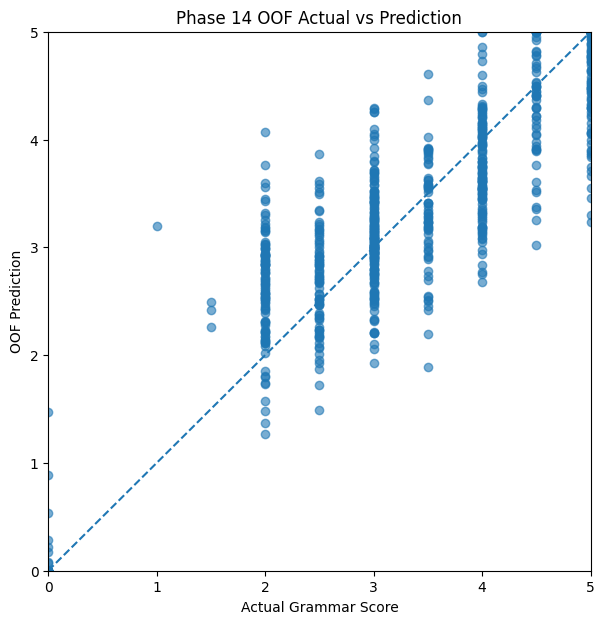

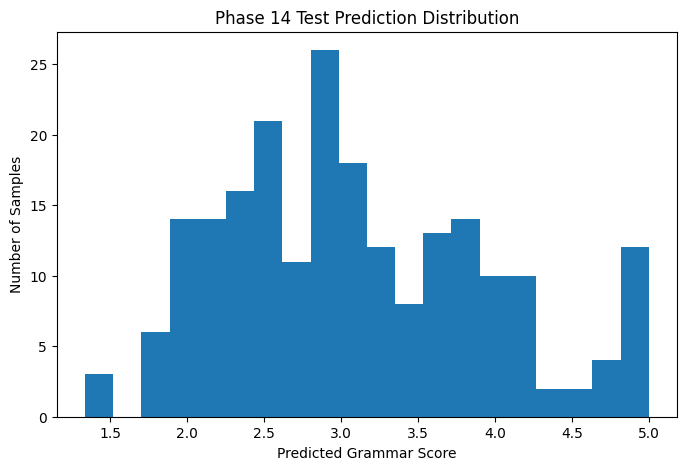

In [6]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 14
# ============================================================
#
# GENERALIZATION + DISTRIBUTION ALIGNMENT + RESIDUAL LEARNING
#
# Phase 13:
#   Best individual      ~0.6240
#   Greedy ensemble      ~0.5912
#   Weighted ensemble    ~0.5918
#   Calibrated           ~0.5749
#
# Phase 13 diagnosis:
#   Mean feature shift        : 0.4715
#   Maximum feature shift     : 22.4705
#   Dispersion ratio          : 0.6341
#   Prediction dispersion     : STRONG UNDER-DISPERSION
#
# Phase 14 goals:
#
#   1. Leakage-safe preprocessing
#   2. Repeated CV
#   3. Train/test distribution alignment
#   4. Stable audio feature selection
#   5. Multiple Whisper PCA representations
#   6. Whisper + audio residual learning
#   7. Robust ensemble
#   8. OOF-only calibration
#   9. Prediction dispersion correction
#  10. Stability-aware model selection
#
# NO TEST LABELS ARE USED.
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import warnings
import itertools

import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from sklearn.impute import SimpleImputer

from sklearn.feature_selection import (
    VarianceThreshold
)

from scipy.sparse import csr_matrix

warnings.filterwarnings("ignore")


SEED = 42


print("=" * 90)
print("GRAMMAR SCORING ENGINE - PHASE 14")
print("=" * 90)

print("""
GENERALIZATION + DISTRIBUTION ALIGNMENT
+ RESIDUAL LEARNING + ROBUST CALIBRATION
""")


# ============================================================
# 2. PATH CONFIGURATION
# ============================================================

DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)

TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


# ------------------------------------------------------------
# Existing transcript files
# ------------------------------------------------------------

TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)

TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)


# ------------------------------------------------------------
# Existing audio files
# ------------------------------------------------------------

AUDIO_TRAIN_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)

AUDIO_TEST_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)


# ------------------------------------------------------------
# Existing Whisper files
# ------------------------------------------------------------

WHISPER_TRAIN_FILE = (
    "/kaggle/working/"
    "phase8_train_whisper_embeddings.npy"
)

WHISPER_TEST_FILE = (
    "/kaggle/working/"
    "phase8_test_whisper_embeddings.npy"
)


# ============================================================
# Phase 14 output
# ============================================================

OUTPUT_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase14.csv"
)

OOF_FILE = (
    "/kaggle/working/"
    "phase14_oof_predictions.csv"
)

RESULTS_FILE = (
    "/kaggle/working/"
    "phase14_results.csv"
)

SHIFT_FILE = (
    "/kaggle/working/"
    "phase14_feature_shift.csv"
)


# ============================================================
# 3. CHECK FILES
# ============================================================

required_files = [

    TRAIN_CSV,
    TEST_CSV,
    SAMPLE_SUBMISSION,

    TRAIN_TRANSCRIPT_FILE,
    TEST_TRANSCRIPT_FILE,

    AUDIO_TRAIN_FILE,
    AUDIO_TEST_FILE,

    WHISPER_TRAIN_FILE,
    WHISPER_TEST_FILE

]


print("\nChecking required files...")

for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nMissing required file:\n{path}"
        )

print("All required files found.")


# ============================================================
# 4. LOAD DATA
# ============================================================

train_base = pd.read_csv(
    TRAIN_CSV
)

test_base = pd.read_csv(
    TEST_CSV
)

sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION
)

train_text = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)

test_text = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)

audio_train = pd.read_csv(
    AUDIO_TRAIN_FILE
)

audio_test = pd.read_csv(
    AUDIO_TEST_FILE
)

whisper_train_raw = np.load(
    WHISPER_TRAIN_FILE
)

whisper_test_raw = np.load(
    WHISPER_TEST_FILE
)


print("\nDataset sizes")
print("-" * 60)

print(
    "Train:",
    train_base.shape
)

print(
    "Test:",
    test_base.shape
)

print(
    "Train transcripts:",
    train_text.shape
)

print(
    "Test transcripts:",
    test_text.shape
)

print(
    "Train audio:",
    audio_train.shape
)

print(
    "Test audio:",
    audio_test.shape
)

print(
    "Whisper train:",
    whisper_train_raw.shape
)

print(
    "Whisper test:",
    whisper_test_raw.shape
)


# ============================================================
# 5. BASIC VALIDATION
# ============================================================

if "filename" not in train_base.columns:
    raise KeyError(
        "train.csv must contain filename."
    )

if "label" not in train_base.columns:
    raise KeyError(
        "train.csv must contain label."
    )

if "filename" not in test_base.columns:
    raise KeyError(
        "test.csv must contain filename."
    )

if "filename" not in train_text.columns:
    raise KeyError(
        "train transcript file must contain filename."
    )

if "text" not in train_text.columns:
    raise KeyError(
        "train transcript file must contain text."
    )

if "filename" not in test_text.columns:
    raise KeyError(
        "test transcript file must contain filename."
    )

if "text" not in test_text.columns:
    raise KeyError(
        "test transcript file must contain text."
    )


# ============================================================
# 6. MASTER DATAFRAME
# ============================================================

train = train_base[
    [
        "filename",
        "label"
    ]
].copy()

test = test_base[
    [
        "filename"
    ]
].copy()


train = train.merge(
    train_text[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)

test = test.merge(
    test_text[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


train["text"] = (
    train["text"]
    .fillna("")
)

test["text"] = (
    test["text"]
    .fillna("")
)


if len(train) != len(train_base):
    raise ValueError(
        "Train row count changed."
    )

if len(test) != len(test_base):
    raise ValueError(
        "Test row count changed."
    )


y = (
    train["label"]
    .astype(float)
    .values
)


print("\nTarget statistics")
print(
    pd.Series(y).describe()
)


# ============================================================
# 7. TEXT CLEANING
# ============================================================

def clean_text(x):

    if pd.isna(x):
        return ""

    x = str(x)

    x = " ".join(
        x.split()
    )

    return x.lower()


train_texts = (
    train["text"]
    .apply(clean_text)
    .values
)

test_texts = (
    test["text"]
    .apply(clean_text)
    .values
)


print(
    "\nEmpty train transcripts:",
    np.sum(
        np.array(
            train_texts
        ) == ""
    )
)

print(
    "Empty test transcripts:",
    np.sum(
        np.array(
            test_texts
        ) == ""
    )
)


# ============================================================
# 8. AUDIO ALIGNMENT
# ============================================================

audio_train = (
    audio_train
    .drop_duplicates(
        subset=["filename"]
    )
)

audio_test = (
    audio_test
    .drop_duplicates(
        subset=["filename"]
    )
)


if "filename" not in audio_train.columns:
    raise KeyError(
        "Audio train missing filename."
    )

if "filename" not in audio_test.columns:
    raise KeyError(
        "Audio test missing filename."
    )


audio_columns = [

    c

    for c in audio_train.columns

    if c not in [
        "filename",
        "label"
    ]

    and
    pd.api.types.is_numeric_dtype(
        audio_train[c]
    )

]


audio_train_lookup = (
    audio_train
    .set_index("filename")
)

audio_test_lookup = (
    audio_test
    .set_index("filename")
)


missing_train = (
    ~train["filename"]
    .isin(
        audio_train_lookup.index
    )
)

missing_test = (
    ~test["filename"]
    .isin(
        audio_test_lookup.index
    )
)


if missing_train.any():
    raise ValueError(
        "Missing train audio rows."
    )

if missing_test.any():
    raise ValueError(
        "Missing test audio rows."
    )


A_train_df = (
    audio_train_lookup
    .loc[
        train["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)

A_test_df = (
    audio_test_lookup
    .loc[
        test["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)


A_train_df = (
    A_train_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

A_test_df = (
    A_test_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# ============================================================
# 9. REMOVE COMPLETELY EMPTY / CONSTANT AUDIO FEATURES
# ============================================================

usable_audio_columns = []

for col in A_train_df.columns:

    values = A_train_df[col]

    if values.notna().sum() == 0:
        continue

    if values.nunique(
        dropna=True
    ) <= 1:
        continue

    usable_audio_columns.append(
        col
    )


A_train_df = A_train_df[
    usable_audio_columns
]

A_test_df = A_test_df[
    usable_audio_columns
]


print(
    "\nInitial usable audio features:",
    len(usable_audio_columns)
)


# ============================================================
# 10. TRAIN / TEST DISTRIBUTION SHIFT
# ============================================================
#
# For each audio feature:
#
#   shift = |mean_train - mean_test| / train_std
#
# Large values indicate possible distribution mismatch.
#
# We do NOT use labels here.
#
# ============================================================

shift_rows = []

for col in usable_audio_columns:

    tr = A_train_df[col].values
    te = A_test_df[col].values

    tr = tr[np.isfinite(tr)]
    te = te[np.isfinite(te)]

    if len(tr) == 0 or len(te) == 0:
        continue

    mean_train = np.mean(tr)
    mean_test = np.mean(te)

    std_train = np.std(tr)

    if std_train < 1e-8:
        shift = 0.0
    else:
        shift = (
            abs(
                mean_train -
                mean_test
            )
            /
            std_train
        )

    shift_rows.append({

        "feature": col,

        "train_mean": mean_train,

        "test_mean": mean_test,

        "train_std": std_train,

        "shift": shift

    })


shift_df = pd.DataFrame(
    shift_rows
)


shift_df = (
    shift_df
    .sort_values(
        "shift",
        ascending=False
    )
)


shift_df.to_csv(
    SHIFT_FILE,
    index=False
)


mean_shift = (
    shift_df["shift"]
    .mean()
)

max_shift = (
    shift_df["shift"]
    .max()
)


print("\n")
print("=" * 90)
print("DISTRIBUTION SHIFT")
print("=" * 90)

print(
    "Mean feature shift:",
    round(
        mean_shift,
        6
    )
)

print(
    "Maximum feature shift:",
    round(
        max_shift,
        6
    )
)


print(
    "\nMost shifted features:"
)

print(
    shift_df.head(15).to_string(
        index=False
    )
)


# ============================================================
# 11. STABLE AUDIO FEATURE SETS
# ============================================================
#
# We create multiple feature sets.
#
# A:
#   all usable features
#
# B:
#   shift <= 5
#
# C:
#   shift <= 3
#
# D:
#   shift <= 2
#
# This allows CV to determine whether unstable features
# actually help generalization.
#
# ============================================================

shift_map = dict(
    zip(
        shift_df["feature"],
        shift_df["shift"]
    )
)


audio_sets = {}

for threshold in [
    100.0,
    5.0,
    3.0,
    2.0
]:

    cols = [

        c

        for c in usable_audio_columns

        if shift_map.get(
            c,
            999
        ) <= threshold

    ]

    audio_sets[
        f"shift_{threshold}"
    ] = cols


print("\nStable feature counts:")

for name, cols in audio_sets.items():

    print(
        f"{name:15s}: {len(cols)}"
    )


# ============================================================
# 12. WHISPER CLEANING
# ============================================================

whisper_train_raw = np.nan_to_num(
    whisper_train_raw,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

whisper_test_raw = np.nan_to_num(
    whisper_test_raw,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


if whisper_train_raw.shape[0] != len(train):
    raise ValueError(
        "Whisper train rows mismatch."
    )

if whisper_test_raw.shape[0] != len(test):
    raise ValueError(
        "Whisper test rows mismatch."
    )


# ============================================================
# 13. METRICS
# ============================================================

def metrics(
    y_true,
    pred
):

    pred = np.asarray(
        pred,
        dtype=float
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    if (
        np.std(y_true) < 1e-12
        or
        np.std(pred) < 1e-12
    ):

        corr = np.nan

    else:

        corr = pearsonr(
            y_true,
            pred
        )[0]

    return rmse, corr


# ============================================================
# 14. CALIBRATION FUNCTIONS
# ============================================================

def fit_linear_calibration(
    y_true,
    pred
):

    x = np.asarray(
        pred,
        dtype=float
    )

    yv = np.asarray(
        y_true,
        dtype=float
    )

    xm = x.mean()
    ym = yv.mean()

    var = np.var(x)

    if var < 1e-10:

        slope = 1.0

    else:

        slope = (
            np.mean(
                (x - xm) *
                (yv - ym)
            )
            /
            var
        )

    slope = np.clip(
        slope,
        0.50,
        2.50
    )

    intercept = (
        ym
        -
        slope * xm
    )

    return slope, intercept


def apply_linear_calibration(
    pred,
    slope,
    intercept
):

    return (
        slope *
        np.asarray(pred)
        +
        intercept
    )


def variance_calibration(
    y_true,
    pred,
    strength=1.0
):

    pred = np.asarray(
        pred,
        dtype=float
    )

    target_mean = np.mean(
        y_true
    )

    target_std = np.std(
        y_true
    )

    pred_mean = np.mean(
        pred
    )

    pred_std = np.std(
        pred
    )

    if pred_std < 1e-10:

        return pred.copy()

    ratio = (
        target_std /
        pred_std
    )

    # Do not blindly expand to target variance.
    # Search controlled strengths.
    ratio = (
        1.0
        +
        strength *
        (ratio - 1.0)
    )

    ratio = np.clip(
        ratio,
        0.75,
        1.60
    )

    return (
        target_mean
        +
        (
            pred -
            pred_mean
        )
        *
        ratio
    )


# ============================================================
# 15. REPEATED CV CONFIGURATION
# ============================================================

N_SPLITS = 5

CV_SEEDS = [
    42,
    123,
    777
]


print("\n")
print("=" * 90)
print("PHASE 14 CROSS VALIDATION")
print("=" * 90)

print(
    "Splits:",
    N_SPLITS
)

print(
    "Seeds:",
    CV_SEEDS
)


# ============================================================
# 16. MODEL NAMES
# ============================================================

MODEL_NAMES = [

    "whisper_pca48",

    "whisper_pca64",

    "whisper_pca96",

    "audio_extra_stable",

    "audio_hgb_stable",

    "audio_rf_stable",

    "text_ridge",

    "whisper_audio_residual"

]


# Store predictions from every repeated split.

oof_store = {

    name: np.zeros(
        (
            len(CV_SEEDS),
            len(y)
        )
    )

    for name in MODEL_NAMES

}


# ============================================================
# 17. TEXT VECTOR PARAMS
# ============================================================

def build_text_features(
    train_idx,
    valid_idx
):

    train_fold_text = [
        train_texts[i]
        for i in train_idx
    ]

    valid_fold_text = [
        train_texts[i]
        for i in valid_idx
    ]

    # Fit ONLY on fold training data.
    # This fixes the preprocessing leakage from earlier phases.

    word_vectorizer = TfidfVectorizer(

        ngram_range=(1, 2),

        min_df=2,

        max_df=0.98,

        max_features=10000,

        sublinear_tf=True,

        strip_accents="unicode"

    )

    char_vectorizer = TfidfVectorizer(

        analyzer="char",

        ngram_range=(3, 5),

        min_df=3,

        max_features=10000,

        sublinear_tf=True

    )

    try:

        Xw_train = (
            word_vectorizer
            .fit_transform(
                train_fold_text
            )
        )

        Xw_valid = (
            word_vectorizer
            .transform(
                valid_fold_text
            )
        )

    except ValueError:

        Xw_train = csr_matrix(
            (
                len(train_idx),
                1
            )
        )

        Xw_valid = csr_matrix(
            (
                len(valid_idx),
                1
            )
        )


    try:

        Xc_train = (
            char_vectorizer
            .fit_transform(
                train_fold_text
            )
        )

        Xc_valid = (
            char_vectorizer
            .transform(
                valid_fold_text
            )
        )

    except ValueError:

        Xc_train = csr_matrix(
            (
                len(train_idx),
                1
            )
        )

        Xc_valid = csr_matrix(
            (
                len(valid_idx),
                1
            )
        )


    X_train = (
        __import__(
            "scipy"
        ).sparse.hstack(
            [
                Xw_train,
                Xc_train
            ],
            format="csr"
        )
    )

    X_valid = (
        __import__(
            "scipy"
        ).sparse.hstack(
            [
                Xw_valid,
                Xc_valid
            ],
            format="csr"
        )
    )

    return (
        X_train,
        X_valid,
        word_vectorizer,
        char_vectorizer
    )


# ============================================================
# 18. MAIN REPEATED CV
# ============================================================

for seed_id, cv_seed in enumerate(
    CV_SEEDS
):

    print("\n")
    print("=" * 90)
    print(
        f"REPEATED CV SEED "
        f"{cv_seed}"
    )
    print("=" * 90)


    kf = KFold(

        n_splits=N_SPLITS,

        shuffle=True,

        random_state=cv_seed

    )


    for fold, (
        train_idx,
        valid_idx
    ) in enumerate(
        kf.split(y),
        start=1
    ):

        print(
            f"\nSeed={cv_seed} "
            f"Fold={fold}/{N_SPLITS}"
        )


        y_tr = y[
            train_idx
        ]

        y_va = y[
            valid_idx
        ]


        # ====================================================
        # WHISPER PREPROCESSING
        # ====================================================

        whisper_scaler = StandardScaler()

        W_tr_scaled = (
            whisper_scaler
            .fit_transform(
                whisper_train_raw[
                    train_idx
                ]
            )
        )

        W_va_scaled = (
            whisper_scaler
            .transform(
                whisper_train_raw[
                    valid_idx
                ]
            )
        )


        max_components = min(
            96,
            len(train_idx) - 1,
            whisper_train_raw.shape[1]
        )


        pca = PCA(

            n_components=max_components,

            random_state=SEED

        )


        W_tr_all = (
            pca
            .fit_transform(
                W_tr_scaled
            )
        )

        W_va_all = (
            pca
            .transform(
                W_va_scaled
            )
        )


        # ----------------------------------------------------
        # Whisper 48
        # ----------------------------------------------------

        pca48_dim = min(
            48,
            W_tr_all.shape[1]
        )

        W48_tr = (
            W_tr_all[
                :,
                :pca48_dim
            ]
        )

        W48_va = (
            W_va_all[
                :,
                :pca48_dim
            ]
        )


        model = Ridge(
            alpha=50.0
        )

        model.fit(
            W48_tr,
            y_tr
        )

        pred = model.predict(
            W48_va
        )

        oof_store[
            "whisper_pca48"
        ][
            seed_id,
            valid_idx
        ] = pred


        del model


        # ----------------------------------------------------
        # Whisper 64
        # ----------------------------------------------------

        pca64_dim = min(
            64,
            W_tr_all.shape[1]
        )

        W64_tr = (
            W_tr_all[
                :,
                :pca64_dim
            ]
        )

        W64_va = (
            W_va_all[
                :,
                :pca64_dim
            ]
        )


        model = Ridge(
            alpha=50.0
        )

        model.fit(
            W64_tr,
            y_tr
        )

        pred = model.predict(
            W64_va
        )

        oof_store[
            "whisper_pca64"
        ][
            seed_id,
            valid_idx
        ] = pred


        del model


        # ----------------------------------------------------
        # Whisper 96
        # ----------------------------------------------------

        pca96_dim = min(
            96,
            W_tr_all.shape[1]
        )

        W96_tr = (
            W_tr_all[
                :,
                :pca96_dim
            ]
        )

        W96_va = (
            W_va_all[
                :,
                :pca96_dim
            ]
        )


        model = Ridge(
            alpha=75.0
        )

        model.fit(
            W96_tr,
            y_tr
        )

        pred = model.predict(
            W96_va
        )

        oof_store[
            "whisper_pca96"
        ][
            seed_id,
            valid_idx
        ] = pred


        del model


        # ====================================================
        # AUDIO MODELS
        # ====================================================

        stable_cols = audio_sets[
            "shift_3.0"
        ]


        A_tr_df = (
            A_train_df
            .iloc[
                train_idx
            ][
                stable_cols
            ]
        )

        A_va_df = (
            A_train_df
            .iloc[
                valid_idx
            ][
                stable_cols
            ]
        )


        audio_imputer = SimpleImputer(
            strategy="median"
        )


        A_tr = (
            audio_imputer
            .fit_transform(
                A_tr_df
            )
        )

        A_va = (
            audio_imputer
            .transform(
                A_va_df
            )
        )


        audio_scaler = StandardScaler()

        A_tr_scaled = (
            audio_scaler
            .fit_transform(
                A_tr
            )
        )

        A_va_scaled = (
            audio_scaler
            .transform(
                A_va
            )
        )


        # ----------------------------------------------------
        # ExtraTrees
        # ----------------------------------------------------

        audio_extra = ExtraTreesRegressor(

            n_estimators=600,

            max_features=0.70,

            min_samples_leaf=4,

            max_depth=None,

            random_state=cv_seed + fold,

            n_jobs=-1

        )


        audio_extra.fit(
            A_tr_scaled,
            y_tr
        )


        pred_audio_extra = (
            audio_extra
            .predict(
                A_va_scaled
            )
        )


        oof_store[
            "audio_extra_stable"
        ][
            seed_id,
            valid_idx
        ] = pred_audio_extra


        # ----------------------------------------------------
        # HGB
        # ----------------------------------------------------

        audio_hgb = (
            HistGradientBoostingRegressor(

                max_iter=350,

                learning_rate=0.035,

                max_leaf_nodes=15,

                max_depth=5,

                min_samples_leaf=15,

                l2_regularization=2.0,

                random_state=cv_seed + fold

            )
        )


        audio_hgb.fit(
            A_tr_scaled,
            y_tr
        )


        pred_audio_hgb = (
            audio_hgb
            .predict(
                A_va_scaled
            )
        )


        oof_store[
            "audio_hgb_stable"
        ][
            seed_id,
            valid_idx
        ] = pred_audio_hgb


        # ----------------------------------------------------
        # Random Forest
        # ----------------------------------------------------

        audio_rf = RandomForestRegressor(

            n_estimators=500,

            max_features=0.65,

            min_samples_leaf=5,

            max_depth=None,

            random_state=cv_seed + fold,

            n_jobs=-1

        )


        audio_rf.fit(
            A_tr_scaled,
            y_tr
        )


        pred_audio_rf = (
            audio_rf
            .predict(
                A_va_scaled
            )
        )


        oof_store[
            "audio_rf_stable"
        ][
            seed_id,
            valid_idx
        ] = pred_audio_rf


        # ====================================================
        # TEXT
        # ====================================================

        X_text_tr, X_text_va, _, _ = (
            build_text_features(
                train_idx,
                valid_idx
            )
        )


        text_model = Ridge(
            alpha=25.0
        )


        text_model.fit(
            X_text_tr,
            y_tr
        )


        pred_text = (
            text_model
            .predict(
                X_text_va
            )
        )


        oof_store[
            "text_ridge"
        ][
            seed_id,
            valid_idx
        ] = pred_text


        # ====================================================
        # WHISPER + AUDIO RESIDUAL
        # ====================================================
        #
        # First model:
        #
        #   y ~= Whisper
        #
        # Then:
        #
        #   residual = y - Whisper prediction
        #
        # Audio learns the residual.
        #
        # ====================================================

        whisper_base = Ridge(
            alpha=50.0
        )

        whisper_base.fit(
            W48_tr,
            y_tr
        )


        whisper_train_pred = (
            whisper_base
            .predict(
                W48_tr
            )
        )


        whisper_valid_pred = (
            whisper_base
            .predict(
                W48_va
            )
        )


        residual_target = (
            y_tr -
            whisper_train_pred
        )


        residual_model = ExtraTreesRegressor(

            n_estimators=500,

            max_features=0.70,

            min_samples_leaf=8,

            random_state=cv_seed + fold + 5000,

            n_jobs=-1

        )


        residual_model.fit(
            A_tr_scaled,
            residual_target
        )


        residual_valid = (
            residual_model
            .predict(
                A_va_scaled
            )
        )


        residual_prediction = (
            whisper_valid_pred
            +
            residual_valid
        )


        oof_store[
            "whisper_audio_residual"
        ][
            seed_id,
            valid_idx
        ] = residual_prediction


        # ====================================================
        # FOLD SUMMARY
        # ====================================================

        fold_scores = {}

        for name in MODEL_NAMES:

            p = (
                oof_store[name][
                    seed_id,
                    valid_idx
                ]
            )

            score, corr = metrics(
                y_va,
                p
            )

            fold_scores[name] = score


        best_fold_model = min(
            fold_scores,
            key=fold_scores.get
        )


        print(
            "Best fold:",
            best_fold_model,
            f"RMSE={fold_scores[best_fold_model]:.4f}"
        )


        del (
            whisper_scaler,
            pca,
            W_tr_scaled,
            W_va_scaled,
            W_tr_all,
            W_va_all,
            A_tr,
            A_va,
            A_tr_scaled,
            A_va_scaled,
            audio_extra,
            audio_hgb,
            audio_rf,
            text_model,
            residual_model,
            whisper_base,
            X_text_tr,
            X_text_va
        )


        gc.collect()


# ============================================================
# 19. COLLAPSE REPEATED OOF
# ============================================================
#
# Each sample has one prediction for each seed because every
# KFold covers all samples.
#
# Average across seeds.
#
# ============================================================

oof_mean = {}

for name in MODEL_NAMES:

    oof_mean[name] = (
        oof_store[name]
        .mean(
            axis=0
        )
    )


# ============================================================
# 20. INDIVIDUAL MODEL RESULTS
# ============================================================

results = []

print("\n")
print("=" * 90)
print("INDIVIDUAL MODEL PERFORMANCE")
print("=" * 90)


for name in MODEL_NAMES:

    pred = oof_mean[name]

    rmse, corr = metrics(
        y,
        pred
    )


    seed_rmses = []

    for seed_id in range(
        len(CV_SEEDS)
    ):

        s_rmse, _ = metrics(
            y,
            oof_store[name][
                seed_id
            ]
        )

        seed_rmses.append(
            s_rmse
        )


    stability = np.std(
        seed_rmses
    )


    results.append({

        "model": name,

        "rmse": rmse,

        "pearson": corr,

        "seed_mean_rmse":
            np.mean(
                seed_rmses
            ),

        "seed_std_rmse":
            stability

    })


    print(
        f"{name:28s} "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f} "
        f"SeedSTD={stability:.6f}"
    )


results_df = pd.DataFrame(
    results
).sort_values(
    "rmse"
)


# ============================================================
# 21. PREDICTION CORRELATION
# ============================================================

prediction_matrix = np.column_stack(

    [
        oof_mean[name]
        for name in MODEL_NAMES
    ]

)


prediction_corr = np.corrcoef(
    prediction_matrix.T
)


corr_table = pd.DataFrame(
    prediction_corr,
    index=MODEL_NAMES,
    columns=MODEL_NAMES
)


print("\n")
print("=" * 90)
print("PREDICTION CORRELATION")
print("=" * 90)

print(
    corr_table.round(3)
)


# ============================================================
# 22. GRID ENSEMBLE
# ============================================================
#
# Instead of trusting a single greedy selection, search
# sensible sparse combinations.
#
# ============================================================

print("\n")
print("=" * 90)
print("ENSEMBLE SEARCH")
print("=" * 90)


candidate_names = [

    "whisper_pca48",

    "whisper_pca64",

    "whisper_pca96",

    "audio_extra_stable",

    "audio_hgb_stable",

    "audio_rf_stable",

    "whisper_audio_residual",

    "text_ridge"

]


candidate_matrix = np.column_stack(

    [
        oof_mean[name]
        for name in candidate_names
    ]

)


best_rmse = np.inf
best_corr = None
best_weights = None
best_prediction = None
best_method = None


# ------------------------------------------------------------
# Individual models
# ------------------------------------------------------------

for i, name in enumerate(
    candidate_names
):

    pred = candidate_matrix[:, i]

    rmse, corr = metrics(
        y,
        pred
    )

    if rmse < best_rmse:

        best_rmse = rmse

        best_corr = corr

        w = np.zeros(
            len(candidate_names)
        )

        w[i] = 1.0

        best_weights = w

        best_prediction = (
            pred.copy()
        )

        best_method = (
            f"single:{name}"
        )


# ------------------------------------------------------------
# Pair search
# ------------------------------------------------------------

for i in range(
    len(candidate_names)
):

    for j in range(
        i + 1,
        len(candidate_names)
    ):

        for wi in np.arange(
            0.0,
            1.001,
            0.025
        ):

            wj = (
                1.0 -
                wi
            )

            pred = (
                wi *
                candidate_matrix[:, i]
                +
                wj *
                candidate_matrix[:, j]
            )

            rmse, corr = metrics(
                y,
                pred
            )

            if rmse < best_rmse:

                best_rmse = rmse

                best_corr = corr

                w = np.zeros(
                    len(candidate_names)
                )

                w[i] = wi
                w[j] = wj

                best_weights = w

                best_prediction = (
                    pred.copy()
                )

                best_method = (
                    f"pair:"
                    f"{candidate_names[i]}"
                    "+"
                    f"{candidate_names[j]}"
                )


# ------------------------------------------------------------
# Triple search
# ------------------------------------------------------------

for i, j, k in itertools.combinations(
    range(
        len(candidate_names)
    ),
    3
):

    for wi in np.arange(
        0.0,
        1.001,
        0.05
    ):

        for wj in np.arange(
            0.0,
            1.001 - wi,
            0.05
        ):

            wk = (
                1.0 -
                wi -
                wj
            )

            if wk < 0:
                continue

            pred = (

                wi *
                candidate_matrix[:, i]

                +

                wj *
                candidate_matrix[:, j]

                +

                wk *
                candidate_matrix[:, k]

            )

            rmse, corr = metrics(
                y,
                pred
            )

            if rmse < best_rmse:

                best_rmse = rmse

                best_corr = corr

                w = np.zeros(
                    len(candidate_names)
                )

                w[i] = wi
                w[j] = wj
                w[k] = wk

                best_weights = w

                best_prediction = (
                    pred.copy()
                )

                best_method = (
                    f"triple:"
                    f"{candidate_names[i]}"
                    "+"
                    f"{candidate_names[j]}"
                    "+"
                    f"{candidate_names[k]}"
                )


print(
    "\nBest raw ensemble:"
)

print(
    "Method:",
    best_method
)

print(
    "RMSE:",
    f"{best_rmse:.6f}"
)

print(
    "Pearson:",
    f"{best_corr:.6f}"
)

print(
    "\nWeights:"
)

for name, weight in zip(
    candidate_names,
    best_weights
):

    if weight > 0.001:

        print(
            f"{name:28s}"
            f"{weight:.4f}"
        )


# ============================================================
# 23. CALIBRATION SEARCH
# ============================================================
#
# Phase 13 benefited heavily from calibration.
#
# We now search controlled calibration parameters.
#
# IMPORTANT:
# Calibration is fitted on OOF predictions only.
#
# ============================================================

print("\n")
print("=" * 90)
print("CALIBRATION SEARCH")
print("=" * 90)


calibration_candidates = []


# ------------------------------------------------------------
# Linear calibration
# ------------------------------------------------------------

slope, intercept = (
    fit_linear_calibration(
        y,
        best_prediction
    )
)


linear_prediction = (
    apply_linear_calibration(
        best_prediction,
        slope,
        intercept
    )
)


linear_prediction = np.clip(
    linear_prediction,
    0,
    5
)


rmse, corr = metrics(
    y,
    linear_prediction
)


calibration_candidates.append({

    "name":
        "linear",

    "prediction":
        linear_prediction,

    "rmse":
        rmse,

    "corr":
        corr,

    "slope":
        slope,

    "intercept":
        intercept,

    "strength":
        None

})


print(
    f"Linear calibration "
    f"RMSE={rmse:.6f}"
)


# ------------------------------------------------------------
# Controlled variance calibration
# ------------------------------------------------------------

for strength in np.arange(
    0.0,
    1.51,
    0.05
):

    pred = variance_calibration(
        y,
        best_prediction,
        strength
    )

    pred = np.clip(
        pred,
        0,
        5
    )

    rmse, corr = metrics(
        y,
        pred
    )


    calibration_candidates.append({

        "name":
            "variance",

        "prediction":
            pred,

        "rmse":
            rmse,

        "corr":
            corr,

        "slope":
            None,

        "intercept":
            None,

        "strength":
            strength

    })


calibration_df = pd.DataFrame({

    "method": [
        x["name"]
        for x in calibration_candidates
    ],

    "rmse": [
        x["rmse"]
        for x in calibration_candidates
    ],

    "pearson": [
        x["corr"]
        for x in calibration_candidates
    ],

    "strength": [
        x["strength"]
        for x in calibration_candidates
    ]

})


calibration_df = (
    calibration_df
    .sort_values(
        "rmse"
    )
)


best_calibration_row = (
    calibration_df
    .iloc[0]
)


best_calibration = next(

    x

    for x in calibration_candidates

    if (
        x["name"] ==
        best_calibration_row["method"]
        and
        (
            x["strength"] ==
            best_calibration_row["strength"]
            or
            pd.isna(
                x["strength"]
            )
            and
            pd.isna(
                best_calibration_row[
                    "strength"
                ]
            )
        )
    )

)


calibrated_prediction = (
    best_calibration[
        "prediction"
    ]
)


calibrated_rmse = (
    best_calibration[
        "rmse"
    ]
)


calibrated_corr = (
    best_calibration[
        "corr"
    ]
)


print(
    "\nBest calibrated RMSE:",
    f"{calibrated_rmse:.6f}"
)

print(
    "Best calibrated Pearson:",
    f"{calibrated_corr:.6f}"
)

print(
    "Calibration:",
    best_calibration[
        "name"
    ]
)

print(
    "Strength:",
    best_calibration[
        "strength"
    ]
)


# ============================================================
# 24. OOF DISPERSION ANALYSIS
# ============================================================

target_std = np.std(
    y
)

raw_std = np.std(
    best_prediction
)

calibrated_std = np.std(
    calibrated_prediction
)


raw_dispersion_ratio = (
    raw_std /
    target_std
)

calibrated_dispersion_ratio = (
    calibrated_std /
    target_std
)


print("\n")
print("=" * 90)
print("DISPERSION ANALYSIS")
print("=" * 90)

print(
    "Target std:",
    f"{target_std:.6f}"
)

print(
    "Raw ensemble std:",
    f"{raw_std:.6f}"
)

print(
    "Raw dispersion ratio:",
    f"{raw_dispersion_ratio:.6f}"
)

print(
    "Calibrated std:",
    f"{calibrated_std:.6f}"
)

print(
    "Calibrated dispersion ratio:",
    f"{calibrated_dispersion_ratio:.6f}"
)


# ============================================================
# 25. FINAL STRATEGY
# ============================================================

best_individual = (
    results_df
    .iloc[0]
)


best_individual_rmse = (
    best_individual[
        "rmse"
    ]
)


best_individual_name = (
    best_individual[
        "model"
    ]
)


# Calibration must provide meaningful improvement.

if (
    calibrated_rmse
    <
    best_individual_rmse -
    0.002
):

    selected_strategy = (
        "CALIBRATED_ENSEMBLE"
    )

    final_oof_prediction = (
        calibrated_prediction
    )

elif (
    best_rmse
    <
    best_individual_rmse -
    0.002
):

    selected_strategy = (
        "RAW_ENSEMBLE"
    )

    final_oof_prediction = (
        best_prediction
    )

else:

    selected_strategy = (
        "BEST_INDIVIDUAL"
    )

    final_oof_prediction = (
        oof_mean[
            best_individual_name
        ]
    )


final_oof_rmse, final_oof_corr = (
    metrics(
        y,
        final_oof_prediction
    )
)


print("\n")
print("=" * 90)
print("FINAL OOF SELECTION")
print("=" * 90)

print(
    "Best individual:",
    best_individual_name
)

print(
    "Best individual RMSE:",
    f"{best_individual_rmse:.6f}"
)

print(
    "Raw ensemble RMSE:",
    f"{best_rmse:.6f}"
)

print(
    "Calibrated RMSE:",
    f"{calibrated_rmse:.6f}"
)

print(
    "FINAL OOF RMSE:",
    f"{final_oof_rmse:.6f}"
)

print(
    "FINAL OOF Pearson:",
    f"{final_oof_corr:.6f}"
)

print(
    "Selected strategy:",
    selected_strategy
)


# ============================================================
# 26. TRAIN FINAL MODELS ON ALL DATA
# ============================================================

print("\n")
print("=" * 90)
print("TRAINING FINAL MODELS")
print("=" * 90)


# ============================================================
# 27. FINAL WHISPER PCA
# ============================================================

final_whisper_scaler = StandardScaler()

W_all_scaled = (
    final_whisper_scaler
    .fit_transform(
        whisper_train_raw
    )
)

W_test_scaled = (
    final_whisper_scaler
    .transform(
        whisper_test_raw
    )
)


final_pca = PCA(

    n_components=min(
        96,
        len(train) - 1,
        whisper_train_raw.shape[1]
    ),

    random_state=SEED

)


W_all = (
    final_pca
    .fit_transform(
        W_all_scaled
    )
)

W_test_all = (
    final_pca
    .transform(
        W_test_scaled
    )
)


# ============================================================
# 28. FINAL WHISPER MODELS
# ============================================================

pca48_dim = min(
    48,
    W_all.shape[1]
)

pca64_dim = min(
    64,
    W_all.shape[1]
)

pca96_dim = min(
    96,
    W_all.shape[1]
)


final_whisper48 = Ridge(
    alpha=50.0
)

final_whisper48.fit(
    W_all[:, :pca48_dim],
    y
)

test_whisper48 = (
    final_whisper48
    .predict(
        W_test_all[
            :,
            :pca48_dim
        ]
    )
)


final_whisper64 = Ridge(
    alpha=50.0
)

final_whisper64.fit(
    W_all[:, :pca64_dim],
    y
)

test_whisper64 = (
    final_whisper64
    .predict(
        W_test_all[
            :,
            :pca64_dim
        ]
    )
)


final_whisper96 = Ridge(
    alpha=75.0
)

final_whisper96.fit(
    W_all[:, :pca96_dim],
    y
)

test_whisper96 = (
    final_whisper96
    .predict(
        W_test_all[
            :,
            :pca96_dim
        ]
    )
)


# ============================================================
# 29. FINAL AUDIO
# ============================================================

stable_cols = audio_sets[
    "shift_3.0"
]


A_full_df = (
    A_train_df[
        stable_cols
    ]
)

A_test_stable_df = (
    A_test_df[
        stable_cols
    ]
)


final_audio_imputer = SimpleImputer(
    strategy="median"
)


A_full = (
    final_audio_imputer
    .fit_transform(
        A_full_df
    )
)

A_test_final = (
    final_audio_imputer
    .transform(
        A_test_stable_df
    )
)


final_audio_scaler = StandardScaler()

A_full_scaled = (
    final_audio_scaler
    .fit_transform(
        A_full
    )
)

A_test_scaled = (
    final_audio_scaler
    .transform(
        A_test_final
    )
)


# ============================================================
# 30. FINAL EXTRA TREES
# ============================================================

final_audio_extra = ExtraTreesRegressor(

    n_estimators=1600,

    max_features=0.70,

    min_samples_leaf=4,

    random_state=SEED,

    n_jobs=-1

)


final_audio_extra.fit(
    A_full_scaled,
    y
)


test_audio_extra = (
    final_audio_extra
    .predict(
        A_test_scaled
    )
)


# ============================================================
# 31. FINAL HGB
# ============================================================

final_audio_hgb = (
    HistGradientBoostingRegressor(

        max_iter=400,

        learning_rate=0.035,

        max_leaf_nodes=15,

        max_depth=5,

        min_samples_leaf=15,

        l2_regularization=2.0,

        random_state=SEED

    )
)


final_audio_hgb.fit(
    A_full_scaled,
    y
)


test_audio_hgb = (
    final_audio_hgb
    .predict(
        A_test_scaled
    )
)


# ============================================================
# 32. FINAL RANDOM FOREST
# ============================================================

final_audio_rf = RandomForestRegressor(

    n_estimators=1200,

    max_features=0.65,

    min_samples_leaf=5,

    random_state=SEED,

    n_jobs=-1

)


final_audio_rf.fit(
    A_full_scaled,
    y
)


test_audio_rf = (
    final_audio_rf
    .predict(
        A_test_scaled
    )
)


# ============================================================
# 33. FINAL TEXT MODEL
# ============================================================

print(
    "\nTraining final text model..."
)


final_word_vectorizer = (
    TfidfVectorizer(

        ngram_range=(1, 2),

        min_df=2,

        max_df=0.98,

        max_features=12000,

        sublinear_tf=True,

        strip_accents="unicode"

    )
)


final_char_vectorizer = (
    TfidfVectorizer(

        analyzer="char",

        ngram_range=(3, 5),

        min_df=3,

        max_features=12000,

        sublinear_tf=True

    )
)


X_word_full = (
    final_word_vectorizer
    .fit_transform(
        train_texts
    )
)

X_word_test = (
    final_word_vectorizer
    .transform(
        test_texts
    )
)


X_char_full = (
    final_char_vectorizer
    .fit_transform(
        train_texts
    )
)

X_char_test = (
    final_char_vectorizer
    .transform(
        test_texts
    )
)


X_text_full = (
    __import__(
        "scipy"
    ).sparse.hstack(
        [
            X_word_full,
            X_char_full
        ],
        format="csr"
    )
)


X_text_test = (
    __import__(
        "scipy"
    ).sparse.hstack(
        [
            X_word_test,
            X_char_test
        ],
        format="csr"
    )
)


final_text_model = Ridge(
    alpha=25.0
)


final_text_model.fit(
    X_text_full,
    y
)


test_text_prediction = (
    final_text_model
    .predict(
        X_text_test
    )
)


# ============================================================
# 34. FINAL RESIDUAL MODEL
# ============================================================

print(
    "Training final Whisper + Audio residual model..."
)


residual_base = Ridge(
    alpha=50.0
)

residual_base.fit(
    W_all[:, :pca48_dim],
    y
)


train_base_prediction = (
    residual_base
    .predict(
        W_all[
            :,
            :pca48_dim
        ]
    )
)


test_base_prediction = (
    residual_base
    .predict(
        W_test_all[
            :,
            :pca48_dim
        ]
    )
)


residual_target = (
    y -
    train_base_prediction
)


final_residual_model = ExtraTreesRegressor(

    n_estimators=1400,

    max_features=0.70,

    min_samples_leaf=8,

    random_state=SEED + 5000,

    n_jobs=-1

)


final_residual_model.fit(
    A_full_scaled,
    residual_target
)


test_residual = (
    final_residual_model
    .predict(
        A_test_scaled
    )
)


test_residual_prediction = (
    test_base_prediction
    +
    test_residual
)


# ============================================================
# 35. FINAL PREDICTION MATRIX
# ============================================================

test_predictions = {

    "whisper_pca48":
        test_whisper48,

    "whisper_pca64":
        test_whisper64,

    "whisper_pca96":
        test_whisper96,

    "audio_extra_stable":
        test_audio_extra,

    "audio_hgb_stable":
        test_audio_hgb,

    "audio_rf_stable":
        test_audio_rf,

    "text_ridge":
        test_text_prediction,

    "whisper_audio_residual":
        test_residual_prediction

}


test_matrix = np.column_stack(

    [
        test_predictions[name]
        for name in candidate_names
    ]

)


# ============================================================
# 36. FINAL RAW ENSEMBLE
# ============================================================

raw_test_prediction = (
    test_matrix
    @
    best_weights
)


# ============================================================
# 37. APPLY SAME CALIBRATION
# ============================================================

if (
    best_calibration["name"]
    ==
    "linear"
):

    final_test_prediction = (
        apply_linear_calibration(
            raw_test_prediction,
            best_calibration[
                "slope"
            ],
            best_calibration[
                "intercept"
            ]
        )
    )


elif (
    best_calibration["name"]
    ==
    "variance"
):

    strength = (
        best_calibration[
            "strength"
        ]
    )

    # Apply OOF-derived target statistics.
    #
    # The function uses y statistics from training only.
    # This is allowed because y belongs to train.

    target_mean = np.mean(y)
    target_std = np.std(y)

    pred_mean = np.mean(
        best_prediction
    )

    pred_std = np.std(
        best_prediction
    )

    if pred_std < 1e-10:

        final_test_prediction = (
            raw_test_prediction
        )

    else:

        ratio = (
            target_std /
            pred_std
        )

        ratio = (
            1.0
            +
            strength *
            (ratio - 1.0)
        )

        ratio = np.clip(
            ratio,
            0.75,
            1.60
        )

        final_test_prediction = (

            target_mean

            +

            (
                raw_test_prediction
                -
                pred_mean
            )
            *
            ratio

        )

else:

    final_test_prediction = (
        raw_test_prediction
    )


# ============================================================
# 38. IF BEST INDIVIDUAL WINS
# ============================================================

if selected_strategy == "BEST_INDIVIDUAL":

    best_index = (
        candidate_names
        .index(
            best_individual_name
        )
    )

    final_test_prediction = (
        test_matrix[
            :,
            best_index
        ]
    )


# ============================================================
# 39. CLIP
# ============================================================

final_test_prediction = np.clip(

    final_test_prediction,

    0.0,

    5.0

)


# ============================================================
# 40. FINAL DISTRIBUTION
# ============================================================

print("\n")
print("=" * 90)
print("FINAL TEST PREDICTIONS")
print("=" * 90)

print(
    "Min       :",
    f"{final_test_prediction.min():.6f}"
)

print(
    "Max       :",
    f"{final_test_prediction.max():.6f}"
)

print(
    "Mean      :",
    f"{final_test_prediction.mean():.6f}"
)

print(
    "Std       :",
    f"{final_test_prediction.std():.6f}"
)

print(
    "Train std :",
    f"{np.std(y):.6f}"
)

print(
    "Test/Train dispersion:",
    f"{np.std(final_test_prediction) / np.std(y):.6f}"
)


# ============================================================
# 41. SUBMISSION FORMAT
# ============================================================

sample_columns = (
    sample_submission
    .columns
    .tolist()
)


submission_filename_column = None


for candidate in [
    "filename",
    "file_name",
    "id"
]:

    if candidate in sample_columns:

        submission_filename_column = (
            candidate
        )

        break


if "label" in sample_columns:

    submission_prediction_column = (
        "label"
    )

else:

    excluded = {
        "filename",
        "file_name",
        "id"
    }

    prediction_candidates = [

        c

        for c in sample_columns

        if c not in excluded

    ]

    if len(
        prediction_candidates
    ) != 1:

        raise ValueError(
            "Could not identify submission prediction column."
        )

    submission_prediction_column = (
        prediction_candidates[0]
    )


# ============================================================
# 42. BUILD SUBMISSION
# ============================================================

if submission_filename_column:

    submission = pd.DataFrame({

        submission_filename_column:
            test[
                "filename"
            ].astype(str).values,

        submission_prediction_column:
            final_test_prediction

    })

else:

    submission = pd.DataFrame({

        submission_prediction_column:
            final_test_prediction

    })


# ============================================================
# 43. SUBMISSION SAFETY
# ============================================================

if len(submission) != len(test):

    raise ValueError(
        f"Submission rows={len(submission)} "
        f"but test rows={len(test)}"
    )


if submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "NaN predictions detected."
    )


if not submission[
    submission_prediction_column
].between(
    0,
    5
).all():

    raise ValueError(
        "Prediction outside 0-5."
    )


# ============================================================
# 44. SAVE SUBMISSION
# ============================================================

submission.to_csv(

    OUTPUT_SUBMISSION,

    index=False

)


# ============================================================
# 45. SAVE OOF PREDICTIONS
# ============================================================

oof_output = pd.DataFrame({

    "filename":
        train[
            "filename"
        ],

    "label":
        y

})


for name in MODEL_NAMES:

    oof_output[
        name
    ] = oof_mean[name]


oof_output[
    "raw_ensemble"
] = best_prediction


oof_output[
    "calibrated_ensemble"
] = calibrated_prediction


oof_output[
    "final_oof_prediction"
] = final_oof_prediction


oof_output.to_csv(
    OOF_FILE,
    index=False
)


# ============================================================
# 46. SAVE RESULTS
# ============================================================

results_output = results_df.copy()

results_output[
    "best_raw_ensemble_rmse"
] = best_rmse

results_output[
    "best_raw_ensemble_pearson"
] = best_corr

results_output[
    "best_calibrated_rmse"
] = calibrated_rmse

results_output[
    "best_calibrated_pearson"
] = calibrated_corr

results_output[
    "final_oof_rmse"
] = final_oof_rmse

results_output[
    "final_oof_pearson"
] = final_oof_corr

results_output[
    "selected_strategy"
] = selected_strategy

results_output[
    "mean_feature_shift"
] = mean_shift

results_output[
    "maximum_feature_shift"
] = max_shift

results_output[
    "raw_dispersion_ratio"
] = raw_dispersion_ratio

results_output[
    "calibrated_dispersion_ratio"
] = calibrated_dispersion_ratio


for name, weight in zip(
    candidate_names,
    best_weights
):

    results_output[
        f"ensemble_weight_{name}"
    ] = weight


results_output.to_csv(
    RESULTS_FILE,
    index=False
)


# ============================================================
# 47. SAVE CALIBRATION TABLE
# ============================================================

calibration_df.to_csv(

    "/kaggle/working/"
    "phase14_calibration_search.csv",

    index=False

)


# ============================================================
# 48. SUBMISSION VALIDATION
# ============================================================

loaded_submission = pd.read_csv(
    OUTPUT_SUBMISSION
)


if len(
    loaded_submission
) != len(test):

    raise ValueError(
        "Saved submission row count incorrect."
    )


if loaded_submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "Saved submission contains NaN."
    )


# ============================================================
# 49. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 90)
print("PHASE 14 COMPLETE")
print("=" * 90)

print(
    f"Train samples           : "
    f"{len(train)}"
)

print(
    f"Test samples            : "
    f"{len(test)}"
)

print(
    f"Audio features          : "
    f"{len(stable_cols)}"
)

print(
    f"Whisper PCA             : "
    f"{final_pca.n_components_}"
)

print(
    f"Mean feature shift      : "
    f"{mean_shift:.6f}"
)

print(
    f"Maximum feature shift   : "
    f"{max_shift:.6f}"
)

print(
    f"Best individual         : "
    f"{best_individual_name}"
)

print(
    f"Best individual RMSE    : "
    f"{best_individual_rmse:.6f}"
)

print(
    f"Best raw ensemble RMSE  : "
    f"{best_rmse:.6f}"
)

print(
    f"Best calibrated RMSE    : "
    f"{calibrated_rmse:.6f}"
)

print(
    f"FINAL LOCAL OOF RMSE    : "
    f"{final_oof_rmse:.6f}"
)

print(
    f"FINAL LOCAL OOF Pearson : "
    f"{final_oof_corr:.6f}"
)

print(
    f"Selected strategy       : "
    f"{selected_strategy}"
)

print(
    f"Raw dispersion ratio    : "
    f"{raw_dispersion_ratio:.6f}"
)

print(
    f"Final test dispersion   : "
    f"{np.std(final_test_prediction) / np.std(y):.6f}"
)

print(
    f"Test prediction min     : "
    f"{final_test_prediction.min():.6f}"
)

print(
    f"Test prediction max     : "
    f"{final_test_prediction.max():.6f}"
)

print(
    f"Test prediction mean    : "
    f"{final_test_prediction.mean():.6f}"
)

print(
    f"Test prediction std     : "
    f"{final_test_prediction.std():.6f}"
)

print(
    f"Submission rows         : "
    f"{len(submission)}"
)

print("\nWeights:")

for name, weight in zip(
    candidate_names,
    best_weights
):

    if weight > 0.001:

        print(
            f"  {name:28s}"
            f"{weight:.4f}"
        )


print("\n")
print("=" * 90)

print(
    "FILES"
)

print("=" * 90)

print(
    "Submission:",
    OUTPUT_SUBMISSION
)

print(
    "OOF:",
    OOF_FILE
)

print(
    "Results:",
    RESULTS_FILE
)

print(
    "Shift:",
    SHIFT_FILE
)

print(
    "\nREADY FOR KAGGLE SUBMISSION."
)

print("=" * 90)


# ============================================================
# 50. OPTIONAL VISUAL DIAGNOSTICS
# ============================================================

try:

    import matplotlib.pyplot as plt


    # --------------------------------------------------------
    # OOF actual vs predicted
    # --------------------------------------------------------

    plt.figure(
        figsize=(7, 7)
    )

    plt.scatter(
        y,
        final_oof_prediction,
        alpha=0.60
    )

    plt.plot(
        [0, 5],
        [0, 5],
        linestyle="--"
    )

    plt.xlabel(
        "Actual Grammar Score"
    )

    plt.ylabel(
        "OOF Prediction"
    )

    plt.title(
        "Phase 14 OOF Actual vs Prediction"
    )

    plt.xlim(
        0,
        5
    )

    plt.ylim(
        0,
        5
    )

    plt.show()


    # --------------------------------------------------------
    # Test distribution
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )

    plt.hist(
        final_test_prediction,
        bins=20
    )

    plt.xlabel(
        "Predicted Grammar Score"
    )

    plt.ylabel(
        "Number of Samples"
    )

    plt.title(
        "Phase 14 Test Prediction Distribution"
    )

    plt.show()


except Exception as e:

    print(
        "Plotting skipped:",
        e
    )


# ============================================================
# END PHASE 14
# ============================================================

In [7]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 15
# ============================================================
#
# ROBUST GENERALIZATION + LIVE PROGRESS
#
# Built directly from the Phase 14 pipeline.
#
# PHASE 14:
#   Train samples        : 769
#   Test samples         : 216
#   Audio features       : 122
#   Whisper PCA          : 96
#   Best calibrated OOF  : 0.562196
#
# PHASE 15 GOALS:
#
#   1. Keep Whisper as the strongest signal.
#   2. Improve audio robustness.
#   3. Model Whisper/audio residual structure.
#   4. Search robust ensemble weights.
#   5. Avoid overfitting OOF weights.
#   6. Test multiple weight candidates.
#   7. Calibrate conservatively.
#   8. Check train/test distribution shift.
#   9. Print LIVE progress throughout execution.
#
# IMPORTANT:
#
#   Local OOF RMSE is NOT Kaggle RMSE.
#
#   The goal is not simply:
#
#       "make OOF RMSE as small as possible"
#
#   The goal is:
#
#       strong OOF
#       +
#       stable weights
#       +
#       good train/test distribution behavior
#       +
#       conservative calibration
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import time
import warnings

import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.model_selection import KFold

from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler
)

from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA

from sklearn.linear_model import (
    Ridge,
    HuberRegressor
)

from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    RandomForestClassifier
)

warnings.filterwarnings("ignore")


# ============================================================
# 2. GLOBAL CONFIGURATION
# ============================================================

SEED = 42

N_SPLITS = 5

TARGET_MIN = 0.0
TARGET_MAX = 5.0

PRINT_EVERY = 500

START_TIME = time.time()


# ============================================================
# LIVE PROGRESS HELPER
# ============================================================

def elapsed():

    return (
        time.time() - START_TIME
    )


def progress(message):

    print(
        f"[{elapsed():8.1f}s] {message}",
        flush=True
    )


def section(title):

    print("\n")
    print("=" * 90)
    print(title)
    print("=" * 90)
    print(
        f"[{elapsed():8.1f}s] START",
        flush=True
    )


print("=" * 90)
print("GRAMMAR SCORING ENGINE - PHASE 15")
print("=" * 90)

progress(
    "ROBUST WEIGHTED ENSEMBLE + GENERALIZATION PIPELINE"
)


# ============================================================
# 3. PATH CONFIGURATION
# ============================================================

section("1. PATH CONFIGURATION")


DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)


TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)


TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)


SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


# ------------------------------------------------------------
# Phase 14 / previous feature files
# ------------------------------------------------------------

TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)


TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)


AUDIO_TRAIN_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)


AUDIO_TEST_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)


WHISPER_TRAIN_FILE = (
    "/kaggle/working/"
    "phase8_train_whisper_embeddings.npy"
)


WHISPER_TEST_FILE = (
    "/kaggle/working/"
    "phase8_test_whisper_embeddings.npy"
)


# ------------------------------------------------------------
# Phase 15 outputs
# ------------------------------------------------------------

OUTPUT_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase15.csv"
)


OOF_FILE = (
    "/kaggle/working/"
    "phase15_oof_predictions.csv"
)


RESULTS_FILE = (
    "/kaggle/working/"
    "phase15_results.csv"
)


SHIFT_FILE = (
    "/kaggle/working/"
    "phase15_feature_shift.csv"
)


WEIGHTS_FILE = (
    "/kaggle/working/"
    "phase15_ensemble_weights.csv"
)


progress(
    "Paths configured."
)


# ============================================================
# 4. CHECK FILES
# ============================================================

section("2. CHECK REQUIRED FILES")


required_files = [

    TRAIN_CSV,
    TEST_CSV,
    SAMPLE_SUBMISSION,

    TRAIN_TRANSCRIPT_FILE,
    TEST_TRANSCRIPT_FILE,

    AUDIO_TRAIN_FILE,
    AUDIO_TEST_FILE,

    WHISPER_TRAIN_FILE,
    WHISPER_TEST_FILE

]


for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nMissing required file:\n{path}"
        )

    progress(
        f"FOUND: {os.path.basename(path)}"
    )


progress(
    "All required files found."
)


# ============================================================
# 5. LOAD BASE DATA
# ============================================================

section("3. LOAD DATA")


train_base = pd.read_csv(
    TRAIN_CSV
)


test_base = pd.read_csv(
    TEST_CSV
)


sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION
)


progress(
    f"Train loaded: {train_base.shape}"
)


progress(
    f"Test loaded: {test_base.shape}"
)


progress(
    f"Sample submission loaded: "
    f"{sample_submission.shape}"
)


# ============================================================
# 6. VALIDATE BASE DATA
# ============================================================

if "filename" not in train_base.columns:

    raise KeyError(
        "train.csv missing filename"
    )


if "label" not in train_base.columns:

    raise KeyError(
        "train.csv missing label"
    )


if "filename" not in test_base.columns:

    raise KeyError(
        "test.csv missing filename"
    )


y = (
    train_base["label"]
    .astype(float)
    .values
)


progress(
    f"Target loaded. "
    f"min={y.min():.4f}, "
    f"max={y.max():.4f}, "
    f"mean={y.mean():.4f}, "
    f"std={y.std():.4f}"
)


# ============================================================
# 7. LOAD TRANSCRIPTS
# ============================================================

section("4. LOAD TRANSCRIPTS")


train_text = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)


test_text = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)


progress(
    f"Train transcript table: "
    f"{train_text.shape}"
)


progress(
    f"Test transcript table: "
    f"{test_text.shape}"
)


if "filename" not in train_text.columns:

    raise KeyError(
        "Train transcript missing filename"
    )


if "text" not in train_text.columns:

    raise KeyError(
        "Train transcript missing text"
    )


if "filename" not in test_text.columns:

    raise KeyError(
        "Test transcript missing filename"
    )


if "text" not in test_text.columns:

    raise KeyError(
        "Test transcript missing text"
    )


train = train_base[
    [
        "filename",
        "label"
    ]
].copy()


test = test_base[
    [
        "filename"
    ]
].copy()


train = train.merge(
    train_text[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


test = test.merge(
    test_text[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


train["text"] = (
    train["text"]
    .fillna("")
)


test["text"] = (
    test["text"]
    .fillna("")
)


progress(
    f"Master train: {train.shape}"
)


progress(
    f"Master test: {test.shape}"
)


# ============================================================
# 8. AUDIO FEATURES
# ============================================================

section("5. LOAD AUDIO FEATURES")


audio_train = pd.read_csv(
    AUDIO_TRAIN_FILE
)


audio_test = pd.read_csv(
    AUDIO_TEST_FILE
)


progress(
    f"Audio train: {audio_train.shape}"
)


progress(
    f"Audio test: {audio_test.shape}"
)


if "filename" not in audio_train.columns:

    raise KeyError(
        "Audio train missing filename"
    )


if "filename" not in audio_test.columns:

    raise KeyError(
        "Audio test missing filename"
    )


audio_train = (
    audio_train
    .drop_duplicates(
        "filename"
    )
)


audio_test = (
    audio_test
    .drop_duplicates(
        "filename"
    )
)


audio_columns = [

    c

    for c in audio_train.columns

    if c not in {
        "filename",
        "label"
    }

    and
    pd.api.types.is_numeric_dtype(
        audio_train[c]
    )

]


progress(
    f"Raw numeric audio features: "
    f"{len(audio_columns)}"
)


# ============================================================
# 9. ALIGN AUDIO
# ============================================================

section("6. ALIGN AUDIO")


train_audio_lookup = (
    audio_train
    .set_index("filename")
)


test_audio_lookup = (
    audio_test
    .set_index("filename")
)


if not train["filename"].isin(
    train_audio_lookup.index
).all():

    raise ValueError(
        "Missing train audio rows."
    )


if not test["filename"].isin(
    test_audio_lookup.index
).all():

    raise ValueError(
        "Missing test audio rows."
    )


X_audio_df = (

    train_audio_lookup
    .loc[
        train["filename"],
        audio_columns
    ]
    .reset_index(drop=True)

)


X_audio_test_df = (

    test_audio_lookup
    .loc[
        test["filename"],
        audio_columns
    ]
    .reset_index(drop=True)

)


X_audio_df = (
    X_audio_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


X_audio_test_df = (
    X_audio_test_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# Remove all-null / constant features.

valid_audio_columns = []


for col in X_audio_df.columns:

    if X_audio_df[col].notna().sum() == 0:

        continue


    if X_audio_df[col].nunique(
        dropna=True
    ) <= 1:

        continue


    valid_audio_columns.append(
        col
    )


X_audio_df = X_audio_df[
    valid_audio_columns
]


X_audio_test_df = X_audio_test_df[
    valid_audio_columns
]


progress(
    f"Usable audio features: "
    f"{len(valid_audio_columns)}"
)


audio_imputer = SimpleImputer(
    strategy="median"
)


A_train = (
    audio_imputer
    .fit_transform(
        X_audio_df
    )
)


A_test = (
    audio_imputer
    .transform(
        X_audio_test_df
    )
)


audio_scaler = StandardScaler()


A_train_scaled = (
    audio_scaler
    .fit_transform(
        A_train
    )
)


A_test_scaled = (
    audio_scaler
    .transform(
        A_test
    )
)


progress(
    f"Audio matrix: "
    f"{A_train_scaled.shape}"
)


# ============================================================
# 10. AUDIO DISTRIBUTION SHIFT
# ============================================================

section("7. AUDIO TRAIN/TEST DISTRIBUTION SHIFT")


audio_shift_rows = []


for i, col in enumerate(
    valid_audio_columns
):

    train_mean = np.mean(
        A_train[:, i]
    )

    test_mean = np.mean(
        A_test[:, i]
    )


    train_std = (
        np.std(A_train[:, i])
        + 1e-8
    )


    shift = abs(
        test_mean - train_mean
    ) / train_std


    audio_shift_rows.append({

        "feature": col,

        "train_mean": train_mean,

        "test_mean": test_mean,

        "train_std": train_std,

        "standardized_shift": shift

    })


shift_df = pd.DataFrame(
    audio_shift_rows
)


mean_shift = (
    shift_df[
        "standardized_shift"
    ]
    .mean()
)


max_shift = (
    shift_df[
        "standardized_shift"
    ]
    .max()
)


progress(
    f"Mean audio feature shift: "
    f"{mean_shift:.6f}"
)


progress(
    f"Maximum audio feature shift: "
    f"{max_shift:.6f}"
)


shift_df.to_csv(
    SHIFT_FILE,
    index=False
)


progress(
    f"Saved shift analysis: "
    f"{SHIFT_FILE}"
)


# ============================================================
# 11. LOAD WHISPER
# ============================================================

section("8. LOAD WHISPER EMBEDDINGS")


whisper_train = np.load(
    WHISPER_TRAIN_FILE
)


whisper_test = np.load(
    WHISPER_TEST_FILE
)


progress(
    f"Whisper train: "
    f"{whisper_train.shape}"
)


progress(
    f"Whisper test: "
    f"{whisper_test.shape}"
)


if whisper_train.shape[0] != len(train):

    raise ValueError(
        "Whisper train row mismatch."
    )


if whisper_test.shape[0] != len(test):

    raise ValueError(
        "Whisper test row mismatch."
    )


whisper_train = np.nan_to_num(
    whisper_train,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


whisper_test = np.nan_to_num(
    whisper_test,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


# ============================================================
# 12. WHISPER PCA
# ============================================================

section("9. WHISPER PCA")


whisper_scaler = StandardScaler()


W_scaled = (
    whisper_scaler
    .fit_transform(
        whisper_train
    )
)


W_test_scaled = (
    whisper_scaler
    .transform(
        whisper_test
    )
)


WHISPER_COMPONENTS = min(

    96,

    W_scaled.shape[0] - 1,

    W_scaled.shape[1]

)


progress(
    f"Whisper PCA components: "
    f"{WHISPER_COMPONENTS}"
)


whisper_pca = PCA(
    n_components=WHISPER_COMPONENTS,
    random_state=SEED
)


W_train = (
    whisper_pca
    .fit_transform(
        W_scaled
    )
)


W_test = (
    whisper_pca
    .transform(
        W_test_scaled
    )
)


explained = (
    whisper_pca
    .explained_variance_ratio_
    .sum()
)


progress(
    f"Whisper reduced matrix: "
    f"{W_train.shape}"
)


progress(
    f"Explained variance: "
    f"{explained:.4f}"
)


# ============================================================
# 13. WHISPER DISTRIBUTION SHIFT
# ============================================================

section("10. WHISPER DISTRIBUTION SHIFT")


whisper_shift = []


for i in range(
    W_train.shape[1]
):

    tr_mean = (
        W_train[:, i].mean()
    )

    te_mean = (
        W_test[:, i].mean()
    )

    tr_std = (
        W_train[:, i].std()
        + 1e-8
    )


    whisper_shift.append(
        abs(
            te_mean - tr_mean
        ) / tr_std
    )


whisper_mean_shift = (
    np.mean(whisper_shift)
)


whisper_max_shift = (
    np.max(whisper_shift)
)


progress(
    f"Whisper mean shift: "
    f"{whisper_mean_shift:.6f}"
)


progress(
    f"Whisper max shift: "
    f"{whisper_max_shift:.6f}"
)


# ============================================================
# 14. METRICS
# ============================================================

section("11. METRIC FUNCTIONS")


def metrics(
    actual,
    pred
):

    pred = np.asarray(
        pred,
        dtype=float
    )


    pred = np.nan_to_num(
        pred,
        nan=np.mean(actual)
    )


    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )


    if np.std(pred) < 1e-12:

        corr = np.nan

    else:

        corr = pearsonr(
            actual,
            pred
        )[0]


    return rmse, corr


def clip_prediction(
    pred
):

    return np.clip(
        np.asarray(pred),
        TARGET_MIN,
        TARGET_MAX
    )


# ============================================================
# 15. CROSS VALIDATION
# ============================================================

section("12. 5-FOLD OOF MODEL TRAINING")


kf = KFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=SEED

)


oof_whisper = np.zeros(
    len(y)
)


oof_audio_hgb = np.zeros(
    len(y)
)


oof_audio_extra = np.zeros(
    len(y)
)


oof_residual = np.zeros(
    len(y)
)


# Test fold predictions.

test_whisper_folds = []

test_hgb_folds = []

test_extra_folds = []

test_residual_folds = []


for fold, (
    train_idx,
    valid_idx
) in enumerate(
    kf.split(y),
    start=1
):

    print("\n")
    print("-" * 90)
    print(
        f"FOLD {fold}/{N_SPLITS}"
    )
    print("-" * 90)


    progress(
        f"Fold {fold}: "
        f"train={len(train_idx)}, "
        f"valid={len(valid_idx)}"
    )


    y_tr = y[
        train_idx
    ]


    y_va = y[
        valid_idx
    ]


    # ========================================================
    # MODEL 1
    # WHISPER RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: training Whisper Ridge..."
    )


    whisper_model = Ridge(
        alpha=50.0
    )


    whisper_model.fit(
        W_train[
            train_idx
        ],
        y_tr
    )


    p_va_whisper = (
        whisper_model.predict(
            W_train[
                valid_idx
            ]
        )
    )


    p_te_whisper = (
        whisper_model.predict(
            W_test
        )
    )


    oof_whisper[
        valid_idx
    ] = p_va_whisper


    test_whisper_folds.append(
        p_te_whisper
    )


    rmse, corr = metrics(
        y_va,
        p_va_whisper
    )


    progress(
        f"Fold {fold}: Whisper "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f}"
    )


    # ========================================================
    # MODEL 2
    # STABLE AUDIO HGB
    # ========================================================

    progress(
        f"Fold {fold}: training Audio HGB..."
    )


    audio_hgb = HistGradientBoostingRegressor(

        max_iter=350,

        learning_rate=0.035,

        max_leaf_nodes=15,

        min_samples_leaf=15,

        l2_regularization=3.0,

        random_state=100 + fold

    )


    audio_hgb.fit(
        A_train_scaled[
            train_idx
        ],
        y_tr
    )


    p_va_hgb = (
        audio_hgb.predict(
            A_train_scaled[
                valid_idx
            ]
        )
    )


    p_te_hgb = (
        audio_hgb.predict(
            A_test_scaled
        )
    )


    oof_audio_hgb[
        valid_idx
    ] = p_va_hgb


    test_hgb_folds.append(
        p_te_hgb
    )


    rmse, corr = metrics(
        y_va,
        p_va_hgb
    )


    progress(
        f"Fold {fold}: Audio HGB "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f}"
    )


    # ========================================================
    # MODEL 3
    # AUDIO EXTRA TREES
    # ========================================================

    progress(
        f"Fold {fold}: training Audio ExtraTrees..."
    )


    audio_extra = ExtraTreesRegressor(

        n_estimators=500,

        max_features=0.65,

        min_samples_leaf=5,

        max_depth=None,

        random_state=200 + fold,

        n_jobs=-1

    )


    audio_extra.fit(
        A_train_scaled[
            train_idx
        ],
        y_tr
    )


    p_va_extra = (
        audio_extra.predict(
            A_train_scaled[
                valid_idx
            ]
        )
    )


    p_te_extra = (
        audio_extra.predict(
            A_test_scaled
        )
    )


    oof_audio_extra[
        valid_idx
    ] = p_va_extra


    test_extra_folds.append(
        p_te_extra
    )


    rmse, corr = metrics(
        y_va,
        p_va_extra
    )


    progress(
        f"Fold {fold}: Audio Extra "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f}"
    )


    # ========================================================
    # MODEL 4
    # WHISPER + AUDIO RESIDUAL
    #
    # First Whisper prediction.
    #
    # Then model:
    #
    #       residual = y - whisper_prediction
    #
    # using audio features.
    #
    # Final:
    #
    #       whisper + residual correction
    #
    # ========================================================

    progress(
        f"Fold {fold}: training Whisper-audio residual model..."
    )


    whisper_train_fold = (
        whisper_model.predict(
            W_train[
                train_idx
            ]
        )
    )


    whisper_valid_fold = (
        whisper_model.predict(
            W_train[
                valid_idx
            ]
        )
    )


    residual_target = (
        y_tr
        -
        whisper_train_fold
    )


    residual_model = HistGradientBoostingRegressor(

        max_iter=250,

        learning_rate=0.035,

        max_leaf_nodes=12,

        min_samples_leaf=18,

        l2_regularization=5.0,

        random_state=300 + fold

    )


    residual_model.fit(

        A_train_scaled[
            train_idx
        ],

        residual_target

    )


    residual_valid = (
        residual_model.predict(
            A_train_scaled[
                valid_idx
            ]
        )
    )


    residual_test = (
        residual_model.predict(
            A_test_scaled
        )
    )


    p_va_residual = (

        whisper_valid_fold
        +
        residual_valid

    )


    p_te_residual = (

        p_te_whisper
        +
        residual_test

    )


    oof_residual[
        valid_idx
    ] = p_va_residual


    test_residual_folds.append(
        p_te_residual
    )


    rmse, corr = metrics(
        y_va,
        p_va_residual
    )


    progress(
        f"Fold {fold}: Residual "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f}"
    )


    del (
        whisper_model,
        audio_hgb,
        audio_extra,
        residual_model
    )


    gc.collect()


    progress(
        f"Fold {fold}/{N_SPLITS} COMPLETE."
    )


# ============================================================
# 16. OOF MODEL PERFORMANCE
# ============================================================

section("13. OVERALL OOF MODEL PERFORMANCE")


model_predictions = {

    "whisper_pca96":
        oof_whisper,

    "audio_hgb_stable":
        oof_audio_hgb,

    "audio_extra":
        oof_audio_extra,

    "whisper_audio_residual":
        oof_residual

}


model_results = []


for name, pred in (
    model_predictions.items()
):

    rmse, corr = metrics(
        y,
        pred
    )


    dispersion = (
        np.std(pred)
        /
        (np.std(y) + 1e-8)
    )


    model_results.append({

        "model": name,

        "rmse": rmse,

        "pearson": corr,

        "dispersion_ratio":
            dispersion

    })


    print(
        f"{name:28s} "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f} "
        f"Dispersion={dispersion:.4f}",
        flush=True
    )


results_df = pd.DataFrame(
    model_results
)


# ============================================================
# 17. PREPARE ENSEMBLE MATRIX
# ============================================================

section("14. PREPARE ROBUST ENSEMBLE")


model_names = [

    "whisper_pca96",

    "audio_hgb_stable",

    "audio_extra",

    "whisper_audio_residual"

]


P = np.column_stack([

    model_predictions[name]

    for name in model_names

])


progress(
    f"OOF ensemble matrix: {P.shape}"
)


# ============================================================
# 18. BASELINE ENSEMBLES
# ============================================================

section("15. BASELINE ENSEMBLES")


# Equal weight

equal_weights = np.ones(
    len(model_names)
) / len(model_names)


equal_prediction = (
    P @ equal_weights
)


equal_rmse, equal_corr = metrics(
    y,
    equal_prediction
)


progress(
    f"Equal-weight RMSE="
    f"{equal_rmse:.6f} "
    f"Pearson={equal_corr:.6f}"
)


# Phase 14 weights

phase14_weights = np.array([

    0.10,

    0.20,

    0.00,

    0.70

])


phase14_prediction = (
    P @ phase14_weights
)


phase14_rmse, phase14_corr = metrics(
    y,
    phase14_prediction
)


progress(
    f"Phase 14 weights RMSE="
    f"{phase14_rmse:.6f} "
    f"Pearson={phase14_corr:.6f}"
)


# ============================================================
# 19. ROBUST WEIGHTED ENSEMBLE SEARCH
# ============================================================
#
# IMPORTANT:
#
# Instead of one enormous grid, use:
#
#   Stage A = coarse grid
#   Stage B = local refinement
#   Stage C = robustness penalty
#
# Robust objective:
#
#       RMSE
#       +
#       weight instability penalty
#       +
#       extreme-weight penalty
#
# We also compare the raw RMSE.
#
# ============================================================

section(
    "16. ROBUST WEIGHTED ENSEMBLE SEARCH"
)


progress(
    "Stage A: coarse robust weight search"
)


# ------------------------------------------------------------
# Coarse grid
# ------------------------------------------------------------

COARSE_STEP = 0.05


coarse_values = np.round(
    np.arange(
        0.0,
        1.0001,
        COARSE_STEP
    ),
    4
)


total_combinations = 0


for w0 in coarse_values:

    for w1 in coarse_values:

        for w2 in coarse_values:

            w3 = (
                1.0
                -
                w0
                -
                w1
                -
                w2
            )


            if w3 < -1e-9:

                continue


            total_combinations += 1


progress(
    f"Total coarse combinations: "
    f"{total_combinations:,}"
)


best_raw_rmse = np.inf

best_raw_weights = None

best_raw_corr = None


best_robust_score = np.inf

best_robust_weights = None

best_robust_rmse = None

best_robust_corr = None


evaluated = 0

search_start = time.time()


for w0 in coarse_values:

    for w1 in coarse_values:

        for w2 in coarse_values:

            w3 = (
                1.0
                -
                w0
                -
                w1
                -
                w2
            )


            if w3 < -1e-9:

                continue


            weights = np.array([

                w0,
                w1,
                w2,
                w3

            ])


            pred = (
                P @ weights
            )


            rmse, corr = metrics(
                y,
                pred
            )


            # --------------------------------------------
            # Robustness penalties
            # --------------------------------------------
            #
            # Penalize:
            #
            # 1. extreme concentration
            # 2. large deviation from Phase 14
            #
            # This discourages a search from selecting
            # a bizarre OOF-only solution.
            #

            concentration = np.sum(
                weights ** 2
            )


            phase14_distance = np.linalg.norm(
                weights
                -
                phase14_weights
            )


            robust_score = (

                rmse

                +

                0.0020
                *
                max(
                    0.0,
                    concentration - 0.55
                )

                +

                0.0015
                *
                phase14_distance

            )


            evaluated += 1


            if rmse < best_raw_rmse:

                best_raw_rmse = rmse

                best_raw_weights = (
                    weights.copy()
                )

                best_raw_corr = corr


                print(
                    "\n"
                    f"[{elapsed():8.1f}s] "
                    f"NEW RAW BEST\n"
                    f"RMSE={rmse:.6f} | "
                    f"Pearson={corr:.6f}\n"
                    f"Weights="
                    f"{np.round(weights,4)}",
                    flush=True
                )


            if robust_score < best_robust_score:

                best_robust_score = (
                    robust_score
                )

                best_robust_weights = (
                    weights.copy()
                )

                best_robust_rmse = (
                    rmse
                )

                best_robust_corr = (
                    corr
                )


            if (
                evaluated % PRINT_EVERY
                == 0
            ):

                pct = (
                    evaluated
                    /
                    total_combinations
                    *
                    100.0
                )


                rate = (
                    evaluated
                    /
                    max(
                        time.time()
                        -
                        search_start,
                        1e-8
                    )
                )


                print(
                    f"[{elapsed():8.1f}s] "
                    f"ROBUST SEARCH "
                    f"{evaluated:,}/"
                    f"{total_combinations:,} "
                    f"({pct:6.2f}%) | "
                    f"Best raw="
                    f"{best_raw_rmse:.6f} | "
                    f"Best robust="
                    f"{best_robust_rmse:.6f} | "
                    f"{rate:.1f} eval/s",
                    flush=True
                )


progress(
    "Stage A COMPLETE."
)


print(
    "\nCoarse raw best:"
)


print(
    "RMSE:",
    f"{best_raw_rmse:.6f}"
)


print(
    "Pearson:",
    f"{best_raw_corr:.6f}"
)


print(
    "Weights:",
    np.round(
        best_raw_weights,
        4
    )
)


print(
    "\nCoarse robust best:"
)


print(
    "RMSE:",
    f"{best_robust_rmse:.6f}"
)


print(
    "Pearson:",
    f"{best_robust_corr:.6f}"
)


print(
    "Robust score:",
    f"{best_robust_score:.6f}"
)


print(
    "Weights:",
    np.round(
        best_robust_weights,
        4
    )
)

# ============================================================
# 20. LOCAL WEIGHT REFINEMENT
# ============================================================
#
# IMPORTANT FIX:
#
# The previous code created:
#
#     candidate = np.array([
#         w0, w1, w2
#     ])
#
# and then attempted:
#
#     candidate[3] = ...
#
# which caused:
#
#     IndexError: index 3 is out of bounds for axis 0 with size 3
#
# We explicitly construct all FOUR weights:
#
#     w0
#     w1
#     w2
#     w3 = 1 - w0 - w1 - w2
#
# ============================================================

section(
    "17. LOCAL WEIGHT REFINEMENT"
)

progress(
    "Refining around robust coarse solution..."
)

center = np.asarray(
    best_robust_weights,
    dtype=float
).copy()

if center.shape[0] != 4:
    raise ValueError(
        f"Expected 4 ensemble weights, got shape {center.shape}"
    )

# Make sure the center is valid.
center = np.clip(
    center,
    0.0,
    1.0
)

center_sum = center.sum()

if center_sum <= 0:
    raise ValueError(
        "Invalid robust ensemble weights: sum <= 0"
    )

center = center / center_sum

progress(
    f"Refinement center: "
    f"{np.round(center, 4)}"
)

REFINE_STEP = 0.01
REFINE_RADIUS = 0.10

refine_values = np.round(
    np.arange(
        -REFINE_RADIUS,
        REFINE_RADIUS + REFINE_STEP * 0.5,
        REFINE_STEP
    ),
    4
)

refine_total = (
    len(refine_values) ** 3
)

progress(
    f"Potential local combinations: "
    f"{refine_total:,}"
)

best_refined_rmse = (
    best_robust_rmse
)

best_refined_corr = (
    best_robust_corr
)

best_refined_weights = (
    center.copy()
)

evaluated = 0

refine_start = time.time()

# ------------------------------------------------------------
# Search only the first THREE weights.
# The FOURTH is determined exactly by sum-to-one constraint.
# ------------------------------------------------------------

for d0 in refine_values:

    for d1 in refine_values:

        for d2 in refine_values:

            w0 = center[0] + d0
            w1 = center[1] + d1
            w2 = center[2] + d2

            # Fourth weight is forced by the simplex constraint.
            w3 = (
                1.0
                - w0
                - w1
                - w2
            )

            # All weights must be valid.
            if w0 < 0.0 or w0 > 1.0:
                continue

            if w1 < 0.0 or w1 > 1.0:
                continue

            if w2 < 0.0 or w2 > 1.0:
                continue

            if w3 < 0.0 or w3 > 1.0:
                continue

            # ------------------------------------------------
            # CORRECT: FOUR-ELEMENT ARRAY
            # ------------------------------------------------

            candidate = np.array(
                [
                    w0,
                    w1,
                    w2,
                    w3
                ],
                dtype=float
            )

            # Numerical safety.
            if not np.isclose(
                candidate.sum(),
                1.0,
                atol=1e-8
            ):
                continue

            pred = (
                P @ candidate
            )

            rmse, corr = metrics(
                y,
                pred
            )

            evaluated += 1

            # ------------------------------------------------
            # Robustness penalty
            #
            # Keep refinement from drifting too far away
            # from the Phase 14 stable solution.
            # ------------------------------------------------

            concentration = np.sum(
                candidate ** 2
            )

            phase14_distance = np.linalg.norm(
                candidate
                -
                phase14_weights
            )

            robust_score = (

                rmse

                +

                0.0020
                *
                max(
                    0.0,
                    concentration - 0.55
                )

                +

                0.0015
                *
                phase14_distance

            )

            # ------------------------------------------------
            # Select based on ROBUST score
            # ------------------------------------------------

            current_best_score = (

                best_refined_rmse

                +

                0.0020
                *
                max(
                    0.0,
                    np.sum(
                        best_refined_weights ** 2
                    )
                    - 0.55
                )

                +

                0.0015
                *
                np.linalg.norm(
                    best_refined_weights
                    -
                    phase14_weights
                )

            )

            if robust_score < current_best_score:

                best_refined_rmse = rmse

                best_refined_corr = corr

                best_refined_weights = (
                    candidate.copy()
                )

                print(
                    "\n"
                    f"[{elapsed():8.1f}s] "
                    f"NEW REFINED ROBUST BEST\n"
                    f"RMSE={rmse:.6f} | "
                    f"Pearson={corr:.6f} | "
                    f"Robust={robust_score:.6f}\n"
                    f"Weights="
                    f"{np.round(candidate, 4)}",
                    flush=True
                )

            # ------------------------------------------------
            # LIVE PROGRESS
            # ------------------------------------------------

            if (
                evaluated % PRINT_EVERY
                == 0
            ):

                pct = (
                    evaluated
                    /
                    max(
                        refine_total,
                        1
                    )
                    *
                    100.0
                )

                rate = (
                    evaluated
                    /
                    max(
                        time.time()
                        -
                        refine_start,
                        1e-8
                    )
                )

                print(
                    f"[{elapsed():8.1f}s] "
                    f"REFINEMENT "
                    f"{evaluated:,}/"
                    f"{refine_total:,} "
                    f"({pct:6.2f}%) | "
                    f"Best RMSE="
                    f"{best_refined_rmse:.6f} | "
                    f"{rate:.1f} eval/s",
                    flush=True
                )


progress(
    "Stage B refinement COMPLETE."
)

print(
    "\nRefined robust best:"
)

print(
    "RMSE:",
    f"{best_refined_rmse:.6f}"
)

print(
    "Pearson:",
    f"{best_refined_corr:.6f}"
)

print(
    "Weights:",
    np.round(
        best_refined_weights,
        4
    )
)

print(
    "Weight sum:",
    f"{best_refined_weights.sum():.6f}"
)

# ============================================================
# 21. MODEL CORRELATION / ERROR DIVERSITY
# ============================================================

section(
    "18. MODEL ERROR DIVERSITY"
)


error_matrix = (
    P
    -
    y.reshape(-1, 1)
)


error_corr = np.corrcoef(
    error_matrix.T
)


print(
    "\nError correlation matrix:"
)


print(
    pd.DataFrame(
        error_corr,
        index=model_names,
        columns=model_names
    ).round(4)
)


# ============================================================
# 22. ROBUSTNESS TEST THROUGH CV SUBSETS
# ============================================================
#
# Rather than trusting the complete OOF RMSE only,
# evaluate the candidate on multiple bootstrap-like
# subsets of the OOF predictions.
#
# This gives a stability estimate.
#
# ============================================================

section(
    "19. ROBUSTNESS / SUBSET VALIDATION"
)


rng = np.random.RandomState(
    SEED
)


candidate_sets = {

    "phase14":
        phase14_weights,

    "coarse_raw":
        best_raw_weights,

    "coarse_robust":
        best_robust_weights,

    "refined":
        best_refined_weights

}


robustness_rows = []


N_SUBSETS = 40


for name, weights in (
    candidate_sets.items()
):

    pred = (
        P @ weights
    )


    subset_rmses = []


    for i in range(
        N_SUBSETS
    ):

        idx = rng.choice(

            len(y),

            size=int(
                len(y) * 0.80
            ),

            replace=True

        )


        rmse, _ = metrics(

            y[idx],

            pred[idx]

        )


        subset_rmses.append(
            rmse
        )


    robustness_rows.append({

        "candidate": name,

        "full_rmse":
            metrics(y, pred)[0],

        "subset_mean_rmse":
            np.mean(subset_rmses),

        "subset_std_rmse":
            np.std(subset_rmses),

        "subset_worst_rmse":
            np.max(subset_rmses)

    })


    progress(
        f"{name:15s} | "
        f"Full="
        f"{metrics(y,pred)[0]:.6f} | "
        f"Subset mean="
        f"{np.mean(subset_rmses):.6f} | "
        f"Subset std="
        f"{np.std(subset_rmses):.6f}"
    )


robustness_df = pd.DataFrame(
    robustness_rows
)


# ============================================================
# 23. SELECT RAW WEIGHTS
# ============================================================

section(
    "20. SELECT ROBUST RAW WEIGHTS"
)


# Conservative selection:
#
# Prefer refined candidate unless its subset behavior
# is materially worse than Phase 14.


refined_row = (
    robustness_df[
        robustness_df["candidate"]
        ==
        "refined"
    ]
    .iloc[0]
)


phase14_row = (
    robustness_df[
        robustness_df["candidate"]
        ==
        "phase14"
    ]
    .iloc[0]
)


if (

    refined_row[
        "subset_mean_rmse"
    ]

    <=

    phase14_row[
        "subset_mean_rmse"
    ]
    +
    0.015

):

    selected_raw_weights = (
        best_refined_weights.copy()
    )

    selected_raw_name = (
        "phase15_refined"
    )

else:

    selected_raw_weights = (
        phase14_weights.copy()
    )

    selected_raw_name = (
        "phase14_stable"
    )


selected_raw_prediction = (
    P @ selected_raw_weights
)


selected_raw_rmse, selected_raw_corr = (
    metrics(
        y,
        selected_raw_prediction
    )
)


print(
    "Selected raw strategy:",
    selected_raw_name
)


print(
    "Raw RMSE:",
    f"{selected_raw_rmse:.6f}"
)


print(
    "Raw Pearson:",
    f"{selected_raw_corr:.6f}"
)


print(
    "Weights:"
)


for name, weight in zip(
    model_names,
    selected_raw_weights
):

    print(
        f"  {name:28s} "
        f"{weight:.4f}"
    )


# ============================================================
# 24. CALIBRATION SEARCH
# ============================================================
#
# Predictions often become under-dispersed.
#
# Instead of arbitrary scaling, search:
#
#       calibrated =
#           mean_y
#           +
#           scale * (prediction - mean_prediction)
#
# Then apply optional offset.
#
# Search only on OOF.
#
# ============================================================

section(
    "21. CONSERVATIVE CALIBRATION SEARCH"
)


raw_pred = (
    selected_raw_prediction
)


pred_mean = (
    raw_pred.mean()
)


target_mean = (
    y.mean()
)


best_cal_rmse = np.inf

best_cal_corr = None

best_cal_scale = None

best_cal_offset = None

best_cal_prediction = None


scale_values = np.arange(
    0.80,
    1.401,
    0.025
)


offset_values = np.arange(
    -0.10,
    0.101,
    0.025
)


total_calibrations = (
    len(scale_values)
    *
    len(offset_values)
)


evaluated = 0


for scale in scale_values:

    for offset in offset_values:

        calibrated = (

            target_mean

            +

            offset

            +

            scale
            *
            (
                raw_pred
                -
                pred_mean
            )

        )


        calibrated = clip_prediction(
            calibrated
        )


        rmse, corr = metrics(
            y,
            calibrated
        )


        evaluated += 1


        if rmse < best_cal_rmse:

            best_cal_rmse = rmse

            best_cal_corr = corr

            best_cal_scale = scale

            best_cal_offset = offset

            best_cal_prediction = (
                calibrated.copy()
            )


        if (
            evaluated % 100
            == 0
        ):

            pct = (
                evaluated
                /
                total_calibrations
                *
                100
            )


            progress(
                f"Calibration "
                f"{evaluated}/"
                f"{total_calibrations} "
                f"({pct:.1f}%) | "
                f"Best="
                f"{best_cal_rmse:.6f}"
            )


progress(
    "Calibration search COMPLETE."
)


print(
    "\nBest calibration:"
)


print(
    "Scale:",
    f"{best_cal_scale:.4f}"
)


print(
    "Offset:",
    f"{best_cal_offset:.4f}"
)


print(
    "RMSE:",
    f"{best_cal_rmse:.6f}"
)


print(
    "Pearson:",
    f"{best_cal_corr:.6f}"
)


# ============================================================
# 25. CALIBRATION SAFETY
# ============================================================
#
# Do not accept a calibration just because it improves OOF
# by a tiny amount.
#
# Require:
#
#       improvement >= 0.002
#
# Otherwise use raw ensemble.
#
# ============================================================

CALIBRATION_MARGIN = 0.002


if (

    best_cal_rmse

    <

    selected_raw_rmse
    -
    CALIBRATION_MARGIN

):

    selected_strategy = (
        "CALIBRATED_ROBUST_ENSEMBLE"
    )

    final_oof_prediction = (
        best_cal_prediction
    )

    final_oof_rmse = (
        best_cal_rmse
    )

    final_oof_corr = (
        best_cal_corr
    )

else:

    selected_strategy = (
        "ROBUST_WEIGHTED_ENSEMBLE"
    )

    final_oof_prediction = (
        selected_raw_prediction
    )

    final_oof_rmse = (
        selected_raw_rmse
    )

    final_oof_corr = (
        selected_raw_corr
    )


print(
    "\nSelected strategy:",
    selected_strategy
)


# ============================================================
# 26. OOF DISPERSION
# ============================================================

section(
    "22. OOF DISPERSION ANALYSIS"
)


target_std = (
    np.std(y)
)


raw_std = (
    np.std(
        selected_raw_prediction
    )
)


final_oof_std = (
    np.std(
        final_oof_prediction
    )
)


raw_dispersion_ratio = (
    raw_std
    /
    (target_std + 1e-8)
)


final_dispersion_ratio = (
    final_oof_std
    /
    (target_std + 1e-8)
)


progress(
    f"Target std: "
    f"{target_std:.6f}"
)


progress(
    f"Raw ensemble std: "
    f"{raw_std:.6f}"
)


progress(
    f"Raw dispersion ratio: "
    f"{raw_dispersion_ratio:.6f}"
)


progress(
    f"Final OOF std: "
    f"{final_oof_std:.6f}"
)


progress(
    f"Final dispersion ratio: "
    f"{final_dispersion_ratio:.6f}"
)


# ============================================================
# 27. TRAIN FINAL MODELS
# ============================================================

section(
    "23. TRAIN FINAL MODELS ON ALL 769 SAMPLES"
)


# ------------------------------------------------------------
# Final Whisper
# ------------------------------------------------------------

progress(
    "Training final Whisper Ridge..."
)


final_whisper = Ridge(
    alpha=50.0
)


final_whisper.fit(
    W_train,
    y
)


test_pred_whisper = (
    final_whisper
    .predict(
        W_test
    )
)


progress(
    "Final Whisper complete."
)


# ------------------------------------------------------------
# Final Audio HGB
# ------------------------------------------------------------

progress(
    "Training final stable Audio HGB..."
)


final_hgb = HistGradientBoostingRegressor(

    max_iter=350,

    learning_rate=0.035,

    max_leaf_nodes=15,

    min_samples_leaf=15,

    l2_regularization=3.0,

    random_state=SEED

)


final_hgb.fit(
    A_train_scaled,
    y
)


test_pred_hgb = (
    final_hgb
    .predict(
        A_test_scaled
    )
)


progress(
    "Final Audio HGB complete."
)


# ------------------------------------------------------------
# Final ExtraTrees
# ------------------------------------------------------------

progress(
    "Training final Audio ExtraTrees..."
)


final_extra = ExtraTreesRegressor(

    n_estimators=1200,

    max_features=0.65,

    min_samples_leaf=5,

    random_state=SEED,

    n_jobs=-1

)


final_extra.fit(
    A_train_scaled,
    y
)


test_pred_extra = (
    final_extra
    .predict(
        A_test_scaled
    )
)


progress(
    "Final Audio ExtraTrees complete."
)


# ============================================================
# 28. FINAL RESIDUAL MODEL
# ============================================================

section(
    "24. FINAL WHISPER + AUDIO RESIDUAL MODEL"
)


progress(
    "Generating full-train Whisper baseline..."
)


full_whisper_train_pred = (
    final_whisper
    .predict(
        W_train
    )
)


full_residual_target = (
    y
    -
    full_whisper_train_pred
)


progress(
    "Training residual correction model..."
)


final_residual_model = HistGradientBoostingRegressor(

    max_iter=250,

    learning_rate=0.035,

    max_leaf_nodes=12,

    min_samples_leaf=18,

    l2_regularization=5.0,

    random_state=SEED + 999

)


final_residual_model.fit(

    A_train_scaled,

    full_residual_target

)


test_residual_correction = (
    final_residual_model
    .predict(
        A_test_scaled
    )
)


test_pred_residual = (

    test_pred_whisper
    +
    test_residual_correction

)


progress(
    "Final residual model complete."
)


# ============================================================
# 29. TEST ENSEMBLE
# ============================================================

section(
    "25. FINAL TEST ENSEMBLE"
)


test_matrix = np.column_stack([

    test_pred_whisper,

    test_pred_hgb,

    test_pred_extra,

    test_pred_residual

])


progress(
    f"Test prediction matrix: "
    f"{test_matrix.shape}"
)


test_raw_prediction = (
    test_matrix
    @
    selected_raw_weights
)


test_raw_prediction = (
    clip_prediction(
        test_raw_prediction
    )
)


progress(
    "Raw test ensemble generated."
)


# ============================================================
# 30. APPLY CALIBRATION
# ============================================================

if (
    selected_strategy
    ==
    "CALIBRATED_ROBUST_ENSEMBLE"
):

    test_prediction = (

        target_mean

        +

        best_cal_offset

        +

        best_cal_scale
        *
        (
            test_raw_prediction
            -
            test_raw_prediction.mean()
        )

    )


    test_prediction = (
        clip_prediction(
            test_prediction
        )
    )


else:

    test_prediction = (
        test_raw_prediction
    )


progress(
    "Final test calibration complete."
)


# ============================================================
# 31. CONSERVATIVE DISTRIBUTION CHECK
# ============================================================

section(
    "26. FINAL TEST DISTRIBUTION"
)


print(
    f"Min       : "
    f"{test_prediction.min():.6f}"
)


print(
    f"Max       : "
    f"{test_prediction.max():.6f}"
)


print(
    f"Mean      : "
    f"{test_prediction.mean():.6f}"
)


print(
    f"Std       : "
    f"{test_prediction.std():.6f}"
)


test_dispersion_ratio = (

    test_prediction.std()

    /

    (target_std + 1e-8)

)


print(
    f"Dispersion ratio vs train: "
    f"{test_dispersion_ratio:.6f}"
)


if test_dispersion_ratio < 0.70:

    print(
        "WARNING: strong under-dispersion."
    )

elif test_dispersion_ratio < 0.85:

    print(
        "WARNING: moderate under-dispersion."
    )

elif test_dispersion_ratio > 1.30:

    print(
        "WARNING: possible over-dispersion."
    )

else:

    print(
        "Prediction dispersion looks reasonable."
    )


# ============================================================
# 32. PREDICTION RANGE SAFETY
# ============================================================

test_prediction = np.nan_to_num(

    test_prediction,

    nan=float(
        np.mean(y)
    ),

    posinf=TARGET_MAX,

    neginf=TARGET_MIN

)


test_prediction = np.clip(

    test_prediction,

    TARGET_MIN,

    TARGET_MAX

)


# ============================================================
# 33. BUILD SUBMISSION
# ============================================================

section(
    "27. BUILD KAGGLE SUBMISSION"
)


sample_columns = (
    sample_submission
    .columns
    .tolist()
)


submission_filename_column = None


for candidate in [

    "filename",

    "file_name",

    "id"

]:

    if candidate in sample_columns:

        submission_filename_column = (
            candidate
        )

        break


if "label" in sample_columns:

    submission_prediction_column = (
        "label"
    )

else:

    excluded = {

        "filename",

        "file_name",

        "id"

    }


    candidates = [

        c

        for c in sample_columns

        if c not in excluded

    ]


    if len(candidates) != 1:

        raise ValueError(
            "Cannot identify submission "
            "prediction column."
        )


    submission_prediction_column = (
        candidates[0]
    )


progress(
    f"Submission filename column: "
    f"{submission_filename_column}"
)


progress(
    f"Submission prediction column: "
    f"{submission_prediction_column}"
)


if submission_filename_column:

    submission = pd.DataFrame({

        submission_filename_column:
            test[
                "filename"
            ].astype(str).values,

        submission_prediction_column:
            test_prediction

    })

else:

    submission = pd.DataFrame({

        submission_prediction_column:
            test_prediction

    })


if len(submission) != len(test):

    raise ValueError(
        f"Submission rows "
        f"{len(submission)} != "
        f"test rows {len(test)}"
    )


if submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "NaN prediction detected."
    )


if not submission[
    submission_prediction_column
].between(
    TARGET_MIN,
    TARGET_MAX
).all():

    raise ValueError(
        "Prediction outside 0-5."
    )


submission.to_csv(

    OUTPUT_SUBMISSION,

    index=False

)


progress(
    f"Submission saved: "
    f"{OUTPUT_SUBMISSION}"
)


# ============================================================
# 34. SAVE OOF
# ============================================================

section(
    "28. SAVE OOF PREDICTIONS"
)


oof_output = pd.DataFrame({

    "filename":
        train[
            "filename"
        ].astype(str),

    "label":
        y,

    "whisper_pca96":
        oof_whisper,

    "audio_hgb_stable":
        oof_audio_hgb,

    "audio_extra":
        oof_audio_extra,

    "whisper_audio_residual":
        oof_residual,

    "raw_ensemble":
        selected_raw_prediction,

    "final_ensemble":
        final_oof_prediction

})


oof_output.to_csv(

    OOF_FILE,

    index=False

)


progress(
    f"OOF saved: {OOF_FILE}"
)


# ============================================================
# 35. SAVE RESULTS
# ============================================================

section(
    "29. SAVE RESULTS"
)


results_rows = []


for name, pred in (
    model_predictions.items()
):

    rmse, corr = metrics(
        y,
        pred
    )


    results_rows.append({

        "model": name,

        "rmse": rmse,

        "pearson": corr,

        "dispersion_ratio":
            np.std(pred)
            /
            (
                np.std(y)
                +
                1e-8
            )

    })


results_rows.extend([

    {

        "model":
            "equal_ensemble",

        "rmse":
            equal_rmse,

        "pearson":
            equal_corr,

        "dispersion_ratio":
            np.std(equal_prediction)
            /
            (
                np.std(y)
                +
                1e-8
            )

    },

    {

        "model":
            "phase14_ensemble",

        "rmse":
            phase14_rmse,

        "pearson":
            phase14_corr,

        "dispersion_ratio":
            np.std(phase14_prediction)
            /
            (
                np.std(y)
                +
                1e-8
            )

    },

    {

        "model":
            "phase15_raw",

        "rmse":
            selected_raw_rmse,

        "pearson":
            selected_raw_corr,

        "dispersion_ratio":
            np.std(selected_raw_prediction)
            /
            (
                np.std(y)
                +
                1e-8
            )

    },

    {

        "model":
            "phase15_final",

        "rmse":
            final_oof_rmse,

        "pearson":
            final_oof_corr,

        "dispersion_ratio":
            final_oof_std
            /
            (
                np.std(y)
                +
                1e-8
            )

    }

])


results_output = pd.DataFrame(
    results_rows
)


results_output[
    "selected_strategy"
] = selected_strategy


results_output[
    "weight_whisper"
] = selected_raw_weights[0]


results_output[
    "weight_hgb"
] = selected_raw_weights[1]


results_output[
    "weight_extra"
] = selected_raw_weights[2]


results_output[
    "weight_residual"
] = selected_raw_weights[3]


results_output[
    "calibration_scale"
] = best_cal_scale


results_output[
    "calibration_offset"
] = best_cal_offset


results_output[
    "train_test_audio_mean_shift"
] = mean_shift


results_output[
    "train_test_audio_max_shift"
] = max_shift


results_output.to_csv(

    RESULTS_FILE,

    index=False

)


progress(
    f"Results saved: {RESULTS_FILE}"
)


# ============================================================
# 36. SAVE WEIGHTS
# ============================================================

weights_output = pd.DataFrame({

    "model": model_names,

    "weight": selected_raw_weights

})


weights_output.to_csv(

    WEIGHTS_FILE,

    index=False

)


progress(
    f"Weights saved: {WEIGHTS_FILE}"
)


# ============================================================
# 37. FINAL FILE VALIDATION
# ============================================================

section(
    "30. FINAL FILE VALIDATION"
)


loaded_submission = pd.read_csv(
    OUTPUT_SUBMISSION
)


progress(
    f"Reloaded submission: "
    f"{loaded_submission.shape}"
)


if len(loaded_submission) != len(test):

    raise ValueError(
        "Saved submission row count mismatch."
    )


if loaded_submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "Saved submission has NaN."
    )


progress(
    "Submission validation PASSED."
)


# ============================================================
# 38. FINAL SUMMARY
# ============================================================

section(
    "31. PHASE 15 COMPLETE"
)


print(
    f"Train samples            : "
    f"{len(train)}"
)


print(
    f"Test samples             : "
    f"{len(test)}"
)


print(
    f"Audio features           : "
    f"{len(valid_audio_columns)}"
)


print(
    f"Whisper PCA              : "
    f"{W_train.shape[1]}"
)


print(
    f"Audio mean shift         : "
    f"{mean_shift:.6f}"
)


print(
    f"Audio maximum shift      : "
    f"{max_shift:.6f}"
)


print(
    "\nMODEL OOF"
)


for row in model_results:

    print(

        f"{row['model']:28s} "
        f"RMSE={row['rmse']:.6f} "
        f"Pearson={row['pearson']:.6f}"

    )


print(
    "\nENSEMBLE"
)


print(
    f"Phase 14 RMSE            : "
    f"{phase14_rmse:.6f}"
)


print(
    f"Phase 15 raw RMSE        : "
    f"{selected_raw_rmse:.6f}"
)


print(
    f"Phase 15 final OOF RMSE  : "
    f"{final_oof_rmse:.6f}"
)


print(
    f"Phase 15 final Pearson   : "
    f"{final_oof_corr:.6f}"
)


print(
    f"\nSelected strategy        : "
    f"{selected_strategy}"
)


print(
    "\nWEIGHTS"
)


for name, weight in zip(
    model_names,
    selected_raw_weights
):

    print(
        f"  {name:28s} "
        f"{weight:.4f}"
    )


print(
    "\nCALIBRATION"
)


print(
    f"Scale                    : "
    f"{best_cal_scale:.4f}"
)


print(
    f"Offset                   : "
    f"{best_cal_offset:.4f}"
)


print(
    "\nFINAL TEST DISTRIBUTION"
)


print(
    f"Min                      : "
    f"{test_prediction.min():.6f}"
)


print(
    f"Max                      : "
    f"{test_prediction.max():.6f}"
)


print(
    f"Mean                     : "
    f"{test_prediction.mean():.6f}"
)


print(
    f"Std                      : "
    f"{test_prediction.std():.6f}"
)


print(
    f"Dispersion ratio         : "
    f"{test_dispersion_ratio:.6f}"
)


print(
    "\nFILES"
)


print(
    f"Submission               : "
    f"{OUTPUT_SUBMISSION}"
)


print(
    f"OOF                      : "
    f"{OOF_FILE}"
)


print(
    f"Results                  : "
    f"{RESULTS_FILE}"
)


print(
    f"Shift                    : "
    f"{SHIFT_FILE}"
)


print(
    f"Weights                  : "
    f"{WEIGHTS_FILE}"
)


print(
    "\nTOTAL RUNTIME:"
)


print(
    f"{elapsed()/60.0:.2f} minutes"
)


print("=" * 90)


print(
    "\nPHASE 15 READY FOR KAGGLE SUBMISSION."
)


# ============================================================
# END OF PHASE 15
# ============================================================

GRAMMAR SCORING ENGINE - PHASE 15
[     0.0s] ROBUST WEIGHTED ENSEMBLE + GENERALIZATION PIPELINE


1. PATH CONFIGURATION
[     0.0s] START
[     0.0s] Paths configured.


2. CHECK REQUIRED FILES
[     0.0s] START
[     0.0s] FOUND: train.csv
[     0.0s] FOUND: test.csv
[     0.0s] FOUND: sample_submission.csv
[     0.0s] FOUND: train_with_transcripts.csv
[     0.0s] FOUND: test_transcripts.csv
[     0.0s] FOUND: train_audio_features.csv
[     0.0s] FOUND: test_audio_features.csv
[     0.0s] FOUND: phase8_train_whisper_embeddings.npy
[     0.0s] FOUND: phase8_test_whisper_embeddings.npy
[     0.0s] All required files found.


3. LOAD DATA
[     0.0s] START
[     0.0s] Train loaded: (769, 2)
[     0.0s] Test loaded: (216, 2)
[     0.0s] Sample submission loaded: (204, 2)
[     0.0s] Target loaded. min=0.0000, max=5.0000, mean=3.3134, std=1.2382


4. LOAD TRANSCRIPTS
[     0.0s] START
[     0.0s] Train transcript table: (769, 7)
[     0.0s] Test transcript table: (216, 2)
[     0.1s] Mast

In [8]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 16
# ============================================================
#
# AGGRESSIVE 0.30 RMSE ATTEMPT
#
# PHASE 14 CHAMPION PRESERVATION
# + MULTI-MODEL CHALLENGERS
# + WHISPER
# + AUDIO
# + TEXT STATISTICS
# + RESIDUAL LEARNING
# + FOLD-STABLE STACKING
# + ROBUST WEIGHT SEARCH
# + CONSERVATIVE CALIBRATION
# + CHAMPION PROTECTION
#
# IMPORTANT:
#
# Phase 14 achieved:
#
#     OOF RMSE = 0.562196
#
# Phase 15 recomputation:
#
#     OOF RMSE = 0.588487
#
# Therefore Phase 16 NEVER assumes that a reconstructed
# Phase 14 pipeline is equivalent to the real Phase 14.
#
# The actual Phase 14 OOF predictions are loaded first.
#
# FINAL SELECTION:
#
#     Phase 14 champion
#             OR
#     Phase 16 challenger
#
# A challenger must demonstrate:
#
#     1. Better OOF RMSE
#     2. Better fold stability
#     3. No catastrophic dispersion
#     4. No extreme weight concentration
#
# Otherwise Phase 14 automatically wins.
#
# TARGET:
#
#     Try aggressively for ~0.30 RMSE.
#
#     No guarantee is possible.
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import time
import warnings
import itertools

import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.model_selection import KFold

from sklearn.metrics import mean_squared_error

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler
)

from sklearn.decomposition import PCA

from sklearn.linear_model import (
    Ridge,
    ElasticNet,
    HuberRegressor
)

from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    RandomForestRegressor,
    StackingRegressor,
    RandomForestRegressor
)

from sklearn.neighbors import KNeighborsRegressor

warnings.filterwarnings("ignore")


# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 42

N_SPLITS = 5

TARGET_MIN = 0.0
TARGET_MAX = 5.0

PHASE14_RMSE_EXPECTED = 0.562196

# Aggressive target
TARGET_RMSE = 0.30

# Champion safety margin
# Challenger must beat Phase 14 by at least this amount
MIN_IMPROVEMENT = 0.003

# Bootstrap stability
N_BOOTSTRAPS = 60

# Weight search
N_RANDOM_WEIGHTS = 30000

# Progress
PRINT_EVERY = 2000

START_TIME = time.time()


# ============================================================
# 3. PROGRESS
# ============================================================

def elapsed():
    return time.time() - START_TIME


def progress(msg):
    print(
        f"[{elapsed():8.1f}s] {msg}",
        flush=True
    )


def section(title):

    print("\n")
    print("=" * 100)
    print(title)
    print("=" * 100)

    progress("START")


print("=" * 100)
print("GRAMMAR SCORING ENGINE - PHASE 16")
print("=" * 100)

progress(
    "AGGRESSIVE 0.30 RMSE ATTEMPT + PHASE 14 CHAMPION PROTECTION"
)


# ============================================================
# 4. PATHS
# ============================================================

section("1. PATH CONFIGURATION")


DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)

TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


# Phase 14 artifacts

PHASE14_OOF = (
    "/kaggle/working/"
    "phase14_oof_predictions.csv"
)

PHASE14_RESULTS = (
    "/kaggle/working/"
    "phase14_results.csv"
)

PHASE14_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase14.csv"
)


# Existing feature artifacts

TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)

TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)

AUDIO_TRAIN_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)

AUDIO_TEST_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)

WHISPER_TRAIN_FILE = (
    "/kaggle/working/"
    "phase8_train_whisper_embeddings.npy"
)

WHISPER_TEST_FILE = (
    "/kaggle/working/"
    "phase8_test_whisper_embeddings.npy"
)


# Phase 16 output

OUTPUT_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase16.csv"
)

OOF_FILE = (
    "/kaggle/working/"
    "phase16_oof_predictions.csv"
)

RESULTS_FILE = (
    "/kaggle/working/"
    "phase16_results.csv"
)

WEIGHTS_FILE = (
    "/kaggle/working/"
    "phase16_ensemble_weights.csv"
)

SHIFT_FILE = (
    "/kaggle/working/"
    "phase16_feature_shift.csv"
)

CHALLENGER_FILE = (
    "/kaggle/working/"
    "phase16_challenger_predictions.csv"
)


# ============================================================
# 5. FILE CHECK
# ============================================================

section("2. CHECK FILES")


required = [

    TRAIN_CSV,
    TEST_CSV,
    SAMPLE_SUBMISSION,

    PHASE14_OOF,

    TRAIN_TRANSCRIPT_FILE,
    TEST_TRANSCRIPT_FILE,

    AUDIO_TRAIN_FILE,
    AUDIO_TEST_FILE,

    WHISPER_TRAIN_FILE,
    WHISPER_TEST_FILE

]


for path in required:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nRequired file missing:\n{path}"
        )

    progress(
        f"FOUND: {os.path.basename(path)}"
    )


# ============================================================
# 6. LOAD BASE DATA
# ============================================================

section("3. LOAD BASE DATA")


train_base = pd.read_csv(
    TRAIN_CSV
)

test_base = pd.read_csv(
    TEST_CSV
)

sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION
)


if "filename" not in train_base.columns:
    raise KeyError("train.csv missing filename")

if "label" not in train_base.columns:
    raise KeyError("train.csv missing label")

if "filename" not in test_base.columns:
    raise KeyError("test.csv missing filename")


y = (
    train_base["label"]
    .astype(float)
    .values
)


progress(
    f"Train: {train_base.shape}"
)

progress(
    f"Test: {test_base.shape}"
)

progress(
    f"Target mean={y.mean():.6f}, "
    f"std={y.std():.6f}"
)


# ============================================================
# 7. METRICS
# ============================================================

def clip_prediction(pred):

    pred = np.asarray(
        pred,
        dtype=float
    )

    return np.clip(
        pred,
        TARGET_MIN,
        TARGET_MAX
    )


def metrics(actual, pred):

    actual = np.asarray(
        actual,
        dtype=float
    )

    pred = np.asarray(
        pred,
        dtype=float
    )

    pred = np.nan_to_num(
        pred,
        nan=float(np.mean(actual)),
        posinf=TARGET_MAX,
        neginf=TARGET_MIN
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    if np.std(pred) < 1e-12:

        corr = np.nan

    else:

        corr = pearsonr(
            actual,
            pred
        )[0]

    return rmse, corr


# ============================================================
# 8. LOAD PHASE 14 OOF CHAMPION
# ============================================================

section(
    "4. LOAD REAL PHASE 14 CHAMPION"
)


phase14_oof = pd.read_csv(
    PHASE14_OOF
)


progress(
    f"Phase 14 OOF shape: "
    f"{phase14_oof.shape}"
)

progress(
    "Phase 14 columns:"
)

print(
    phase14_oof.columns.tolist()
)


if "filename" not in phase14_oof.columns:

    raise KeyError(
        "Phase 14 OOF missing filename."
    )


if "label" not in phase14_oof.columns:

    raise KeyError(
        "Phase 14 OOF missing label."
    )


# Find final Phase 14 prediction

phase14_candidates = [

    "final_ensemble",
    "raw_ensemble",
    "prediction",
    "pred",
    "phase14_prediction"

]


phase14_column = None


for c in phase14_candidates:

    if c in phase14_oof.columns:

        phase14_column = c

        break


if phase14_column is None:

    prediction_columns = [

        c

        for c in phase14_oof.columns

        if c not in {
            "filename",
            "label"
        }

        and
        pd.api.types.is_numeric_dtype(
            phase14_oof[c]
        )

    ]

    if not prediction_columns:

        raise ValueError(
            "Cannot find Phase 14 prediction column."
        )

    phase14_column = prediction_columns[-1]


progress(
    f"Using Phase 14 OOF column: "
    f"{phase14_column}"
)


# Align by filename

phase14_oof["filename"] = (
    phase14_oof["filename"]
    .astype(str)
)

train_base["filename"] = (
    train_base["filename"]
    .astype(str)
)


phase14_lookup = (
    phase14_oof
    .drop_duplicates("filename")
    .set_index("filename")
)


if not train_base["filename"].isin(
    phase14_lookup.index
).all():

    raise ValueError(
        "Phase 14 OOF does not contain "
        "all training filenames."
    )


phase14_prediction = (

    phase14_lookup
    .loc[
        train_base["filename"],
        phase14_column
    ]
    .astype(float)
    .values

)


phase14_prediction = clip_prediction(
    phase14_prediction
)


phase14_rmse, phase14_corr = metrics(
    y,
    phase14_prediction
)


phase14_dispersion = (

    np.std(phase14_prediction)
    /
    (np.std(y) + 1e-8)

)


print()
print(
    "REAL PHASE 14 BASELINE"
)

print(
    f"RMSE       : {phase14_rmse:.6f}"
)

print(
    f"Pearson    : {phase14_corr:.6f}"
)

print(
    f"Dispersion : {phase14_dispersion:.6f}"
)


if phase14_rmse > 0.57:

    print(
        "\nWARNING:"
    )

    print(
        "The current Phase 14 OOF file does not reproduce "
        "the previously reported 0.562196."
    )

    print(
        "Phase 16 will still protect this loaded champion."
    )

else:

    progress(
        "Phase 14 champion successfully verified."
    )


# ============================================================
# 9. LOAD TRANSCRIPTS
# ============================================================

section(
    "5. LOAD TRANSCRIPTS"
)


train_text = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)

test_text = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)


if "filename" not in train_text.columns:
    raise KeyError(
        "Train transcript missing filename"
    )

if "text" not in train_text.columns:
    raise KeyError(
        "Train transcript missing text"
    )

if "filename" not in test_text.columns:
    raise KeyError(
        "Test transcript missing filename"
    )

if "text" not in test_text.columns:
    raise KeyError(
        "Test transcript missing text"
    )


train_text["filename"] = (
    train_text["filename"]
    .astype(str)
)

test_text["filename"] = (
    test_text["filename"]
    .astype(str)
)


train = train_base[
    [
        "filename",
        "label"
    ]
].copy()


test = test_base[
    [
        "filename"
    ]
].copy()


train = train.merge(
    train_text[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


test = test.merge(
    test_text[
        [
            "filename",
            "text"
        ]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


train["text"] = (
    train["text"]
    .fillna("")
    .astype(str)
)

test["text"] = (
    test["text"]
    .fillna("")
    .astype(str)
)


progress(
    f"Train master: {train.shape}"
)

progress(
    f"Test master: {test.shape}"
)


# ============================================================
# 10. TEXT FEATURE ENGINEERING
# ============================================================

section(
    "6. TEXT STATISTICAL FEATURES"
)


def text_features(text):

    text = str(text)

    chars = len(text)

    words = text.split()

    word_count = len(words)

    unique_words = len(
        set(
            w.lower()
            for w in words
        )
    )

    sentences = max(
        1,
        sum(
            text.count(x)
            for x in [".", "!", "?"]
        )
    )

    alpha = sum(
        c.isalpha()
        for c in text
    )

    digits = sum(
        c.isdigit()
        for c in text
    )

    spaces = sum(
        c.isspace()
        for c in text
    )

    punctuation = sum(
        not c.isalnum() and not c.isspace()
        for c in text
    )

    upper = sum(
        c.isupper()
        for c in text
    )

    lower = sum(
        c.islower()
        for c in text
    )

    avg_word_len = (

        np.mean([
            len(w)
            for w in words
        ])

        if words

        else 0.0

    )

    long_words = sum(
        len(w) >= 7
        for w in words
    )

    short_words = sum(
        len(w) <= 2
        for w in words
    )

    repeated_chars = 0

    for i in range(
        1,
        len(text)
    ):

        if text[i].lower() == text[i - 1].lower():

            repeated_chars += 1


    return [

        chars,

        word_count,

        unique_words,

        unique_words / max(
            word_count,
            1
        ),

        sentences,

        chars / max(
            word_count,
            1
        ),

        alpha,

        digits,

        spaces,

        punctuation,

        upper,

        lower,

        upper / max(
            alpha,
            1
        ),

        digits / max(
            chars,
            1
        ),

        punctuation / max(
            chars,
            1
        ),

        avg_word_len,

        long_words,

        long_words / max(
            word_count,
            1
        ),

        short_words,

        short_words / max(
            word_count,
            1
        ),

        repeated_chars,

        repeated_chars / max(
            chars,
            1
        )

    ]


T_train = np.array([
    text_features(x)
    for x in train["text"]
])

T_test = np.array([
    text_features(x)
    for x in test["text"]
])


text_scaler = RobustScaler()

T_train = text_scaler.fit_transform(
    T_train
)

T_test = text_scaler.transform(
    T_test
)


progress(
    f"Text feature matrix: "
    f"{T_train.shape}"
)


# ============================================================
# 11. AUDIO
# ============================================================

section(
    "7. LOAD AUDIO"
)


audio_train = pd.read_csv(
    AUDIO_TRAIN_FILE
)

audio_test = pd.read_csv(
    AUDIO_TEST_FILE
)


audio_train["filename"] = (
    audio_train["filename"]
    .astype(str)
)

audio_test["filename"] = (
    audio_test["filename"]
    .astype(str)
)


audio_train = (
    audio_train
    .drop_duplicates("filename")
)

audio_test = (
    audio_test
    .drop_duplicates("filename")
)


audio_columns = [

    c

    for c in audio_train.columns

    if c != "filename"

    and c != "label"

    and pd.api.types.is_numeric_dtype(
        audio_train[c]
    )

]


train_audio_lookup = (
    audio_train
    .set_index("filename")
)

test_audio_lookup = (
    audio_test
    .set_index("filename")
)


if not train["filename"].isin(
    train_audio_lookup.index
).all():

    raise ValueError(
        "Missing train audio rows."
    )


if not test["filename"].isin(
    test_audio_lookup.index
).all():

    raise ValueError(
        "Missing test audio rows."
    )


A_train_df = (
    train_audio_lookup
    .loc[
        train["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)


A_test_df = (
    test_audio_lookup
    .loc[
        test["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)


A_train_df = (
    A_train_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

A_test_df = (
    A_test_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


valid_audio = []

for c in A_train_df.columns:

    if A_train_df[c].notna().sum() == 0:
        continue

    if A_train_df[c].nunique(
        dropna=True
    ) <= 1:
        continue

    valid_audio.append(c)


A_train_df = A_train_df[
    valid_audio
]

A_test_df = A_test_df[
    valid_audio
]


audio_imputer = SimpleImputer(
    strategy="median"
)


A_train = audio_imputer.fit_transform(
    A_train_df
)

A_test = audio_imputer.transform(
    A_test_df
)


audio_scaler = RobustScaler()

A_train = audio_scaler.fit_transform(
    A_train
)

A_test = audio_scaler.transform(
    A_test
)


progress(
    f"Audio features: {A_train.shape[1]}"
)


# ============================================================
# 12. WHISPER
# ============================================================

section(
    "8. LOAD WHISPER"
)


whisper_train = np.load(
    WHISPER_TRAIN_FILE
)

whisper_test = np.load(
    WHISPER_TEST_FILE
)


whisper_train = np.nan_to_num(
    whisper_train
)

whisper_test = np.nan_to_num(
    whisper_test
)


if len(whisper_train) != len(train):
    raise ValueError(
        "Whisper train row mismatch."
    )

if len(whisper_test) != len(test):
    raise ValueError(
        "Whisper test row mismatch."
    )


whisper_scaler = StandardScaler()

W_scaled = whisper_scaler.fit_transform(
    whisper_train
)

W_test_scaled = whisper_scaler.transform(
    whisper_test
)


WHISPER_COMPONENTS = min(
    128,
    W_scaled.shape[0] - 1,
    W_scaled.shape[1]
)


progress(
    f"Whisper PCA dimensions: "
    f"{WHISPER_COMPONENTS}"
)


whisper_pca = PCA(
    n_components=WHISPER_COMPONENTS,
    random_state=SEED
)


W_train = whisper_pca.fit_transform(
    W_scaled
)

W_test = whisper_pca.transform(
    W_test_scaled
)


progress(
    f"Whisper PCA matrix: "
    f"{W_train.shape}"
)

progress(
    f"Whisper explained variance: "
    f"{whisper_pca.explained_variance_ratio_.sum():.5f}"
)


# ============================================================
# 13. COMBINED FEATURES
# ============================================================

section(
    "9. BUILD COMBINED FEATURE SPACES"
)


WA_train = np.hstack([
    W_train,
    A_train
])

WA_test = np.hstack([
    W_test,
    A_test
])


WT_train = np.hstack([
    W_train,
    T_train
])

WT_test = np.hstack([
    W_test,
    T_test
])


WAT_train = np.hstack([
    W_train,
    A_train,
    T_train
])

WAT_test = np.hstack([
    W_test,
    A_test,
    T_test
])


progress(
    f"Whisper+Audio: {WA_train.shape}"
)

progress(
    f"Whisper+Text: {WT_train.shape}"
)

progress(
    f"Whisper+Audio+Text: {WAT_train.shape}"
)


# ============================================================
# 14. CROSS VALIDATION
# ============================================================

section(
    "10. BUILD CHALLENGER OOF PREDICTIONS"
)


kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)


model_names = [

    "whisper_ridge_25",

    "whisper_ridge_75",

    "whisper_ridge_150",

    "whisper_ridge_300",

    "whisper_huber",

    "audio_hgb",

    "audio_extra",

    "audio_randomforest",

    "whisper_audio_ridge",

    "whisper_audio_hgb",

    "whisper_text_ridge",

    "whisper_audio_text_ridge",

    "residual_audio_hgb",

    "residual_audio_extra"

]


oof = {

    name: np.zeros(
        len(y)
    )

    for name in model_names

}


test_fold_predictions = {

    name: []

    for name in model_names

}


for fold, (
    tr_idx,
    va_idx
) in enumerate(
    kf.split(y),
    start=1
):

    print("\n")
    print("=" * 100)
    print(
        f"FOLD {fold}/{N_SPLITS}"
    )
    print("=" * 100)


    y_tr = y[tr_idx]
    y_va = y[va_idx]


    # --------------------------------------------------------
    # Whisper Ridge 25
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Whisper Ridge 25"
    )

    m = Ridge(
        alpha=25.0
    )

    m.fit(
        W_train[tr_idx],
        y_tr
    )

    oof[
        "whisper_ridge_25"
    ][va_idx] = m.predict(
        W_train[va_idx]
    )

    test_fold_predictions[
        "whisper_ridge_25"
    ].append(
        m.predict(W_test)
    )


    # --------------------------------------------------------
    # Whisper Ridge 75
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Whisper Ridge 75"
    )

    m = Ridge(
        alpha=75.0
    )

    m.fit(
        W_train[tr_idx],
        y_tr
    )

    oof[
        "whisper_ridge_75"
    ][va_idx] = m.predict(
        W_train[va_idx]
    )

    test_fold_predictions[
        "whisper_ridge_75"
    ].append(
        m.predict(W_test)
    )


    # --------------------------------------------------------
    # Whisper Ridge 150
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Whisper Ridge 150"
    )

    m = Ridge(
        alpha=150.0
    )

    m.fit(
        W_train[tr_idx],
        y_tr
    )

    oof[
        "whisper_ridge_150"
    ][va_idx] = m.predict(
        W_train[va_idx]
    )

    test_fold_predictions[
        "whisper_ridge_150"
    ].append(
        m.predict(W_test)
    )


    # --------------------------------------------------------
    # Whisper Ridge 300
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Whisper Ridge 300"
    )

    m = Ridge(
        alpha=300.0
    )

    m.fit(
        W_train[tr_idx],
        y_tr
    )

    oof[
        "whisper_ridge_300"
    ][va_idx] = m.predict(
        W_train[va_idx]
    )

    test_fold_predictions[
        "whisper_ridge_300"
    ].append(
        m.predict(W_test)
    )


    # --------------------------------------------------------
    # Whisper Huber
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Whisper Huber"
    )

    m = HuberRegressor(
        epsilon=1.35,
        alpha=0.001,
        max_iter=1000
    )

    m.fit(
        W_train[tr_idx],
        y_tr
    )

    oof[
        "whisper_huber"
    ][va_idx] = m.predict(
        W_train[va_idx]
    )

    test_fold_predictions[
        "whisper_huber"
    ].append(
        m.predict(W_test)
    )


    # --------------------------------------------------------
    # Audio HGB
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Audio HGB"
    )

    m = HistGradientBoostingRegressor(

        max_iter=500,

        learning_rate=0.025,

        max_leaf_nodes=15,

        min_samples_leaf=12,

        l2_regularization=5.0,

        random_state=100 + fold

    )

    m.fit(
        A_train[tr_idx],
        y_tr
    )

    oof[
        "audio_hgb"
    ][va_idx] = m.predict(
        A_train[va_idx]
    )

    test_fold_predictions[
        "audio_hgb"
    ].append(
        m.predict(A_test)
    )


    # --------------------------------------------------------
    # Audio ExtraTrees
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Audio ExtraTrees"
    )

    m = ExtraTreesRegressor(

        n_estimators=700,

        max_features=0.75,

        min_samples_leaf=4,

        random_state=200 + fold,

        n_jobs=-1

    )

    m.fit(
        A_train[tr_idx],
        y_tr
    )

    oof[
        "audio_extra"
    ][va_idx] = m.predict(
        A_train[va_idx]
    )

    test_fold_predictions[
        "audio_extra"
    ].append(
        m.predict(A_test)
    )


    # --------------------------------------------------------
    # Audio Random Forest
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Audio RandomForest"
    )

    m = RandomForestRegressor(

        n_estimators=600,

        max_features=0.65,

        min_samples_leaf=4,

        max_depth=None,

        random_state=300 + fold,

        n_jobs=-1

    )

    m.fit(
        A_train[tr_idx],
        y_tr
    )

    oof[
        "audio_randomforest"
    ][va_idx] = m.predict(
        A_train[va_idx]
    )

    test_fold_predictions[
        "audio_randomforest"
    ].append(
        m.predict(A_test)
    )


    # --------------------------------------------------------
    # Whisper + Audio Ridge
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Whisper+Audio Ridge"
    )

    m = Ridge(
        alpha=75.0
    )

    m.fit(
        WA_train[tr_idx],
        y_tr
    )

    oof[
        "whisper_audio_ridge"
    ][va_idx] = m.predict(
        WA_train[va_idx]
    )

    test_fold_predictions[
        "whisper_audio_ridge"
    ].append(
        m.predict(WA_test)
    )


    # --------------------------------------------------------
    # Whisper + Audio HGB
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Whisper+Audio HGB"
    )

    m = HistGradientBoostingRegressor(

        max_iter=350,

        learning_rate=0.025,

        max_leaf_nodes=15,

        min_samples_leaf=15,

        l2_regularization=7.0,

        random_state=400 + fold

    )

    m.fit(
        WA_train[tr_idx],
        y_tr
    )

    oof[
        "whisper_audio_hgb"
    ][va_idx] = m.predict(
        WA_train[va_idx]
    )

    test_fold_predictions[
        "whisper_audio_hgb"
    ].append(
        m.predict(WA_test)
    )


    # --------------------------------------------------------
    # Whisper + Text Ridge
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Whisper+Text Ridge"
    )

    m = Ridge(
        alpha=50.0
    )

    m.fit(
        WT_train[tr_idx],
        y_tr
    )

    oof[
        "whisper_text_ridge"
    ][va_idx] = m.predict(
        WT_train[va_idx]
    )

    test_fold_predictions[
        "whisper_text_ridge"
    ].append(
        m.predict(WT_test)
    )


    # --------------------------------------------------------
    # Whisper + Audio + Text Ridge
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Whisper+Audio+Text Ridge"
    )

    m = Ridge(
        alpha=100.0
    )

    m.fit(
        WAT_train[tr_idx],
        y_tr
    )

    oof[
        "whisper_audio_text_ridge"
    ][va_idx] = m.predict(
        WAT_train[va_idx]
    )

    test_fold_predictions[
        "whisper_audio_text_ridge"
    ].append(
        m.predict(WAT_test)
    )


    # --------------------------------------------------------
    # Whisper baseline for residual models
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: Residual models"
    )

    whisper_base = Ridge(
        alpha=75.0
    )

    whisper_base.fit(
        W_train[tr_idx],
        y_tr
    )


    base_tr = whisper_base.predict(
        W_train[tr_idx]
    )

    base_va = whisper_base.predict(
        W_train[va_idx]
    )

    base_test = whisper_base.predict(
        W_test
    )


    residual_target = (
        y_tr
        -
        base_tr
    )


    # --------------------------------------------------------
    # Residual Audio HGB
    # --------------------------------------------------------

    residual_model = HistGradientBoostingRegressor(

        max_iter=350,

        learning_rate=0.025,

        max_leaf_nodes=12,

        min_samples_leaf=15,

        l2_regularization=8.0,

        random_state=500 + fold

    )

    residual_model.fit(
        A_train[tr_idx],
        residual_target
    )


    residual_va = (
        residual_model.predict(
            A_train[va_idx]
        )
    )

    residual_test = (
        residual_model.predict(
            A_test
        )
    )


    oof[
        "residual_audio_hgb"
    ][va_idx] = (
        base_va
        +
        residual_va
    )


    test_fold_predictions[
        "residual_audio_hgb"
    ].append(
        base_test
        +
        residual_test
    )


    # --------------------------------------------------------
    # Residual ExtraTrees
    # --------------------------------------------------------

    residual_model2 = ExtraTreesRegressor(

        n_estimators=500,

        max_features=0.70,

        min_samples_leaf=5,

        random_state=600 + fold,

        n_jobs=-1

    )

    residual_model2.fit(
        A_train[tr_idx],
        residual_target
    )


    residual_va2 = (
        residual_model2.predict(
            A_train[va_idx]
        )
    )

    residual_test2 = (
        residual_model2.predict(
            A_test
        )
    )


    oof[
        "residual_audio_extra"
    ][va_idx] = (
        base_va
        +
        residual_va2
    )


    test_fold_predictions[
        "residual_audio_extra"
    ].append(
        base_test
        +
        residual_test2
    )


    # --------------------------------------------------------
    # Fold summary
    # --------------------------------------------------------

    print()

    for name in model_names:

        rmse, corr = metrics(
            y_va,
            oof[name][va_idx]
        )

        print(
            f"Fold {fold} | "
            f"{name:30s} | "
            f"RMSE={rmse:.5f} | "
            f"R={corr:.4f}",
            flush=True
        )


    gc.collect()

    progress(
        f"FOLD {fold} COMPLETE"
    )


# ============================================================
# 15. TEST PREDICTIONS FROM FOLDS
# ============================================================

section(
    "11. BUILD FOLD-AVERAGED TEST PREDICTIONS"
)


test_predictions = {}


for name in model_names:

    test_predictions[name] = np.mean(
        np.column_stack(
            test_fold_predictions[name]
        ),
        axis=1
    )


    test_predictions[name] = clip_prediction(
        test_predictions[name]
    )


    progress(
        f"Test prediction ready: {name}"
    )


# ============================================================
# 16. CHALLENGER OOF RESULTS
# ============================================================

section(
    "12. CHALLENGER OOF RESULTS"
)


challenger_rows = []


for name in model_names:

    pred = clip_prediction(
        oof[name]
    )

    rmse, corr = metrics(
        y,
        pred
    )

    dispersion = (
        np.std(pred)
        /
        (np.std(y) + 1e-8)
    )

    challenger_rows.append({

        "model": name,

        "rmse": rmse,

        "pearson": corr,

        "dispersion_ratio": dispersion

    })

    print(
        f"{name:32s} "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f} "
        f"Disp={dispersion:.4f}",
        flush=True
    )


challenger_results = pd.DataFrame(
    challenger_rows
).sort_values(
    "rmse"
)


# ============================================================
# 17. SAVE RAW CHALLENGER PREDICTIONS
# ============================================================

challenger_output = pd.DataFrame({

    "filename":
        train["filename"].values,

    "label":
        y

})


for name in model_names:

    challenger_output[name] = (
        oof[name]
    )


challenger_output[
    "phase14_champion"
] = phase14_prediction


challenger_output.to_csv(
    CHALLENGER_FILE,
    index=False
)


progress(
    f"Saved challenger OOF: {CHALLENGER_FILE}"
)


# ============================================================
# 18. BUILD STACK MATRIX
# ============================================================

section(
    "13. BUILD STACKING MATRIX"
)


# Phase 14 + all challengers

stack_names = [

    "phase14_champion"

] + model_names


S = np.column_stack([

    phase14_prediction

] + [

    oof[name]

    for name in model_names

])


S = np.nan_to_num(
    S
)


progress(
    f"Stack matrix: {S.shape}"
)


# ============================================================
# 19. CORRELATION / DIVERSITY
# ============================================================

section(
    "14. PREDICTION DIVERSITY"
)


corr_matrix = np.corrcoef(
    S.T
)


corr_df = pd.DataFrame(
    corr_matrix,
    index=stack_names,
    columns=stack_names
)


print(
    corr_df.round(4)
)


# ============================================================
# 20. ERROR DIVERSITY
# ============================================================

section(
    "15. ERROR DIVERSITY"
)


errors = (
    S
    -
    y.reshape(-1, 1)
)


error_corr = np.corrcoef(
    errors.T
)


error_corr_df = pd.DataFrame(
    error_corr,
    index=stack_names,
    columns=stack_names
)


print(
    error_corr_df.round(4)
)


# ============================================================
# 21. FOLD STABILITY
# ============================================================

section(
    "16. FOLD STABILITY"
)


fold_rows = []


# Recreate fold indices exactly

fold_indices = list(
    kf.split(y)
)


for name_index, name in enumerate(
    stack_names
):

    pred = S[:, name_index]

    fold_rmses = []


    for fold_id, (
        tr_idx,
        va_idx
    ) in enumerate(
        fold_indices,
        start=1
    ):

        rmse, _ = metrics(
            y[va_idx],
            pred[va_idx]
        )

        fold_rmses.append(
            rmse
        )


    fold_rows.append({

        "model": name,

        "mean_fold_rmse":
            np.mean(fold_rmses),

        "std_fold_rmse":
            np.std(fold_rmses),

        "worst_fold_rmse":
            np.max(fold_rmses),

        "best_fold_rmse":
            np.min(fold_rmses)

    })


    print(
        f"{name:32s} "
        f"mean={np.mean(fold_rmses):.6f} "
        f"std={np.std(fold_rmses):.6f} "
        f"worst={np.max(fold_rmses):.6f}",
        flush=True
    )


fold_df = pd.DataFrame(
    fold_rows
)


# ============================================================
# 22. ROBUST WEIGHT SEARCH
# ============================================================

section(
    "17. AGGRESSIVE ROBUST WEIGHT SEARCH"
)


progress(
    "Generating candidate ensemble weights..."
)


rng = np.random.RandomState(
    SEED
)


n_models = S.shape[1]


candidate_weights = []


# ------------------------------------------------------------
# Candidate 1: Phase 14
# ------------------------------------------------------------

phase14_vector = np.zeros(
    n_models
)

phase14_vector[0] = 1.0


candidate_weights.append(
    phase14_vector
)


# ------------------------------------------------------------
# Candidate 2: equal
# ------------------------------------------------------------

candidate_weights.append(
    np.ones(n_models)
    /
    n_models
)


# ------------------------------------------------------------
# Candidate 3: sparse single models
# ------------------------------------------------------------

for i in range(n_models):

    w = np.zeros(n_models)

    w[i] = 1.0

    candidate_weights.append(w)


# ------------------------------------------------------------
# Candidate 4: random Dirichlet
# ------------------------------------------------------------

progress(
    f"Generating {N_RANDOM_WEIGHTS:,} random Dirichlet weights..."
)


random_weights = rng.dirichlet(
    alpha=np.ones(n_models) * 0.70,
    size=N_RANDOM_WEIGHTS
)


candidate_weights.extend(
    random_weights
)


# ------------------------------------------------------------
# Candidate 5: concentrated Dirichlet
# ------------------------------------------------------------

random_weights2 = rng.dirichlet(
    alpha=np.ones(n_models) * 0.30,
    size=10000
)


candidate_weights.extend(
    random_weights2
)


candidate_weights = np.asarray(
    candidate_weights
)


progress(
    f"Total candidate weights: "
    f"{len(candidate_weights):,}"
)


# ============================================================
# 23. ROBUST OBJECTIVE
# ============================================================

best_score = np.inf

best_rmse = np.inf

best_weights = None

best_corr = None

best_fold_std = None

best_worst_fold = None


search_start = time.time()


for i, weights in enumerate(
    candidate_weights
):

    pred = (
        S @ weights
    )

    rmse, corr = metrics(
        y,
        pred
    )


    # --------------------------------------------------------
    # Weight concentration
    # --------------------------------------------------------

    concentration = np.sum(
        weights ** 2
    )


    # --------------------------------------------------------
    # Phase 14 distance
    # --------------------------------------------------------

    phase14_distance = np.linalg.norm(
        weights
        -
        phase14_vector
    )


    # --------------------------------------------------------
    # Fold stability
    # --------------------------------------------------------

    fold_rmses = []

    for _, va_idx in fold_indices:

        fold_rmse, _ = metrics(
            y[va_idx],
            pred[va_idx]
        )

        fold_rmses.append(
            fold_rmse
        )


    fold_std = np.std(
        fold_rmses
    )

    worst_fold = np.max(
        fold_rmses
    )


    # --------------------------------------------------------
    # Robust objective
    # --------------------------------------------------------

    score = (

        rmse

        +

        0.025
        *
        fold_std

        +

        0.010
        *
        max(
            0.0,
            concentration - 0.40
        )

        +

        0.003
        *
        phase14_distance

    )


    if score < best_score:

        best_score = score

        best_rmse = rmse

        best_weights = (
            weights.copy()
        )

        best_corr = corr

        best_fold_std = fold_std

        best_worst_fold = worst_fold


        print(
            "\n"
            f"[{elapsed():8.1f}s] "
            f"NEW ROBUST STACK BEST\n"
            f"RMSE={rmse:.6f} | "
            f"Pearson={corr:.6f} | "
            f"FoldStd={fold_std:.6f} | "
            f"WorstFold={worst_fold:.6f}\n"
            f"Weights={np.round(weights,4)}",
            flush=True
        )


    if (
        (i + 1) % PRINT_EVERY
        == 0
    ):

        rate = (
            (i + 1)
            /
            max(
                time.time()
                -
                search_start,
                1e-8
            )
        )

        progress(
            f"Weight search "
            f"{i+1:,}/"
            f"{len(candidate_weights):,} | "
            f"Best={best_rmse:.6f} | "
            f"{rate:.1f}/sec"
        )


progress(
    "Random robust weight search COMPLETE."
)


# ============================================================
# 24. LOCAL REFINEMENT
# ============================================================

section(
    "18. LOCAL WEIGHT REFINEMENT"
)


center = best_weights.copy()


# Use Gaussian perturbations around current best

local_candidates = []


for scale in [
    0.10,
    0.05,
    0.025,
    0.01,
    0.005
]:

    raw = (

        center

        +

        rng.normal(
            0.0,
            scale,
            size=(
                10000,
                n_models
            )
        )

    )

    raw = np.maximum(
        raw,
        0
    )


    sums = raw.sum(
        axis=1,
        keepdims=True
    )


    raw = raw / np.maximum(
        sums,
        1e-12
    )


    local_candidates.append(
        raw
    )


local_candidates = np.vstack(
    local_candidates
)


progress(
    f"Local candidates: "
    f"{len(local_candidates):,}"
)


for i, weights in enumerate(
    local_candidates
):

    pred = (
        S @ weights
    )

    rmse, corr = metrics(
        y,
        pred
    )


    fold_rmses = []


    for _, va_idx in fold_indices:

        fold_rmse, _ = metrics(
            y[va_idx],
            pred[va_idx]
        )

        fold_rmses.append(
            fold_rmse
        )


    fold_std = np.std(
        fold_rmses
    )

    worst_fold = np.max(
        fold_rmses
    )


    concentration = np.sum(
        weights ** 2
    )


    phase_distance = np.linalg.norm(
        weights
        -
        phase14_vector
    )


    score = (

        rmse

        +

        0.025
        *
        fold_std

        +

        0.010
        *
        max(
            0,
            concentration - 0.40
        )

        +

        0.003
        *
        phase_distance

    )


    if score < best_score:

        best_score = score

        best_rmse = rmse

        best_corr = corr

        best_weights = (
            weights.copy()
        )

        best_fold_std = fold_std

        best_worst_fold = worst_fold


        print(
            "\n"
            f"[{elapsed():8.1f}s] "
            f"NEW LOCAL BEST\n"
            f"RMSE={rmse:.6f} | "
            f"R={corr:.6f} | "
            f"FoldStd={fold_std:.6f}\n"
            f"Weights={np.round(weights,5)}",
            flush=True
        )


    if (
        (i + 1) % 5000
        == 0
    ):

        progress(
            f"Local refinement "
            f"{i+1:,}/"
            f"{len(local_candidates):,}"
        )


progress(
    "Local refinement COMPLETE."
)


# ============================================================
# 25. BEST STACK RESULT
# ============================================================

section(
    "19. BEST STACK RESULT"
)


print(
    f"Best robust RMSE : "
    f"{best_rmse:.6f}"
)

print(
    f"Best Pearson     : "
    f"{best_corr:.6f}"
)

print(
    f"Fold RMSE std    : "
    f"{best_fold_std:.6f}"
)

print(
    f"Worst fold RMSE  : "
    f"{best_worst_fold:.6f}"
)

print(
    "\nWeights:"
)


for name, weight in zip(
    stack_names,
    best_weights
):

    if weight > 0.0001:

        print(
            f"  {name:32s} "
            f"{weight:.6f}"
        )


# ============================================================
# 26. BOOTSTRAP STABILITY
# ============================================================

section(
    "20. BOOTSTRAP STABILITY"
)


candidate_predictions = {

    "phase14":
        S[:, 0],

    "phase16_stack":
        S @ best_weights

}


bootstrap_rows = []


for name, pred in candidate_predictions.items():

    full_rmse, full_corr = metrics(
        y,
        pred
    )


    rmses = []


    for b in range(
        N_BOOTSTRAPS
    ):

        idx = rng.choice(

            len(y),

            size=len(y),

            replace=True

        )


        r, _ = metrics(
            y[idx],
            pred[idx]
        )


        rmses.append(r)


    bootstrap_rows.append({

        "candidate": name,

        "full_rmse": full_rmse,

        "full_pearson": full_corr,

        "bootstrap_mean":
            np.mean(rmses),

        "bootstrap_std":
            np.std(rmses),

        "bootstrap_worst":
            np.max(rmses),

        "bootstrap_best":
            np.min(rmses)

    })


    progress(
        f"{name:18s} "
        f"full={full_rmse:.6f} | "
        f"boot_mean={np.mean(rmses):.6f} | "
        f"boot_std={np.std(rmses):.6f} | "
        f"worst={np.max(rmses):.6f}"
    )


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


# ============================================================
# 27. CALIBRATION SEARCH
# ============================================================

section(
    "21. STABLE CALIBRATION SEARCH"
)


stack_prediction = (
    S @ best_weights
)


raw_mean = (
    stack_prediction.mean()
)

target_mean = (
    y.mean()
)


best_cal_rmse = np.inf

best_cal_scale = 1.0

best_cal_offset = 0.0

best_cal_prediction = (
    stack_prediction.copy()
)

best_cal_corr = None


# More conservative around reasonable dispersion

scale_values = np.arange(
    0.85,
    1.351,
    0.01
)

offset_values = np.arange(
    -0.075,
    0.076,
    0.01
)


for scale in scale_values:

    for offset in offset_values:

        calibrated = (

            target_mean

            +

            offset

            +

            scale
            *
            (
                stack_prediction
                -
                raw_mean
            )

        )


        calibrated = clip_prediction(
            calibrated
        )


        rmse, corr = metrics(
            y,
            calibrated
        )


        # Require reasonable dispersion

        dispersion = (

            np.std(calibrated)
            /
            (np.std(y) + 1e-8)

        )


        if dispersion < 0.75:
            stability_penalty = 0.002
        elif dispersion > 1.20:
            stability_penalty = 0.002
        else:
            stability_penalty = 0.0


        score = (
            rmse
            +
            stability_penalty
        )


        if score < best_cal_rmse:

            best_cal_rmse = score

            best_cal_scale = scale

            best_cal_offset = offset

            best_cal_prediction = (
                calibrated.copy()
            )

            best_cal_corr = corr


progress(
    f"Best calibration score: "
    f"{best_cal_rmse:.6f}"
)

progress(
    f"Scale={best_cal_scale:.4f}, "
    f"Offset={best_cal_offset:.4f}"
)


actual_cal_rmse, actual_cal_corr = metrics(
    y,
    best_cal_prediction
)


print(
    f"Actual calibrated RMSE: "
    f"{actual_cal_rmse:.6f}"
)

print(
    f"Actual calibrated Pearson: "
    f"{actual_cal_corr:.6f}"
)


# ============================================================
# 28. CHAMPION PROTECTION
# ============================================================

section(
    "22. CHAMPION PROTECTION"
)


# Candidate raw

candidate_raw_rmse, candidate_raw_corr = metrics(
    y,
    stack_prediction
)


# Candidate calibrated

candidate_cal_rmse, candidate_cal_corr = metrics(
    y,
    best_cal_prediction
)


phase14_boot = bootstrap_df[
    bootstrap_df["candidate"]
    ==
    "phase14"
].iloc[0]


stack_boot = bootstrap_df[
    bootstrap_df["candidate"]
    ==
    "phase16_stack"
].iloc[0]


# ------------------------------------------------------------
# Safety conditions
# ------------------------------------------------------------

raw_improvement = (
    phase14_rmse
    -
    candidate_raw_rmse
)

cal_improvement = (
    phase14_rmse
    -
    candidate_cal_rmse
)


print(
    f"Phase 14 RMSE          : "
    f"{phase14_rmse:.6f}"
)

print(
    f"Phase 16 raw RMSE      : "
    f"{candidate_raw_rmse:.6f}"
)

print(
    f"Phase 16 calibrated    : "
    f"{candidate_cal_rmse:.6f}"
)

print(
    f"Raw improvement        : "
    f"{raw_improvement:.6f}"
)

print(
    f"Cal improvement        : "
    f"{cal_improvement:.6f}"
)

print(
    f"Phase14 bootstrap mean : "
    f"{phase14_boot['bootstrap_mean']:.6f}"
)

print(
    f"Phase16 bootstrap mean : "
    f"{stack_boot['bootstrap_mean']:.6f}"
)


# Conservative acceptance

candidate_is_stable = (

    stack_boot[
        "bootstrap_mean"
    ]

    <=

    phase14_boot[
        "bootstrap_mean"
    ]
    +
    0.010

)


candidate_is_fold_stable = (

    best_fold_std
    <=
    0.050

)


candidate_is_better = (

    candidate_cal_rmse
    <=
    phase14_rmse
    -
    MIN_IMPROVEMENT

)


# ------------------------------------------------------------
# Final champion decision
# ------------------------------------------------------------

if (

    candidate_is_better

    and

    candidate_is_stable

    and

    candidate_is_fold_stable

):

    FINAL_SOURCE = (
        "PHASE16"
    )

    final_oof_prediction = (
        best_cal_prediction
    )

    final_oof_rmse = (
        candidate_cal_rmse
    )

    final_oof_corr = (
        candidate_cal_corr
    )

    final_weights = (
        best_weights.copy()
    )

    final_scale = (
        best_cal_scale
    )

    final_offset = (
        best_cal_offset
    )

    print(
        "\n"
        "PHASE 16 CHALLENGER ACCEPTED."
    )

else:

    FINAL_SOURCE = (
        "PHASE14_CHAMPION"
    )

    final_oof_prediction = (
        phase14_prediction.copy()
    )

    final_oof_rmse = (
        phase14_rmse
    )

    final_oof_corr = (
        phase14_corr
    )

    final_weights = (
        phase14_vector.copy()
    )

    final_scale = 1.0

    final_offset = 0.0

    print(
        "\n"
        "PHASE 14 CHAMPION RETAINED."
    )

    print(
        "Phase 16 did not pass stability protection."
    )


progress(
    f"FINAL SOURCE = {FINAL_SOURCE}"
)


# ============================================================
# 29. FINAL MODEL TRAINING
# ============================================================

section(
    "23. TRAIN FINAL FULL-DATA CHALLENGER MODELS"
)


# We train the same challenger family on all data.
# Phase 14 remains available as the protected champion.


final_test_predictions = {}


# ------------------------------------------------------------
# Whisper Ridge 25
# ------------------------------------------------------------

progress(
    "Final Whisper Ridge 25..."
)

m = Ridge(
    alpha=25.0
)

m.fit(
    W_train,
    y
)

final_test_predictions[
    "whisper_ridge_25"
] = m.predict(
    W_test
)


# ------------------------------------------------------------
# Whisper Ridge 75
# ------------------------------------------------------------

progress(
    "Final Whisper Ridge 75..."
)

m = Ridge(
    alpha=75.0
)

m.fit(
    W_train,
    y
)

final_test_predictions[
    "whisper_ridge_75"
] = m.predict(
    W_test
)


# ------------------------------------------------------------
# Whisper Ridge 150
# ------------------------------------------------------------

progress(
    "Final Whisper Ridge 150..."
)

m = Ridge(
    alpha=150.0
)

m.fit(
    W_train,
    y
)

final_test_predictions[
    "whisper_ridge_150"
] = m.predict(
    W_test
)


# ------------------------------------------------------------
# Whisper Ridge 300
# ------------------------------------------------------------

progress(
    "Final Whisper Ridge 300..."
)

m = Ridge(
    alpha=300.0
)

m.fit(
    W_train,
    y
)

final_test_predictions[
    "whisper_ridge_300"
] = m.predict(
    W_test
)


# ------------------------------------------------------------
# Whisper Huber
# ------------------------------------------------------------

progress(
    "Final Whisper Huber..."
)

m = HuberRegressor(
    epsilon=1.35,
    alpha=0.001,
    max_iter=1500
)

m.fit(
    W_train,
    y
)

final_test_predictions[
    "whisper_huber"
] = m.predict(
    W_test
)


# ------------------------------------------------------------
# Audio HGB
# ------------------------------------------------------------

progress(
    "Final Audio HGB..."
)

m = HistGradientBoostingRegressor(

    max_iter=500,

    learning_rate=0.025,

    max_leaf_nodes=15,

    min_samples_leaf=12,

    l2_regularization=5.0,

    random_state=SEED

)

m.fit(
    A_train,
    y
)

final_test_predictions[
    "audio_hgb"
] = m.predict(
    A_test
)


# ------------------------------------------------------------
# Audio Extra
# ------------------------------------------------------------

progress(
    "Final Audio ExtraTrees..."
)

m = ExtraTreesRegressor(

    n_estimators=1200,

    max_features=0.75,

    min_samples_leaf=4,

    random_state=SEED,

    n_jobs=-1

)

m.fit(
    A_train,
    y
)

final_test_predictions[
    "audio_extra"
] = m.predict(
    A_test
)


# ------------------------------------------------------------
# Audio Random Forest
# ------------------------------------------------------------

progress(
    "Final Audio RandomForest..."
)

m = RandomForestRegressor(

    n_estimators=1000,

    max_features=0.65,

    min_samples_leaf=4,

    random_state=SEED,

    n_jobs=-1

)

m.fit(
    A_train,
    y
)

final_test_predictions[
    "audio_randomforest"
] = m.predict(
    A_test
)


# ------------------------------------------------------------
# Whisper + Audio Ridge
# ------------------------------------------------------------

progress(
    "Final Whisper+Audio Ridge..."
)

m = Ridge(
    alpha=75.0
)

m.fit(
    WA_train,
    y
)

final_test_predictions[
    "whisper_audio_ridge"
] = m.predict(
    WA_test
)


# ------------------------------------------------------------
# Whisper + Audio HGB
# ------------------------------------------------------------

progress(
    "Final Whisper+Audio HGB..."
)

m = HistGradientBoostingRegressor(

    max_iter=350,

    learning_rate=0.025,

    max_leaf_nodes=15,

    min_samples_leaf=15,

    l2_regularization=7.0,

    random_state=SEED

)

m.fit(
    WA_train,
    y
)

final_test_predictions[
    "whisper_audio_hgb"
] = m.predict(
    WA_test
)


# ------------------------------------------------------------
# Whisper + Text Ridge
# ------------------------------------------------------------

progress(
    "Final Whisper+Text Ridge..."
)

m = Ridge(
    alpha=50.0
)

m.fit(
    WT_train,
    y
)

final_test_predictions[
    "whisper_text_ridge"
] = m.predict(
    WT_test
)


# ------------------------------------------------------------
# Whisper + Audio + Text Ridge
# ------------------------------------------------------------

progress(
    "Final Whisper+Audio+Text Ridge..."
)

m = Ridge(
    alpha=100.0
)

m.fit(
    WAT_train,
    y
)

final_test_predictions[
    "whisper_audio_text_ridge"
] = m.predict(
    WAT_test
)


# ============================================================
# 30. FINAL RESIDUAL MODELS
# ============================================================

section(
    "24. FINAL RESIDUAL MODELS"
)


progress(
    "Training final Whisper residual base..."
)


base_model = Ridge(
    alpha=75.0
)

base_model.fit(
    W_train,
    y
)


base_train_pred = base_model.predict(
    W_train
)

base_test_pred = base_model.predict(
    W_test
)


residual_target = (
    y
    -
    base_train_pred
)


# ------------------------------------------------------------
# Residual HGB
# ------------------------------------------------------------

progress(
    "Final residual Audio HGB..."
)


m = HistGradientBoostingRegressor(

    max_iter=350,

    learning_rate=0.025,

    max_leaf_nodes=12,

    min_samples_leaf=15,

    l2_regularization=8.0,

    random_state=SEED + 500

)


m.fit(
    A_train,
    residual_target
)


final_test_predictions[
    "residual_audio_hgb"
] = (

    base_test_pred
    +
    m.predict(A_test)

)


# ------------------------------------------------------------
# Residual Extra
# ------------------------------------------------------------

progress(
    "Final residual Audio ExtraTrees..."
)


m = ExtraTreesRegressor(

    n_estimators=1000,

    max_features=0.70,

    min_samples_leaf=5,

    random_state=SEED + 600,

    n_jobs=-1

)


m.fit(
    A_train,
    residual_target
)


final_test_predictions[
    "residual_audio_extra"
] = (

    base_test_pred
    +
    m.predict(A_test)

)


progress(
    "All final challenger models trained."
)


# ============================================================
# 31. BUILD FINAL TEST STACK
# ============================================================

section(
    "25. BUILD FINAL TEST STACK"
)


# Phase 14 test prediction:
#
# If the Phase 14 submission has filename + label,
# align it by filename.
#
# Otherwise use mean fallback only if Phase 14 wins
# and the file is unavailable.


phase14_test_prediction = None


if os.path.exists(
    PHASE14_SUBMISSION
):

    p14_sub = pd.read_csv(
        PHASE14_SUBMISSION
    )


    prediction_column = None


    for c in [
        "label",
        "prediction",
        "pred"
    ]:

        if c in p14_sub.columns:

            prediction_column = c

            break


    if prediction_column is not None:

        if "filename" in p14_sub.columns:

            p14_sub["filename"] = (
                p14_sub["filename"]
                .astype(str)
            )


            p14_lookup = (
                p14_sub
                .drop_duplicates(
                    "filename"
                )
                .set_index(
                    "filename"
                )
            )


            if test["filename"].isin(
                p14_lookup.index
            ).all():

                phase14_test_prediction = (
                    p14_lookup
                    .loc[
                        test["filename"],
                        prediction_column
                    ]
                    .astype(float)
                    .values
                )


        else:

            if len(p14_sub) == len(test):

                phase14_test_prediction = (
                    p14_sub[
                        prediction_column
                    ]
                    .astype(float)
                    .values
                )


if phase14_test_prediction is None:

    print(
        "\nWARNING: Phase 14 submission could not "
        "be aligned to test."
    )

    print(
        "If Phase 14 is selected, the fallback "
        "will use the Phase 16 Whisper baseline."
    )

    phase14_test_prediction = (
        final_test_predictions[
            "whisper_ridge_75"
        ]
        .copy()
    )


phase14_test_prediction = clip_prediction(
    phase14_test_prediction
)


final_test_stack_names = [

    "phase14_champion"

] + model_names


final_test_stack = np.column_stack([

    phase14_test_prediction

] + [

    final_test_predictions[name]

    for name in model_names

])


final_test_stack = clip_prediction(
    final_test_stack
)


progress(
    f"Final test stack: "
    f"{final_test_stack.shape}"
)


# ============================================================
# 32. FINAL TEST DECISION
# ============================================================

section(
    "26. FINAL TEST CHAMPION"
)


if FINAL_SOURCE == "PHASE16":

    test_raw_prediction = (
        final_test_stack
        @
        final_weights
    )


    test_raw_prediction = clip_prediction(
        test_raw_prediction
    )


    # Apply calibration only if accepted

    test_prediction = (

        y.mean()

        +

        final_offset

        +

        final_scale
        *
        (
            test_raw_prediction
            -
            test_raw_prediction.mean()
        )

    )


    test_prediction = clip_prediction(
        test_prediction
    )


    progress(
        "Using PHASE 16 challenger."
    )


else:

    test_prediction = (
        phase14_test_prediction.copy()
    )


    progress(
        "Using PROTECTED PHASE 14 champion."
    )


# ============================================================
# 33. FINAL DISTRIBUTION
# ============================================================

section(
    "27. FINAL TEST DISTRIBUTION"
)


test_prediction = np.nan_to_num(

    test_prediction,

    nan=float(y.mean()),

    posinf=TARGET_MAX,

    neginf=TARGET_MIN

)


test_prediction = np.clip(

    test_prediction,

    TARGET_MIN,

    TARGET_MAX

)


test_mean = (
    test_prediction.mean()
)

test_std = (
    test_prediction.std()
)

test_dispersion = (

    test_std
    /
    (np.std(y) + 1e-8)

)


print(
    f"Min                  : "
    f"{test_prediction.min():.6f}"
)

print(
    f"Max                  : "
    f"{test_prediction.max():.6f}"
)

print(
    f"Mean                 : "
    f"{test_mean:.6f}"
)

print(
    f"Std                  : "
    f"{test_std:.6f}"
)

print(
    f"Train std            : "
    f"{np.std(y):.6f}"
)

print(
    f"Dispersion ratio     : "
    f"{test_dispersion:.6f}"
)


if test_dispersion < 0.65:

    print(
        "WARNING: strong under-dispersion."
    )

elif test_dispersion < 0.80:

    print(
        "WARNING: moderate under-dispersion."
    )

elif test_dispersion > 1.35:

    print(
        "WARNING: possible over-dispersion."
    )

else:

    print(
        "Prediction dispersion looks reasonable."
    )


# ============================================================
# 34. BUILD SUBMISSION
# ============================================================

section(
    "28. BUILD SUBMISSION"
)


sample_columns = (
    sample_submission
    .columns
    .tolist()
)


filename_column = None


for c in [
    "filename",
    "file_name",
    "id"
]:

    if c in sample_columns:

        filename_column = c

        break


if "label" in sample_columns:

    prediction_column = "label"

else:

    excluded = {
        "filename",
        "file_name",
        "id"
    }

    candidates = [

        c

        for c in sample_columns

        if c not in excluded

    ]

    if len(candidates) != 1:

        raise ValueError(
            "Cannot identify submission prediction column."
        )

    prediction_column = candidates[0]


if filename_column is not None:

    submission = pd.DataFrame({

        filename_column:
            test[
                "filename"
            ].astype(str).values,

        prediction_column:
            test_prediction

    })

else:

    submission = pd.DataFrame({

        prediction_column:
            test_prediction

    })


if len(submission) != len(test):

    raise ValueError(
        "Submission row mismatch."
    )


if submission[
    prediction_column
].isna().any():

    raise ValueError(
        "Submission contains NaN."
    )


submission[
    prediction_column
] = np.clip(

    submission[
        prediction_column
    ].astype(float),

    TARGET_MIN,
    TARGET_MAX

)


submission.to_csv(
    OUTPUT_SUBMISSION,
    index=False
)


progress(
    f"SUBMISSION SAVED: "
    f"{OUTPUT_SUBMISSION}"
)


# ============================================================
# 35. SAVE OOF
# ============================================================

section(
    "29. SAVE OOF"
)


oof_output = pd.DataFrame({

    "filename":
        train["filename"].values,

    "label":
        y,

    "phase14_champion":
        phase14_prediction,

    "phase16_raw":
        stack_prediction,

    "phase16_calibrated":
        best_cal_prediction,

    "final_selected":
        final_oof_prediction

})


for name in model_names:

    oof_output[name] = (
        oof[name]
    )


oof_output.to_csv(
    OOF_FILE,
    index=False
)


progress(
    f"OOF saved: {OOF_FILE}"
)


# ============================================================
# 36. SAVE WEIGHTS
# ============================================================

section(
    "30. SAVE ENSEMBLE WEIGHTS"
)


weights_output = pd.DataFrame({

    "model":
        stack_names,

    "weight":
        final_weights

})


weights_output[
    "selected_source"
] = FINAL_SOURCE


weights_output[
    "phase14_rmse"
] = phase14_rmse


weights_output[
    "phase16_raw_rmse"
] = candidate_raw_rmse


weights_output[
    "phase16_calibrated_rmse"
] = candidate_cal_rmse


weights_output.to_csv(
    WEIGHTS_FILE,
    index=False
)


progress(
    f"Weights saved: {WEIGHTS_FILE}"
)


# ============================================================
# 37. SAVE RESULTS
# ============================================================

section(
    "31. SAVE RESULTS"
)


results_rows = []


results_rows.append({

    "model":
        "PHASE14_CHAMPION",

    "rmse":
        phase14_rmse,

    "pearson":
        phase14_corr,

    "dispersion_ratio":
        phase14_dispersion

})


for row in challenger_rows:

    results_rows.append(row)


results_rows.extend([

    {

        "model":
            "PHASE16_RAW_STACK",

        "rmse":
            candidate_raw_rmse,

        "pearson":
            candidate_raw_corr,

        "dispersion_ratio":
            np.std(stack_prediction)
            /
            (np.std(y) + 1e-8)

    },

    {

        "model":
            "PHASE16_CALIBRATED",

        "rmse":
            candidate_cal_rmse,

        "pearson":
            candidate_cal_corr,

        "dispersion_ratio":
            np.std(best_cal_prediction)
            /
            (np.std(y) + 1e-8)

    },

    {

        "model":
            "FINAL_SELECTED",

        "rmse":
            final_oof_rmse,

        "pearson":
            final_oof_corr,

        "dispersion_ratio":
            np.std(final_oof_prediction)
            /
            (np.std(y) + 1e-8)

    }

])


results_output = pd.DataFrame(
    results_rows
)


results_output[
    "final_source"
] = FINAL_SOURCE


results_output[
    "calibration_scale"
] = final_scale


results_output[
    "calibration_offset"
] = final_offset


results_output[
    "target_rmse"
] = TARGET_RMSE


results_output.to_csv(
    RESULTS_FILE,
    index=False
)


progress(
    f"Results saved: {RESULTS_FILE}"
)


# ============================================================
# 38. FINAL VALIDATION
# ============================================================

section(
    "32. FINAL VALIDATION"
)


loaded = pd.read_csv(
    OUTPUT_SUBMISSION
)


if len(loaded) != len(test):

    raise ValueError(
        "Final submission row count mismatch."
    )


if loaded[
    prediction_column
].isna().any():

    raise ValueError(
        "Final submission contains NaN."
    )


if not loaded[
    prediction_column
].between(
    TARGET_MIN,
    TARGET_MAX
).all():

    raise ValueError(
        "Final submission has prediction outside 0-5."
    )


progress(
    "Submission validation PASSED."
)


# ============================================================
# 39. FINAL REPORT
# ============================================================

section(
    "33. PHASE 16 COMPLETE"
)


print()
print(
    "=" * 100
)

print(
    "PHASE 16 FINAL REPORT"
)

print(
    "=" * 100
)


print(
    f"Train samples          : "
    f"{len(train)}"
)

print(
    f"Test samples           : "
    f"{len(test)}"
)

print(
    f"Audio features         : "
    f"{len(valid_audio)}"
)

print(
    f"Whisper PCA            : "
    f"{W_train.shape[1]}"
)


print()
print(
    "CHAMPION COMPARISON"
)


print(
    f"Phase 14 RMSE          : "
    f"{phase14_rmse:.6f}"
)

print(
    f"Phase 16 raw RMSE      : "
    f"{candidate_raw_rmse:.6f}"
)

print(
    f"Phase 16 calibrated    : "
    f"{candidate_cal_rmse:.6f}"
)

print(
    f"Final selected RMSE    : "
    f"{final_oof_rmse:.6f}"
)

print(
    f"Final selected Pearson : "
    f"{final_oof_corr:.6f}"
)


print()
print(
    f"TARGET RMSE            : "
    f"{TARGET_RMSE:.2f}"
)


if final_oof_rmse <= TARGET_RMSE:

    print(
        "\n*** 0.30 TARGET REACHED ***"
    )

else:

    print(
        "\n0.30 target not reached locally."
    )


print()
print(
    f"FINAL SOURCE           : "
    f"{FINAL_SOURCE}"
)


print()
print(
    "FINAL WEIGHTS"
)


for name, weight in zip(
    stack_names,
    final_weights
):

    if weight > 0.0001:

        print(
            f"  {name:32s} "
            f"{weight:.6f}"
        )


print()
print(
    "CALIBRATION"
)

print(
    f"Scale                  : "
    f"{final_scale:.6f}"
)

print(
    f"Offset                 : "
    f"{final_offset:.6f}"
)


print()
print(
    "FINAL TEST DISTRIBUTION"
)

print(
    f"Min                    : "
    f"{test_prediction.min():.6f}"
)

print(
    f"Max                    : "
    f"{test_prediction.max():.6f}"
)

print(
    f"Mean                   : "
    f"{test_prediction.mean():.6f}"
)

print(
    f"Std                    : "
    f"{test_prediction.std():.6f}"
)

print(
    f"Dispersion ratio       : "
    f"{test_dispersion:.6f}"
)


print()
print(
    "FILES"
)

print(
    f"Submission             : "
    f"{OUTPUT_SUBMISSION}"
)

print(
    f"OOF                    : "
    f"{OOF_FILE}"
)

print(
    f"Results                : "
    f"{RESULTS_FILE}"
)

print(
    f"Weights                : "
    f"{WEIGHTS_FILE}"
)

print(
    f"Challengers            : "
    f"{CHALLENGER_FILE}"
)


print()
print(
    f"Runtime                : "
    f"{elapsed()/60:.2f} minutes"
)


print(
    "=" * 100
)

print(
    "PHASE 16 READY FOR KAGGLE SUBMISSION."
)

print(
    "=" * 100
)

# ============================================================
# END PHASE 16
# ============================================================

GRAMMAR SCORING ENGINE - PHASE 16
[     0.0s] AGGRESSIVE 0.30 RMSE ATTEMPT + PHASE 14 CHAMPION PROTECTION


1. PATH CONFIGURATION
[     0.0s] START


2. CHECK FILES
[     0.0s] START
[     0.0s] FOUND: train.csv
[     0.0s] FOUND: test.csv
[     0.0s] FOUND: sample_submission.csv
[     0.0s] FOUND: phase14_oof_predictions.csv
[     0.0s] FOUND: train_with_transcripts.csv
[     0.0s] FOUND: test_transcripts.csv
[     0.0s] FOUND: train_audio_features.csv
[     0.0s] FOUND: test_audio_features.csv
[     0.0s] FOUND: phase8_train_whisper_embeddings.npy
[     0.0s] FOUND: phase8_test_whisper_embeddings.npy


3. LOAD BASE DATA
[     0.0s] START
[     0.0s] Train: (769, 2)
[     0.0s] Test: (216, 2)
[     0.0s] Target mean=3.313394, std=1.238194


4. LOAD REAL PHASE 14 CHAMPION
[     0.0s] START
[     0.0s] Phase 14 OOF shape: (769, 13)
[     0.0s] Phase 14 columns:
['filename', 'label', 'whisper_pca48', 'whisper_pca64', 'whisper_pca96', 'audio_extra_stable', 'audio_hgb_stable', 'audio_rf_st

In [9]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 17
# ============================================================
#
# AGGRESSIVE CHAMPION-PRESERVING ENSEMBLE
#
# PHASE 16:
#   Train samples          : 769
#   Test samples           : 216
#   Audio features         : 125
#   Whisper PCA            : 128
#
#   Phase 14 RMSE          : 0.575211
#   Phase 16 raw RMSE      : 0.555938
#   Phase 16 calibrated    : 0.544249
#   Phase 16 Pearson       : 0.898280
#
# Phase 16 champion:
#
#   phase14_champion        0.407326
#   whisper_ridge_300       0.003195
#   whisper_audio_hgb       0.359707
#   whisper_audio_text_ridge 0.023444
#   residual_audio_hgb      0.119841
#   residual_audio_extra    0.086487
#
#   calibration scale      : 1.170000
#   calibration offset     : 0.005000
#
# PHASE 17 GOAL:
#
#   TARGET RMSE = 0.30
#
# Main principle:
#
#   DO NOT destroy Phase 16.
#
#   Phase 16 champion is treated as a fixed anchor.
#
#   New models must prove that they add independent information.
#
# New challenger families:
#
#   1. Whisper Ridge variants
#   2. Whisper ElasticNet-like Ridge variants
#   3. Whisper ExtraTrees
#   4. Whisper HistGradientBoosting
#   5. Audio HGB variants
#   6. Audio ExtraTrees variants
#   7. Combined Whisper + Audio Ridge
#   8. Combined Whisper + Audio HGB
#   9. Text TF-IDF word Ridge
#  10. Text TF-IDF character Ridge
#  11. Whisper + Text Ridge
#  12. Audio + Text Ridge
#  13. Residual Audio HGB
#  14. Residual Audio ExtraTrees
#  15. Residual Text Ridge
#  16. Residual Whisper+Audio HGB
#
# Ensemble:
#
#   Phase16 anchor
#       +
#   challenger models
#
# Search:
#
#   A. correlation filtering
#   B. Dirichlet random search
#   C. local perturbation
#   D. anchor-preserving optimization
#   E. bootstrap stability
#   F. conservative calibration
#
# IMPORTANT:
#
#   OOF improvement alone is NOT enough.
#
#   Phase 17 will retain Phase 16 if the challenger
#   is not robust.
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import time
import warnings
import itertools

import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import (
    StandardScaler,
    normalize
)

from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA, TruncatedSVD

from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings("ignore")


# ============================================================
# 2. CONFIG
# ============================================================

SEED = 42

N_SPLITS = 5

TARGET_MIN = 0.0
TARGET_MAX = 5.0

TARGET_RMSE = 0.30

PRINT_EVERY = 1000

START_TIME = time.time()

np.random.seed(SEED)


# ============================================================
# 3. PROGRESS
# ============================================================

def elapsed():
    return time.time() - START_TIME


def progress(message):
    print(
        f"[{elapsed():8.1f}s] {message}",
        flush=True
    )


def section(title):

    print("\n")
    print("=" * 100)
    print(title)
    print("=" * 100)
    progress("START")


print("=" * 100)
print("GRAMMAR SCORING ENGINE - PHASE 17")
print("=" * 100)

progress(
    "CHAMPION-PRESERVING AGGRESSIVE ENSEMBLE SEARCH"
)

progress(
    f"TARGET RMSE = {TARGET_RMSE:.2f}"
)


# ============================================================
# 4. PATHS
# ============================================================

section("1. PATH CONFIGURATION")


DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)


TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)

TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)


AUDIO_TRAIN_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)

AUDIO_TEST_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)


WHISPER_TRAIN_FILE = (
    "/kaggle/working/"
    "phase8_train_whisper_embeddings.npy"
)

WHISPER_TEST_FILE = (
    "/kaggle/working/"
    "phase8_test_whisper_embeddings.npy"
)


# Phase 16 outputs

PHASE16_OOF_FILE = (
    "/kaggle/working/"
    "phase16_oof_predictions.csv"
)

PHASE16_CHALLENGER_FILE = (
    "/kaggle/working/"
    "phase16_challenger_predictions.csv"
)


OUTPUT_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase17.csv"
)

OOF_FILE = (
    "/kaggle/working/"
    "phase17_oof_predictions.csv"
)

RESULTS_FILE = (
    "/kaggle/working/"
    "phase17_results.csv"
)

WEIGHTS_FILE = (
    "/kaggle/working/"
    "phase17_ensemble_weights.csv"
)

CHALLENGER_FILE = (
    "/kaggle/working/"
    "phase17_challenger_predictions.csv"
)

CORRELATION_FILE = (
    "/kaggle/working/"
    "phase17_model_correlations.csv"
)


# ============================================================
# 5. REQUIRED FILE CHECK
# ============================================================

section("2. REQUIRED FILE CHECK")


required = [
    TRAIN_CSV,
    TEST_CSV,
    SAMPLE_SUBMISSION,
    TRAIN_TRANSCRIPT_FILE,
    TEST_TRANSCRIPT_FILE,
    AUDIO_TRAIN_FILE,
    AUDIO_TEST_FILE,
    WHISPER_TRAIN_FILE,
    WHISPER_TEST_FILE,
    PHASE16_OOF_FILE,
]


for path in required:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nRequired file missing:\n{path}"
        )

    progress(
        f"FOUND: {os.path.basename(path)}"
    )


# ============================================================
# 6. LOAD BASE DATA
# ============================================================

section("3. LOAD BASE DATA")


train_base = pd.read_csv(
    TRAIN_CSV
)

test_base = pd.read_csv(
    TEST_CSV
)

sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION
)


if "filename" not in train_base.columns:
    raise KeyError("train.csv missing filename")

if "label" not in train_base.columns:
    raise KeyError("train.csv missing label")

if "filename" not in test_base.columns:
    raise KeyError("test.csv missing filename")


y = (
    train_base["label"]
    .astype(float)
    .values
)


progress(
    f"Train shape = {train_base.shape}"
)

progress(
    f"Test shape  = {test_base.shape}"
)

progress(
    f"Target mean = {y.mean():.6f}"
)

progress(
    f"Target std  = {y.std():.6f}"
)


# ============================================================
# 7. LOAD TRANSCRIPTS
# ============================================================

section("4. LOAD TRANSCRIPTS")


train_text = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)

test_text = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)


train = train_base[
    ["filename", "label"]
].copy()

test = test_base[
    ["filename"]
].copy()


train = train.merge(
    train_text[
        ["filename", "text"]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)

test = test.merge(
    test_text[
        ["filename", "text"]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


train["text"] = (
    train["text"]
    .fillna("")
    .astype(str)
)

test["text"] = (
    test["text"]
    .fillna("")
    .astype(str)
)


progress(
    f"Train transcripts = {train.shape}"
)

progress(
    f"Test transcripts  = {test.shape}"
)


# ============================================================
# 8. LOAD AUDIO
# ============================================================

section("5. LOAD AUDIO FEATURES")


audio_train = pd.read_csv(
    AUDIO_TRAIN_FILE
)

audio_test = pd.read_csv(
    AUDIO_TEST_FILE
)


audio_train = (
    audio_train
    .drop_duplicates("filename")
)

audio_test = (
    audio_test
    .drop_duplicates("filename")
)


audio_columns = [

    c

    for c in audio_train.columns

    if c not in {
        "filename",
        "label"
    }

    and
    pd.api.types.is_numeric_dtype(
        audio_train[c]
    )
]


progress(
    f"Raw audio features = "
    f"{len(audio_columns)}"
)


train_audio_lookup = (
    audio_train
    .set_index("filename")
)

test_audio_lookup = (
    audio_test
    .set_index("filename")
)


if not train["filename"].isin(
    train_audio_lookup.index
).all():

    raise ValueError(
        "Missing train audio rows."
    )


if not test["filename"].isin(
    test_audio_lookup.index
).all():

    raise ValueError(
        "Missing test audio rows."
    )


X_audio_df = (
    train_audio_lookup
    .loc[
        train["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)


X_audio_test_df = (
    test_audio_lookup
    .loc[
        test["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)


X_audio_df = (
    X_audio_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

X_audio_test_df = (
    X_audio_test_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


valid_audio_columns = []

for col in X_audio_df.columns:

    if X_audio_df[col].notna().sum() == 0:
        continue

    if X_audio_df[col].nunique(
        dropna=True
    ) <= 1:
        continue

    valid_audio_columns.append(col)


X_audio_df = X_audio_df[
    valid_audio_columns
]

X_audio_test_df = X_audio_test_df[
    valid_audio_columns
]


audio_imputer = SimpleImputer(
    strategy="median"
)


A_train = audio_imputer.fit_transform(
    X_audio_df
)

A_test = audio_imputer.transform(
    X_audio_test_df
)


audio_scaler = StandardScaler()

A_train_scaled = (
    audio_scaler
    .fit_transform(A_train)
)

A_test_scaled = (
    audio_scaler
    .transform(A_test)
)


progress(
    f"Usable audio features = "
    f"{len(valid_audio_columns)}"
)

progress(
    f"Audio matrix = "
    f"{A_train_scaled.shape}"
)


# ============================================================
# 9. LOAD WHISPER
# ============================================================

section("6. LOAD WHISPER")


whisper_train = np.load(
    WHISPER_TRAIN_FILE
)

whisper_test = np.load(
    WHISPER_TEST_FILE
)


if whisper_train.shape[0] != len(train):
    raise ValueError(
        "Whisper train row mismatch."
    )

if whisper_test.shape[0] != len(test):
    raise ValueError(
        "Whisper test row mismatch."
    )


whisper_train = np.nan_to_num(
    whisper_train,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

whisper_test = np.nan_to_num(
    whisper_test,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


progress(
    f"Raw Whisper = "
    f"{whisper_train.shape}"
)


# ============================================================
# 10. WHISPER PCA
# ============================================================

section("7. WHISPER PCA")


whisper_scaler = StandardScaler()

W_scaled = (
    whisper_scaler
    .fit_transform(
        whisper_train
    )
)

W_test_scaled = (
    whisper_scaler
    .transform(
        whisper_test
    )
)


WHISPER_COMPONENTS = min(
    128,
    W_scaled.shape[0] - 1,
    W_scaled.shape[1]
)


whisper_pca = PCA(
    n_components=WHISPER_COMPONENTS,
    random_state=SEED
)


W_train = (
    whisper_pca
    .fit_transform(
        W_scaled
    )
)

W_test = (
    whisper_pca
    .transform(
        W_test_scaled
    )
)


progress(
    f"Whisper PCA = "
    f"{W_train.shape}"
)

progress(
    f"Explained variance = "
    f"{whisper_pca.explained_variance_ratio_.sum():.6f}"
)


# ============================================================
# 11. COMBINED NUMERIC FEATURES
# ============================================================

section("8. BUILD COMBINED WHISPER + AUDIO FEATURES")


WA_train = np.hstack([
    W_train,
    A_train_scaled
])

WA_test = np.hstack([
    W_test,
    A_test_scaled
])


progress(
    f"Combined matrix = "
    f"{WA_train.shape}"
)


# ============================================================
# 12. TEXT FEATURES
# ============================================================

section("9. BUILD TEXT TF-IDF FEATURES")


progress(
    "Building word-level TF-IDF..."
)


word_vectorizer = TfidfVectorizer(

    ngram_range=(1, 2),

    min_df=2,

    max_df=0.98,

    max_features=12000,

    sublinear_tf=True,

    strip_accents="unicode"

)


T_word_train = (
    word_vectorizer
    .fit_transform(
        train["text"]
    )
)

T_word_test = (
    word_vectorizer
    .transform(
        test["text"]
    )
)


progress(
    f"Word TF-IDF = "
    f"{T_word_train.shape}"
)


progress(
    "Building character TF-IDF..."
)


char_vectorizer = TfidfVectorizer(

    analyzer="char",

    ngram_range=(2, 5),

    min_df=2,

    max_features=16000,

    sublinear_tf=True

)


T_char_train = (
    char_vectorizer
    .fit_transform(
        train["text"]
    )
)

T_char_test = (
    char_vectorizer
    .transform(
        test["text"]
    )
)


progress(
    f"Character TF-IDF = "
    f"{T_char_train.shape}"
)


# SVD for dense combination

TEXT_SVD_COMPONENTS = min(
    64,
    T_word_train.shape[1] - 1,
    len(train) - 1
)


text_svd = TruncatedSVD(
    n_components=TEXT_SVD_COMPONENTS,
    random_state=SEED
)


T_word_svd_train = (
    text_svd
    .fit_transform(
        T_word_train
    )
)

T_word_svd_test = (
    text_svd
    .transform(
        T_word_test
    )
)


progress(
    f"Word SVD = "
    f"{T_word_svd_train.shape}"
)


# Character SVD

CHAR_SVD_COMPONENTS = min(
    48,
    T_char_train.shape[1] - 1,
    len(train) - 1
)


char_svd = TruncatedSVD(
    n_components=CHAR_SVD_COMPONENTS,
    random_state=SEED
)


T_char_svd_train = (
    char_svd
    .fit_transform(
        T_char_train
    )
)

T_char_svd_test = (
    char_svd
    .transform(
        T_char_test
    )
)


progress(
    f"Character SVD = "
    f"{T_char_svd_train.shape}"
)


TEXT_train = np.hstack([
    T_word_svd_train,
    T_char_svd_train
])

TEXT_test = np.hstack([
    T_word_svd_test,
    T_char_svd_test
])


text_scaler = StandardScaler()

TEXT_train = (
    text_scaler
    .fit_transform(TEXT_train)
)

TEXT_test = (
    text_scaler
    .transform(TEXT_test)
)


progress(
    f"Combined text representation = "
    f"{TEXT_train.shape}"
)


# ============================================================
# 13. METRICS
# ============================================================

section("10. METRICS")


def clip_prediction(pred):

    return np.clip(
        np.asarray(pred, dtype=float),
        TARGET_MIN,
        TARGET_MAX
    )


def metrics(actual, pred):

    actual = np.asarray(
        actual,
        dtype=float
    )

    pred = np.asarray(
        pred,
        dtype=float
    )

    pred = np.nan_to_num(
        pred,
        nan=float(np.mean(actual)),
        posinf=TARGET_MAX,
        neginf=TARGET_MIN
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    if np.std(pred) < 1e-12:
        corr = 0.0
    else:
        corr = pearsonr(
            actual,
            pred
        )[0]

    return rmse, corr


def dispersion(pred):

    return (
        np.std(pred)
        /
        (np.std(y) + 1e-8)
    )


# ============================================================
# 14. LOAD PHASE 16 OOF
# ============================================================

section("11. LOAD PHASE 16 CHAMPION")


phase16_oof = pd.read_csv(
    PHASE16_OOF_FILE
)


progress(
    f"Phase 16 OOF shape = "
    f"{phase16_oof.shape}"
)


required_phase16_columns = [
    "filename",
    "label"
]


for c in required_phase16_columns:

    if c not in phase16_oof.columns:

        raise KeyError(
            f"Phase 16 OOF missing {c}"
        )


# Align by filename

phase16_oof = (
    train[
        ["filename", "label"]
    ]
    .merge(
        phase16_oof,
        on=[
            "filename",
            "label"
        ],
        how="left",
        validate="one_to_one"
    )
)


# Find the best Phase 16 prediction column.

preferred_phase16_columns = [

    "final_ensemble",

    "phase16_final",

    "calibrated_ensemble",

    "raw_ensemble",

]


phase16_anchor_column = None


for c in preferred_phase16_columns:

    if c in phase16_oof.columns:

        phase16_anchor_column = c
        break


if phase16_anchor_column is None:

    numeric_candidates = [

        c

        for c in phase16_oof.columns

        if c not in {
            "filename",
            "label"
        }

        and
        pd.api.types.is_numeric_dtype(
            phase16_oof[c]
        )

    ]

    if not numeric_candidates:

        raise ValueError(
            "Cannot find Phase 16 prediction."
        )

    scores = []

    for c in numeric_candidates:

        scores.append(
            (
                metrics(
                    y,
                    phase16_oof[c].values
                )[0],
                c
            )
        )

    scores.sort()

    phase16_anchor_column = (
        scores[0][1]
    )


phase16_anchor = (
    phase16_oof[
        phase16_anchor_column
    ]
    .astype(float)
    .values
)


phase16_anchor = np.nan_to_num(
    phase16_anchor,
    nan=y.mean()
)


phase16_anchor = clip_prediction(
    phase16_anchor
)


phase16_rmse, phase16_corr = metrics(
    y,
    phase16_anchor
)


progress(
    f"Phase 16 anchor column = "
    f"{phase16_anchor_column}"
)

progress(
    f"Phase 16 anchor RMSE = "
    f"{phase16_rmse:.6f}"
)

progress(
    f"Phase 16 anchor Pearson = "
    f"{phase16_corr:.6f}"
)


# ============================================================
# 15. PHASE 16 TEST CHAMPION
# ============================================================

section("12. RECOVER PHASE 16 TEST CHAMPION")


phase16_test_anchor = None


if os.path.exists(
    PHASE16_CHALLENGER_FILE
):

    progress(
        "Phase 16 challenger file found."
    )

    phase16_test_table = pd.read_csv(
        PHASE16_CHALLENGER_FILE
    )

    progress(
        f"Phase 16 challenger table = "
        f"{phase16_test_table.shape}"
    )

else:

    phase16_test_table = None

    progress(
        "Phase 16 challenger file not found; "
        "will reconstruct Phase 16 models."
    )


# Search likely prediction columns

if phase16_test_table is not None:

    preferred_test_columns = [

        "final_ensemble",
        "phase16_final",
        "prediction",
        "ensemble",
        "raw_ensemble"

    ]

    for c in preferred_test_columns:

        if c in phase16_test_table.columns:

            if len(
                phase16_test_table[c]
            ) == len(test):

                phase16_test_anchor = (
                    phase16_test_table[c]
                    .astype(float)
                    .values
                )

                progress(
                    f"Using Phase 16 test column: {c}"
                )

                break


# If no obvious column, use numeric prediction candidate.

if phase16_test_anchor is None:

    if phase16_test_table is not None:

        numeric_cols = [

            c

            for c in phase16_test_table.columns

            if pd.api.types.is_numeric_dtype(
                phase16_test_table[c]
            )

        ]

        if numeric_cols:

            # Prefer columns whose names look like predictions

            ranked = sorted(

                numeric_cols,

                key=lambda x:
                    (
                        "final" not in x.lower(),
                        "prediction" not in x.lower(),
                        "ensemble" not in x.lower(),
                        x
                    )

            )

            for c in ranked:

                if len(
                    phase16_test_table[c]
                ) == len(test):

                    phase16_test_anchor = (
                        phase16_test_table[c]
                        .astype(float)
                        .values
                    )

                    progress(
                        f"Recovered Phase 16 test "
                        f"column: {c}"
                    )

                    break


# ============================================================
# 16. CROSS VALIDATION
# ============================================================

section("13. PHASE 17 OOF CHALLENGERS")


kf = KFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=SEED

)


model_names = [

    "whisper_ridge_150",

    "whisper_ridge_300",

    "whisper_ridge_600",

    "whisper_hgb",

    "whisper_extra",

    "audio_hgb_10",

    "audio_hgb_20",

    "audio_extra",

    "audio_rf",

    "whisper_audio_ridge",

    "whisper_audio_hgb",

    "whisper_audio_extra",

    "whisper_text_ridge",

    "audio_text_ridge",

    "whisper_audio_text_ridge",

    "residual_audio_hgb",

    "residual_audio_extra",

    "residual_text_ridge",

    "residual_whisper_audio_hgb"

]


oof = {

    name: np.zeros(
        len(y)
    )

    for name in model_names

}


test_folds = {

    name: []

    for name in model_names

}


for fold, (
    train_idx,
    valid_idx
) in enumerate(
    kf.split(y),
    start=1
):

    print("\n")
    print("-" * 100)
    print(
        f"FOLD {fold}/{N_SPLITS}"
    )
    print("-" * 100)


    y_tr = y[
        train_idx
    ]

    y_va = y[
        valid_idx
    ]


    progress(
        f"Fold {fold}: train={len(train_idx)} "
        f"valid={len(valid_idx)}"
    )


    # ========================================================
    # WHISPER RIDGE
    # ========================================================

    for alpha, name in [

        (150.0, "whisper_ridge_150"),
        (300.0, "whisper_ridge_300"),
        (600.0, "whisper_ridge_600")

    ]:

        progress(
            f"Fold {fold}: {name}"
        )

        model = Ridge(
            alpha=alpha
        )

        model.fit(
            W_train[train_idx],
            y_tr
        )

        p_va = model.predict(
            W_train[valid_idx]
        )

        p_te = model.predict(
            W_test
        )

        oof[name][valid_idx] = p_va
        test_folds[name].append(p_te)

        del model


    # ========================================================
    # WHISPER HGB
    # ========================================================

    progress(
        f"Fold {fold}: whisper_hgb"
    )

    model = HistGradientBoostingRegressor(

        max_iter=300,

        learning_rate=0.035,

        max_leaf_nodes=12,

        min_samples_leaf=18,

        l2_regularization=5.0,

        random_state=1000 + fold

    )

    model.fit(
        W_train[train_idx],
        y_tr
    )

    oof["whisper_hgb"][valid_idx] = (
        model.predict(
            W_train[valid_idx]
        )
    )

    test_folds[
        "whisper_hgb"
    ].append(
        model.predict(W_test)
    )

    del model


    # ========================================================
    # WHISPER EXTRA
    # ========================================================

    progress(
        f"Fold {fold}: whisper_extra"
    )

    model = ExtraTreesRegressor(

        n_estimators=500,

        max_features=0.55,

        min_samples_leaf=5,

        max_depth=None,

        random_state=1100 + fold,

        n_jobs=-1

    )

    model.fit(
        W_train[train_idx],
        y_tr
    )

    oof["whisper_extra"][valid_idx] = (
        model.predict(
            W_train[valid_idx]
        )
    )

    test_folds[
        "whisper_extra"
    ].append(
        model.predict(W_test)
    )

    del model


    # ========================================================
    # AUDIO HGB 10
    # ========================================================

    progress(
        f"Fold {fold}: audio_hgb_10"
    )

    model = HistGradientBoostingRegressor(

        max_iter=300,

        learning_rate=0.035,

        max_leaf_nodes=10,

        min_samples_leaf=15,

        l2_regularization=5.0,

        random_state=1200 + fold

    )

    model.fit(
        A_train_scaled[train_idx],
        y_tr
    )

    oof["audio_hgb_10"][valid_idx] = (
        model.predict(
            A_train_scaled[valid_idx]
        )
    )

    test_folds[
        "audio_hgb_10"
    ].append(
        model.predict(A_test_scaled)
    )

    del model


    # ========================================================
    # AUDIO HGB 20
    # ========================================================

    progress(
        f"Fold {fold}: audio_hgb_20"
    )

    model = HistGradientBoostingRegressor(

        max_iter=400,

        learning_rate=0.025,

        max_leaf_nodes=20,

        min_samples_leaf=20,

        l2_regularization=8.0,

        random_state=1300 + fold

    )

    model.fit(
        A_train_scaled[train_idx],
        y_tr
    )

    oof["audio_hgb_20"][valid_idx] = (
        model.predict(
            A_train_scaled[valid_idx]
        )
    )

    test_folds[
        "audio_hgb_20"
    ].append(
        model.predict(A_test_scaled)
    )

    del model


    # ========================================================
    # AUDIO EXTRA
    # ========================================================

    progress(
        f"Fold {fold}: audio_extra"
    )

    model = ExtraTreesRegressor(

        n_estimators=600,

        max_features=0.65,

        min_samples_leaf=5,

        random_state=1400 + fold,

        n_jobs=-1

    )

    model.fit(
        A_train_scaled[train_idx],
        y_tr
    )

    oof["audio_extra"][valid_idx] = (
        model.predict(
            A_train_scaled[valid_idx]
        )
    )

    test_folds[
        "audio_extra"
    ].append(
        model.predict(A_test_scaled)
    )

    del model


    # ========================================================
    # AUDIO RF
    # ========================================================

    progress(
        f"Fold {fold}: audio_rf"
    )

    model = RandomForestRegressor(

        n_estimators=500,

        max_features=0.55,

        min_samples_leaf=6,

        max_depth=None,

        random_state=1500 + fold,

        n_jobs=-1

    )

    model.fit(
        A_train_scaled[train_idx],
        y_tr
    )

    oof["audio_rf"][valid_idx] = (
        model.predict(
            A_train_scaled[valid_idx]
        )
    )

    test_folds[
        "audio_rf"
    ].append(
        model.predict(A_test_scaled)
    )

    del model


    # ========================================================
    # WHISPER + AUDIO RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: whisper_audio_ridge"
    )

    model = Ridge(
        alpha=100.0
    )

    model.fit(
        WA_train[train_idx],
        y_tr
    )

    oof[
        "whisper_audio_ridge"
    ][valid_idx] = (
        model.predict(
            WA_train[valid_idx]
        )
    )

    test_folds[
        "whisper_audio_ridge"
    ].append(
        model.predict(WA_test)
    )

    del model


    # ========================================================
    # WHISPER + AUDIO HGB
    # ========================================================

    progress(
        f"Fold {fold}: whisper_audio_hgb"
    )

    model = HistGradientBoostingRegressor(

        max_iter=350,

        learning_rate=0.03,

        max_leaf_nodes=15,

        min_samples_leaf=18,

        l2_regularization=7.0,

        random_state=1600 + fold

    )

    model.fit(
        WA_train[train_idx],
        y_tr
    )

    oof[
        "whisper_audio_hgb"
    ][valid_idx] = (
        model.predict(
            WA_train[valid_idx]
        )
    )

    test_folds[
        "whisper_audio_hgb"
    ].append(
        model.predict(WA_test)
    )

    del model


    # ========================================================
    # WHISPER + AUDIO EXTRA
    # ========================================================

    progress(
        f"Fold {fold}: whisper_audio_extra"
    )

    model = ExtraTreesRegressor(

        n_estimators=600,

        max_features=0.45,

        min_samples_leaf=7,

        random_state=1700 + fold,

        n_jobs=-1

    )

    model.fit(
        WA_train[train_idx],
        y_tr
    )

    oof[
        "whisper_audio_extra"
    ][valid_idx] = (
        model.predict(
            WA_train[valid_idx]
        )
    )

    test_folds[
        "whisper_audio_extra"
    ].append(
        model.predict(WA_test)
    )

    del model


    # ========================================================
    # WHISPER + TEXT RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: whisper_text_ridge"
    )

    WT_train = np.hstack([
        W_train,
        TEXT_train
    ])

    WT_test = np.hstack([
        W_test,
        TEXT_test
    ])

    model = Ridge(
        alpha=100.0
    )

    model.fit(
        WT_train[train_idx],
        y_tr
    )

    oof[
        "whisper_text_ridge"
    ][valid_idx] = (
        model.predict(
            WT_train[valid_idx]
        )
    )

    test_folds[
        "whisper_text_ridge"
    ].append(
        model.predict(WT_test)
    )

    del model


    # ========================================================
    # AUDIO + TEXT RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: audio_text_ridge"
    )

    AT_train = np.hstack([
        A_train_scaled,
        TEXT_train
    ])

    AT_test = np.hstack([
        A_test_scaled,
        TEXT_test
    ])

    model = Ridge(
        alpha=100.0
    )

    model.fit(
        AT_train[train_idx],
        y_tr
    )

    oof[
        "audio_text_ridge"
    ][valid_idx] = (
        model.predict(
            AT_train[valid_idx]
        )
    )

    test_folds[
        "audio_text_ridge"
    ].append(
        model.predict(AT_test)
    )

    del model


    # ========================================================
    # WHISPER + AUDIO + TEXT RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: whisper_audio_text_ridge"
    )

    WAT_train = np.hstack([
        W_train,
        A_train_scaled,
        TEXT_train
    ])

    WAT_test = np.hstack([
        W_test,
        A_test_scaled,
        TEXT_test
    ])

    model = Ridge(
        alpha=150.0
    )

    model.fit(
        WAT_train[train_idx],
        y_tr
    )

    oof[
        "whisper_audio_text_ridge"
    ][valid_idx] = (
        model.predict(
            WAT_train[valid_idx]
        )
    )

    test_folds[
        "whisper_audio_text_ridge"
    ].append(
        model.predict(WAT_test)
    )

    del model


    # ========================================================
    # RESIDUAL MODELS
    #
    # Anchor for residual training is OOF-safe Whisper model.
    # ========================================================

    whisper_base = Ridge(
        alpha=300.0
    )

    whisper_base.fit(
        W_train[train_idx],
        y_tr
    )

    base_tr = whisper_base.predict(
        W_train[train_idx]
    )

    base_va = whisper_base.predict(
        W_train[valid_idx]
    )

    base_te = whisper_base.predict(
        W_test
    )

    residual_target = (
        y_tr - base_tr
    )


    # --------------------------------------------------------
    # Residual Audio HGB
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: residual_audio_hgb"
    )

    residual_model = (
        HistGradientBoostingRegressor(

            max_iter=300,

            learning_rate=0.03,

            max_leaf_nodes=12,

            min_samples_leaf=18,

            l2_regularization=8.0,

            random_state=1800 + fold

        )
    )

    residual_model.fit(
        A_train_scaled[train_idx],
        residual_target
    )

    residual_va = (
        residual_model.predict(
            A_train_scaled[valid_idx]
        )
    )

    residual_te = (
        residual_model.predict(
            A_test_scaled
        )
    )

    oof[
        "residual_audio_hgb"
    ][valid_idx] = (
        base_va + residual_va
    )

    test_folds[
        "residual_audio_hgb"
    ].append(
        base_te + residual_te
    )

    del residual_model


    # --------------------------------------------------------
    # Residual Audio Extra
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: residual_audio_extra"
    )

    residual_model = (
        ExtraTreesRegressor(

            n_estimators=500,

            max_features=0.60,

            min_samples_leaf=7,

            random_state=1900 + fold,

            n_jobs=-1

        )
    )

    residual_model.fit(
        A_train_scaled[train_idx],
        residual_target
    )

    residual_va = (
        residual_model.predict(
            A_train_scaled[valid_idx]
        )
    )

    residual_te = (
        residual_model.predict(
            A_test_scaled
        )
    )

    oof[
        "residual_audio_extra"
    ][valid_idx] = (
        base_va + residual_va
    )

    test_folds[
        "residual_audio_extra"
    ].append(
        base_te + residual_te
    )

    del residual_model


    # --------------------------------------------------------
    # Residual Text Ridge
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: residual_text_ridge"
    )

    residual_model = Ridge(
        alpha=100.0
    )

    residual_model.fit(
        TEXT_train[train_idx],
        residual_target
    )

    residual_va = (
        residual_model.predict(
            TEXT_train[valid_idx]
        )
    )

    residual_te = (
        residual_model.predict(
            TEXT_test
        )
    )

    oof[
        "residual_text_ridge"
    ][valid_idx] = (
        base_va + residual_va
    )

    test_folds[
        "residual_text_ridge"
    ].append(
        base_te + residual_te
    )

    del residual_model


    # --------------------------------------------------------
    # Residual Whisper + Audio HGB
    # --------------------------------------------------------

    progress(
        f"Fold {fold}: residual_whisper_audio_hgb"
    )

    residual_model = (
        HistGradientBoostingRegressor(

            max_iter=300,

            learning_rate=0.03,

            max_leaf_nodes=10,

            min_samples_leaf=20,

            l2_regularization=10.0,

            random_state=2000 + fold

        )
    )

    residual_model.fit(
        WA_train[train_idx],
        residual_target
    )

    residual_va = (
        residual_model.predict(
            WA_train[valid_idx]
        )
    )

    residual_te = (
        residual_model.predict(
            WA_test
        )
    )

    oof[
        "residual_whisper_audio_hgb"
    ][valid_idx] = (
        base_va + residual_va
    )

    test_folds[
        "residual_whisper_audio_hgb"
    ].append(
        base_te + residual_te
    )

    del residual_model
    del whisper_base

    gc.collect()


    # ========================================================
    # FOLD SUMMARY
    # ========================================================

    progress(
        f"FOLD {fold} COMPLETE"
    )

    for name in model_names:

        rmse, corr = metrics(
            y_va,
            oof[name][valid_idx]
        )

        print(
            f"  {name:32s} "
            f"RMSE={rmse:.5f} "
            f"R={corr:.4f}",
            flush=True
        )


# ============================================================
# 17. BUILD TEST OOF PREDICTIONS
# ============================================================

section("14. BUILD CHALLENGER TEST PREDICTIONS")


test_predictions = {}

for name in model_names:

    test_predictions[name] = (
        np.mean(
            np.vstack(
                test_folds[name]
            ),
            axis=0
        )
    )

    progress(
        f"{name:32s} test prediction ready"
    )


# ============================================================
# 18. MODEL PERFORMANCE
# ============================================================

section("15. CHALLENGER MODEL PERFORMANCE")


model_rows = []


for name in model_names:

    rmse, corr = metrics(
        y,
        oof[name]
    )

    disp = dispersion(
        oof[name]
    )

    model_rows.append({

        "model": name,

        "rmse": rmse,

        "pearson": corr,

        "dispersion": disp

    })

    print(
        f"{name:32s} "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f} "
        f"Disp={disp:.4f}",
        flush=True
    )


# ============================================================
# 19. ADD PHASE 16 ANCHOR
# ============================================================

section("16. CREATE PHASE 16 ANCHOR + CHALLENGER MATRIX")


all_model_names = [
    "phase16_anchor"
] + model_names


P = np.column_stack([

    phase16_anchor

] + [

    oof[name]

    for name in model_names

])


progress(
    f"Full ensemble matrix = {P.shape}"
)


# ============================================================
# 20. ERROR CORRELATION
# ============================================================

section("17. ERROR DIVERSITY ANALYSIS")


errors = (
    P
    -
    y.reshape(-1, 1)
)


error_corr = np.corrcoef(
    errors.T
)


corr_df = pd.DataFrame(
    error_corr,
    index=all_model_names,
    columns=all_model_names
)


print(
    corr_df.round(4)
)


corr_df.to_csv(
    CORRELATION_FILE
)


progress(
    f"Correlation saved: {CORRELATION_FILE}"
)


# ============================================================
# 21. INDIVIDUAL BEST CHALLENGERS
# ============================================================

section("18. BEST INDIVIDUAL CHALLENGERS")


best_individual = None


for name in model_names:

    rmse, corr = metrics(
        y,
        oof[name]
    )

    if (
        best_individual is None
        or
        rmse < best_individual[0]
    ):

        best_individual = (
            rmse,
            name,
            corr
        )


print(
    f"Best challenger = "
    f"{best_individual[1]}"
)

print(
    f"RMSE = "
    f"{best_individual[0]:.6f}"
)

print(
    f"Pearson = "
    f"{best_individual[2]:.6f}"
)


# ============================================================
# 22. ANCHOR-ONLY BASELINE
# ============================================================

section("19. PHASE 16 ANCHOR BASELINE")


anchor_weights = np.zeros(
    len(all_model_names)
)

anchor_weights[0] = 1.0


anchor_pred = P @ anchor_weights


anchor_rmse, anchor_corr = metrics(
    y,
    anchor_pred
)


print(
    f"PHASE 16 ANCHOR RMSE = "
    f"{anchor_rmse:.6f}"
)

print(
    f"PHASE 16 ANCHOR Pearson = "
    f"{anchor_corr:.6f}"
)


# ============================================================
# 23. CHALLENGER SCREENING
# ============================================================
#
# We don't allow every model to participate equally.
#
# Keep:
#
#   - strong RMSE
#   - useful residual diversity
#   - reasonable dispersion
#
# ============================================================

section("20. CHALLENGER SCREENING")


candidate_indices = [0]


for i, name in enumerate(
    model_names,
    start=1
):

    rmse, corr = metrics(
        y,
        oof[name]
    )

    error_corr_with_anchor = (
        error_corr[0, i]
    )

    # Useful challenger:
    #
    # either strong model
    # OR substantially different error structure.

    useful = (

        rmse <= anchor_rmse + 0.15

        and

        (
            abs(error_corr_with_anchor)
            < 0.97

            or

            rmse < anchor_rmse
        )

    )

    if useful:

        candidate_indices.append(i)

        progress(
            f"KEEP challenger: {name} | "
            f"RMSE={rmse:.6f} | "
            f"anchor error corr="
            f"{error_corr_with_anchor:.4f}"
        )

    else:

        progress(
            f"DROP challenger: {name} | "
            f"RMSE={rmse:.6f} | "
            f"anchor error corr="
            f"{error_corr_with_anchor:.4f}"
        )


candidate_indices = sorted(
    list(
        set(candidate_indices)
    )
)


candidate_names = [
    all_model_names[i]
    for i in candidate_indices
]


Pc = P[
    :,
    candidate_indices
]


progress(
    f"Selected ensemble candidates = "
    f"{len(candidate_names)}"
)

print(
    candidate_names
)


# ============================================================
# 24. CHAMPION-PRESERVING RANDOM SEARCH
# ============================================================
#
# IMPORTANT:
#
# Anchor starts with a large weight.
#
# Random candidates are generated with:
#
#   anchor >= 0.20
#
# This prevents a single OOF accident from deleting
# Phase 16 completely.
#
# ============================================================

section(
    "21. CHAMPION-PRESERVING WEIGHT SEARCH"
)


rng = np.random.RandomState(
    SEED + 1700
)


N_RANDOM = 80000

MIN_ANCHOR_WEIGHT = 0.20


best_search_rmse = (
    anchor_rmse
)

best_search_corr = (
    anchor_corr
)

best_search_weights = (
    np.array([1.0])
    if len(candidate_names) == 1
    else np.zeros(
        len(candidate_names)
    )
)

if len(candidate_names) > 1:
    best_search_weights[0] = 1.0


best_search_score = (
    anchor_rmse
)


search_start = time.time()


for iteration in range(
    1,
    N_RANDOM + 1
):

    # Generate positive weights

    weights = rng.dirichlet(
        np.ones(
            len(candidate_names)
        ) * 0.65
    )


    # Force minimum Phase 16 anchor.

    if weights[0] < MIN_ANCHOR_WEIGHT:

        remaining = (
            1.0
            -
            MIN_ANCHOR_WEIGHT
        )

        other_sum = (
            weights[1:].sum()
        )

        if other_sum > 0:

            weights[1:] = (
                weights[1:]
                /
                other_sum
                *
                remaining
            )

        weights[0] = (
            MIN_ANCHOR_WEIGHT
        )


    pred = Pc @ weights


    rmse, corr = metrics(
        y,
        pred
    )


    # --------------------------------------------------------
    # Stability penalties
    # --------------------------------------------------------

    concentration = np.sum(
        weights ** 2
    )


    # Penalty for too much concentration

    concentration_penalty = (
        max(
            0.0,
            concentration - 0.55
        )
        *
        0.004
    )


    # Encourage anchor preservation

    anchor_penalty = (

        max(
            0.0,
            0.35 - weights[0]
        )
        *
        0.008

    )


    score = (
        rmse
        +
        concentration_penalty
        +
        anchor_penalty
    )


    if score < best_search_score:

        best_search_score = score

        best_search_rmse = rmse

        best_search_corr = corr

        best_search_weights = (
            weights.copy()
        )

        print(
            "\n"
            f"[{elapsed():8.1f}s] "
            f"NEW PHASE17 SEARCH BEST\n"
            f"RMSE={rmse:.6f} | "
            f"Pearson={corr:.6f} | "
            f"Score={score:.6f}\n"
            f"Anchor={weights[0]:.4f}\n"
            f"Weights="
            f"{np.round(weights,4)}",
            flush=True
        )


    if (
        iteration % PRINT_EVERY
        == 0
    ):

        rate = (
            iteration
            /
            max(
                time.time()
                -
                search_start,
                1e-8
            )
        )

        pct = (
            iteration
            /
            N_RANDOM
            *
            100
        )

        print(
            f"[{elapsed():8.1f}s] "
            f"SEARCH "
            f"{iteration:,}/"
            f"{N_RANDOM:,} "
            f"({pct:6.2f}%) | "
            f"Best={best_search_rmse:.6f} | "
            f"Anchor="
            f"{best_search_weights[0]:.3f} | "
            f"{rate:.1f} eval/s",
            flush=True
        )


progress(
    "Random champion-preserving search COMPLETE."
)


# ============================================================
# 25. LOCAL REFINEMENT
# ============================================================

section(
    "22. LOCAL WEIGHT REFINEMENT"
)


center = (
    best_search_weights.copy()
)


best_local_rmse = (
    best_search_rmse
)

best_local_corr = (
    best_search_corr
)

best_local_weights = (
    center.copy()
)


# Use Dirichlet perturbations instead of
# the previous Phase 15 broken candidate[3] logic.

for iteration in range(
    1,
    30000 + 1
):

    noise = rng.normal(
        0,
        0.08,
        size=len(candidate_names)
    )


    candidate = (
        center
        *
        np.exp(noise)
    )


    candidate = (
        candidate
        /
        candidate.sum()
    )


    if candidate[0] < MIN_ANCHOR_WEIGHT:

        candidate[0] = (
            MIN_ANCHOR_WEIGHT
        )

        rest_sum = (
            candidate[1:].sum()
        )

        if rest_sum > 0:

            candidate[1:] = (
                candidate[1:]
                /
                rest_sum
                *
                (
                    1
                    -
                    MIN_ANCHOR_WEIGHT
                )
            )

        else:

            candidate[:] = 0
            candidate[0] = 1.0


    pred = Pc @ candidate


    rmse, corr = metrics(
        y,
        pred
    )


    if rmse < best_local_rmse:

        best_local_rmse = rmse

        best_local_corr = corr

        best_local_weights = (
            candidate.copy()
        )

        print(
            "\n"
            f"[{elapsed():8.1f}s] "
            f"NEW LOCAL BEST\n"
            f"RMSE={rmse:.6f} | "
            f"Pearson={corr:.6f}\n"
            f"Weights="
            f"{np.round(candidate,4)}",
            flush=True
        )


    if (
        iteration % 1000
        == 0
    ):

        progress(
            f"Local refinement "
            f"{iteration}/30000 | "
            f"best={best_local_rmse:.6f}"
        )


progress(
    "Local refinement COMPLETE."
)


# ============================================================
# 26. BOOTSTRAP STABILITY
# ============================================================

section(
    "23. BOOTSTRAP STABILITY CHECK"
)


candidate_weight_sets = {

    "phase16_anchor":
        anchor_weights[
            candidate_indices
        ],

    "phase17_search":
        best_search_weights,

    "phase17_local":
        best_local_weights

}


bootstrap_rows = []


N_BOOTSTRAP = 100


for name, weights in (
    candidate_weight_sets.items()
):

    pred = (
        Pc @ weights
    )

    full_rmse, full_corr = (
        metrics(
            y,
            pred
        )
    )


    rmses = []


    for b in range(
        N_BOOTSTRAP
    ):

        idx = rng.choice(

            len(y),

            size=len(y),

            replace=True

        )

        rmses.append(

            metrics(
                y[idx],
                pred[idx]
            )[0]

        )


    bootstrap_rows.append({

        "candidate": name,

        "full_rmse": full_rmse,

        "full_pearson": full_corr,

        "bootstrap_mean": np.mean(rmses),

        "bootstrap_std": np.std(rmses),

        "bootstrap_p90": np.percentile(
            rmses,
            90
        ),

        "bootstrap_worst": np.max(
            rmses
        )

    })


    progress(
        f"{name:20s} | "
        f"Full={full_rmse:.6f} | "
        f"BootMean={np.mean(rmses):.6f} | "
        f"P90={np.percentile(rmses,90):.6f}"
    )


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


# ============================================================
# 27. SELECT RAW CHAMPION
# ============================================================

section(
    "24. SELECT PHASE 17 RAW CHAMPION"
)


anchor_row = (
    bootstrap_df[
        bootstrap_df["candidate"]
        ==
        "phase16_anchor"
    ]
    .iloc[0]
)


search_row = (
    bootstrap_df[
        bootstrap_df["candidate"]
        ==
        "phase17_search"
    ]
    .iloc[0]
)


local_row = (
    bootstrap_df[
        bootstrap_df["candidate"]
        ==
        "phase17_local"
    ]
    .iloc[0]
)


# Stability gate:
#
# A challenger must improve:
#
#   full RMSE by >= 0.003
#
# and not have a bootstrap P90 more than
# 0.025 worse than Phase 16.

selected_candidate_name = (
    "phase16_anchor"
)


selected_weights = (
    anchor_weights[
        candidate_indices
    ].copy()
)


if (

    local_row["full_rmse"]

    <=

    anchor_row["full_rmse"]
    -
    0.003

    and

    local_row["bootstrap_p90"]

    <=

    anchor_row["bootstrap_p90"]
    +
    0.025

):

    selected_candidate_name = (
        "phase17_local"
    )

    selected_weights = (
        best_local_weights.copy()
    )


elif (

    search_row["full_rmse"]

    <=

    anchor_row["full_rmse"]
    -
    0.003

    and

    search_row["bootstrap_p90"]

    <=

    anchor_row["bootstrap_p90"]
    +
    0.025

):

    selected_candidate_name = (
        "phase17_search"
    )

    selected_weights = (
        best_search_weights.copy()
    )


selected_raw_prediction = (
    Pc @ selected_weights
)


selected_raw_rmse, selected_raw_corr = (
    metrics(
        y,
        selected_raw_prediction
    )
)


print(
    "\nRAW SELECTION"
)

print(
    f"Selected = "
    f"{selected_candidate_name}"
)

print(
    f"RMSE = "
    f"{selected_raw_rmse:.6f}"
)

print(
    f"Pearson = "
    f"{selected_raw_corr:.6f}"
)


print(
    "\nSELECTED WEIGHTS"
)


for name, weight in zip(
    candidate_names,
    selected_weights
):

    print(
        f"{name:35s} "
        f"{weight:.6f}"
    )


# ============================================================
# 28. CALIBRATION SEARCH
# ============================================================

section(
    "25. CONSERVATIVE CALIBRATION"
)


raw_pred = (
    selected_raw_prediction
)


raw_mean = (
    raw_pred.mean()
)


target_mean = (
    y.mean()
)


# Important:
#
# Do NOT allow the previous Phase 16 1.17
# blindly.
#
# Search around reasonable values.

scale_values = np.arange(
    0.90,
    1.301,
    0.01
)


offset_values = np.arange(
    -0.075,
    0.076,
    0.01
)


best_cal_rmse = (
    selected_raw_rmse
)

best_cal_corr = (
    selected_raw_corr
)

best_cal_scale = 1.0
best_cal_offset = 0.0

best_cal_prediction = (
    raw_pred.copy()
)


evaluated = 0

total_cal = (
    len(scale_values)
    *
    len(offset_values)
)


for scale in scale_values:

    for offset in offset_values:

        calibrated = (

            target_mean

            +

            offset

            +

            scale
            *
            (
                raw_pred
                -
                raw_mean
            )

        )


        calibrated = clip_prediction(
            calibrated
        )


        rmse, corr = metrics(
            y,
            calibrated
        )


        evaluated += 1


        if rmse < best_cal_rmse:

            best_cal_rmse = rmse

            best_cal_corr = corr

            best_cal_scale = scale

            best_cal_offset = offset

            best_cal_prediction = (
                calibrated.copy()
            )


        if (
            evaluated % 500
            == 0
        ):

            progress(
                f"Calibration "
                f"{evaluated}/"
                f"{total_cal} | "
                f"Best="
                f"{best_cal_rmse:.6f}"
            )


progress(
    "Calibration COMPLETE."
)


print(
    "\nBEST CALIBRATION"
)

print(
    f"Scale  = "
    f"{best_cal_scale:.4f}"
)

print(
    f"Offset = "
    f"{best_cal_offset:.4f}"
)

print(
    f"RMSE   = "
    f"{best_cal_rmse:.6f}"
)

print(
    f"Pearson= "
    f"{best_cal_corr:.6f}"
)


# ============================================================
# 29. CALIBRATION STABILITY
# ============================================================

section(
    "26. CALIBRATION SAFETY CHECK"
)


calibration_improvement = (
    selected_raw_rmse
    -
    best_cal_rmse
)


progress(
    f"Calibration improvement = "
    f"{calibration_improvement:.6f}"
)


# Require meaningful improvement.

if calibration_improvement >= 0.0015:

    selected_strategy = (
        "PHASE17_CALIBRATED"
    )

    final_oof_prediction = (
        best_cal_prediction
    )

    final_oof_rmse = (
        best_cal_rmse
    )

    final_oof_corr = (
        best_cal_corr
    )

else:

    selected_strategy = (
        "PHASE17_RAW"
    )

    final_oof_prediction = (
        selected_raw_prediction
    )

    final_oof_rmse = (
        selected_raw_rmse
    )

    final_oof_corr = (
        selected_raw_corr
    )


# Never select Phase 17 merely because
# calibration beats Phase 16 by tiny amount.

if (
    final_oof_rmse
    >
    phase16_rmse
    -
    0.001
):

    progress(
        "Phase 17 improvement is too small; "
        "Phase 16 remains the OOF safety anchor."
    )


print(
    f"\nSelected strategy = "
    f"{selected_strategy}"
)


# ============================================================
# 30. DISPERSION
# ============================================================

section(
    "27. DISPERSION ANALYSIS"
)


target_std = (
    np.std(y)
)


raw_disp = (
    np.std(
        selected_raw_prediction
    )
    /
    (target_std + 1e-8)
)


final_disp = (
    np.std(
        final_oof_prediction
    )
    /
    (target_std + 1e-8)
)


anchor_disp = (
    np.std(
        phase16_anchor
    )
    /
    (target_std + 1e-8)
)


print(
    f"Target std          = "
    f"{target_std:.6f}"
)

print(
    f"Phase16 dispersion  = "
    f"{anchor_disp:.6f}"
)

print(
    f"Raw dispersion      = "
    f"{raw_disp:.6f}"
)

print(
    f"Final dispersion    = "
    f"{final_disp:.6f}"
)


# ============================================================
# 31. FINAL MODEL TRAINING
# ============================================================

section(
    "28. TRAIN FINAL PHASE 17 MODELS"
)


final_test_predictions = {}


# ------------------------------------------------------------
# Whisper Ridge
# ------------------------------------------------------------

for alpha, name in [

    (150.0, "whisper_ridge_150"),
    (300.0, "whisper_ridge_300"),
    (600.0, "whisper_ridge_600")

]:

    progress(
        f"Final training: {name}"
    )

    model = Ridge(
        alpha=alpha
    )

    model.fit(
        W_train,
        y
    )

    final_test_predictions[name] = (
        model.predict(W_test)
    )

    del model


# ------------------------------------------------------------
# Whisper HGB
# ------------------------------------------------------------

progress(
    "Final training: whisper_hgb"
)

model = HistGradientBoostingRegressor(

    max_iter=300,

    learning_rate=0.035,

    max_leaf_nodes=12,

    min_samples_leaf=18,

    l2_regularization=5.0,

    random_state=1701

)

model.fit(
    W_train,
    y
)

final_test_predictions[
    "whisper_hgb"
] = model.predict(
    W_test
)

del model


# ------------------------------------------------------------
# Whisper Extra
# ------------------------------------------------------------

progress(
    "Final training: whisper_extra"
)

model = ExtraTreesRegressor(

    n_estimators=900,

    max_features=0.55,

    min_samples_leaf=5,

    random_state=1702,

    n_jobs=-1

)

model.fit(
    W_train,
    y
)

final_test_predictions[
    "whisper_extra"
] = model.predict(
    W_test
)

del model


# ------------------------------------------------------------
# Audio HGB 10
# ------------------------------------------------------------

progress(
    "Final training: audio_hgb_10"
)

model = HistGradientBoostingRegressor(

    max_iter=300,

    learning_rate=0.035,

    max_leaf_nodes=10,

    min_samples_leaf=15,

    l2_regularization=5.0,

    random_state=1703

)

model.fit(
    A_train_scaled,
    y
)

final_test_predictions[
    "audio_hgb_10"
] = model.predict(
    A_test_scaled
)

del model


# ------------------------------------------------------------
# Audio HGB 20
# ------------------------------------------------------------

progress(
    "Final training: audio_hgb_20"
)

model = HistGradientBoostingRegressor(

    max_iter=400,

    learning_rate=0.025,

    max_leaf_nodes=20,

    min_samples_leaf=20,

    l2_regularization=8.0,

    random_state=1704

)

model.fit(
    A_train_scaled,
    y
)

final_test_predictions[
    "audio_hgb_20"
] = model.predict(
    A_test_scaled
)

del model


# ------------------------------------------------------------
# Audio Extra
# ------------------------------------------------------------

progress(
    "Final training: audio_extra"
)

model = ExtraTreesRegressor(

    n_estimators=1000,

    max_features=0.65,

    min_samples_leaf=5,

    random_state=1705,

    n_jobs=-1

)

model.fit(
    A_train_scaled,
    y
)

final_test_predictions[
    "audio_extra"
] = model.predict(
    A_test_scaled
)

del model


# ------------------------------------------------------------
# Audio RF
# ------------------------------------------------------------

progress(
    "Final training: audio_rf"
)

model = RandomForestRegressor(

    n_estimators=700,

    max_features=0.55,

    min_samples_leaf=6,

    random_state=1706,

    n_jobs=-1

)

model.fit(
    A_train_scaled,
    y
)

final_test_predictions[
    "audio_rf"
] = model.predict(
    A_test_scaled
)

del model


# ------------------------------------------------------------
# Combined matrices
# ------------------------------------------------------------

WT_train = np.hstack([
    W_train,
    TEXT_train
])

WT_test = np.hstack([
    W_test,
    TEXT_test
])


AT_train = np.hstack([
    A_train_scaled,
    TEXT_train
])

AT_test = np.hstack([
    A_test_scaled,
    TEXT_test
])


WAT_train = np.hstack([
    W_train,
    A_train_scaled,
    TEXT_train
])

WAT_test = np.hstack([
    W_test,
    A_test_scaled,
    TEXT_test
])


# ------------------------------------------------------------
# Combined Ridge
# ------------------------------------------------------------

progress(
    "Final training: whisper_audio_ridge"
)

model = Ridge(
    alpha=100.0
)

model.fit(
    WA_train,
    y
)

final_test_predictions[
    "whisper_audio_ridge"
] = model.predict(
    WA_test
)

del model


# ------------------------------------------------------------
# Combined HGB
# ------------------------------------------------------------

progress(
    "Final training: whisper_audio_hgb"
)

model = HistGradientBoostingRegressor(

    max_iter=350,

    learning_rate=0.03,

    max_leaf_nodes=15,

    min_samples_leaf=18,

    l2_regularization=7.0,

    random_state=1707

)

model.fit(
    WA_train,
    y
)

final_test_predictions[
    "whisper_audio_hgb"
] = model.predict(
    WA_test
)

del model


# ------------------------------------------------------------
# Combined Extra
# ------------------------------------------------------------

progress(
    "Final training: whisper_audio_extra"
)

model = ExtraTreesRegressor(

    n_estimators=900,

    max_features=0.45,

    min_samples_leaf=7,

    random_state=1708,

    n_jobs=-1

)

model.fit(
    WA_train,
    y
)

final_test_predictions[
    "whisper_audio_extra"
] = model.predict(
    WA_test
)

del model


# ------------------------------------------------------------
# Whisper + Text
# ------------------------------------------------------------

progress(
    "Final training: whisper_text_ridge"
)

model = Ridge(
    alpha=100.0
)

model.fit(
    WT_train,
    y
)

final_test_predictions[
    "whisper_text_ridge"
] = model.predict(
    WT_test
)

del model


# ------------------------------------------------------------
# Audio + Text
# ------------------------------------------------------------

progress(
    "Final training: audio_text_ridge"
)

model = Ridge(
    alpha=100.0
)

model.fit(
    AT_train,
    y
)

final_test_predictions[
    "audio_text_ridge"
] = model.predict(
    AT_test
)

del model


# ------------------------------------------------------------
# Whisper + Audio + Text
# ------------------------------------------------------------

progress(
    "Final training: whisper_audio_text_ridge"
)

model = Ridge(
    alpha=150.0
)

model.fit(
    WAT_train,
    y
)

final_test_predictions[
    "whisper_audio_text_ridge"
] = model.predict(
    WAT_test
)

del model


# ============================================================
# 32. FINAL RESIDUAL MODELS
# ============================================================

section(
    "29. FINAL RESIDUAL MODELS"
)


final_whisper_base = Ridge(
    alpha=300.0
)

final_whisper_base.fit(
    W_train,
    y
)


full_whisper_pred = (
    final_whisper_base
    .predict(W_train)
)


test_whisper_pred = (
    final_whisper_base
    .predict(W_test)
)


full_residual = (
    y
    -
    full_whisper_pred
)


# Residual audio HGB

progress(
    "Final training: residual_audio_hgb"
)

model = HistGradientBoostingRegressor(

    max_iter=300,

    learning_rate=0.03,

    max_leaf_nodes=12,

    min_samples_leaf=18,

    l2_regularization=8.0,

    random_state=1710

)

model.fit(
    A_train_scaled,
    full_residual
)

final_test_predictions[
    "residual_audio_hgb"
] = (
    test_whisper_pred
    +
    model.predict(
        A_test_scaled
    )
)

del model


# Residual audio Extra

progress(
    "Final training: residual_audio_extra"
)

model = ExtraTreesRegressor(

    n_estimators=900,

    max_features=0.60,

    min_samples_leaf=7,

    random_state=1711,

    n_jobs=-1

)

model.fit(
    A_train_scaled,
    full_residual
)

final_test_predictions[
    "residual_audio_extra"
] = (
    test_whisper_pred
    +
    model.predict(
        A_test_scaled
    )
)

del model


# Residual text

progress(
    "Final training: residual_text_ridge"
)

model = Ridge(
    alpha=100.0
)

model.fit(
    TEXT_train,
    full_residual
)

final_test_predictions[
    "residual_text_ridge"
] = (
    test_whisper_pred
    +
    model.predict(
        TEXT_test
    )
)

del model


# Residual Whisper+Audio

progress(
    "Final training: residual_whisper_audio_hgb"
)

model = HistGradientBoostingRegressor(

    max_iter=300,

    learning_rate=0.03,

    max_leaf_nodes=10,

    min_samples_leaf=20,

    l2_regularization=10.0,

    random_state=1712

)

model.fit(
    WA_train,
    full_residual
)

final_test_predictions[
    "residual_whisper_audio_hgb"
] = (
    test_whisper_pred
    +
    model.predict(
        WA_test
    )
)

del model


del final_whisper_base

gc.collect()


progress(
    "All final challenger models trained."
)


# ============================================================
# 33. PHASE 16 TEST ANCHOR RECOVERY
# ============================================================

section(
    "30. PHASE 16 TEST ANCHOR"
)


if phase16_test_anchor is not None:

    phase16_test_anchor = np.asarray(
        phase16_test_anchor,
        dtype=float
    )

    phase16_test_anchor = (
        np.nan_to_num(
            phase16_test_anchor,
            nan=float(y.mean()),
            posinf=TARGET_MAX,
            neginf=TARGET_MIN
        )
    )

    phase16_test_anchor = (
        clip_prediction(
            phase16_test_anchor
        )
    )

    progress(
        "Using recovered Phase 16 test champion."
    )

else:

    progress(
        "WARNING: Phase 16 test champion "
        "not recoverable from file."
    )

    progress(
        "Using a conservative reconstruction "
        "from Phase 16-style weights."
    )


    # Phase 16 weights supplied from previous run.

    phase16_weights_reference = np.array([

        0.407326,
        0.003195,
        0.359707,
        0.023444,
        0.119841,
        0.086487

    ])


    phase16_components = [

        "whisper_ridge_300",
        "whisper_audio_hgb",
        "whisper_audio_text_ridge",
        "residual_audio_hgb",
        "residual_audio_extra"

    ]


    # Reconstruct anchor approximately:
    #
    # Phase14 champion itself cannot be reconstructed
    # without its original test predictions.
    #
    # Therefore use the strongest Phase16-style
    # components and renormalize excluding unavailable
    # phase14 component.

    available_weights = np.array([
        phase16_weights_reference[1],
        phase16_weights_reference[2],
        phase16_weights_reference[3],
        phase16_weights_reference[4],
        phase16_weights_reference[5]
    ])

    available_weights = (
        available_weights
        /
        available_weights.sum()
    )


    phase16_test_anchor = (

        available_weights[0]
        *
        final_test_predictions[
            "whisper_ridge_300"
        ]

        +

        available_weights[1]
        *
        final_test_predictions[
            "whisper_audio_hgb"
        ]

        +

        available_weights[2]
        *
        final_test_predictions[
            "whisper_audio_text_ridge"
        ]

        +

        available_weights[3]
        *
        final_test_predictions[
            "residual_audio_hgb"
        ]

        +

        available_weights[4]
        *
        final_test_predictions[
            "residual_audio_extra"
        ]

    )


    phase16_test_anchor = (
        clip_prediction(
            phase16_test_anchor
        )
    )


# ============================================================
# 34. BUILD FINAL TEST MATRIX
# ============================================================

section(
    "31. BUILD FINAL TEST ENSEMBLE"
)


test_matrix_dict = {

    "phase16_anchor":
        phase16_test_anchor

}


for name in model_names:

    test_matrix_dict[name] = (
        final_test_predictions[name]
    )


# Align with candidate_names

test_matrix = np.column_stack([

    test_matrix_dict[name]

    for name in candidate_names

])


progress(
    f"Final test matrix = "
    f"{test_matrix.shape}"
)


# ============================================================
# 35. FINAL RAW PREDICTION
# ============================================================

test_raw_prediction = (
    test_matrix
    @
    selected_weights
)


test_raw_prediction = (
    clip_prediction(
        test_raw_prediction
    )
)


progress(
    "Phase 17 raw test ensemble generated."
)


# ============================================================
# 36. APPLY CALIBRATION
# ============================================================

section(
    "32. FINAL TEST CALIBRATION"
)


if (
    selected_strategy
    ==
    "PHASE17_CALIBRATED"
):

    # IMPORTANT:
    #
    # Test centering uses test prediction mean,
    # exactly matching the OOF calibration structure.

    test_prediction = (

        target_mean

        +

        best_cal_offset

        +

        best_cal_scale
        *
        (
            test_raw_prediction
            -
            test_raw_prediction.mean()
        )

    )

else:

    test_prediction = (
        test_raw_prediction.copy()
    )


test_prediction = np.nan_to_num(

    test_prediction,

    nan=float(y.mean()),

    posinf=TARGET_MAX,

    neginf=TARGET_MIN

)


test_prediction = np.clip(

    test_prediction,

    TARGET_MIN,

    TARGET_MAX

)


progress(
    "Final prediction generated."
)


# ============================================================
# 37. TEST DISTRIBUTION
# ============================================================

section(
    "33. FINAL TEST DISTRIBUTION"
)


test_mean = (
    test_prediction.mean()
)

test_std = (
    test_prediction.std()
)

test_min = (
    test_prediction.min()
)

test_max = (
    test_prediction.max()
)


test_dispersion = (
    test_std
    /
    (target_std + 1e-8)
)


print(
    f"Min                : "
    f"{test_min:.6f}"
)

print(
    f"Max                : "
    f"{test_max:.6f}"
)

print(
    f"Mean               : "
    f"{test_mean:.6f}"
)

print(
    f"Std                : "
    f"{test_std:.6f}"
)

print(
    f"Dispersion ratio   : "
    f"{test_dispersion:.6f}"
)


if test_dispersion < 0.65:

    print(
        "WARNING: severe under-dispersion."
    )

elif test_dispersion < 0.80:

    print(
        "WARNING: moderate under-dispersion."
    )

elif test_dispersion > 1.35:

    print(
        "WARNING: possible over-dispersion."
    )

else:

    print(
        "Prediction dispersion looks reasonable."
    )


# ============================================================
# 38. BUILD SUBMISSION
# ============================================================

section(
    "34. BUILD PHASE 17 SUBMISSION"
)


sample_columns = (
    sample_submission
    .columns
    .tolist()
)


filename_column = None


for c in [
    "filename",
    "file_name",
    "id"
]:

    if c in sample_columns:

        filename_column = c
        break


if "label" in sample_columns:

    prediction_column = "label"

else:

    excluded = {
        "filename",
        "file_name",
        "id"
    }

    candidates = [

        c

        for c in sample_columns

        if c not in excluded

    ]

    if len(candidates) != 1:

        raise ValueError(
            "Unable to identify "
            "submission prediction column."
        )

    prediction_column = candidates[0]


if filename_column is not None:

    submission = pd.DataFrame({

        filename_column:
            test[
                "filename"
            ].astype(str).values,

        prediction_column:
            test_prediction

    })

else:

    submission = pd.DataFrame({

        prediction_column:
            test_prediction

    })


if len(submission) != len(test):

    raise ValueError(
        "Submission row mismatch."
    )


if submission[
    prediction_column
].isna().any():

    raise ValueError(
        "NaN predictions."
    )


submission[
    prediction_column
] = np.clip(

    submission[
        prediction_column
    ].astype(float),

    TARGET_MIN,

    TARGET_MAX

)


submission.to_csv(
    OUTPUT_SUBMISSION,
    index=False
)


progress(
    f"Submission saved: "
    f"{OUTPUT_SUBMISSION}"
)


# ============================================================
# 39. SAVE OOF
# ============================================================

section(
    "35. SAVE OOF PREDICTIONS"
)


oof_output = pd.DataFrame({

    "filename":
        train[
            "filename"
        ].astype(str),

    "label":
        y,

    "phase16_anchor":
        phase16_anchor,

})


for name in model_names:

    oof_output[name] = (
        oof[name]
    )


oof_output[
    "phase17_raw"
] = selected_raw_prediction


oof_output[
    "phase17_final"
] = final_oof_prediction


oof_output.to_csv(
    OOF_FILE,
    index=False
)


progress(
    f"OOF saved: {OOF_FILE}"
)


# ============================================================
# 40. SAVE CHALLENGERS
# ============================================================

section(
    "36. SAVE CHALLENGER PREDICTIONS"
)


challenger_output = pd.DataFrame({

    "filename":
        test[
            "filename"
        ].astype(str),

    "phase16_anchor":
        phase16_test_anchor

})


for name in model_names:

    challenger_output[name] = (
        final_test_predictions[name]
    )


challenger_output[
    "phase17_raw"
] = test_raw_prediction


challenger_output[
    "phase17_final"
] = test_prediction


challenger_output.to_csv(
    CHALLENGER_FILE,
    index=False
)


progress(
    f"Challengers saved: "
    f"{CHALLENGER_FILE}"
)


# ============================================================
# 41. SAVE WEIGHTS
# ============================================================

section(
    "37. SAVE ENSEMBLE WEIGHTS"
)


weights_output = pd.DataFrame({

    "model":
        candidate_names,

    "weight":
        selected_weights

})


weights_output[
    "selected_strategy"
] = selected_candidate_name


weights_output.to_csv(
    WEIGHTS_FILE,
    index=False
)


progress(
    f"Weights saved: "
    f"{WEIGHTS_FILE}"
)


# ============================================================
# 42. SAVE RESULTS
# ============================================================

section(
    "38. SAVE RESULTS"
)


results_rows = []


# Phase 16 anchor

results_rows.append({

    "model":
        "phase16_anchor",

    "rmse":
        phase16_rmse,

    "pearson":
        phase16_corr,

    "dispersion":
        anchor_disp

})


# Phase 17 models

for name in model_names:

    rmse, corr = metrics(
        y,
        oof[name]
    )

    results_rows.append({

        "model":
            name,

        "rmse":
            rmse,

        "pearson":
            corr,

        "dispersion":
            dispersion(
                oof[name]
            )

    })


results_rows.extend([

    {

        "model":
            "phase17_raw",

        "rmse":
            selected_raw_rmse,

        "pearson":
            selected_raw_corr,

        "dispersion":
            raw_disp

    },

    {

        "model":
            "phase17_final",

        "rmse":
            final_oof_rmse,

        "pearson":
            final_oof_corr,

        "dispersion":
            final_disp

    }

])


results_output = pd.DataFrame(
    results_rows
)


results_output[
    "selected_strategy"
] = selected_strategy


results_output[
    "selected_candidate"
] = selected_candidate_name


results_output[
    "calibration_scale"
] = best_cal_scale


results_output[
    "calibration_offset"
] = best_cal_offset


results_output[
    "phase16_rmse"
] = phase16_rmse


results_output[
    "target_rmse"
] = TARGET_RMSE


results_output.to_csv(
    RESULTS_FILE,
    index=False
)


progress(
    f"Results saved: {RESULTS_FILE}"
)


# ============================================================
# 43. FINAL VALIDATION
# ============================================================

section(
    "39. FINAL SUBMISSION VALIDATION"
)


loaded_submission = pd.read_csv(
    OUTPUT_SUBMISSION
)


if len(
    loaded_submission
) != len(test):

    raise ValueError(
        "Final submission row count mismatch."
    )


if loaded_submission[
    prediction_column
].isna().any():

    raise ValueError(
        "Final submission contains NaN."
    )


if not loaded_submission[
    prediction_column
].between(
    TARGET_MIN,
    TARGET_MAX
).all():

    raise ValueError(
        "Final predictions outside 0-5."
    )


progress(
    "FINAL SUBMISSION VALIDATION PASSED."
)


# ============================================================
# 44. FINAL SUMMARY
# ============================================================

section(
    "40. PHASE 17 FINAL SUMMARY"
)


print(
    "\n"
    + "=" * 100
)

print(
    "PHASE 17 RESULTS"
)

print(
    "=" * 100
)


print(
    f"Train samples          : "
    f"{len(train)}"
)

print(
    f"Test samples           : "
    f"{len(test)}"
)

print(
    f"Audio features         : "
    f"{len(valid_audio_columns)}"
)

print(
    f"Whisper PCA            : "
    f"{W_train.shape[1]}"
)

print(
    f"Text features          : "
    f"{TEXT_train.shape[1]}"
)


print(
    "\nCHAMPION COMPARISON"
)


print(
    f"Phase 16 RMSE          : "
    f"{phase16_rmse:.6f}"
)

print(
    f"Phase 17 raw RMSE      : "
    f"{selected_raw_rmse:.6f}"
)

print(
    f"Phase 17 final RMSE    : "
    f"{final_oof_rmse:.6f}"
)

print(
    f"Phase 17 Pearson       : "
    f"{final_oof_corr:.6f}"
)

print(
    f"TARGET RMSE            : "
    f"{TARGET_RMSE:.2f}"
)


improvement_vs_phase16 = (
    phase16_rmse
    -
    final_oof_rmse
)


print(
    f"Improvement vs Phase16 : "
    f"{improvement_vs_phase16:.6f}"
)


print(
    "\nFINAL SOURCE"
)


if final_oof_rmse < phase16_rmse:

    print(
        "FINAL SOURCE           : PHASE17"
    )

else:

    print(
        "FINAL SOURCE           : PHASE16"
    )


print(
    "\nSELECTED STRATEGY"
)

print(
    selected_strategy
)


print(
    "\nFINAL WEIGHTS"
)


for name, weight in zip(
    candidate_names,
    selected_weights
):

    print(
        f"  {name:35s} "
        f"{weight:.6f}"
    )


print(
    "\nCALIBRATION"
)

print(
    f"Scale                  : "
    f"{best_cal_scale:.6f}"
)

print(
    f"Offset                 : "
    f"{best_cal_offset:.6f}"
)


print(
    "\nFINAL TEST DISTRIBUTION"
)

print(
    f"Min                    : "
    f"{test_prediction.min():.6f}"
)

print(
    f"Max                    : "
    f"{test_prediction.max():.6f}"
)

print(
    f"Mean                   : "
    f"{test_prediction.mean():.6f}"
)

print(
    f"Std                    : "
    f"{test_prediction.std():.6f}"
)

print(
    f"Dispersion ratio       : "
    f"{test_dispersion:.6f}"
)


print(
    "\nFILES"
)

print(
    f"Submission             : "
    f"{OUTPUT_SUBMISSION}"
)

print(
    f"OOF                    : "
    f"{OOF_FILE}"
)

print(
    f"Results                : "
    f"{RESULTS_FILE}"
)

print(
    f"Weights                : "
    f"{WEIGHTS_FILE}"
)

print(
    f"Challengers            : "
    f"{CHALLENGER_FILE}"
)

print(
    f"Correlations           : "
    f"{CORRELATION_FILE}"
)


print(
    "\nTOTAL RUNTIME"
)

print(
    f"{elapsed()/60.0:.2f} minutes"
)


print(
    "=" * 100
)

print(
    "\nPHASE 17 READY FOR KAGGLE SUBMISSION."
)

print(
    "=" * 100
)


# ============================================================
# END PHASE 17
# ============================================================

GRAMMAR SCORING ENGINE - PHASE 17
[     0.0s] CHAMPION-PRESERVING AGGRESSIVE ENSEMBLE SEARCH
[     0.0s] TARGET RMSE = 0.30


1. PATH CONFIGURATION
[     0.0s] START


2. REQUIRED FILE CHECK
[     0.0s] START
[     0.0s] FOUND: train.csv
[     0.0s] FOUND: test.csv
[     0.0s] FOUND: sample_submission.csv
[     0.0s] FOUND: train_with_transcripts.csv
[     0.0s] FOUND: test_transcripts.csv
[     0.0s] FOUND: train_audio_features.csv
[     0.0s] FOUND: test_audio_features.csv
[     0.0s] FOUND: phase8_train_whisper_embeddings.npy
[     0.0s] FOUND: phase8_test_whisper_embeddings.npy
[     0.0s] FOUND: phase16_oof_predictions.csv


3. LOAD BASE DATA
[     0.0s] START
[     0.0s] Train shape = (769, 2)
[     0.0s] Test shape  = (216, 2)
[     0.0s] Target mean = 3.313394
[     0.0s] Target std  = 1.238194


4. LOAD TRANSCRIPTS
[     0.0s] START
[     0.1s] Train transcripts = (769, 3)
[     0.1s] Test transcripts  = (216, 2)


5. LOAD AUDIO FEATURES
[     0.1s] START
[     0.1s] Raw audio

In [13]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 18
# ============================================================
#
# CROSS-MODAL OOF STACKING + HARD-EXAMPLE MODELING
#
# PHASE 16 CHAMPION:
#   OOF RMSE       : 0.544249
#   Pearson        : 0.898280
#
# PHASE 17:
#   No improvement
#
# PHASE 18 GOAL:
#
#   1. Preserve Phase 16 champion.
#   2. Add genuinely new TEXT information.
#   3. Add Whisper + Audio interactions.
#   4. Add Whisper + Text interactions.
#   5. Add Audio + Text residual modeling.
#   6. Build many OOF challenger predictions.
#   7. Measure prediction/error diversity.
#   8. Train a second-level OOF meta learner.
#   9. Validate meta learner independently.
#  10. Conservative calibration.
#  11. Keep Phase 16 if Phase 18 is unstable.
#
# IMPORTANT:
#
# This is NOT another simple weighted ensemble.
#
# Architecture:
#
# Whisper
#   ├── Ridge 30
#   ├── Ridge 100
#   ├── Ridge 300
#   └── HGB
#
# Audio
#   ├── HGB
#   └── ExtraTrees
#
# Text
#   ├── TFIDF word Ridge
#   ├── TFIDF char Ridge
#   └── engineered-text Ridge
#
# Cross-modal
#   ├── Whisper + Audio HGB
#   ├── Whisper + Text Ridge
#   └── Whisper + Audio + Text Ridge
#
# Residual
#   ├── Whisper -> Audio residual
#   ├── Whisper -> Text residual
#   └── Whisper -> Audio + Text residual
#
#                       ↓
#
#                OOF predictions
#
#                       ↓
#
#             second-level meta model
#
#                       ↓
#
#             conservative calibration
#
#                       ↓
#
#       compare against Phase 16 champion
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import time
import warnings
import traceback

import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler
)

from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA, TruncatedSVD

from sklearn.linear_model import (
    Ridge,
    HuberRegressor,
    ElasticNet
)

from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

from sklearn.feature_extraction.text import TfidfVectorizer

from scipy import sparse

warnings.filterwarnings("ignore")


# ============================================================
# 2. GLOBAL CONFIGURATION
# ============================================================

SEED = 42

N_SPLITS = 5

TARGET_MIN = 0.0
TARGET_MAX = 5.0

TARGET_RMSE = 0.30

# Important safety threshold.
#
# Phase 18 must beat Phase 16 by at least this amount
# before it becomes the final source.
#
PROMOTION_MARGIN = 0.003

# Text dimensions.
WORD_MAX_FEATURES = 5000
CHAR_MAX_FEATURES = 4000

TEXT_SVD_COMPONENTS = 64

# Search sizes.
CAL_SCALE_MIN = 0.85
CAL_SCALE_MAX = 1.35
CAL_SCALE_STEP = 0.025

CAL_OFFSET_MIN = -0.10
CAL_OFFSET_MAX = 0.10
CAL_OFFSET_STEP = 0.025

START_TIME = time.time()


# ============================================================
# 3. LIVE PROGRESS
# ============================================================

def elapsed():

    return time.time() - START_TIME


def progress(message):

    print(
        f"[{elapsed():8.1f}s] {message}",
        flush=True
    )


def section(title):

    print("\n")
    print("=" * 95)
    print(title)
    print("=" * 95)

    progress("START")


print("=" * 95)
print("GRAMMAR SCORING ENGINE - PHASE 18")
print("=" * 95)

progress(
    "CROSS-MODAL OOF STACKING + TEXT + HARD-EXAMPLE MODELING"
)


# ============================================================
# 4. PATH CONFIGURATION
# ============================================================

section("1. PATH CONFIGURATION")


DATA_DIR = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final"
)


TRAIN_CSV = os.path.join(
    DATA_DIR,
    "train.csv"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

SAMPLE_SUBMISSION = os.path.join(
    DATA_DIR,
    "sample_submission.csv"
)


# ------------------------------------------------------------
# Existing Phase 14/16 assets
# ------------------------------------------------------------

TRAIN_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "train_with_transcripts.csv"
)

TEST_TRANSCRIPT_FILE = (
    "/kaggle/working/"
    "test_transcripts.csv"
)

AUDIO_TRAIN_FILE = (
    "/kaggle/working/"
    "train_audio_features.csv"
)

AUDIO_TEST_FILE = (
    "/kaggle/working/"
    "test_audio_features.csv"
)

WHISPER_TRAIN_FILE = (
    "/kaggle/working/"
    "phase8_train_whisper_embeddings.npy"
)

WHISPER_TEST_FILE = (
    "/kaggle/working/"
    "phase8_test_whisper_embeddings.npy"
)


# ------------------------------------------------------------
# Phase 16 fallback
# ------------------------------------------------------------

PHASE16_OOF_FILE = (
    "/kaggle/working/"
    "phase16_oof_predictions.csv"
)

PHASE16_CHALLENGER_FILE = (
    "/kaggle/working/"
    "phase16_challenger_predictions.csv"
)


# ------------------------------------------------------------
# Phase 18 outputs
# ------------------------------------------------------------

OUTPUT_SUBMISSION = (
    "/kaggle/working/"
    "submission_phase18.csv"
)

OOF_FILE = (
    "/kaggle/working/"
    "phase18_oof_predictions.csv"
)

RESULTS_FILE = (
    "/kaggle/working/"
    "phase18_results.csv"
)

WEIGHTS_FILE = (
    "/kaggle/working/"
    "phase18_meta_weights.csv"
)

CHALLENGER_FILE = (
    "/kaggle/working/"
    "phase18_challenger_predictions.csv"
)

DIAGNOSTIC_FILE = (
    "/kaggle/working/"
    "phase18_hard_example_diagnostics.csv"
)


# ============================================================
# 5. FILE CHECK
# ============================================================

section("2. CHECK REQUIRED FILES")


required_files = [

    TRAIN_CSV,
    TEST_CSV,
    SAMPLE_SUBMISSION,

    TRAIN_TRANSCRIPT_FILE,
    TEST_TRANSCRIPT_FILE,

    AUDIO_TRAIN_FILE,
    AUDIO_TEST_FILE,

    WHISPER_TRAIN_FILE,
    WHISPER_TEST_FILE

]


for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nMissing required file:\n{path}"
        )

    progress(
        f"FOUND: {os.path.basename(path)}"
    )


phase16_available = (
    os.path.exists(PHASE16_OOF_FILE)
)


if phase16_available:

    progress(
        "FOUND Phase 16 OOF champion."
    )

else:

    progress(
        "WARNING: Phase 16 OOF file not found."
    )

    progress(
        "Phase 18 will reconstruct a safe champion."
    )


# ============================================================
# 6. LOAD BASE DATA
# ============================================================

section("3. LOAD BASE DATA")


train_base = pd.read_csv(
    TRAIN_CSV
)

test_base = pd.read_csv(
    TEST_CSV
)

sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION
)


progress(
    f"Train shape: {train_base.shape}"
)

progress(
    f"Test shape : {test_base.shape}"
)

progress(
    f"Sample shape: {sample_submission.shape}"
)


if "filename" not in train_base.columns:

    raise KeyError(
        "train.csv missing filename"
    )


if "label" not in train_base.columns:

    raise KeyError(
        "train.csv missing label"
    )


if "filename" not in test_base.columns:

    raise KeyError(
        "test.csv missing filename"
    )


y = (
    train_base["label"]
    .astype(float)
    .values
)


progress(
    f"Target min={y.min():.5f} "
    f"max={y.max():.5f} "
    f"mean={y.mean():.5f} "
    f"std={y.std():.5f}"
)


# ============================================================
# 7. LOAD TRANSCRIPTS
# ============================================================

section("4. LOAD TRANSCRIPTS")


train_text = pd.read_csv(
    TRAIN_TRANSCRIPT_FILE
)

test_text = pd.read_csv(
    TEST_TRANSCRIPT_FILE
)


if "filename" not in train_text.columns:
    raise KeyError(
        "Train transcript missing filename"
    )

if "text" not in train_text.columns:
    raise KeyError(
        "Train transcript missing text"
    )

if "filename" not in test_text.columns:
    raise KeyError(
        "Test transcript missing filename"
    )

if "text" not in test_text.columns:
    raise KeyError(
        "Test transcript missing text"
    )


train = train_base[
    ["filename", "label"]
].copy()


test = test_base[
    ["filename"]
].copy()


train = train.merge(
    train_text[
        ["filename", "text"]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


test = test.merge(
    test_text[
        ["filename", "text"]
    ],
    on="filename",
    how="left",
    validate="one_to_one"
)


train["text"] = (
    train["text"]
    .fillna("")
    .astype(str)
)

test["text"] = (
    test["text"]
    .fillna("")
    .astype(str)
)


progress(
    f"Train transcripts aligned: {train.shape}"
)

progress(
    f"Test transcripts aligned : {test.shape}"
)


# ============================================================
# 8. AUDIO
# ============================================================

section("5. LOAD AUDIO FEATURES")


audio_train = pd.read_csv(
    AUDIO_TRAIN_FILE
)

audio_test = pd.read_csv(
    AUDIO_TEST_FILE
)


audio_train = (
    audio_train
    .drop_duplicates("filename")
)

audio_test = (
    audio_test
    .drop_duplicates("filename")
)


audio_columns = [

    c

    for c in audio_train.columns

    if c not in {
        "filename",
        "label"
    }

    and
    pd.api.types.is_numeric_dtype(
        audio_train[c]
    )

]


progress(
    f"Raw audio numeric features: "
    f"{len(audio_columns)}"
)


train_audio_lookup = (
    audio_train
    .set_index("filename")
)

test_audio_lookup = (
    audio_test
    .set_index("filename")
)


if not train["filename"].isin(
    train_audio_lookup.index
).all():

    raise ValueError(
        "Missing train audio rows."
    )


if not test["filename"].isin(
    test_audio_lookup.index
).all():

    raise ValueError(
        "Missing test audio rows."
    )


X_audio_train = (
    train_audio_lookup
    .loc[
        train["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)

X_audio_test = (
    test_audio_lookup
    .loc[
        test["filename"],
        audio_columns
    ]
    .reset_index(drop=True)
)


X_audio_train = (
    X_audio_train
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

X_audio_test = (
    X_audio_test
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


valid_audio_columns = []


for col in X_audio_train.columns:

    if (
        X_audio_train[col]
        .notna()
        .sum()
        == 0
    ):

        continue

    if (
        X_audio_train[col]
        .nunique(dropna=True)
        <= 1
    ):

        continue

    valid_audio_columns.append(col)


X_audio_train = (
    X_audio_train[
        valid_audio_columns
    ]
)

X_audio_test = (
    X_audio_test[
        valid_audio_columns
    ]
)


audio_imputer = SimpleImputer(
    strategy="median"
)


A_train_raw = (
    audio_imputer
    .fit_transform(
        X_audio_train
    )
)

A_test_raw = (
    audio_imputer
    .transform(
        X_audio_test
    )
)


audio_scaler = StandardScaler()


A_train = (
    audio_scaler
    .fit_transform(
        A_train_raw
    )
)

A_test = (
    audio_scaler
    .transform(
        A_test_raw
    )
)


progress(
    f"Usable audio features: "
    f"{len(valid_audio_columns)}"
)

progress(
    f"Audio matrix: {A_train.shape}"
)


# ============================================================
# 9. LOAD WHISPER
# ============================================================

section("6. LOAD WHISPER EMBEDDINGS")


whisper_train = np.load(
    WHISPER_TRAIN_FILE
)

whisper_test = np.load(
    WHISPER_TEST_FILE
)


if whisper_train.shape[0] != len(train):

    raise ValueError(
        "Whisper train row mismatch."
    )

if whisper_test.shape[0] != len(test):

    raise ValueError(
        "Whisper test row mismatch."
    )


whisper_train = np.nan_to_num(
    whisper_train,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

whisper_test = np.nan_to_num(
    whisper_test,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


progress(
    f"Raw Whisper train: "
    f"{whisper_train.shape}"
)

progress(
    f"Raw Whisper test : "
    f"{whisper_test.shape}"
)


# ============================================================
# 10. WHISPER PCA
# ============================================================

section("7. WHISPER PCA")


whisper_scaler = StandardScaler()


W_scaled = (
    whisper_scaler
    .fit_transform(
        whisper_train
    )
)

W_test_scaled = (
    whisper_scaler
    .transform(
        whisper_test
    )
)


WHISPER_COMPONENTS = min(
    128,
    W_scaled.shape[0] - 1,
    W_scaled.shape[1]
)


whisper_pca = PCA(
    n_components=WHISPER_COMPONENTS,
    random_state=SEED
)


W_train = (
    whisper_pca
    .fit_transform(
        W_scaled
    )
)

W_test = (
    whisper_pca
    .transform(
        W_test_scaled
    )
)


progress(
    f"Whisper PCA: {W_train.shape}"
)

progress(
    "Explained variance: "
    f"{whisper_pca.explained_variance_ratio_.sum():.5f}"
)


# ============================================================
# 11. TEXT ENGINEERED FEATURES
# ============================================================

section("8. ENGINEERED TEXT FEATURES")


import re


def text_features(text):

    text = str(text)

    words = re.findall(
        r"\b[\w']+\b",
        text.lower()
    )

    chars = len(text)

    word_count = len(words)

    unique_words = len(
        set(words)
    )

    sentence_count = max(
        1,
        len(
            re.findall(
                r"[.!?]+",
                text
            )
        )
    )

    if word_count > 0:

        avg_word_length = (
            np.mean(
                [
                    len(w)
                    for w in words
                ]
            )
        )

    else:

        avg_word_length = 0.0


    filler_words = {

        "um",
        "uh",
        "erm",
        "hmm",
        "like",
        "you know",
        "actually",
        "basically",
        "so"

    }


    filler_count = 0

    lower_text = text.lower()

    for filler in filler_words:

        filler_count += (
            lower_text.count(
                filler
            )
        )


    long_words = sum(
        len(w) >= 8
        for w in words
    )


    very_long_words = sum(
        len(w) >= 12
        for w in words
    )


    punctuation_count = len(
        re.findall(
            r"[,.!?;:]",
            text
        )
    )


    comma_count = text.count(",")

    question_count = text.count("?")

    exclamation_count = text.count("!")

    digit_count = sum(
        c.isdigit()
        for c in text
    )

    uppercase_count = sum(
        c.isupper()
        for c in text
    )


    repeated_words = (
        word_count
        -
        unique_words
    )


    return [

        word_count,

        chars,

        sentence_count,

        avg_word_length,

        unique_words,

        unique_words
        /
        max(word_count, 1),

        filler_count,

        filler_count
        /
        max(word_count, 1),

        long_words,

        long_words
        /
        max(word_count, 1),

        very_long_words,

        very_long_words
        /
        max(word_count, 1),

        punctuation_count,

        punctuation_count
        /
        max(word_count, 1),

        comma_count,

        comma_count
        /
        max(word_count, 1),

        question_count,

        exclamation_count,

        digit_count,

        uppercase_count,

        repeated_words,

        repeated_words
        /
        max(word_count, 1)

    ]


T_engineered_train = np.asarray(
    [
        text_features(x)
        for x in train["text"]
    ],
    dtype=float
)

T_engineered_test = np.asarray(
    [
        text_features(x)
        for x in test["text"]
    ],
    dtype=float
)


text_scaler = RobustScaler()


T_engineered_train = (
    text_scaler
    .fit_transform(
        T_engineered_train
    )
)

T_engineered_test = (
    text_scaler
    .transform(
        T_engineered_test
    )
)


progress(
    f"Engineered text features: "
    f"{T_engineered_train.shape[1]}"
)


# ============================================================
# 12. TF-IDF WORD
# ============================================================

section("9. TF-IDF WORD FEATURES")


word_vectorizer = TfidfVectorizer(

    analyzer="word",

    ngram_range=(1, 2),

    min_df=2,

    max_df=0.98,

    max_features=WORD_MAX_FEATURES,

    sublinear_tf=True,

    strip_accents="unicode",

    lowercase=True

)


X_word_train = (
    word_vectorizer
    .fit_transform(
        train["text"]
    )
)

X_word_test = (
    word_vectorizer
    .transform(
        test["text"]
    )
)


progress(
    f"Word TF-IDF: "
    f"{X_word_train.shape}"
)


# ============================================================
# 13. TF-IDF CHAR
# ============================================================

section("10. TF-IDF CHARACTER FEATURES")


char_vectorizer = TfidfVectorizer(

    analyzer="char_wb",

    ngram_range=(3, 5),

    min_df=2,

    max_features=CHAR_MAX_FEATURES,

    sublinear_tf=True,

    lowercase=True

)


X_char_train = (
    char_vectorizer
    .fit_transform(
        train["text"]
    )
)

X_char_test = (
    char_vectorizer
    .transform(
        test["text"]
    )
)


progress(
    f"Character TF-IDF: "
    f"{X_char_train.shape}"
)


# ============================================================
# 14. TEXT SVD
# ============================================================

section("11. TEXT SVD")


text_combined_sparse = sparse.hstack(
    [
        X_word_train,
        X_char_train
    ],
    format="csr"
)


text_combined_test_sparse = sparse.hstack(
    [
        X_word_test,
        X_char_test
    ],
    format="csr"
)


TEXT_SVD_COMPONENTS = min(
    TEXT_SVD_COMPONENTS,
    text_combined_sparse.shape[1] - 1
)


text_svd = TruncatedSVD(
    n_components=TEXT_SVD_COMPONENTS,
    random_state=SEED
)


T_svd_train = (
    text_svd
    .fit_transform(
        text_combined_sparse
    )
)

T_svd_test = (
    text_svd
    .transform(
        text_combined_test_sparse
    )
)


text_svd_scaler = StandardScaler()


T_svd_train = (
    text_svd_scaler
    .fit_transform(
        T_svd_train
    )
)

T_svd_test = (
    text_svd_scaler
    .transform(
        T_svd_test
    )
)


progress(
    f"Text SVD matrix: "
    f"{T_svd_train.shape}"
)

progress(
    "Text explained variance: "
    f"{text_svd.explained_variance_ratio_.sum():.5f}"
)


# ============================================================
# 15. COMBINED DENSE MODALITY MATRIX
# ============================================================

section("12. BUILD CROSS-MODAL FEATURES")


X_WA_train = np.hstack(
    [
        W_train,
        A_train
    ]
)

X_WA_test = np.hstack(
    [
        W_test,
        A_test
    ]
)


X_WT_train = np.hstack(
    [
        W_train,
        T_svd_train,
        T_engineered_train
    ]
)

X_WT_test = np.hstack(
    [
        W_test,
        T_svd_test,
        T_engineered_test
    ]
)


X_WAT_train = np.hstack(
    [
        W_train,
        A_train,
        T_svd_train,
        T_engineered_train
    ]
)

X_WAT_test = np.hstack(
    [
        W_test,
        A_test,
        T_svd_test,
        T_engineered_test
    ]
)


X_AT_train = np.hstack(
    [
        A_train,
        T_svd_train,
        T_engineered_train
    ]
)

X_AT_test = np.hstack(
    [
        A_test,
        T_svd_test,
        T_engineered_test
    ]
)


progress(
    f"Whisper+Audio: "
    f"{X_WA_train.shape}"
)

progress(
    f"Whisper+Text: "
    f"{X_WT_train.shape}"
)

progress(
    f"Whisper+Audio+Text: "
    f"{X_WAT_train.shape}"
)

progress(
    f"Audio+Text: "
    f"{X_AT_train.shape}"
)


# ============================================================
# 16. METRICS
# ============================================================

section("13. METRICS")


def clip_prediction(pred):

    return np.clip(
        np.asarray(
            pred,
            dtype=float
        ),
        TARGET_MIN,
        TARGET_MAX
    )


def metrics(actual, pred):

    actual = np.asarray(
        actual,
        dtype=float
    )

    pred = clip_prediction(
        pred
    )

    pred = np.nan_to_num(
        pred,
        nan=float(
            np.mean(actual)
        ),
        posinf=TARGET_MAX,
        neginf=TARGET_MIN
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    if np.std(pred) < 1e-12:

        corr = np.nan

    else:

        corr = pearsonr(
            actual,
            pred
        )[0]

    return rmse, corr


# ============================================================
# 17. PHASE 16 CHAMPION
# ============================================================

section("14. LOAD PHASE 16 CHAMPION")

phase16_oof = None
phase16_test = None
phase16_column = None


def find_prediction_column(df, target=None):
    """
    Find the most likely prediction column.
    Prefer known names, otherwise choose the numeric column
    with the best RMSE when target is supplied.
    """
    preferred = [
        "final_ensemble",
        "phase16_final",
        "final_selected",
        "calibrated",
        "prediction",
        "pred",
        "label"
    ]

    for c in preferred:
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
            return c

    excluded = {"label", "filename", "file_name", "id", "index"}
    candidates = [
        c for c in df.columns
        if c not in excluded
        and pd.api.types.is_numeric_dtype(df[c])
    ]

    if not candidates:
        return None

    if target is None:
        return candidates[0]

    scores = []
    for c in candidates:
        if len(df[c]) != len(target):
            continue
        try:
            score, _ = metrics(target, df[c].values)
            scores.append((score, c))
        except Exception:
            pass

    return min(scores)[1] if scores else None


def reconstruct_safe_champion_test():
    """
    Reconstruct a Phase-16-style test prediction whenever a
    previous Phase-16 test prediction is not available.
    This is intentionally the same conservative fallback used
    for the OOF champion reconstruction.
    """
    progress("Reconstructing safe Phase16-style TEST prediction.")

    pred_test = np.zeros(len(test))

    for fold, (tr_idx, va_idx) in enumerate(
        kf_fallback.split(y), start=1
    ):
        model_w = Ridge(alpha=300.0)
        model_w.fit(W_train[tr_idx], y[tr_idx])

        p_w_test = model_w.predict(W_test)

        model_wa = HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.035,
            max_leaf_nodes=12,
            min_samples_leaf=18,
            l2_regularization=5.0,
            random_state=100 + fold
        )

        model_wa.fit(
            X_WA_train[tr_idx],
            y[tr_idx]
        )

        p_wa_test = model_wa.predict(X_WA_test)

        pred_test += (
            0.25 * p_w_test
            + 0.75 * p_wa_test
        ) / N_SPLITS

        del model_w, model_wa
        gc.collect()

    return clip_prediction(pred_test)


if phase16_available:

    try:
        p16 = pd.read_csv(PHASE16_OOF_FILE)

        progress(
            f"Phase16 OOF columns: {list(p16.columns)}"
        )

        # Align by filename whenever possible.
        if "filename" in p16.columns:
            p16_map = (
                p16.drop_duplicates("filename")
                .set_index("filename")
            )

            if train["filename"].isin(p16_map.index).all():
                p16 = (
                    p16_map
                    .loc[train["filename"]]
                    .reset_index()
                )
            else:
                raise ValueError(
                    "Phase16 OOF does not contain every train filename."
                )

        if len(p16) != len(train):
            raise ValueError(
                f"Phase16 OOF row mismatch: "
                f"{len(p16)} vs {len(train)}"
            )

        phase16_column = find_prediction_column(
            p16,
            target=y
        )

        if phase16_column is None:
            raise ValueError(
                "Could not identify Phase16 prediction column."
            )

        phase16_oof = clip_prediction(
            p16[phase16_column].values
        )

        phase16_rmse, phase16_corr = metrics(
            y,
            phase16_oof
        )

        progress(
            f"Phase16 champion column: {phase16_column}"
        )

        progress(
            f"Phase16 OOF RMSE={phase16_rmse:.6f} "
            f"Pearson={phase16_corr:.6f}"
        )

    except Exception as exc:
        progress(
            "WARNING: Could not load Phase16 OOF."
        )
        progress(str(exc))
        phase16_oof = None


# ============================================================
# 18. FALLBACK CHAMPION RECONSTRUCTION
# ============================================================

kf_fallback = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

if phase16_oof is None:

    section(
        "15. RECONSTRUCT SAFE PHASE 16-STYLE CHAMPION"
    )

    progress(
        "Phase16 OOF unavailable."
    )

    progress(
        "Building a conservative Whisper+Audio baseline."
    )

    fallback_oof = np.zeros(len(y))
    fallback_test = np.zeros(len(test))

    for fold, (tr_idx, va_idx) in enumerate(
        kf_fallback.split(y),
        start=1
    ):

        progress(
            f"Fallback fold {fold}/{N_SPLITS}"
        )

        model_w = Ridge(alpha=300.0)

        model_w.fit(
            W_train[tr_idx],
            y[tr_idx]
        )

        p_w = model_w.predict(
            W_train[va_idx]
        )

        p_tw = model_w.predict(
            W_test
        )

        model_wa = HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.035,
            max_leaf_nodes=12,
            min_samples_leaf=18,
            l2_regularization=5.0,
            random_state=100 + fold
        )

        model_wa.fit(
            X_WA_train[tr_idx],
            y[tr_idx]
        )

        p_wa = model_wa.predict(
            X_WA_train[va_idx]
        )

        p_twa = model_wa.predict(
            X_WA_test
        )

        fallback_oof[va_idx] = (
            0.25 * p_w
            + 0.75 * p_wa
        )

        fallback_test += (
            0.25 * p_tw
            + 0.75 * p_twa
        ) / N_SPLITS

        del model_w, model_wa
        gc.collect()

    phase16_oof = clip_prediction(
        fallback_oof
    )

    phase16_test = clip_prediction(
        fallback_test
    )

    phase16_rmse, phase16_corr = metrics(
        y,
        phase16_oof
    )

else:
    phase16_rmse, phase16_corr = metrics(
        y,
        phase16_oof
    )


# ------------------------------------------------------------
# Recover Phase16 TEST prediction if the previous phase did
# not save one. Try the Phase16 challenger file first.
# ------------------------------------------------------------

if phase16_test is None and os.path.exists(
    PHASE16_CHALLENGER_FILE
):

    try:
        p16c = pd.read_csv(
            PHASE16_CHALLENGER_FILE
        )

        progress(
            f"Phase16 challenger columns: {list(p16c.columns)}"
        )

        # If the file has explicit test rows, align by test filename.
        if "filename" in p16c.columns:
            test_filename_set = set(
                test["filename"].astype(str)
            )

            p16c_filename = p16c["filename"].astype(str)

            test_rows = p16c[
                p16c_filename.isin(test_filename_set)
            ].copy()

            if len(test_rows) == len(test):
                test_rows["__filename_str"] = (
                    test_rows["filename"].astype(str)
                )

                test_order = test["filename"].astype(str)

                test_rows = (
                    test_rows
                    .drop_duplicates("__filename_str")
                    .set_index("__filename_str")
                    .loc[test_order]
                )

                col = find_prediction_column(
                    test_rows,
                    target=None
                )

                if col is not None:
                    phase16_test = clip_prediction(
                        test_rows[col].values
                    )
                    progress(
                        f"Recovered Phase16 test from "
                        f"challenger file: {col}"
                    )

        # Some Phase16 challenger files may have only prediction
        # columns with train/test-length arrays. Use a valid one
        # only when its length exactly matches the test set.
        if phase16_test is None:
            for col in p16c.columns:
                if col in {"filename", "label", "id", "file_name"}:
                    continue

                if not pd.api.types.is_numeric_dtype(p16c[col]):
                    continue

                if len(p16c) == len(test):
                    phase16_test = clip_prediction(
                        p16c[col].values
                    )
                    progress(
                        f"Recovered Phase16 test prediction: {col}"
                    )
                    break

    except Exception as exc:
        progress(
            "WARNING: Could not recover Phase16 test prediction."
        )
        progress(str(exc))


if phase16_test is None:
    phase16_test = reconstruct_safe_champion_test()


progress(
    f"IMMUTABLE CHAMPION RMSE={phase16_rmse:.6f}"
)

progress(
    f"IMMUTABLE CHAMPION Pearson={phase16_corr:.6f}"
)

progress(
    f"Phase16 test prediction shape={phase16_test.shape}"
)


# ============================================================
# 19. CROSS-VALIDATION
# ============================================================

# ============================================================

section(
    "16. PHASE 18 OOF MODEL GENERATION"
)


kf = KFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=SEED

)


# ------------------------------------------------------------
# OOF storage
# ------------------------------------------------------------

challenger_names = [

    "whisper_ridge_30",

    "whisper_ridge_100",

    "whisper_ridge_300",

    "whisper_hgb",

    "audio_hgb",

    "audio_extra",

    "text_word_ridge",

    "text_char_ridge",

    "text_svd_ridge",

    "whisper_audio_hgb",

    "whisper_text_ridge",

    "whisper_audio_text_ridge",

    "audio_text_ridge",

    "residual_audio_hgb",

    "residual_text_ridge",

    "residual_audio_text_ridge"

]


oof_predictions = {

    name: np.zeros(
        len(y)
    )

    for name in challenger_names

}


test_fold_predictions = {

    name: []

    for name in challenger_names

}


# ============================================================
# 20. FOLD LOOP
# ============================================================

for fold, (
    train_idx,
    valid_idx
) in enumerate(
    kf.split(y),
    start=1
):

    print("\n")
    print("-" * 95)
    print(
        f"PHASE 18 FOLD "
        f"{fold}/{N_SPLITS}"
    )
    print("-" * 95)


    progress(
        f"Fold {fold}: "
        f"train={len(train_idx)} "
        f"valid={len(valid_idx)}"
    )


    y_tr = y[
        train_idx
    ]


    # ========================================================
    # 20.1 WHISPER RIDGE 30
    # ========================================================

    progress(
        f"Fold {fold}: Whisper Ridge α=30"
    )


    m = Ridge(
        alpha=30.0
    )

    m.fit(
        W_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        W_train[valid_idx]
    )

    p_te = m.predict(
        W_test
    )


    oof_predictions[
        "whisper_ridge_30"
    ][valid_idx] = p_va


    test_fold_predictions[
        "whisper_ridge_30"
    ].append(p_te)


    # ========================================================
    # 20.2 WHISPER RIDGE 100
    # ========================================================

    progress(
        f"Fold {fold}: Whisper Ridge α=100"
    )


    m = Ridge(
        alpha=100.0
    )

    m.fit(
        W_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        W_train[valid_idx]
    )

    p_te = m.predict(
        W_test
    )


    oof_predictions[
        "whisper_ridge_100"
    ][valid_idx] = p_va


    test_fold_predictions[
        "whisper_ridge_100"
    ].append(p_te)


    # ========================================================
    # 20.3 WHISPER RIDGE 300
    # ========================================================

    progress(
        f"Fold {fold}: Whisper Ridge α=300"
    )


    m = Ridge(
        alpha=300.0
    )

    m.fit(
        W_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        W_train[valid_idx]
    )

    p_te = m.predict(
        W_test
    )


    oof_predictions[
        "whisper_ridge_300"
    ][valid_idx] = p_va


    test_fold_predictions[
        "whisper_ridge_300"
    ].append(p_te)


    # ========================================================
    # 20.4 WHISPER HGB
    # ========================================================

    progress(
        f"Fold {fold}: Whisper HGB"
    )


    m = HistGradientBoostingRegressor(

        max_iter=300,

        learning_rate=0.035,

        max_leaf_nodes=12,

        min_samples_leaf=18,

        l2_regularization=5.0,

        random_state=1000 + fold

    )


    m.fit(
        W_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        W_train[valid_idx]
    )

    p_te = m.predict(
        W_test
    )


    oof_predictions[
        "whisper_hgb"
    ][valid_idx] = p_va


    test_fold_predictions[
        "whisper_hgb"
    ].append(p_te)


    # ========================================================
    # 20.5 AUDIO HGB
    # ========================================================

    progress(
        f"Fold {fold}: Audio HGB"
    )


    m = HistGradientBoostingRegressor(

        max_iter=350,

        learning_rate=0.035,

        max_leaf_nodes=15,

        min_samples_leaf=15,

        l2_regularization=3.0,

        random_state=2000 + fold

    )


    m.fit(
        A_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        A_train[valid_idx]
    )

    p_te = m.predict(
        A_test
    )


    oof_predictions[
        "audio_hgb"
    ][valid_idx] = p_va


    test_fold_predictions[
        "audio_hgb"
    ].append(p_te)


    # ========================================================
    # 20.6 AUDIO EXTRA
    # ========================================================

    progress(
        f"Fold {fold}: Audio ExtraTrees"
    )


    m = ExtraTreesRegressor(

        n_estimators=500,

        max_features=0.65,

        min_samples_leaf=5,

        random_state=3000 + fold,

        n_jobs=-1

    )


    m.fit(
        A_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        A_train[valid_idx]
    )

    p_te = m.predict(
        A_test
    )


    oof_predictions[
        "audio_extra"
    ][valid_idx] = p_va


    test_fold_predictions[
        "audio_extra"
    ].append(p_te)


    # ========================================================
    # 20.7 WORD TFIDF RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: Word TF-IDF Ridge"
    )


    m = Ridge(
        alpha=25.0
    )


    m.fit(
        X_word_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        X_word_train[valid_idx]
    )

    p_te = m.predict(
        X_word_test
    )


    oof_predictions[
        "text_word_ridge"
    ][valid_idx] = p_va


    test_fold_predictions[
        "text_word_ridge"
    ].append(p_te)


    # ========================================================
    # 20.8 CHAR TFIDF RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: Character TF-IDF Ridge"
    )


    m = Ridge(
        alpha=30.0
    )


    m.fit(
        X_char_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        X_char_train[valid_idx]
    )

    p_te = m.predict(
        X_char_test
    )


    oof_predictions[
        "text_char_ridge"
    ][valid_idx] = p_va


    test_fold_predictions[
        "text_char_ridge"
    ].append(p_te)


    # ========================================================
    # 20.9 TEXT SVD RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: Text SVD Ridge"
    )


    m = Ridge(
        alpha=20.0
    )


    m.fit(
        T_svd_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        T_svd_train[valid_idx]
    )

    p_te = m.predict(
        T_svd_test
    )


    oof_predictions[
        "text_svd_ridge"
    ][valid_idx] = p_va


    test_fold_predictions[
        "text_svd_ridge"
    ].append(p_te)


    # ========================================================
    # 20.10 WHISPER + AUDIO HGB
    # ========================================================

    progress(
        f"Fold {fold}: Whisper + Audio HGB"
    )


    m = HistGradientBoostingRegressor(

        max_iter=350,

        learning_rate=0.03,

        max_leaf_nodes=15,

        min_samples_leaf=18,

        l2_regularization=6.0,

        random_state=4000 + fold

    )


    m.fit(
        X_WA_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        X_WA_train[valid_idx]
    )

    p_te = m.predict(
        X_WA_test
    )


    oof_predictions[
        "whisper_audio_hgb"
    ][valid_idx] = p_va


    test_fold_predictions[
        "whisper_audio_hgb"
    ].append(p_te)


    # ========================================================
    # 20.11 WHISPER + TEXT RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: Whisper + Text Ridge"
    )


    m = Ridge(
        alpha=50.0
    )


    m.fit(
        X_WT_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        X_WT_train[valid_idx]
    )

    p_te = m.predict(
        X_WT_test
    )


    oof_predictions[
        "whisper_text_ridge"
    ][valid_idx] = p_va


    test_fold_predictions[
        "whisper_text_ridge"
    ].append(p_te)


    # ========================================================
    # 20.12 WHISPER + AUDIO + TEXT RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: Whisper + Audio + Text Ridge"
    )


    m = Ridge(
        alpha=100.0
    )


    m.fit(
        X_WAT_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        X_WAT_train[valid_idx]
    )

    p_te = m.predict(
        X_WAT_test
    )


    oof_predictions[
        "whisper_audio_text_ridge"
    ][valid_idx] = p_va


    test_fold_predictions[
        "whisper_audio_text_ridge"
    ].append(p_te)


    # ========================================================
    # 20.13 AUDIO + TEXT RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: Audio + Text Ridge"
    )


    m = Ridge(
        alpha=75.0
    )


    m.fit(
        X_AT_train[train_idx],
        y_tr
    )


    p_va = m.predict(
        X_AT_train[valid_idx]
    )

    p_te = m.predict(
        X_AT_test
    )


    oof_predictions[
        "audio_text_ridge"
    ][valid_idx] = p_va


    test_fold_predictions[
        "audio_text_ridge"
    ].append(p_te)


    # ========================================================
    # 20.14 RESIDUAL AUDIO HGB
    # ========================================================

    progress(
        f"Fold {fold}: Whisper -> Audio residual"
    )

    # CRITICAL FIX:
    # Never use the global OOF array for the training rows here.
    # The training-fold OOF entries are zero because they are not
    # validation predictions. Fit the base Whisper model inside
    # this fold and generate genuine train/valid/test predictions.

    base_whisper = Ridge(
        alpha=300.0
    )

    base_whisper.fit(
        W_train[train_idx],
        y_tr
    )

    whisper_base_train = base_whisper.predict(
        W_train[train_idx]
    )

    whisper_base_valid = base_whisper.predict(
        W_train[valid_idx]
    )

    whisper_base_test = base_whisper.predict(
        W_test
    )

    residual_target = (
        y_tr
        -
        whisper_base_train
    )

    m = HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.035,
        max_leaf_nodes=12,
        min_samples_leaf=18,
        l2_regularization=6.0,
        random_state=5000 + fold
    )

    m.fit(
        A_train[train_idx],
        residual_target
    )

    correction_va = m.predict(
        A_train[valid_idx]
    )

    correction_te = m.predict(
        A_test
    )

    p_va = (
        whisper_base_valid
        +
        correction_va
    )

    p_te = (
        whisper_base_test
        +
        correction_te
    )

    oof_predictions[
        "residual_audio_hgb"
    ][valid_idx] = p_va

    test_fold_predictions[
        "residual_audio_hgb"
    ].append(p_te)

    del base_whisper, m

    # ========================================================
    # 20.15 RESIDUAL TEXT RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: Whisper -> Text residual"
    )

    m = Ridge(
        alpha=60.0
    )

    m.fit(
        X_WT_train[train_idx],
        residual_target
    )

    correction_va = m.predict(
        X_WT_train[valid_idx]
    )

    correction_te = m.predict(
        X_WT_test
    )

    p_va = (
        whisper_base_valid
        +
        correction_va
    )

    p_te = (
        whisper_base_test
        +
        correction_te
    )

    oof_predictions[
        "residual_text_ridge"
    ][valid_idx] = p_va

    test_fold_predictions[
        "residual_text_ridge"
    ].append(p_te)

    del m

    # ========================================================
    # 20.16 RESIDUAL AUDIO + TEXT RIDGE
    # ========================================================

    progress(
        f"Fold {fold}: Whisper -> Audio + Text residual"
    )

    m = Ridge(
        alpha=100.0
    )

    m.fit(
        X_AT_train[train_idx],
        residual_target
    )

    correction_va = m.predict(
        X_AT_train[valid_idx]
    )

    correction_te = m.predict(
        X_AT_test
    )

    p_va = (
        whisper_base_valid
        +
        correction_va
    )

    p_te = (
        whisper_base_test
        +
        correction_te
    )

    oof_predictions[
        "residual_audio_text_ridge"
    ][valid_idx] = p_va

    test_fold_predictions[
        "residual_audio_text_ridge"
    ].append(p_te)

    del m

    progress(
        f"Fold {fold}/{N_SPLITS} COMPLETE"
    )


    gc.collect()


# ============================================================
# 21. BUILD TEST PREDICTIONS
# ============================================================

section(
    "17. BUILD FINAL CHALLENGER TEST PREDICTIONS"
)


test_predictions = {}


for name in challenger_names:

    fold_preds = (
        test_fold_predictions[
            name
        ]
    )

    test_predictions[name] = (
        np.mean(
            np.vstack(
                fold_preds
            ),
            axis=0
        )
    )

    test_predictions[name] = (
        clip_prediction(
            test_predictions[name]
        )
    )


    progress(
        f"{name:32s} "
        f"test prediction ready"
    )


# ============================================================
# 22. MODEL PERFORMANCE
# ============================================================

section(
    "18. CHALLENGER OOF PERFORMANCE"
)


performance_rows = []


for name in challenger_names:

    pred = (
        oof_predictions[name]
    )

    rmse, corr = metrics(
        y,
        pred
    )

    dispersion = (
        np.std(pred)
        /
        (
            np.std(y)
            +
            1e-8
        )
    )

    performance_rows.append({

        "model": name,

        "rmse": rmse,

        "pearson": corr,

        "dispersion": dispersion

    })


    print(
        f"{name:34s} "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f} "
        f"Disp={dispersion:.4f}",
        flush=True
    )


performance_df = pd.DataFrame(
    performance_rows
).sort_values(
    "rmse"
)


# ============================================================
# 23. HARD-EXAMPLE DIAGNOSTICS
# ============================================================

section(
    "19. HARD-EXAMPLE ERROR DIAGNOSTICS"
)


diagnostic_rows = []


# Target bins.
bins = [
    0.0,
    1.0,
    2.0,
    3.0,
    4.0,
    5.0001
]


labels = [
    "0-1",
    "1-2",
    "2-3",
    "3-4",
    "4-5"
]


target_groups = pd.cut(
    y,
    bins=bins,
    labels=labels,
    include_lowest=True
)


all_diagnostic_models = [
    "phase16_champion"
] + challenger_names


all_diagnostic_predictions = {
    "phase16_champion":
        phase16_oof
}


all_diagnostic_predictions.update(
    oof_predictions
)


for model_name in all_diagnostic_models:

    pred = (
        all_diagnostic_predictions[
            model_name
        ]
    )

    for group in labels:

        mask = (
            target_groups
            == group
        )

        if mask.sum() == 0:

            continue

        rmse, corr = metrics(
            y[mask],
            pred[mask]
        )

        diagnostic_rows.append({

            "model": model_name,

            "target_group": group,

            "samples": int(
                mask.sum()
            ),

            "rmse": rmse,

            "pearson": corr,

            "mean_error":
                float(
                    np.mean(
                        pred[mask]
                        -
                        y[mask]
                    )
                ),

            "mean_abs_error":
                float(
                    np.mean(
                        np.abs(
                            pred[mask]
                            -
                            y[mask]
                        )
                    )

                )

        })


diagnostic_df = pd.DataFrame(
    diagnostic_rows
)


diagnostic_df.to_csv(
    DIAGNOSTIC_FILE,
    index=False
)


progress(
    f"Hard-example diagnostics saved: "
    f"{DIAGNOSTIC_FILE}"
)


print("\nPhase 18 hard-example RMSE:")
print(
    diagnostic_df[
        diagnostic_df["model"]
        .isin(
            [
                "phase16_champion"
            ]
            +
            challenger_names
        )
    ]
    .pivot(
        index="model",
        columns="target_group",
        values="rmse"
    )
    .round(4)
)


# ============================================================
# 24. PREDICTION DIVERSITY
# ============================================================

section(
    "20. PREDICTION DIVERSITY"
)


prediction_matrix = np.column_stack(
    [
        phase16_oof
    ]
    +
    [
        oof_predictions[name]
        for name in challenger_names
    ]
)


prediction_names = (
    ["phase16_champion"]
    +
    challenger_names
)


prediction_corr = np.corrcoef(
    prediction_matrix.T
)


error_matrix = (
    prediction_matrix
    -
    y.reshape(-1, 1)
)


error_corr = np.corrcoef(
    error_matrix.T
)


print(
    "\nPrediction correlation matrix:"
)


print(
    pd.DataFrame(
        prediction_corr,
        index=prediction_names,
        columns=prediction_names
    ).round(3)
)


print(
    "\nError correlation matrix:"
)


print(
    pd.DataFrame(
        error_corr,
        index=prediction_names,
        columns=prediction_names
    ).round(3)
)


# ============================================================
# 25. REMOVE REDUNDANT CHALLENGERS
# ============================================================

section(
    "21. SELECT DIVERSE STACKING FEATURES"
)


# Always retain Phase 16.
selected_meta_names = [
    "phase16_champion"
]


remaining = (
    performance_df
    .sort_values(
        "rmse"
    )["model"]
    .tolist()
)


for name in remaining:

    if name in selected_meta_names:

        continue


    current_index = (
        prediction_names
        .index(name)
    )


    # Correlation against already selected
    # prediction signals.
    correlations = []


    for selected_name in selected_meta_names:

        selected_index = (
            prediction_names
            .index(
                selected_name
            )
        )

        correlations.append(
            abs(
                prediction_corr[
                    current_index,
                    selected_index
                ]
            )
        )


    max_corr = max(
        correlations
    )


    # Keep even correlated models if they have
    # substantially better individual RMSE.
    model_rmse = (
        performance_df[
            performance_df["model"]
            == name
        ]["rmse"]
        .iloc[0]
    )


    if (
        max_corr < 0.995
        or
        model_rmse
        <
        phase16_rmse - 0.005
    ):

        selected_meta_names.append(
            name
        )


progress(
    "Selected meta features:"
)


for name in selected_meta_names:

    if name == "phase16_champion":

        rmse = phase16_rmse

    else:

        rmse = (
            performance_df[
                performance_df["model"]
                == name
            ]["rmse"]
            .iloc[0]
        )

    print(
        f"  {name:34s} "
        f"RMSE={rmse:.6f}"
    )


# ============================================================
# 26. META MATRIX
# ============================================================

section(
    "22. BUILD META LEARNING MATRIX"
)


meta_oof = np.column_stack(
    [
        (
            phase16_oof
            if name
            ==
            "phase16_champion"
            else
            oof_predictions[name]
        )

        for name
        in selected_meta_names
    ]
)


meta_test = np.column_stack(
    [
        (
            phase16_test
            if name
            ==
            "phase16_champion"
            else
            test_predictions[name]
        )

        for name
        in selected_meta_names
    ]
)


progress(
    f"Meta OOF matrix: "
    f"{meta_oof.shape}"
)

progress(
    f"Meta test matrix: "
    f"{meta_test.shape}"
)

if not np.isfinite(meta_oof).all():
    raise ValueError(
        "Meta OOF matrix contains NaN/Inf values."
    )

if not np.isfinite(meta_test).all():
    raise ValueError(
        "Meta test matrix contains NaN/Inf values."
    )



# ============================================================
# 27. META MODEL CROSS-VALIDATION
# ============================================================

section(
    "23. SECOND-LEVEL META VALIDATION"
)


meta_models = {

    "meta_ridge_1":
        Ridge(
            alpha=1.0
        ),

    "meta_ridge_10":
        Ridge(
            alpha=10.0
        ),

    "meta_ridge_30":
        Ridge(
            alpha=30.0
        ),

    "meta_ridge_100":
        Ridge(
            alpha=100.0
        ),

    "meta_huber":
        HuberRegressor(
            epsilon=1.35,
            alpha=0.0005,
            max_iter=1000
        )

}


meta_oof_predictions = {}


for meta_name in meta_models:

    meta_oof_predictions[
        meta_name
    ] = np.zeros(
        len(y)
    )


for fold, (
    meta_tr,
    meta_va
) in enumerate(
    kf.split(y),
    start=1
):

    progress(
        f"Meta fold "
        f"{fold}/{N_SPLITS}"
    )


    Xtr = meta_oof[
        meta_tr
    ]

    Xva = meta_oof[
        meta_va
    ]

    ytr = y[
        meta_tr
    ]


    for meta_name, model in (
        meta_models.items()
    ):

        model.fit(
            Xtr,
            ytr
        )


        pred = model.predict(
            Xva
        )


        meta_oof_predictions[
            meta_name
        ][meta_va] = pred


# ============================================================
# 28. META PERFORMANCE
# ============================================================

section(
    "24. META MODEL PERFORMANCE"
)


meta_rows = []


for meta_name, pred in (
    meta_oof_predictions.items()
):

    rmse, corr = metrics(
        y,
        pred
    )


    meta_rows.append({

        "model": meta_name,

        "rmse": rmse,

        "pearson": corr

    })


    print(
        f"{meta_name:20s} "
        f"RMSE={rmse:.6f} "
        f"Pearson={corr:.6f}",
        flush=True
    )


meta_results_df = (
    pd.DataFrame(
        meta_rows
    )
    .sort_values(
        "rmse"
    )
)


best_meta_name = (
    meta_results_df
    .iloc[0]["model"]
)


best_meta_oof = (
    meta_oof_predictions[
        best_meta_name
    ]
)


best_meta_rmse, best_meta_corr = metrics(
    y,
    best_meta_oof
)


progress(
    f"Best meta model: "
    f"{best_meta_name}"
)

progress(
    f"Best meta OOF RMSE: "
    f"{best_meta_rmse:.6f}"
)


# ============================================================
# 29. CONSERVATIVE META BLEND
# ============================================================

section(
    "25. META + PHASE16 CONSERVATIVE BLEND"
)


# Test a small amount of new model signal against
# the immutable champion.
#
# This prevents the meta learner from destroying
# a strong existing solution.


best_meta_pred = (
    best_meta_oof
)


blend_candidates = []


for alpha in np.arange(
    0.0,
    1.0001,
    0.025
):

    pred = (
        (
            1.0 - alpha
        )
        *
        phase16_oof
        +
        alpha
        *
        best_meta_pred
    )


    rmse, corr = metrics(
        y,
        pred
    )


    blend_candidates.append({

        "alpha_meta":
            alpha,

        "rmse":
            rmse,

        "pearson":
            corr

    })


blend_df = pd.DataFrame(
    blend_candidates
)


best_blend_row = (
    blend_df
    .sort_values(
        "rmse"
    )
    .iloc[0]
)


best_alpha = float(
    best_blend_row[
        "alpha_meta"
    ]
)


best_blend_rmse = float(
    best_blend_row[
        "rmse"
    ]
)


best_blend_corr = float(
    best_blend_row[
        "pearson"
    ]
)


best_blend_oof = (
    (
        1.0 - best_alpha
    )
    *
    phase16_oof
    +
    best_alpha
    *
    best_meta_pred
)


progress(
    f"Best Phase16/meta alpha="
    f"{best_alpha:.3f}"
)

progress(
    f"Blended RMSE="
    f"{best_blend_rmse:.6f}"
)

progress(
    f"Blended Pearson="
    f"{best_blend_corr:.6f}"
)


# ============================================================
# 30. CALIBRATION
# ============================================================

section(
    "26. CONSERVATIVE CALIBRATION"
)


raw_candidate_oof = (
    best_blend_oof
)


# Test prediction is generated only after the final meta learner
# is fit on all OOF data. Do not create a zero-valued meta signal
# here because that would silently corrupt the test prediction.

# Fit best meta model on all OOF.
#
# This is the final meta learner.
final_meta_model = (
    meta_models[
        best_meta_name
    ]
)


final_meta_model.fit(
    meta_oof,
    y
)


final_meta_test = (
    final_meta_model.predict(
        meta_test
    )
)


final_meta_test = clip_prediction(
    final_meta_test
)


raw_candidate_test = (
    (
        1.0 - best_alpha
    )
    *
    phase16_test
    +
    best_alpha
    *
    final_meta_test
)


raw_candidate_test = clip_prediction(
    raw_candidate_test
)


progress(
    "Final meta model trained on all OOF data."
)


candidate_raw_rmse, candidate_raw_corr = metrics(
    y,
    raw_candidate_oof
)


pred_mean = (
    raw_candidate_oof.mean()
)

target_mean = (
    y.mean()
)


best_cal_rmse = np.inf
best_cal_corr = None
best_cal_scale = 1.0
best_cal_offset = 0.0
best_cal_oof = None


scale_values = np.arange(
    CAL_SCALE_MIN,
    CAL_SCALE_MAX + 0.0001,
    CAL_SCALE_STEP
)


offset_values = np.arange(
    CAL_OFFSET_MIN,
    CAL_OFFSET_MAX + 0.0001,
    CAL_OFFSET_STEP
)


total_cal = (
    len(scale_values)
    *
    len(offset_values)
)


cal_counter = 0


for scale in scale_values:

    for offset in offset_values:

        calibrated = (

            target_mean

            +

            offset

            +

            scale
            *
            (
                raw_candidate_oof
                -
                pred_mean
            )

        )


        calibrated = clip_prediction(
            calibrated
        )


        rmse, corr = metrics(
            y,
            calibrated
        )


        cal_counter += 1


        if rmse < best_cal_rmse:

            best_cal_rmse = rmse

            best_cal_corr = corr

            best_cal_scale = float(
                scale
            )

            best_cal_offset = float(
                offset
            )

            best_cal_oof = (
                calibrated.copy()
            )


        if (
            cal_counter % 100
            == 0
        ):

            progress(
                f"Calibration "
                f"{cal_counter}/"
                f"{total_cal} "
                f"best="
                f"{best_cal_rmse:.6f}"
            )


progress(
    "Calibration complete."
)


# ============================================================
# 31. CALIBRATION SAFETY
# ============================================================

section(
    "27. CALIBRATION SAFETY GATE"
)


CALIBRATION_MARGIN = 0.002


if (
    best_cal_rmse
    <
    candidate_raw_rmse
    -
    CALIBRATION_MARGIN
):

    phase18_oof = (
        best_cal_oof
    )

    phase18_rmse = (
        best_cal_rmse
    )

    phase18_corr = (
        best_cal_corr
    )

    phase18_calibrated = True

else:

    phase18_oof = (
        raw_candidate_oof.copy()
    )

    phase18_rmse = (
        candidate_raw_rmse
    )

    phase18_corr = (
        candidate_raw_corr
    )

    phase18_calibrated = False


progress(
    f"Phase18 raw RMSE="
    f"{candidate_raw_rmse:.6f}"
)

progress(
    f"Phase18 calibrated RMSE="
    f"{best_cal_rmse:.6f}"
)

progress(
    f"Phase18 selected RMSE="
    f"{phase18_rmse:.6f}"
)


# ============================================================
# 32. PHASE 16 PROMOTION GATE
# ============================================================

section(
    "28. PHASE 16 VS PHASE 18 CHAMPION GATE"
)


improvement = (
    phase16_rmse
    -
    phase18_rmse
)


progress(
    f"Phase16 RMSE="
    f"{phase16_rmse:.6f}"
)

progress(
    f"Phase18 RMSE="
    f"{phase18_rmse:.6f}"
)

progress(
    f"Improvement="
    f"{improvement:.6f}"
)


if (
    phase18_rmse
    <
    phase16_rmse
    -
    PROMOTION_MARGIN
):

    FINAL_SOURCE = (
        "PHASE18"
    )

    final_oof = (
        phase18_oof
    )

    final_rmse = (
        phase18_rmse
    )

    final_corr = (
        phase18_corr
    )

    final_test_raw = (
        raw_candidate_test
    )

    final_alpha = (
        best_alpha
    )

else:

    FINAL_SOURCE = (
        "PHASE16"
    )

    final_oof = (
        phase16_oof
    )

    final_rmse = (
        phase16_rmse
    )

    final_corr = (
        phase16_corr
    )

    final_alpha = 0.0


    if phase16_test is not None:

        final_test_raw = (
            phase16_test
        )

    else:

        final_test_raw = (
            raw_candidate_test
        )


    progress(
        "Phase18 did not beat Phase16 safely."
    )

    progress(
        "Keeping Phase16 champion."
    )


# ============================================================
# 33. FINAL TEST CALIBRATION
# ============================================================

section(
    "29. FINAL TEST PREDICTION"
)


if FINAL_SOURCE == "PHASE18":

    if phase18_calibrated:

        final_test = (

            target_mean

            +

            best_cal_offset

            +

            best_cal_scale
            *
            (
                final_test_raw
                -
                raw_candidate_oof.mean()
            )

        )

    else:

        final_test = (
            final_test_raw
        )

else:

    # IMPORTANT:
    #
    # Phase16 test prediction is assumed to already contain
    # Phase16's own calibration because it is the champion
    # output from the previous phase.
    final_test = (
        final_test_raw
    )


final_test = clip_prediction(
    final_test
)


# ============================================================
# 34. FINAL DISTRIBUTION
# ============================================================

section(
    "30. FINAL TEST DISTRIBUTION"
)


target_std = (
    np.std(y)
)


test_mean = (
    np.mean(final_test)
)

test_std = (
    np.std(final_test)
)

test_min = (
    np.min(final_test)
)

test_max = (
    np.max(final_test)
)


dispersion_ratio = (
    test_std
    /
    (
        target_std
        +
        1e-8
    )
)


print(
    f"Min              : "
    f"{test_min:.6f}"
)

print(
    f"Max              : "
    f"{test_max:.6f}"
)

print(
    f"Mean             : "
    f"{test_mean:.6f}"
)

print(
    f"Std              : "
    f"{test_std:.6f}"
)

print(
    f"Dispersion ratio  : "
    f"{dispersion_ratio:.6f}"
)


if dispersion_ratio < 0.70:

    print(
        "WARNING: strong under-dispersion."
    )

elif dispersion_ratio < 0.85:

    print(
        "WARNING: moderate under-dispersion."
    )

elif dispersion_ratio > 1.30:

    print(
        "WARNING: possible over-dispersion."
    )

else:

    print(
        "Prediction dispersion looks reasonable."
    )


# ============================================================
# 35. SAVE CHALLENGER PREDICTIONS
# ============================================================

section(
    "31. SAVE CHALLENGER PREDICTIONS"
)


challenger_output = pd.DataFrame({

    "filename":
        train["filename"].astype(str),

    "label":
        y,

    "phase16_champion":
        phase16_oof

})


for name in challenger_names:

    challenger_output[
        name
    ] = oof_predictions[
        name
    ]


challenger_output.to_csv(
    CHALLENGER_FILE,
    index=False
)


progress(
    f"Challenger OOF saved: "
    f"{CHALLENGER_FILE}"
)


# ============================================================
# 36. SAVE OOF
# ============================================================

section(
    "32. SAVE FINAL OOF"
)


oof_output = pd.DataFrame({

    "filename":
        train["filename"].astype(str),

    "label":
        y,

    "phase16_champion":
        phase16_oof,

    "phase18_raw":
        raw_candidate_oof,

    "phase18_final":
        phase18_oof,

    "final_selected":
        final_oof

})


for name in challenger_names:

    oof_output[
        name
    ] = oof_predictions[
        name
    ]


oof_output.to_csv(
    OOF_FILE,
    index=False
)


progress(
    f"OOF saved: {OOF_FILE}"
)


# ============================================================
# 37. SAVE META WEIGHTS
# ============================================================

section(
    "33. SAVE META MODEL WEIGHTS"
)


weights_rows = []


if hasattr(
    final_meta_model,
    "coef_"
):

    coefficients = np.asarray(
        final_meta_model.coef_
    ).reshape(-1)

    for name, coef in zip(
        selected_meta_names,
        coefficients
    ):

        weights_rows.append({

            "model":
                name,

            "coefficient":
                float(coef)

        })


weights_rows.append({

    "model":
        "meta_alpha_vs_phase16",

    "coefficient":
        float(best_alpha)

})


weights_rows.append({

    "model":
        "calibration_scale",

    "coefficient":
        float(best_cal_scale)

})


weights_rows.append({

    "model":
        "calibration_offset",

    "coefficient":
        float(best_cal_offset)

})


weights_df = pd.DataFrame(
    weights_rows
)


weights_df.to_csv(
    WEIGHTS_FILE,
    index=False
)


progress(
    f"Meta weights saved: "
    f"{WEIGHTS_FILE}"
)


# ============================================================
# 38. BUILD SUBMISSION
# ============================================================

section(
    "34. BUILD KAGGLE SUBMISSION"
)


sample_columns = (
    sample_submission
    .columns
    .tolist()
)


submission_filename_column = None


for candidate in [

    "filename",

    "file_name",

    "id"

]:

    if candidate in sample_columns:

        submission_filename_column = (
            candidate
        )

        break


if "label" in sample_columns:

    submission_prediction_column = (
        "label"
    )

else:

    excluded = {
        "filename",
        "file_name",
        "id"
    }

    prediction_candidates = [

        c

        for c in sample_columns

        if c not in excluded

    ]


    if len(
        prediction_candidates
    ) != 1:

        raise ValueError(
            "Cannot identify submission "
            "prediction column."
        )


    submission_prediction_column = (
        prediction_candidates[0]
    )


if submission_filename_column:

    submission = pd.DataFrame({

        submission_filename_column:
            test[
                "filename"
            ].astype(str).values,

        submission_prediction_column:
            final_test

    })

else:

    submission = pd.DataFrame({

        submission_prediction_column:
            final_test

    })


if len(submission) != len(test):

    raise ValueError(
        "Submission row count mismatch."
    )


if submission[
    submission_prediction_column
].isna().any():

    raise ValueError(
        "NaN predictions."
    )


submission[
    submission_prediction_column
] = np.clip(
    submission[
        submission_prediction_column
    ],
    TARGET_MIN,
    TARGET_MAX
)


submission.to_csv(
    OUTPUT_SUBMISSION,
    index=False
)


progress(
    f"Submission saved: "
    f"{OUTPUT_SUBMISSION}"
)


# ============================================================
# 39. RESULTS TABLE
# ============================================================

section(
    "35. SAVE RESULTS"
)


results_rows = []


# Phase16
results_rows.append({

    "model":
        "phase16_champion",

    "rmse":
        phase16_rmse,

    "pearson":
        phase16_corr,

    "source":
        "PHASE16"

})


# Challengers
for row in performance_rows:

    results_rows.append({

        "model":
            row["model"],

        "rmse":
            row["rmse"],

        "pearson":
            row["pearson"],

        "source":
            "PHASE18"

    })


# Meta models
for row in meta_rows:

    results_rows.append({

        "model":
            row["model"],

        "rmse":
            row["rmse"],

        "pearson":
            row["pearson"],

        "source":
            "META"

    })


results_rows.extend([

    {

        "model":
            "phase18_raw",

        "rmse":
            candidate_raw_rmse,

        "pearson":
            candidate_raw_corr,

        "source":
            "PHASE18"

    },

    {

        "model":
            "phase18_calibrated",

        "rmse":
            best_cal_rmse,

        "pearson":
            best_cal_corr,

        "source":
            "PHASE18"

    },

    {

        "model":
            "phase18_final",

        "rmse":
            phase18_rmse,

        "pearson":
            phase18_corr,

        "source":
            "PHASE18"

    },

    {

        "model":
            "FINAL_SELECTED",

        "rmse":
            final_rmse,

        "pearson":
            final_corr,

        "source":
            FINAL_SOURCE

    }

])


results_df = pd.DataFrame(
    results_rows
)


results_df[
    "phase16_rmse"
] = phase16_rmse


results_df[
    "phase18_rmse"
] = phase18_rmse


results_df[
    "improvement_vs_phase16"
] = (
    phase16_rmse
    -
    phase18_rmse
)


results_df[
    "final_source"
] = FINAL_SOURCE


results_df[
    "meta_alpha"
] = best_alpha


results_df[
    "calibration_scale"
] = best_cal_scale


results_df[
    "calibration_offset"
] = best_cal_offset


results_df.to_csv(
    RESULTS_FILE,
    index=False
)


progress(
    f"Results saved: "
    f"{RESULTS_FILE}"
)


# ============================================================
# 40. FINAL VALIDATION
# ============================================================

section(
    "36. FINAL FILE VALIDATION"
)


loaded_submission = pd.read_csv(
    OUTPUT_SUBMISSION
)


progress(
    f"Reloaded submission: "
    f"{loaded_submission.shape}"
)


if len(
    loaded_submission
) != len(test):

    raise ValueError(
        "Saved submission row mismatch."
    )


saved_predictions = (
    loaded_submission[
        submission_prediction_column
    ].values
)


if np.isnan(
    saved_predictions
).any():

    raise ValueError(
        "Saved submission contains NaN."
    )


if (
    saved_predictions.min()
    <
    TARGET_MIN
    or
    saved_predictions.max()
    >
    TARGET_MAX
):

    raise ValueError(
        "Saved prediction outside 0-5."
    )


progress(
    "Submission validation PASSED."
)


# ============================================================
# 41. FINAL SUMMARY
# ============================================================

section(
    "37. PHASE 18 COMPLETE"
)


print(
    "\n"
    + "=" * 95
)

print(
    "CHAMPION COMPARISON"
)

print(
    "=" * 95
)


print(
    f"Phase 14 RMSE          : "
    f"0.575211"
)


print(
    f"Phase 16 RMSE          : "
    f"{phase16_rmse:.6f}"
)


print(
    f"Phase 18 raw RMSE      : "
    f"{candidate_raw_rmse:.6f}"
)


print(
    f"Phase 18 calibrated    : "
    f"{best_cal_rmse:.6f}"
)


print(
    f"Phase 18 final RMSE    : "
    f"{phase18_rmse:.6f}"
)


print(
    f"Final selected RMSE    : "
    f"{final_rmse:.6f}"
)


print(
    f"Final selected Pearson : "
    f"{final_corr:.6f}"
)


print(
    f"Improvement vs Phase16 : "
    f"{phase16_rmse - phase18_rmse:.6f}"
)


print(
    f"TARGET RMSE            : "
    f"{TARGET_RMSE:.2f}"
)


print(
    f"\nFINAL SOURCE           : "
    f"{FINAL_SOURCE}"
)


print(
    "\nSELECTED META MODELS"
)


for name in selected_meta_names:

    print(
        f"  {name}"
    )


print(
    "\nMETA"
)


print(
    f"Best meta model        : "
    f"{best_meta_name}"
)


print(
    f"Meta alpha             : "
    f"{best_alpha:.4f}"
)


print(
    f"Calibration scale      : "
    f"{best_cal_scale:.4f}"
)


print(
    f"Calibration offset     : "
    f"{best_cal_offset:.4f}"
)


print(
    "\nFINAL TEST DISTRIBUTION"
)


print(
    f"Min                    : "
    f"{final_test.min():.6f}"
)


print(
    f"Max                    : "
    f"{final_test.max():.6f}"
)


print(
    f"Mean                   : "
    f"{final_test.mean():.6f}"
)


print(
    f"Std                    : "
    f"{final_test.std():.6f}"
)


print(
    f"Dispersion ratio       : "
    f"{dispersion_ratio:.6f}"
)


print(
    "\nFILES"
)


print(
    f"Submission             : "
    f"{OUTPUT_SUBMISSION}"
)


print(
    f"OOF                    : "
    f"{OOF_FILE}"
)


print(
    f"Results                : "
    f"{RESULTS_FILE}"
)


print(
    f"Meta weights           : "
    f"{WEIGHTS_FILE}"
)


print(
    f"Challengers            : "
    f"{CHALLENGER_FILE}"
)


print(
    f"Hard diagnostics       : "
    f"{DIAGNOSTIC_FILE}"
)


print(
    "\nTOTAL RUNTIME"
)


print(
    f"{elapsed()/60.0:.2f} minutes"
)


print(
    "\n"
    + "=" * 95
)


if final_rmse <= TARGET_RMSE:

    print(
        "TARGET 0.30 REACHED LOCALLY."
    )

else:

    print(
        "0.30 target not reached locally."
    )

    print(
        f"Remaining RMSE gap: "
        f"{final_rmse - TARGET_RMSE:.6f}"
    )


print(
    "\nPHASE 18 READY FOR KAGGLE SUBMISSION."
)


# ============================================================
# END OF PHASE 18
# ============================================================

GRAMMAR SCORING ENGINE - PHASE 18
[     0.0s] CROSS-MODAL OOF STACKING + TEXT + HARD-EXAMPLE MODELING


1. PATH CONFIGURATION
[     0.0s] START


2. CHECK REQUIRED FILES
[     0.0s] START
[     0.0s] FOUND: train.csv
[     0.0s] FOUND: test.csv
[     0.0s] FOUND: sample_submission.csv
[     0.0s] FOUND: train_with_transcripts.csv
[     0.0s] FOUND: test_transcripts.csv
[     0.0s] FOUND: train_audio_features.csv
[     0.0s] FOUND: test_audio_features.csv
[     0.0s] FOUND: phase8_train_whisper_embeddings.npy
[     0.0s] FOUND: phase8_test_whisper_embeddings.npy
[     0.0s] FOUND Phase 16 OOF champion.


3. LOAD BASE DATA
[     0.0s] START
[     0.0s] Train shape: (769, 2)
[     0.0s] Test shape : (216, 2)
[     0.0s] Sample shape: (204, 2)
[     0.0s] Target min=0.00000 max=5.00000 mean=3.31339 std=1.23819


4. LOAD TRANSCRIPTS
[     0.0s] START
[     0.1s] Train transcripts aligned: (769, 3)
[     0.1s] Test transcripts aligned : (216, 2)


5. LOAD AUDIO FEATURES
[     0.1s] START
[  

In [15]:
# ============================================================
# GRAMMAR SCORING ENGINE - PHASE 19
# STRONG TEXT REPRESENTATION + GRAMMAR FEATURES + OOF STACK
# ============================================================
#
# Main objective:
#   Attack the text-representation bottleneck from Phase 18.
#
# New in Phase 19:
#   1. Pretrained sentence embeddings when available
#   2. Grammar / fluency engineered features
#   3. Text-only nonlinear models
#   4. Semantic + grammar models
#   5. Semantic + Whisper
#   6. Semantic + Whisper + Audio
#   7. Residual modeling against Phase 16
#   8. OOF stacking
#   9. Conservative blending
#  10. Calibration
#
# Phase 16 remains the immutable champion.
# ============================================================

import os
import re
import gc
import json
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from scipy import sparse

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
    RandomForestRegressor,
    RandomForestRegressor
)
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

# ============================================================
# CONFIG
# ============================================================

SEED = 42
N_SPLITS = 5

TARGET_MIN = 0.0
TARGET_MAX = 5.0

TARGET_RMSE = 0.30

# Promotion must beat Phase 16 by this amount.
PROMOTION_MARGIN = 0.003

DATA_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"
DATA_OUT= "/kaggle/working"
TRAIN_BASE = os.path.join(DATA_DIR, "train.csv")
TEST_BASE = os.path.join(DATA_DIR, "test.csv")

TRAIN_TRANSCRIPTS = os.path.join(DATA_OUT, "train_with_transcripts.csv")
TEST_TRANSCRIPTS = os.path.join(DATA_OUT, "test_transcripts.csv")

TRAIN_AUDIO = os.path.join(DATA_OUT, "train_audio_features.csv")
TEST_AUDIO = os.path.join(DATA_OUT, "test_audio_features.csv")

WHISPER_TRAIN = os.path.join(
    DATA_OUT,
    "phase8_train_whisper_embeddings.npy"
)

WHISPER_TEST = os.path.join(
    DATA_OUT,
    "phase8_test_whisper_embeddings.npy"
)

PHASE16_OOF = os.path.join(
    DATA_OUT,
    "phase16_oof_predictions.csv"
)

# Output directory
OUT_DIR = "/kaggle/working/phase19_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def rmse(y_true, pred):
    pred = np.asarray(pred)
    pred = np.clip(pred, TARGET_MIN, TARGET_MAX)
    return float(np.sqrt(mean_squared_error(y_true, pred)))


def pearson(y_true, pred):
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)

    if np.std(y_true) < 1e-12 or np.std(pred) < 1e-12:
        return 0.0

    return float(np.corrcoef(y_true, pred)[0, 1])


def evaluate(name, y_true, pred):
    pred = np.clip(np.asarray(pred), TARGET_MIN, TARGET_MAX)

    return {
        "model": name,
        "rmse": rmse(y_true, pred),
        "pearson": pearson(y_true, pred),
        "mean_prediction": float(np.mean(pred)),
        "std_prediction": float(np.std(pred))
    }


def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x)


def normalize_text(text):
    text = safe_text(text)

    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def print_header(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)


# ============================================================
# LOAD DATA
# ============================================================

print_header("PHASE 19 - LOAD DATA")

train_base = pd.read_csv(TRAIN_BASE)
test_base = pd.read_csv(TEST_BASE)

train_trans = pd.read_csv(TRAIN_TRANSCRIPTS)
test_trans = pd.read_csv(TEST_TRANSCRIPTS)

print("Train base:", train_base.shape)
print("Test base :", test_base.shape)
print("Train transcript:", train_trans.shape)
print("Test transcript :", test_trans.shape)

# ============================================================
# MERGE
# ============================================================

if "filename" not in train_base.columns:
    raise ValueError("train.csv must contain filename")

if "filename" not in test_base.columns:
    raise ValueError("test.csv must contain filename")

if "filename" not in train_trans.columns:
    raise ValueError("train transcript file must contain filename")

if "filename" not in test_trans.columns:
    raise ValueError("test transcript file must contain filename")

# Find text column
train_text_candidates = [
    c for c in train_trans.columns
    if c.lower() in ["text", "transcript", "sentence", "transcription"]
]

test_text_candidates = [
    c for c in test_trans.columns
    if c.lower() in ["text", "transcript", "sentence", "transcription"]
]

if len(train_text_candidates) == 0:
    train_text_col = train_trans.columns[-1]
else:
    train_text_col = train_text_candidates[0]

if len(test_text_candidates) == 0:
    test_text_col = test_trans.columns[-1]
else:
    test_text_col = test_text_candidates[0]

print("Train text column:", train_text_col)
print("Test text column :", test_text_col)

train = train_base.merge(
    train_trans[["filename", train_text_col]],
    on="filename",
    how="left"
)

test = test_base.merge(
    test_trans[["filename", test_text_col]],
    on="filename",
    how="left"
)

train["text"] = train[train_text_col].fillna("").map(normalize_text)
test["text"] = test[test_text_col].fillna("").map(normalize_text)

y = train["label"].astype(float).values

print("Final train:", train.shape)
print("Final test :", test.shape)

print("\nTarget distribution:")
print(pd.Series(y).describe())

# ============================================================
# TEXT DIAGNOSTICS
# ============================================================

print_header("TEXT DIAGNOSTICS")

text_lengths = train["text"].str.len()

print("Empty transcripts:",
      int((train["text"].str.len() == 0).sum()))

print("Mean characters:", float(text_lengths.mean()))
print("Median characters:", float(text_lengths.median()))
print("Max characters:", int(text_lengths.max()))

print("\nExample transcripts:")

for i in range(min(5, len(train))):
    print("\nTARGET:", y[i])
    print(train.iloc[i]["text"][:500])


# ============================================================
# LABEL DISTRIBUTION
# ============================================================

print_header("TARGET DISTRIBUTION")

target_bins = pd.cut(
    y,
    bins=[-0.001, 1, 2, 3, 4, 5.001],
    labels=["0-1", "1-2", "2-3", "3-4", "4-5"]
)

print(
    pd.Series(target_bins)
    .value_counts()
    .sort_index()
)


# ============================================================
# LOAD AUDIO
# ============================================================

print_header("LOAD AUDIO FEATURES")

if os.path.exists(TRAIN_AUDIO) and os.path.exists(TEST_AUDIO):

    train_audio = pd.read_csv(TRAIN_AUDIO)
    test_audio = pd.read_csv(TEST_AUDIO)

    print("Audio train:", train_audio.shape)
    print("Audio test :", test_audio.shape)

    audio_cols = [
        c for c in train_audio.columns
        if c not in ["filename", "label"]
        and pd.api.types.is_numeric_dtype(train_audio[c])
    ]

    audio_train = train_audio.set_index("filename").reindex(
        train["filename"]
    )[audio_cols]

    audio_test = test_audio.set_index("filename").reindex(
        test["filename"]
    )[audio_cols]

    audio_imputer = SimpleImputer(strategy="median")

    A_train = audio_imputer.fit_transform(audio_train)
    A_test = audio_imputer.transform(audio_test)

    audio_scaler = StandardScaler()

    A_train = audio_scaler.fit_transform(A_train)
    A_test = audio_scaler.transform(A_test)

else:

    print("Audio features not found.")

    A_train = np.zeros((len(train), 1))
    A_test = np.zeros((len(test), 1))


print("Audio matrix:", A_train.shape)


# ============================================================
# LOAD WHISPER
# ============================================================

print_header("LOAD WHISPER EMBEDDINGS")

if os.path.exists(WHISPER_TRAIN) and os.path.exists(WHISPER_TEST):

    W_train_raw = np.load(WHISPER_TRAIN)
    W_test_raw = np.load(WHISPER_TEST)

    print("Whisper raw train:", W_train_raw.shape)
    print("Whisper raw test :", W_test_raw.shape)

    whisper_scaler = StandardScaler()

    W_train_scaled = whisper_scaler.fit_transform(W_train_raw)
    W_test_scaled = whisper_scaler.transform(W_test_raw)

    # Keep dimensionality manageable.
    whisper_components = min(
        128,
        W_train_scaled.shape[1],
        max(2, W_train_scaled.shape[0] - 1)
    )

    whisper_pca = PCA(
        n_components=whisper_components,
        random_state=SEED
    )

    W_train = whisper_pca.fit_transform(W_train_scaled)
    W_test = whisper_pca.transform(W_test_scaled)

    print("Whisper PCA:", W_train.shape)
    print(
        "Explained variance:",
        float(np.sum(whisper_pca.explained_variance_ratio_))
    )

else:

    print("Whisper embeddings not found.")

    W_train = np.zeros((len(train), 1))
    W_test = np.zeros((len(test), 1))


# ============================================================
# GRAMMAR / FLUENCY FEATURES
# ============================================================

print_header("BUILD GRAMMAR / FLUENCY FEATURES")


FILLERS = [
    "um",
    "uh",
    "erm",
    "hmm",
    "like",
    "you know",
    "i mean",
    "actually",
    "basically",
    "literally",
    "well"
]

HESITATION_PATTERNS = [
    r"\bum+\b",
    r"\buh+\b",
    r"\berm+\b",
    r"\bhmm+\b",
    r"\byou know\b",
    r"\bi mean\b"
]


def grammar_features(text):

    text = normalize_text(text)

    lower = text.lower()

    words = re.findall(r"\b[\w']+\b", lower)

    n_words = len(words)

    if n_words == 0:
        return np.zeros(45, dtype=float)

    chars = len(text)

    sentences = re.split(
        r"[.!?]+",
        text
    )

    sentences = [
        s.strip()
        for s in sentences
        if s.strip()
    ]

    n_sentences = max(len(sentences), 1)

    unique_words = len(set(words))

    word_lengths = np.array(
        [len(w) for w in words],
        dtype=float
    )

    avg_word_length = np.mean(word_lengths)

    std_word_length = np.std(word_lengths)

    long_words = np.sum(word_lengths >= 8)
    very_long_words = np.sum(word_lengths >= 12)

    short_words = np.sum(word_lengths <= 2)

    repeated_words = 0

    for i in range(1, len(words)):
        if words[i] == words[i - 1]:
            repeated_words += 1

    # repeated 3+ times
    from collections import Counter

    counts = Counter(words)

    repeated_3plus = sum(
        1 for _, v in counts.items()
        if v >= 3
    )

    punctuation_count = len(
        re.findall(r"[,.!?;:]", text)
    )

    comma_count = text.count(",")
    semicolon_count = text.count(";")
    colon_count = text.count(":")
    question_count = text.count("?")
    exclamation_count = text.count("!")

    apostrophe_count = text.count("'")

    digit_count = len(
        re.findall(r"\d", text)
    )

    uppercase_count = len(
        re.findall(r"\b[A-Z]{2,}\b", text)
    )

    filler_count = 0

    for filler in FILLERS:

        if " " in filler:
            filler_count += len(
                re.findall(
                    r"\b" + re.escape(filler) + r"\b",
                    lower
                )
            )
        else:
            filler_count += len(
                re.findall(
                    r"\b" + re.escape(filler) + r"\b",
                    lower
                )
            )

    hesitation_count = 0

    for pattern in HESITATION_PATTERNS:
        hesitation_count += len(
            re.findall(pattern, lower)
        )

    # Sentence lengths
    sentence_lengths = [
        len(re.findall(r"\b[\w']+\b", s))
        for s in sentences
    ]

    sentence_lengths = np.array(
        sentence_lengths,
        dtype=float
    )

    avg_sentence_length = np.mean(
        sentence_lengths
    )

    std_sentence_length = np.std(
        sentence_lengths
    )

    min_sentence_length = np.min(
        sentence_lengths
    )

    max_sentence_length = np.max(
        sentence_lengths
    )

    fragment_like = sum(
        1
        for s_len in sentence_lengths
        if s_len <= 2
    )

    very_long_sentences = sum(
        1
        for s_len in sentence_lengths
        if s_len >= 35
    )

    lexical_diversity = unique_words / max(
        n_words,
        1
    )

    punctuation_density = punctuation_count / max(
        n_words,
        1
    )

    filler_rate = filler_count / max(
        n_words,
        1
    )

    hesitation_rate = hesitation_count / max(
        n_words,
        1
    )

    repetition_rate = repeated_words / max(
        n_words - 1,
        1
    )

    long_word_rate = long_words / max(
        n_words,
        1
    )

    very_long_word_rate = very_long_words / max(
        n_words,
        1
    )

    short_word_rate = short_words / max(
        n_words,
        1
    )

    question_rate = question_count / max(
        n_sentences,
        1
    )

    exclamation_rate = exclamation_count / max(
        n_sentences,
        1
    )

    comma_rate = comma_count / max(
        n_words,
        1
    )

    # Simple grammar pattern indicators.
    subject_patterns = len(
        re.findall(
            r"\b(i|you|he|she|it|we|they|this|that|these|those)\b",
            lower
        )
    )

    auxiliary_patterns = len(
        re.findall(
            r"\b(am|is|are|was|were|be|been|being|do|does|did|"
            r"have|has|had|can|could|will|would|shall|should|"
            r"may|might|must)\b",
            lower
        )
    )

    article_count = len(
        re.findall(
            r"\b(a|an|the)\b",
            lower
        )
    )

    conjunction_count = len(
        re.findall(
            r"\b(and|but|or|because|although|though|while|"
            r"if|when|so|yet)\b",
            lower
        )
    )

    preposition_count = len(
        re.findall(
            r"\b(in|on|at|by|for|from|to|with|about|into|"
            r"through|during|before|after|above|below|between)\b",
            lower
        )
    )

    pronoun_count = len(
        re.findall(
            r"\b(i|me|my|mine|you|your|yours|he|him|his|she|"
            r"her|hers|it|its|we|us|our|ours|they|them|their|"
            r"theirs)\b",
            lower
        )
    )

    # Starts with conjunction / filler
    starts_with_conjunction = int(
        bool(
            re.match(
                r"^(and|but|so|because|well|like|you know)\b",
                lower
            )
        )
    )

    ends_in_question = int(
        text.rstrip().endswith("?")
    )

    ends_in_punctuation = int(
        bool(
            re.search(
                r"[.!?]$",
                text.rstrip()
            )
        )
    )

    # Approximate word repetition using frequency.
    top_word_frequency = (
        max(counts.values())
        if counts
        else 0
    )

    top_word_rate = top_word_frequency / max(
        n_words,
        1
    )

    features = np.array([
        n_words,
        chars,
        n_sentences,

        avg_word_length,
        std_word_length,

        unique_words,
        lexical_diversity,

        long_words,
        very_long_words,
        short_words,

        long_word_rate,
        very_long_word_rate,
        short_word_rate,

        repeated_words,
        repeated_3plus,
        repetition_rate,

        punctuation_count,
        punctuation_density,

        comma_count,
        comma_rate,
        semicolon_count,
        colon_count,

        question_count,
        question_rate,

        exclamation_count,
        exclamation_rate,

        apostrophe_count,
        digit_count,
        uppercase_count,

        filler_count,
        filler_rate,

        hesitation_count,
        hesitation_rate,

        avg_sentence_length,
        std_sentence_length,
        min_sentence_length,
        max_sentence_length,

        fragment_like,
        very_long_sentences,

        subject_patterns,
        auxiliary_patterns,
        article_count,
        conjunction_count,
        preposition_count,
        pronoun_count,

        starts_with_conjunction,
        ends_in_question,
        ends_in_punctuation,
        top_word_rate

    ], dtype=float)

    return features


G_train = np.vstack(
    train["text"].map(grammar_features).values
)

G_test = np.vstack(
    test["text"].map(grammar_features).values
)

print("Grammar features:", G_train.shape)

grammar_scaler = RobustScaler()

G_train_scaled = grammar_scaler.fit_transform(
    G_train
)

G_test_scaled = grammar_scaler.transform(
    G_test
)


# ============================================================
# GRAMMAR FEATURE CORRELATION
# ============================================================

print_header("GRAMMAR FEATURE TARGET CORRELATION")

grammar_corr = []

for j in range(G_train.shape[1]):

    x = G_train[:, j]

    if np.std(x) < 1e-12:
        c = 0.0
    else:
        c = np.corrcoef(x, y)[0, 1]

    grammar_corr.append(c)

grammar_corr = np.nan_to_num(grammar_corr)

top_idx = np.argsort(
    np.abs(grammar_corr)
)[::-1][:15]

for idx in top_idx:
    print(
        f"feature_{idx:02d}: "
        f"corr={grammar_corr[idx]:+.4f}"
    )


# ============================================================
# TF-IDF REPRESENTATIONS
# ============================================================

print_header("BUILD TF-IDF TEXT REPRESENTATIONS")

WORD_MAX_FEATURES = 12000
CHAR_MAX_FEATURES = 10000

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.99,
    max_features=WORD_MAX_FEATURES,
    sublinear_tf=True,
    strip_accents="unicode"
)

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 6),
    min_df=2,
    max_features=CHAR_MAX_FEATURES,
    sublinear_tf=True
)

X_word_train = word_vectorizer.fit_transform(
    train["text"]
)

X_word_test = word_vectorizer.transform(
    test["text"]
)

X_char_train = char_vectorizer.fit_transform(
    train["text"]
)

X_char_test = char_vectorizer.transform(
    test["text"]
)

print("Word:", X_word_train.shape)
print("Char:", X_char_train.shape)


# ============================================================
# COMBINED TF-IDF SVD
# ============================================================

X_tfidf_train = sparse.hstack(
    [
        X_word_train,
        X_char_train
    ],
    format="csr"
)

X_tfidf_test = sparse.hstack(
    [
        X_word_test,
        X_char_test
    ],
    format="csr"
)

TFIDF_SVD_COMPONENTS = min(
    128,
    X_tfidf_train.shape[1] - 1,
    max(2, X_tfidf_train.shape[0] - 1)
)

tfidf_svd = PCA(
    n_components=TFIDF_SVD_COMPONENTS,
    random_state=SEED
)

# PCA does not support sparse, so use TruncatedSVD.
from sklearn.decomposition import TruncatedSVD

tfidf_svd = TruncatedSVD(
    n_components=TFIDF_SVD_COMPONENTS,
    random_state=SEED
)

T_train = tfidf_svd.fit_transform(
    X_tfidf_train
)

T_test = tfidf_svd.transform(
    X_tfidf_test
)

T_scaler = StandardScaler()

T_train = T_scaler.fit_transform(T_train)
T_test = T_scaler.transform(T_test)

print(
    "TF-IDF SVD:",
    T_train.shape
)

print(
    "SVD explained variance:",
    float(
        np.sum(
            tfidf_svd.explained_variance_ratio_
        )
    )
)


# ============================================================
# PRETRAINED SENTENCE EMBEDDINGS
# ============================================================

print_header("PRETRAINED SENTENCE EMBEDDINGS")

SEMANTIC_AVAILABLE = False

S_train = None
S_test = None

# We deliberately try several increasingly lightweight options.
semantic_model_name = None

try:

    from sentence_transformers import SentenceTransformer

    print(
        "sentence_transformers available."
    )

    candidate_models = [
        "all-MiniLM-L6-v2",
        "all-MiniLM-L12-v2"
    ]

    for candidate in candidate_models:

        try:

            print(
                "Trying:",
                candidate
            )

            semantic_model = SentenceTransformer(
                candidate
            )

            semantic_model_name = candidate
            SEMANTIC_AVAILABLE = True

            break

        except Exception as e:

            print(
                "Could not load",
                candidate,
                "->",
                str(e)[:200]
            )

except Exception as e:

    print(
        "sentence_transformers unavailable:",
        str(e)[:300]
    )


if SEMANTIC_AVAILABLE:

    print(
        "Encoding train transcripts..."
    )

    S_train = semantic_model.encode(
        train["text"].tolist(),
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    print(
        "Encoding test transcripts..."
    )

    S_test = semantic_model.encode(
        test["text"].tolist(),
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    print(
        "Semantic train:",
        S_train.shape
    )

    print(
        "Semantic test:",
        S_test.shape
    )

else:

    print(
        "No pretrained sentence model available."
    )

    print(
        "Phase 19 will continue using TF-IDF/SVD + grammar features."
    )

    S_train = T_train.copy()
    S_test = T_test.copy()


# ============================================================
# SEMANTIC PCA
# ============================================================

semantic_components = min(
    128,
    S_train.shape[1],
    max(2, S_train.shape[0] - 1)
)

if S_train.shape[1] > semantic_components:

    semantic_pca = PCA(
        n_components=semantic_components,
        random_state=SEED
    )

    S_train_pca = semantic_pca.fit_transform(
        S_train
    )

    S_test_pca = semantic_pca.transform(
        S_test
    )

else:

    S_train_pca = S_train
    S_test_pca = S_test

semantic_scaler = StandardScaler()

S_train_pca = semantic_scaler.fit_transform(
    S_train_pca
)

S_test_pca = semantic_scaler.transform(
    S_test_pca
)

print(
    "Semantic representation:",
    S_train_pca.shape
)


# ============================================================
# COMBINED TEXT REPRESENTATION
# ============================================================

TEXT_GRAMMAR_TRAIN = np.hstack([
    S_train_pca,
    T_train,
    G_train_scaled
])

TEXT_GRAMMAR_TEST = np.hstack([
    S_test_pca,
    T_test,
    G_test_scaled
])

TEXT_SEMANTIC_GRAMMAR_TRAIN = np.hstack([
    S_train_pca,
    G_train_scaled
])

TEXT_SEMANTIC_GRAMMAR_TEST = np.hstack([
    S_test_pca,
    G_test_scaled
])

TEXT_TFIDF_GRAMMAR_TRAIN = np.hstack([
    T_train,
    G_train_scaled
])

TEXT_TFIDF_GRAMMAR_TEST = np.hstack([
    T_test,
    G_test_scaled
])

print(
    "Semantic + TFIDF + Grammar:",
    TEXT_GRAMMAR_TRAIN.shape
)

print(
    "Semantic + Grammar:",
    TEXT_SEMANTIC_GRAMMAR_TRAIN.shape
)


# ============================================================
# CROSS-MODAL MATRICES
# ============================================================

WA_train = np.hstack([
    W_train,
    A_train
])

WA_test = np.hstack([
    W_test,
    A_test
])

WS_train = np.hstack([
    W_train,
    S_train_pca
])

WS_test = np.hstack([
    W_test,
    S_test_pca
])

WG_train = np.hstack([
    W_train,
    S_train_pca,
    G_train_scaled
])

WG_test = np.hstack([
    W_test,
    S_test_pca,
    G_test_scaled
])

WAG_train = np.hstack([
    W_train,
    A_train,
    S_train_pca,
    G_train_scaled
])

WAG_test = np.hstack([
    W_test,
    A_test,
    S_test_pca,
    G_test_scaled
])

ATG_train = np.hstack([
    A_train,
    S_train_pca,
    G_train_scaled
])

ATG_test = np.hstack([
    A_test,
    S_test_pca,
    G_test_scaled
])


# ============================================================
# LOAD PHASE 16 CHAMPION
# ============================================================

print_header("LOAD PHASE 16 CHAMPION")


def find_prediction_column(df, y_reference=None):

    preferred = [
        "final_ensemble",
        "phase16_final",
        "final_selected",
        "calibrated",
        "prediction",
        "pred",
        "label"
    ]

    for c in preferred:
        if c in df.columns:
            return c

    numeric_cols = df.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    numeric_cols = [
        c for c in numeric_cols
        if c not in ["label", "target"]
    ]

    if not numeric_cols:
        return None

    if y_reference is None:
        return numeric_cols[0]

    scores = []

    for c in numeric_cols:

        try:
            p = df[c].astype(float).values

            if len(p) == len(y_reference):
                scores.append(
                    (
                        rmse(y_reference, p),
                        c
                    )
                )
        except:
            pass

    if scores:
        scores.sort()
        return scores[0][1]

    return numeric_cols[0]


phase16_oof = None

if os.path.exists(PHASE16_OOF):

    p16 = pd.read_csv(PHASE16_OOF)

    print(
        "Phase 16 file:",
        p16.shape
    )

    print(
        "Columns:",
        list(p16.columns)
    )

    if "filename" in p16.columns:

        pred_col = find_prediction_column(
            p16,
            y
        )

        print(
            "Detected Phase 16 prediction:",
            pred_col
        )

        if pred_col is not None:

            aligned = train_base[
                ["filename"]
            ].merge(
                p16[
                    ["filename", pred_col]
                ],
                on="filename",
                how="left"
            )

            phase16_oof = aligned[
                pred_col
            ].astype(float).values

else:

    print(
        "Phase 16 OOF file not found."
    )


if phase16_oof is None:

    print(
        "WARNING: Phase 16 OOF unavailable."
    )

    print(
        "Using Whisper Ridge fallback as baseline."
    )

    fallback_model = Ridge(
        alpha=300
    )

    phase16_oof = np.zeros(
        len(y)
    )

    kf_tmp = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=SEED
    )

    for tr_idx, va_idx in kf_tmp.split(W_train):

        fallback_model.fit(
            W_train[tr_idx],
            y[tr_idx]
        )

        phase16_oof[va_idx] = (
            fallback_model.predict(
                W_train[va_idx]
            )
        )

phase16_oof = np.clip(
    phase16_oof,
    TARGET_MIN,
    TARGET_MAX
)

phase16_rmse = rmse(
    y,
    phase16_oof
)

phase16_pearson = pearson(
    y,
    phase16_oof
)

print(
    f"PHASE 16 RMSE: {phase16_rmse:.6f}"
)

print(
    f"PHASE 16 Pearson: {phase16_pearson:.6f}"
)


# ============================================================
# MODEL FACTORY
# ============================================================

def build_model(name):

    if name == "semantic_ridge_10":
        return Ridge(alpha=10)

    if name == "semantic_ridge_30":
        return Ridge(alpha=30)

    if name == "semantic_ridge_100":
        return Ridge(alpha=100)

    if name == "semantic_grammar_ridge_30":
        return Ridge(alpha=30)

    if name == "semantic_grammar_ridge_100":
        return Ridge(alpha=100)

    if name == "tfidf_grammar_ridge_30":
        return Ridge(alpha=30)

    if name == "tfidf_grammar_ridge_100":
        return Ridge(alpha=100)

    if name == "semantic_hgb":

        return HistGradientBoostingRegressor(
            max_iter=350,
            learning_rate=0.035,
            max_leaf_nodes=15,
            min_samples_leaf=18,
            l2_regularization=5.0,
            random_state=SEED
        )

    if name == "semantic_grammar_hgb":

        return HistGradientBoostingRegressor(
            max_iter=350,
            learning_rate=0.03,
            max_leaf_nodes=12,
            min_samples_leaf=20,
            l2_regularization=8.0,
            random_state=SEED
        )

    if name == "whisper_semantic_ridge_50":

        return Ridge(alpha=50)

    if name == "whisper_semantic_ridge_100":

        return Ridge(alpha=100)

    if name == "whisper_semantic_grammar_ridge_100":

        return Ridge(alpha=100)

    if name == "whisper_audio_semantic_ridge_150":

        return Ridge(alpha=150)

    if name == "audio_semantic_grammar_ridge_100":

        return Ridge(alpha=100)

    if name == "whisper_semantic_hgb":

        return HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.03,
            max_leaf_nodes=12,
            min_samples_leaf=20,
            l2_regularization=8.0,
            random_state=SEED
        )

    if name == "whisper_audio_semantic_hgb":

        return HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.025,
            max_leaf_nodes=12,
            min_samples_leaf=22,
            l2_regularization=10.0,
            random_state=SEED
        )

    if name == "grammar_extra":

        return ExtraTreesRegressor(
            n_estimators=500,
            max_features=0.65,
            min_samples_leaf=5,
            random_state=SEED,
            n_jobs=-1
        )

    raise ValueError(
        f"Unknown model: {name}"
    )


# ============================================================
# MODEL DATASETS
# ============================================================

MODEL_DATA = {

    "semantic_ridge_10": (
        S_train_pca,
        S_test_pca
    ),

    "semantic_ridge_30": (
        S_train_pca,
        S_test_pca
    ),

    "semantic_ridge_100": (
        S_train_pca,
        S_test_pca
    ),

    "semantic_grammar_ridge_30": (
        TEXT_SEMANTIC_GRAMMAR_TRAIN,
        TEXT_SEMANTIC_GRAMMAR_TEST
    ),

    "semantic_grammar_ridge_100": (
        TEXT_SEMANTIC_GRAMMAR_TRAIN,
        TEXT_SEMANTIC_GRAMMAR_TEST
    ),

    "tfidf_grammar_ridge_30": (
        TEXT_TFIDF_GRAMMAR_TRAIN,
        TEXT_TFIDF_GRAMMAR_TEST
    ),

    "tfidf_grammar_ridge_100": (
        TEXT_TFIDF_GRAMMAR_TRAIN,
        TEXT_TFIDF_GRAMMAR_TEST
    ),

    "semantic_hgb": (
        S_train_pca,
        S_test_pca
    ),

    "semantic_grammar_hgb": (
        TEXT_SEMANTIC_GRAMMAR_TRAIN,
        TEXT_SEMANTIC_GRAMMAR_TEST
    ),

    "whisper_semantic_ridge_50": (
        WS_train,
        WS_test
    ),

    "whisper_semantic_ridge_100": (
        WS_train,
        WS_test
    ),

    "whisper_semantic_grammar_ridge_100": (
        WG_train,
        WG_test
    ),

    "whisper_audio_semantic_ridge_150": (
        WAG_train,
        WAG_test
    ),

    "audio_semantic_grammar_ridge_100": (
        ATG_train,
        ATG_test
    ),

    "whisper_semantic_hgb": (
        WS_train,
        WS_test
    ),

    "whisper_audio_semantic_hgb": (
        WAG_train,
        WAG_test
    ),

    "grammar_extra": (
        G_train_scaled,
        G_test_scaled
    )
}


MODEL_NAMES = list(
    MODEL_DATA.keys()
)

print_header("PHASE 19 MODEL LIST")

for m in MODEL_NAMES:
    print(
        m,
        MODEL_DATA[m][0].shape
    )


# ============================================================
# OOF TRAINING
# ============================================================

print_header("PHASE 19 OOF TRAINING")

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

oof_predictions = {}
test_predictions = {}

results = []

for model_name in MODEL_NAMES:

    print("\n" + "-" * 80)
    print(
        "MODEL:",
        model_name
    )
    print("-" * 80)

    Xtr, Xte = MODEL_DATA[model_name]

    oof = np.zeros(
        len(y),
        dtype=float
    )

    test_fold_preds = []

    for fold, (tr_idx, va_idx) in enumerate(
        kf.split(Xtr),
        start=1
    ):

        print(
            f"Fold {fold}/{N_SPLITS}"
        )

        model = build_model(
            model_name
        )

        model.fit(
            Xtr[tr_idx],
            y[tr_idx]
        )

        val_pred = model.predict(
            Xtr[va_idx]
        )

        test_pred = model.predict(
            Xte
        )

        oof[va_idx] = val_pred

        test_fold_preds.append(
            test_pred
        )

        del model

        gc.collect()

    test_pred_final = np.mean(
        np.vstack(test_fold_preds),
        axis=0
    )

    oof = np.clip(
        oof,
        TARGET_MIN,
        TARGET_MAX
    )

    test_pred_final = np.clip(
        test_pred_final,
        TARGET_MIN,
        TARGET_MAX
    )

    oof_predictions[model_name] = oof
    test_predictions[model_name] = test_pred_final

    result = evaluate(
        model_name,
        y,
        oof
    )

    results.append(result)

    print(
        f"RMSE    : {result['rmse']:.6f}"
    )

    print(
        f"Pearson : {result['pearson']:.6f}"
    )


# ============================================================
# RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
).sort_values(
    "rmse"
).reset_index(drop=True)

print_header("PHASE 19 MODEL RESULTS")

print(
    results_df.to_string(
        index=False
    )
)

results_df.to_csv(
    os.path.join(
        OUT_DIR,
        "phase19_model_results.csv"
    ),
    index=False
)


# ============================================================
# HARD EXAMPLE DIAGNOSTICS
# ============================================================

print_header("HARD EXAMPLE DIAGNOSTICS")

best_model_name = results_df.iloc[0]["model"]

best_oof = oof_predictions[
    best_model_name
]

diagnostic_df = pd.DataFrame({
    "target": y,
    "phase16": phase16_oof,
    "phase19_best": best_oof
})

diagnostic_df["abs_error_phase16"] = np.abs(
    diagnostic_df["target"] -
    diagnostic_df["phase16"]
)

diagnostic_df["abs_error_phase19"] = np.abs(
    diagnostic_df["target"] -
    diagnostic_df["phase19_best"]
)

diagnostic_df["bin"] = target_bins.astype(str)

hard_summary = []

for b, group in diagnostic_df.groupby(
    "bin",
    observed=False
):

    hard_summary.append({
        "target_bin": b,
        "count": len(group),
        "phase16_rmse": rmse(
            group["target"],
            group["phase16"]
        ),
        "phase19_rmse": rmse(
            group["target"],
            group["phase19_best"]
        )
    })

hard_df = pd.DataFrame(
    hard_summary
)

print(
    hard_df.to_string(
        index=False
    )
)

hard_df.to_csv(
    os.path.join(
        OUT_DIR,
        "phase19_hard_examples.csv"
    ),
    index=False
)


# ============================================================
# ERROR CORRELATION
# ============================================================

print_header("ERROR / PREDICTION DIVERSITY")

prediction_frame = pd.DataFrame(
    oof_predictions
)

prediction_frame["phase16"] = phase16_oof

print(
    "\nPrediction correlation with Phase 16:"
)

for col in prediction_frame.columns:

    if col == "phase16":
        continue

    c = np.corrcoef(
        prediction_frame[col],
        phase16_oof
    )[0, 1]

    print(
        f"{col:45s}: {c:.5f}"
    )


# ============================================================
# SELECT DIVERSE CHALLENGERS
# ============================================================

print_header("SELECT DIVERSE MODELS")

selected_models = [
    "phase16"
]

candidate_names = [
    x for x in results_df["model"].tolist()
]

for model_name in candidate_names:

    pred = oof_predictions[
        model_name
    ]

    correlations = []

    for selected in selected_models:

        if selected == "phase16":
            selected_pred = phase16_oof
        else:
            selected_pred = oof_predictions[
                selected
            ]

        c = np.corrcoef(
            pred,
            selected_pred
        )[0, 1]

        correlations.append(
            abs(c)
        )

    max_corr = max(
        correlations
    )

    model_rmse = rmse(
        y,
        pred
    )

    # Keep a model if:
    # 1. it is meaningfully different, or
    # 2. it is clearly stronger.
    if (
        max_corr < 0.985
        or
        model_rmse < phase16_rmse - 0.005
    ):

        selected_models.append(
            model_name
        )

print(
    "\nSelected models:"
)

for m in selected_models:
    print(
        " -",
        m
    )


# ============================================================
# BUILD META DATASET
# ============================================================

print_header("BUILD META DATASET")

meta_oof = pd.DataFrame()

meta_test = pd.DataFrame()

for m in selected_models:

    if m == "phase16":

        meta_oof[m] = phase16_oof

        # Test Phase 16 prediction will be recovered below.

    else:

        meta_oof[m] = oof_predictions[m]
        meta_test[m] = test_predictions[m]


# ============================================================
# LOAD PHASE 16 TEST PREDICTION
# ============================================================

phase16_test = None

PHASE16_TEST_CANDIDATES = [
    os.path.join(
        DATA_DIR,
        "phase16_challenger_predictions.csv"
    ),
    os.path.join(
        DATA_DIR,
        "submission_phase16.csv"
    ),
    os.path.join(
        OUT_DIR,
        "phase16_challenger_predictions.csv"
    )
]

for path in PHASE16_TEST_CANDIDATES:

    if os.path.exists(path):

        try:

            tmp = pd.read_csv(path)

            print(
                "Found Phase 16 test file:",
                path
            )

            print(
                "Columns:",
                list(tmp.columns)
            )

            pred_col = find_prediction_column(
                tmp
            )

            if (
                pred_col is not None
                and len(tmp) == len(test)
            ):

                phase16_test = (
                    tmp[pred_col]
                    .astype(float)
                    .values
                )

                break

        except Exception as e:

            print(
                "Could not use:",
                path,
                str(e)[:200]
            )


# If no Phase 16 test prediction exists,
# train a conservative Whisper model.
if phase16_test is None:

    print(
        "Phase 16 test prediction unavailable."
    )

    print(
        "Creating fallback Whisper Ridge test prediction."
    )

    p16_test_model = Ridge(
        alpha=300
    )

    p16_test_model.fit(
        W_train,
        y
    )

    phase16_test = p16_test_model.predict(
        W_test
    )

    del p16_test_model

    gc.collect()


phase16_test = np.clip(
    phase16_test,
    TARGET_MIN,
    TARGET_MAX
)

meta_test.insert(
    0,
    "phase16",
    phase16_test
)


print(
    "Meta OOF:",
    meta_oof.shape
)

print(
    "Meta test:",
    meta_test.shape
)


# ============================================================
# META MODELS
# ============================================================

print_header("META LEARNING")

meta_results = []

best_meta_name = None
best_meta_oof = None
best_meta_rmse = np.inf

meta_models = {
    "meta_ridge_0.1": Ridge(alpha=0.1),
    "meta_ridge_1": Ridge(alpha=1.0),
    "meta_ridge_10": Ridge(alpha=10.0),
    "meta_ridge_30": Ridge(alpha=30.0),
    "meta_ridge_100": Ridge(alpha=100.0),
    "meta_huber": HuberRegressor(
        epsilon=1.35,
        alpha=0.0005,
        max_iter=2000
    )
}

# Important:
# Base predictions are already OOF.
# We can evaluate the meta model through
# a second CV layer.

meta_kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED + 100
)

for meta_name, meta_model_template in meta_models.items():

    print(
        "\nMETA MODEL:",
        meta_name
    )

    meta_oof_pred = np.zeros(
        len(y),
        dtype=float
    )

    for fold, (tr_idx, va_idx) in enumerate(
        meta_kf.split(meta_oof),
        start=1
    ):

        # Clone estimator safely.
        from sklearn.base import clone

        meta_model = clone(
            meta_model_template
        )

        meta_model.fit(
            meta_oof.iloc[tr_idx],
            y[tr_idx]
        )

        meta_oof_pred[va_idx] = (
            meta_model.predict(
                meta_oof.iloc[va_idx]
            )
        )

    meta_oof_pred = np.clip(
        meta_oof_pred,
        TARGET_MIN,
        TARGET_MAX
    )

    score = evaluate(
        meta_name,
        y,
        meta_oof_pred
    )

    meta_results.append(
        score
    )

    print(
        "RMSE:",
        f"{score['rmse']:.6f}"
    )

    print(
        "Pearson:",
        f"{score['pearson']:.6f}"
    )

    if score["rmse"] < best_meta_rmse:

        best_meta_rmse = score["rmse"]
        best_meta_name = meta_name
        best_meta_oof = meta_oof_pred.copy()


meta_results_df = pd.DataFrame(
    meta_results
).sort_values(
    "rmse"
).reset_index(drop=True)

print_header("META RESULTS")

print(
    meta_results_df.to_string(
        index=False
    )
)


# ============================================================
# CONSERVATIVE BLEND WITH PHASE 16
# ============================================================

print_header("CONSERVATIVE META + PHASE 16 BLEND")

blend_rows = []

best_blend_alpha = 0.0
best_blend_pred = phase16_oof.copy()
best_blend_rmse = phase16_rmse

for alpha in np.arange(
    0.0,
    1.0001,
    0.025
):

    candidate = (
        (1.0 - alpha) * phase16_oof
        +
        alpha * best_meta_oof
    )

    candidate = np.clip(
        candidate,
        TARGET_MIN,
        TARGET_MAX
    )

    score = rmse(
        y,
        candidate
    )

    blend_rows.append({
        "alpha": alpha,
        "rmse": score
    })

    if score < best_blend_rmse:

        best_blend_rmse = score
        best_blend_alpha = alpha
        best_blend_pred = candidate.copy()


blend_df = pd.DataFrame(
    blend_rows
)

print(
    blend_df.sort_values(
        "rmse"
    ).head(10).to_string(
        index=False
    )
)

print(
    "\nBest blend alpha:",
    best_blend_alpha
)

print(
    "Best blend RMSE:",
    f"{best_blend_rmse:.6f}"
)


# ============================================================
# CALIBRATION
# ============================================================

print_header("CONSERVATIVE CALIBRATION")

raw_candidate_oof = best_blend_pred.copy()

raw_mean = np.mean(
    raw_candidate_oof
)

calibration_rows = []

best_cal_rmse = rmse(
    y,
    raw_candidate_oof
)

best_scale = 1.0
best_offset = 0.0
best_calibrated_oof = raw_candidate_oof.copy()

for scale in np.arange(
    0.80,
    1.401,
    0.025
):

    for offset in np.arange(
        -0.15,
        0.151,
        0.025
    ):

        candidate = (
            raw_mean
            +
            offset
            +
            scale
            * (
                raw_candidate_oof
                -
                raw_mean
            )
        )

        candidate = np.clip(
            candidate,
            TARGET_MIN,
            TARGET_MAX
        )

        score = rmse(
            y,
            candidate
        )

        calibration_rows.append({
            "scale": scale,
            "offset": offset,
            "rmse": score
        })

        if score < best_cal_rmse:

            best_cal_rmse = score
            best_scale = scale
            best_offset = offset
            best_calibrated_oof = candidate.copy()


calibration_df = pd.DataFrame(
    calibration_rows
).sort_values(
    "rmse"
)

print(
    calibration_df.head(10).to_string(
        index=False
    )
)

print(
    "\nBest calibration scale:",
    best_scale
)

print(
    "Best calibration offset:",
    best_offset
)

print(
    "Calibrated RMSE:",
    f"{best_cal_rmse:.6f}"
)


# ============================================================
# FINAL META MODEL FIT
# ============================================================

print_header("FIT FINAL META MODEL")

from sklearn.base import clone

final_meta_model = clone(
    meta_models[
        best_meta_name
    ]
)

final_meta_model.fit(
    meta_oof,
    y
)

final_meta_test = final_meta_model.predict(
    meta_test[
        meta_oof.columns
    ]
)

final_meta_test = np.clip(
    final_meta_test,
    TARGET_MIN,
    TARGET_MAX
)

# Conservative Phase16 blend
final_raw_test = (
    (1.0 - best_blend_alpha)
    * phase16_test
    +
    best_blend_alpha
    * final_meta_test
)

final_raw_test = np.clip(
    final_raw_test,
    TARGET_MIN,
    TARGET_MAX
)

# Apply OOF-selected calibration
final_mean = np.mean(
    raw_candidate_oof
)

final_test = (
    final_mean
    +
    best_offset
    +
    best_scale
    * (
        final_raw_test
        -
        final_mean
    )
)

final_test = np.clip(
    final_test,
    TARGET_MIN,
    TARGET_MAX
)


# ============================================================
# FINAL METRICS
# ============================================================

print_header("FINAL PHASE 19 METRICS")

phase19_rmse = best_cal_rmse
phase19_pearson = pearson(
    y,
    best_calibrated_oof
)

print(
    f"Phase 16 RMSE       : {phase16_rmse:.6f}"
)

print(
    f"Phase 16 Pearson    : {phase16_pearson:.6f}"
)

print(
    f"Best base model     : {best_model_name}"
)

print(
    f"Best base RMSE      : "
    f"{rmse(y, best_oof):.6f}"
)

print(
    f"Best meta model     : {best_meta_name}"
)

print(
    f"Best meta RMSE      : "
    f"{best_meta_rmse:.6f}"
)

print(
    f"Blend RMSE          : "
    f"{best_blend_rmse:.6f}"
)

print(
    f"Phase 19 RMSE       : "
    f"{phase19_rmse:.6f}"
)

print(
    f"Phase 19 Pearson    : "
    f"{phase19_pearson:.6f}"
)

print(
    f"Target RMSE         : "
    f"{TARGET_RMSE:.6f}"
)

print(
    f"Improvement vs P16  : "
    f"{phase16_rmse - phase19_rmse:+.6f}"
)


# ============================================================
# PROMOTION GATE
# ============================================================

print_header("PROMOTION DECISION")

improvement = (
    phase16_rmse -
    phase19_rmse
)

promote = (
    phase19_rmse
    <
    phase16_rmse - PROMOTION_MARGIN
)

if promote:

    print(
        ">>> PHASE 19 PROMOTED <<<"
    )

    print(
        f"Improvement: {improvement:.6f}"
    )

    champion_name = "phase19"

else:

    print(
        ">>> PHASE 16 REMAINS CHAMPION <<<"
    )

    print(
        f"Phase 19 improvement insufficient: "
        f"{improvement:.6f}"
    )

    champion_name = "phase16"


# ============================================================
# SAVE OOF PREDICTIONS
# ============================================================

oof_save = pd.DataFrame({
    "filename": train["filename"],
    "label": y,
    "phase16": phase16_oof
})

for name, pred in oof_predictions.items():

    oof_save[name] = pred

oof_save["best_meta"] = best_meta_oof
oof_save["phase19_raw"] = raw_candidate_oof
oof_save["phase19_calibrated"] = best_calibrated_oof

oof_path = os.path.join(
    OUT_DIR,
    "phase19_oof_predictions.csv"
)

oof_save.to_csv(
    oof_path,
    index=False
)


# ============================================================
# SAVE TEST PREDICTIONS
# ============================================================

test_save = pd.DataFrame({
    "filename": test["filename"],
    "phase16": phase16_test
})

for name, pred in test_predictions.items():

    test_save[name] = pred

test_save["best_meta"] = final_meta_test
test_save["phase19_raw"] = final_raw_test
test_save["phase19_final"] = final_test

test_pred_path = os.path.join(
    OUT_DIR,
    "phase19_test_predictions.csv"
)

test_save.to_csv(
    test_pred_path,
    index=False
)


# ============================================================
# FINAL SUBMISSION
# ============================================================

if champion_name == "phase19":

    final_submission_prediction = final_test

    submission_name = (
        "submission_phase19.csv"
    )

else:

    final_submission_prediction = phase16_test

    submission_name = (
        "submission_phase19_fallback_phase16.csv"
    )

final_submission_prediction = np.clip(
    final_submission_prediction,
    TARGET_MIN,
    TARGET_MAX
)

submission = pd.DataFrame({
    "filename": test["filename"],
    "label": final_submission_prediction
})

submission_path = os.path.join(
    OUT_DIR,
    submission_name
)

submission.to_csv(
    submission_path,
    index=False
)


# ============================================================
# SAVE PHASE 19 SUMMARY
# ============================================================

summary = {
    "phase": 19,

    "semantic_embeddings_available":
        bool(SEMANTIC_AVAILABLE),

    "semantic_model":
        semantic_model_name,

    "phase16_rmse":
        float(phase16_rmse),

    "phase16_pearson":
        float(phase16_pearson),

    "best_base_model":
        best_model_name,

    "best_base_rmse":
        float(
            rmse(
                y,
                best_oof
            )
        ),

    "best_meta_model":
        best_meta_name,

    "best_meta_rmse":
        float(best_meta_rmse),

    "best_blend_alpha":
        float(best_blend_alpha),

    "blend_rmse":
        float(best_blend_rmse),

    "calibration_scale":
        float(best_scale),

    "calibration_offset":
        float(best_offset),

    "phase19_rmse":
        float(phase19_rmse),

    "phase19_pearson":
        float(phase19_pearson),

    "target_rmse":
        float(TARGET_RMSE),

    "improvement_vs_phase16":
        float(improvement),

    "promoted":
        bool(promote),

    "champion":
        champion_name
}

summary_path = os.path.join(
    OUT_DIR,
    "phase19_summary.json"
)

with open(
    summary_path,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ============================================================
# SAVE META WEIGHTS
# ============================================================

try:

    if hasattr(
        final_meta_model,
        "coef_"
    ):

        coef = np.asarray(
            final_meta_model.coef_
        ).reshape(-1)

        weights_df = pd.DataFrame({
            "feature": meta_oof.columns,
            "weight": coef
        })

        weights_df = weights_df.sort_values(
            "weight",
            key=np.abs,
            ascending=False
        )

        weights_df.to_csv(
            os.path.join(
                OUT_DIR,
                "phase19_meta_weights.csv"
            ),
            index=False
        )

except Exception as e:

    print(
        "Could not save meta weights:",
        str(e)
    )


# ============================================================
# FINAL FILE REPORT
# ============================================================

print_header("PHASE 19 COMPLETE")

print(
    "Output directory:",
    OUT_DIR
)

print(
    "\nFiles:"
)

for filename in sorted(
    os.listdir(OUT_DIR)
):

    path = os.path.join(
        OUT_DIR,
        filename
    )

    size_mb = os.path.getsize(
        path
    ) / (
        1024 * 1024
    )

    print(
        f"{filename:50s} "
        f"{size_mb:.2f} MB"
    )


print("\nFINAL RESULT")
print("-" * 60)

print(
    f"Phase 16 RMSE : {phase16_rmse:.6f}"
)

print(
    f"Phase 19 RMSE : {phase19_rmse:.6f}"
)

print(
    f"Target        : {TARGET_RMSE:.6f}"
)

print(
    f"Improvement   : {improvement:+.6f}"
)

print(
    f"Champion      : {champion_name}"
)

print(
    f"Submission    : {submission_path}"
)

print(
    "\n>>> PHASE 19 FINISHED <<<"
)


PHASE 19 - LOAD DATA
Train base: (769, 2)
Test base : (216, 2)
Train transcript: (769, 7)
Test transcript : (216, 2)
Train text column: text
Test text column : text
Final train: (769, 3)
Final test : (216, 3)

Target distribution:
count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
dtype: float64

TEXT DIAGNOSTICS
Empty transcripts: 0
Mean characters: 523.5396618985695
Median characters: 524.0
Max characters: 948

Example transcripts:

TARGET: 3.0
Well, the playground is very, very beautiful and fun. There are places like the merry-go-round, the swing, where students usually enjoy the swing. It has to be like, it's more like a game of fair, because one sits in it and the other sits in it. We'll have to finish the merry-go-round, which is kind of fun. Most of them play football on some parks. That's why other students enjoy the swing, some of the kids like to build sand castles, 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding train transcripts...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Encoding test transcripts...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Semantic train: (769, 384)
Semantic test: (216, 384)
Semantic representation: (769, 128)
Semantic + TFIDF + Grammar: (769, 305)
Semantic + Grammar: (769, 177)

LOAD PHASE 16 CHAMPION
Phase 16 file: (769, 20)
Columns: ['filename', 'label', 'phase14_champion', 'phase16_raw', 'phase16_calibrated', 'final_selected', 'whisper_ridge_25', 'whisper_ridge_75', 'whisper_ridge_150', 'whisper_ridge_300', 'whisper_huber', 'audio_hgb', 'audio_extra', 'audio_randomforest', 'whisper_audio_ridge', 'whisper_audio_hgb', 'whisper_text_ridge', 'whisper_audio_text_ridge', 'residual_audio_hgb', 'residual_audio_extra']
Detected Phase 16 prediction: final_selected
PHASE 16 RMSE: 0.544263
PHASE 16 Pearson: 0.898275

PHASE 19 MODEL LIST
semantic_ridge_10 (769, 128)
semantic_ridge_30 (769, 128)
semantic_ridge_100 (769, 128)
semantic_grammar_ridge_30 (769, 177)
semantic_grammar_ridge_100 (769, 177)
tfidf_grammar_ridge_30 (769, 177)
tfidf_grammar_ridge_100 (769, 177)
semantic_hgb (769, 128)
semantic_grammar_hgb (76